# NLP and Deep Learning for Text Classification in Medical Diagnosis

## Text Classification Research Question

RQ1: What is the effectiveness of the NLP algorithm in classifying patient symptoms from the text data on the population level?
- **H10**: Text analysis of patient symptoms results in insufficient precision and recall for provider decision support.
- **H1a**: Text analysis of patient symptoms results in precision and recall sufficient for provider decision support.

## Overview

This notebook implements a complete text classification pipeline to analyze medical symptom descriptions and classify them into appropriate diagnostic categories. We'll evaluate multiple NLP approaches including traditional machine learning methods (SVM, Logistic Regression, Naive Bayes) and deep learning models (CNN and FNN) to determine which provides the best performance for medical symptom classification.

## 1. Text Classification Environment Setup

Import all necessary libraries for our analysis. This includes data manipulation, visualization, NLP, machine learning and deep learning tools.

In [ ]:
# Core data manipulation and visualization libraries
import pandas as pd  # For data manipulation and analysis with DataFrames
import numpy as np  # For numerical operations and array handling
import matplotlib.pyplot as plt  # For creating static plots and visualizations
import seaborn as sns  # For statistical data visualization with attractive styling
import plotly.express as px  # For interactive plotting with simple syntax
import plotly.graph_objects as go  # For advanced interactive plotting with detailed control
from plotly.subplots import make_subplots  # For creating subplot layouts in plotly
import re  # For regular expression operations (text pattern matching)
import string  # For string constants and operations
import os  # For operating system interface (file/directory operations)
import warnings  # For controlling warning messages during execution
from wordcloud import WordCloud  # For generating word cloud visualizations
from PIL import Image  # For image processing and manipulation
import joblib # For saving and loading Python objects (like trained models) to/from disk
import time # For time-related functions (e.g., measuring execution time)
import math # For mathematical operations (e.g., square root, logarithm)

# NLP libraries
import nltk  # Natural Language Toolkit for text processing
from nltk.corpus import stopwords  # Pre-defined list of common words to filter out
from nltk.tokenize import word_tokenize  # For splitting text into individual words/tokens
from nltk.stem import WordNetLemmatizer, PorterStemmer  # For reducing words to root forms
from textblob import TextBlob  # For sentiment analysis and text processing
import textstat  # For calculating text readability and complexity metrics

# Machine learning libraries
import sklearn  # Comprehensive machine learning library
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score  # For data splitting and model evaluation
from sklearn.preprocessing import LabelEncoder, label_binarize  # For converting categorical labels to numerical format and binary format
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer  # For converting text to numerical features
from sklearn.naive_bayes import MultinomialNB  # Naive Bayes classifier for text classification
from sklearn.linear_model import LogisticRegression  # Linear model for classification tasks
from sklearn.svm import LinearSVC  # Support Vector Machine for classification
from sklearn.ensemble import RandomForestClassifier  # Ensemble method using multiple decision trees
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support  # For model performance evaluation
from sklearn.metrics import roc_curve, auc  # For ROC curve analysis and AUC calculation
from sklearn.pipeline import Pipeline  # For chaining preprocessing and model steps
from imblearn.over_sampling import SMOTE  # For handling imbalanced datasets by generating synthetic samples
from sklearn.metrics import cohen_kappa_score, matthews_corrcoef, roc_auc_score, roc_curve, auc # For various evaluation metrics
from sklearn.preprocessing import label_binarize # For converting labels to binary format for multi-class classification

# Deep learning libraries
import tensorflow as tf  # Google's deep learning framework
from tensorflow.keras.models import Sequential  # For building neural networks layer by layer
from tensorflow.keras.layers import Dense, Dropout, Embedding, GlobalMaxPooling1D, Conv1D, MaxPooling1D  # Various neural network layer types
from tensorflow.keras.preprocessing.text import Tokenizer  # For converting text to sequences of numbers
from tensorflow.keras.preprocessing.sequence import pad_sequences  # For making all text sequences the same length
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint  # For controlling training process and saving best models
from tensorflow.keras.utils import to_categorical  # For one-hot encoding categorical variables

# Suppress warnings
warnings.filterwarnings('ignore')  # Hide warning messages to keep output clean

# Download NLTK resources
try:
    nltk.data.find('tokenizers/punkt')  # Check if punkt tokenizer is already downloaded
    nltk.data.find('corpora/stopwords')  # Check if stopwords corpus is already downloaded
    nltk.data.find('corpora/wordnet')  # Check if wordnet corpus is already downloaded
except LookupError:
    nltk.download('punkt')  # Download sentence tokenizer if not found
    nltk.download('stopwords')  # Download list of common words if not found
    nltk.download('wordnet')  # Download word database for lemmatization if not found

# Set random seeds for reproducibility
np.random.seed(42)  # Ensure numpy random operations produce consistent results
tf.random.set_seed(42)  # Ensure tensorflow random operations produce consistent results

# Configure visualization settings
plt.style.use('fivethirtyeight')  # Apply FiveThirtyEight website's plotting style
sns.set(style='whitegrid')  # Set seaborn to use white background with grid lines

# Display versions of key libraries
print(f"Pandas version: {pd.__version__}")  # Show pandas version for compatibility checking
print(f"NumPy version: {np.__version__}")  # Show numpy version for compatibility checking
print(f"TensorFlow version: {tf.__version__}")  # Show tensorflow version for compatibility checking
print(f"Scikit-learn version: {sklearn.__version__}")  # Show scikit-learn version for compatibility checking

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Pandas version: 2.3.1
NumPy version: 2.1.3
TensorFlow version: 2.19.0
Scikit-learn version: 1.6.1


## 2. Text Classification Data Loading and Exploration

**Purpose:** Load the dataset and explore its structure. Focus on the key fields for our analysis: 'phrase' (patient descriptions) and 'prompt' (diagnostic categories).

#### Data Variables
**Text Classification Variables:**

- **phrase:**  
  This variable contains the text entries (e.g., sentences or phrases) that will be classified. In text classification tasks, the model analyzes these phrases to categorize them based on their content.

- **prompt:**  
  Similar to audio classification, the prompt variable in text classification indicates the corresponding labels or categories for the text entries. The prompt variable typically represents the classification target (e.g., medical diagnoses).

In [2]:
# Define the dataset path - specify the complete file path to the CSV file containing medical speech data
data_path = r'd:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\data\Medical Speech, Transcription, and Intent\overview-of-recordings.csv'

# Load the dataset - read the CSV file into a pandas DataFrame for data manipulation and analysis
df = pd.read_csv(data_path)

# Define key fields for analysis as specified - these are the two main columns we'll focus on for text classification
key_fields = ['phrase', 'prompt']  # 'phrase' contains patient symptom descriptions, 'prompt' contains diagnostic categories

# Display basic information about the dataset - show the structure and size of our loaded data
print(f"Dataset shape: {df.shape}")  # Shows (number of rows, number of columns)
print(f"\nDataset columns: {df.columns.tolist()}")  # Lists all available column names in the dataset
print(f"\nKey fields for analysis: {key_fields}")  # Confirms which columns we'll use for our NLP analysis

# Display the first few rows of the dataset focused on our key fields - preview the actual data we'll be working with
print("\nSample data (first 5 rows):")
df[key_fields].head()  # Shows first 5 rows of only the 'phrase' and 'prompt' columns to understand data structure

Dataset shape: (6661, 13)

Dataset columns: ['audio_clipping', 'audio_clipping:confidence', 'background_noise_audible', 'background_noise_audible:confidence', 'overall_quality_of_the_audio', 'quiet_speaker', 'quiet_speaker:confidence', 'speaker_id', 'file_download', 'file_name', 'phrase', 'prompt', 'writer_id']

Key fields for analysis: ['phrase', 'prompt']

Sample data (first 5 rows):


,phrase,prompt
0,When I remember her I feel down,Emotional pain
1,When I carry heavy things I feel like breaking...,Hair falling out
2,there is too much pain when i move my arm,Heart hurts
3,My son had his lip pierced and it is swollen a...,Infected wound
4,My muscles in my lower back are aching,Infected wound


### 2.1 Text Classification Data Cleaning (Data Quality Check)

**Purpose:** Check for missing values, duplicates, and other data quality issues in our key fields.

In [3]:
# Check for missing values in key fields
print("Missing values in key fields:")
print(df[key_fields].isna().sum())  # Count null/NaN values in 'phrase' and 'prompt' columns to identify data quality issues

# Check for duplicates in phrases
duplicates = df.duplicated(subset=['phrase']).sum()  # Count how many patient symptom descriptions appear more than once in the dataset
print(f"\nDuplicate phrases: {duplicates}")

# Check class distribution (diagnostic categories)
print("\nClass distribution (top 10 diagnostic categories):")
class_distribution = df['prompt'].value_counts()  # Count frequency of each diagnostic category to understand dataset balance
print(class_distribution.head(10))

# Calculate class imbalance statistics
total_classes = len(class_distribution)  # Get total number of unique diagnostic categories in the dataset
print(f"\nTotal number of unique diagnostic categories: {total_classes}")

# Check statistics on text length
df['phrase_length'] = df['phrase'].str.len()  # Calculate character length of each patient symptom description for preprocessing insights
print("\nText length statistics:")
print(df['phrase_length'].describe())  # Display statistical summary (mean, std, min, max) of text lengths

# Remove temporary column
df.drop('phrase_length', axis=1, inplace=True)  # Clean up by removing the temporary length column to keep dataset tidy

Missing values in key fields:
phrase    0
prompt    0
dtype: int64

Duplicate phrases: 5955

Class distribution (top 10 diagnostic categories):
prompt
Acne              328
Shoulder pain     320
Joint pain        318
Infected wound    306
Knee pain         305
Cough             293
Feeling dizzy     283
Muscle pain       282
Heart hurts       273
Ear ache          270
Name: count, dtype: int64

Total number of unique diagnostic categories: 25

Text length statistics:
count    6661.000000
mean       50.026122
std        23.672184
min         9.000000
25%        33.000000
50%        45.000000
75%        61.000000
max       155.000000
Name: phrase_length, dtype: float64


### 2.2 Text Classification Data Visualization

**Purpose:** Visualize the class distribution and text characteristics to gain a better understanding of our dataset.

In [4]:
# Visualize class distribution (top 15 categories)
top_n = 15  # Set the number of top diagnostic categories to display in our visualization
top_categories = class_distribution.head(top_n).reset_index()  # Extract the 15 most frequent diagnostic categories and reset index to create a clean dataframe
top_categories.columns = ['Category', 'Count']  # Rename columns to more descriptive names for clarity in visualization

# Create an interactive bar chart showing the distribution of diagnostic categories
fig = px.bar(top_categories, x='Category', y='Count', 
             title=f'Distribution of Top {top_n} Diagnostic Categories',  # Dynamic title that shows exactly how many categories we're displaying
             color='Count', color_continuous_scale='viridis')  # Color bars based on count values using a professional color scheme
fig.update_layout(xaxis={'categoryorder':'total descending'})  # Ensure categories are ordered from highest to lowest count for better readability
fig.show()  # Display the interactive chart

# Calculate text length metrics for preprocessing insights
df['text_length'] = df['phrase'].apply(len)  # Count the number of characters in each patient symptom description
df['word_count'] = df['phrase'].apply(lambda x: len(str(x).split()))  # Count the number of words in each patient symptom description by splitting on spaces

# Visualize text length distribution using subplots for comprehensive analysis
fig = make_subplots(rows=1, cols=2, 
                    subplot_titles=('Distribution of Text Length (Characters)', 
                                  'Distribution of Word Count'))  # Create side-by-side histograms with descriptive titles

# Add histogram for character length distribution
fig.add_trace(
    go.Histogram(x=df['text_length'], nbinsx=30, marker_color='blue'),  # Create histogram with 30 bins to show character length distribution patterns
    row=1, col=1  # Place in the first subplot position
)

# Add histogram for word count distribution
fig.add_trace(
    go.Histogram(x=df['word_count'], nbinsx=30, marker_color='green'),  # Create histogram with 30 bins to show word count distribution patterns
    row=1, col=2  # Place in the second subplot position
)

fig.update_layout(height=500, width=1000, title_text="Text Length Analysis")  # Set figure dimensions and overall title for the analysis
fig.show()  # Display the comprehensive text length analysis

# Remove temporary columns to keep dataset clean
df.drop(['text_length', 'word_count'], axis=1, inplace=True)  # Delete the temporary analysis columns since we only needed them for visualization, not for model training

## 3. Text Data Preprocessing

**Purpose:** Transforming the cleaned text data into a format suitable for machine learning algorithms.

### 3.1 Define Basic Text Cleaning Function

**Purpose:** To clean the raw text data by converting it to lowercase, replacing contractions, removing special characters, and extra whitespaces.

In [5]:
def clean_text(text):
    """Basic text cleaning function"""
    if isinstance(text, str):  # Check if text is a string
        # Convert to lowercase for standardization - ensures consistent text processing regardless of original case
        text = text.lower()
        
        # Replace contractions with full words - expands common English contractions to improve text analysis accuracy
        text = re.sub(r"what's", "what is", text)
        text = re.sub(r"'s", " is", text)
        text = re.sub(r"'ve", " have", text)
        text = re.sub(r"can't", "cannot", text)
        text = re.sub(r"n't", " not", text)
        text = re.sub(r"'re", " are", text)
        text = re.sub(r"'d", " would", text)
        text = re.sub(r"'ll", " will", text)
        text = re.sub(r"'t", " not", text)
        
        # Remove special characters and digits - keeps only alphabetic characters and spaces for cleaner text analysis
        text = re.sub(r"[^a-zA-Z\s]", "", text)
        
        # Remove extra whitespaces - consolidates multiple spaces into single spaces and removes leading/trailing whitespace
        text = re.sub(r'\s+', ' ', text).strip()
        
        return text
    else:
        return ""  # Return empty string if input is not a string type to prevent processing errors

### 3.2 Initialize Natural Language Toolkit (NLTK) Components for Text Classification

**Purpose:** Set up the necessary tools for advanced preprocessing, such as stopword lists and lemmatizers.

In [6]:
# Initialize NLTK components for advanced text preprocessing
stop_words = set(stopwords.words('english'))  # Load standard English stopwords (common words like 'the', 'and', 'is' that don't carry much meaning)
medical_stopwords_to_keep = {'pain', 'ache', 'fever', 'swelling', 'rash'}  # Define medical terms that are important for symptom analysis and should NOT be removed
filtered_stop_words = stop_words - medical_stopwords_to_keep  # Create final stopwords list by removing medical terms from standard stopwords to preserve critical symptom information
lemmatizer = WordNetLemmatizer()  # Initialize lemmatizer to reduce words to their root form (e.g., 'running' -> 'run', 'better' -> 'good')

### 3.3 Define Advanced Text Classification Preprocessing Function

**Purpose:** Combine basic cleaning with tokenization, stopword removal, and lemmatization for more refined text processing.

**Key Components:**
1. **Tokenization:** This involves breaking down a sentence or paragraph into smaller units, which can be words, punctuation marks, or other meaningful units.

2. **Stopword Removal:** This step removes common words that don't add much meaning to the text and can be noise for analysis. Examples include "the," "a," "an," "is," and "are."

3. **Lemmatization:** This reduces words to their root form, ensuring that "feeling," "felt," and "feels" are all reduced to "run." It also considers the word's context and part of speech, making it more accurate than stemming.

In [7]:
def advanced_preprocess(text):
    """Advanced preprocessing with tokenization, stopword removal, and lemmatization"""
    # Check if input is valid string with content - return empty string if not to prevent errors
    if not isinstance(text, str) or len(text) == 0:
        return ""
    
    # Apply basic text cleaning first (lowercase, remove punctuation, fix contractions)
    text = clean_text(text)
    
    # Split text into individual words/tokens for processing each word separately
    tokens = word_tokenize(text)
    
    # Remove common words (stopwords) that don't add meaning and reduce each word to its root form (lemmatization)
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in filtered_stop_words]
    
    # Combine the processed tokens back into a single cleaned text string
    processed_text = ' '.join(tokens)
    
    return processed_text

### 3.4 Process the Text Data

**Purpose:** Apply the cleaning and advanced preprocessing functions to the specified column of the DataFrame and create new columns for cleaned and processed text.

In [8]:
# Process the text data
print("Preprocessing text data...")
df['clean_phrase'] = df['phrase'].apply(clean_text)  # Apply basic text cleaning (lowercase, remove punctuation, expand contractions) to create standardized text for analysis
df['processed_phrase'] = df['phrase'].apply(advanced_preprocess)  # Apply advanced NLP preprocessing (tokenization, stopword removal, lemmatization) to prepare text for machine learning models

Preprocessing text data...


### 3.5 Display Sample Results

**Purpose:** Show a random sample of original, cleaned, and processed text to verify the effectiveness of the preprocessing steps.

In [9]:
# Display samples of original and processed text
print("\nSample text preprocessing results:")
sample_idx = np.random.randint(0, len(df), 5)  # Generate 5 random indices from the dataset to show diverse examples of text preprocessing
for idx in sample_idx:
    print(f"\nOriginal: {df.iloc[idx]['phrase']}")  # Show the raw patient symptom description as originally entered
    print(f"Cleaned: {df.iloc[idx]['clean_phrase']}")  # Show the text after basic cleaning (lowercase, punctuation removal, contraction expansion)
    print(f"Processed: {df.iloc[idx]['processed_phrase']}")  # Show the final preprocessed text ready for machine learning (tokenized, stopwords removed, lemmatized)


Sample text preprocessing results:

Original: My shoulder has agreat pain
Cleaned: my shoulder has agreat pain
Processed: shoulder agreat pain

Original: I have a sharp pain in my neck
Cleaned: i have a sharp pain in my neck
Processed: sharp pain neck

Original: I have acne in my face and other problema in my derma like itching
Cleaned: i have acne in my face and other problema in my derma like itching
Processed: acne face problema derma like itching

Original: There is an injured person
Cleaned: there is an injured person
Processed: injured person

Original: I can't carry anything I have a pain in my shoulder
Cleaned: i cannot carry anything i have a pain in my shoulder
Processed: carry anything pain shoulder


## 4. Text Classification Feature Engineering

**Purpose:** Transforming the preprocessed text into numerical features that machine learning models can understand.

### 4.1 Define the Function for Extracting Text Features

**Purpose:** Create a function extract_text_features that captures various linguistic features (sentiment polarity, sentiment subjectivity, text complexity) from the text.

In [10]:
def extract_text_features(text):
    """
    Extract sophisticated linguistic features from text for enhanced classification
    
    Args:
        text (str): The input text to analyze
        
    Returns:
        pandas.Series: A row of features ready to be combined with the main dataset
    """
    # Handle edge cases: return zeros if input is not a valid string or is empty
    if not isinstance(text, str) or len(text) == 0:
        return pd.Series({'sentiment_polarity': 0, 'sentiment_subjectivity': 0, 'text_complexity': 0})
    
    # Sentiment Analysis using TextBlob - analyzes emotional tone and subjectivity of patient descriptions
    blob = TextBlob(text)  # Create TextBlob object to perform natural language processing on the text
    sentiment_polarity = blob.sentiment.polarity  # Extract polarity score (-1 = negative, 0 = neutral, +1 = positive emotion)
    sentiment_subjectivity = blob.sentiment.subjectivity  # Extract subjectivity score (0 = objective/factual, 1 = subjective/opinion-based)
    
    # Text Complexity Analysis - measures how difficult the text is to read (important for medical communication)
    try:
        text_complexity = textstat.flesch_reading_ease(text)  # Calculate Flesch Reading Ease score (higher = easier to read, 0-100 scale)
    except:
        text_complexity = 0  # Set to 0 if calculation fails to prevent errors
    
    # Return all extracted features as a pandas Series for easy integration with the main dataset
    return pd.Series({
        'sentiment_polarity': sentiment_polarity,
        'sentiment_subjectivity': sentiment_subjectivity,
        'text_complexity': text_complexity
    })

 ### 4.2 Extract Additional Text Features

 **Purpose:** Apply the feature extraction function to the cleaned text data and add the features to the DataFrame.

In [11]:
print("Extracting additional text features...")
# Apply the feature extraction function to each cleaned phrase to create new columns containing sentiment polarity, sentiment subjectivity, and text complexity scores - these linguistic features will enhance our machine learning models by providing emotional tone and readability insights from patient symptom descriptions
additional_features = df['clean_phrase'].apply(extract_text_features)
# Combine the original DataFrame with the newly extracted features by concatenating them horizontally (axis=1) to create a comprehensive dataset that includes both the original text data and the computed linguistic features
df = pd.concat([df, additional_features], axis=1)

Extracting additional text features...


### 4.3 Text Label Encoding the Target Variable

**Purpose:** Use LabelEncoder to encode the target variable (prompt) into a numerical format for classification tasks.

In [12]:
print("\nEncoding target variable...")
label_encoder = LabelEncoder()  # Create a LabelEncoder object to convert text labels (diagnostic categories) into numerical values that machine learning models can process
df['prompt_encoded'] = label_encoder.fit_transform(df['prompt'])  # Transform diagnostic category names like 'Acne', 'Back pain' into numbers like 0, 1, 2, etc. and store in new column

# Save the mapping of encoded labels
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))  # Create a dictionary showing which number corresponds to which diagnostic category (e.g., 'Acne' -> 0)
print(f"\nNumber of classes: {len(label_mapping)}")  # Display how many different diagnostic categories we have in our dataset

# Print out the initial classes
print(f"\nInitial classes (diagnostic categories):")
print("="*50)
for i, class_name in enumerate(label_encoder.classes_):  # Loop through each diagnostic category and show its assigned number
    print(f"{i:2d}: {class_name}")

print(f"\nLabel mapping (class name -> encoded value):")
print("="*50)
for class_name, encoded_value in sorted(label_mapping.items()):  # Display the mapping in alphabetical order to see which diagnostic category gets which number
    print(f"'{class_name}' -> {encoded_value}")

# Show class distribution with encoded values
print(f"\nClass distribution with encoded values:")
print("="*45)
class_dist_encoded = df['prompt_encoded'].value_counts().sort_index()  # Count how many samples we have for each diagnostic category (by their encoded numbers)
for encoded_value, count in class_dist_encoded.items():  # For each encoded number, show the original diagnostic category name and how many samples we have
    class_name = label_encoder.inverse_transform([encoded_value])[0]  # Convert the number back to the original diagnostic category name
    print(f"Class {encoded_value:2d} ({class_name}): {count} samples")


Encoding target variable...

Number of classes: 25

Initial classes (diagnostic categories):
 0: Acne
 1: Back pain
 2: Blurry vision
 3: Body feels weak
 4: Cough
 5: Ear ache
 6: Emotional pain
 7: Feeling cold
 8: Feeling dizzy
 9: Foot ache
10: Hair falling out
11: Hard to breath
12: Head ache
13: Heart hurts
14: Infected wound
15: Injury from sports
16: Internal pain
17: Joint pain
18: Knee pain
19: Muscle pain
20: Neck pain
21: Open wound
22: Shoulder pain
23: Skin issue
24: Stomach ache

Label mapping (class name -> encoded value):
'Acne' -> 0
'Back pain' -> 1
'Blurry vision' -> 2
'Body feels weak' -> 3
'Cough' -> 4
'Ear ache' -> 5
'Emotional pain' -> 6
'Feeling cold' -> 7
'Feeling dizzy' -> 8
'Foot ache' -> 9
'Hair falling out' -> 10
'Hard to breath' -> 11
'Head ache' -> 12
'Heart hurts' -> 13
'Infected wound' -> 14
'Injury from sports' -> 15
'Internal pain' -> 16
'Joint pain' -> 17
'Knee pain' -> 18
'Muscle pain' -> 19
'Neck pain' -> 20
'Open wound' -> 21
'Shoulder pain' -> 2

### 4.4 Split the Text Data into Training, Validation, and Testing Sets (64/16/20)

**Purpose:** Divide the processed text data and encoded labels into training, validation, and testing datasets using stratified sampling to maintain class distribution across all splits.

- **Training Set (64%):** Used to train the model parameters
- **Validation Set (16%):** Used for hyperparameter tuning and model selection during development
- **Testing Set (20%):** Used for final model evaluation on completely unseen data

This three-way split helps prevent overfitting and provides a robust evaluation framework by ensuring the model is tested on data it has never seen during training or validation.

In [13]:
# Extract processed text features (X) and encoded diagnostic categories (y) from the preprocessed DataFrame for model training
X = df['processed_phrase']  # Text data that has been cleaned, tokenized, and preprocessed for machine learning
y = df['prompt_encoded']    # Diagnostic categories converted to numerical labels (0-24) for classification

# First split: separate test set (20% of total data)
# This creates a holdout test set that will NOT be used during training or validation to ensure unbiased final evaluation
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify=y ensures each diagnostic category is proportionally represented in both splits
)

# Second split: create validation set from remaining training data (20% of remaining 80% = 16% of total)
# The validation set will be used for hyperparameter tuning and model selection during development
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.2, random_state=42, stratify=y_train_temp  # stratify maintains class balance in train/validation splits
)

# Display the size and percentage distribution of each data split to verify proper partitioning
print(f"Total dataset size: {len(X)}")
print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")  # ~64% for training the models
print(f"Validation set size: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)")    # ~16% for hyperparameter tuning
print(f"Testing set size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")     # ~20% for final unbiased evaluation

# Verify class distribution across splits
# This ensures that each diagnostic category appears proportionally in all three splits (critical for medical data)
print(f"\nClass distribution verification:")
print(f"Original: {np.bincount(y) / len(y) * 100}")      # Percentage distribution of each diagnostic category in original dataset
print(f"Training: {np.bincount(y_train) / len(y_train) * 100}")    # Should match original distribution
print(f"Validation: {np.bincount(y_val) / len(y_val) * 100}")      # Should match original distribution  
print(f"Testing: {np.bincount(y_test) / len(y_test) * 100}")       # Should match original distribution

Total dataset size: 6661
Training set size: 4262 (64.0%)
Validation set size: 1066 (16.0%)
Testing set size: 1333 (20.0%)

Class distribution verification:
Original: [4.92418556 3.88830506 3.69313917 3.61807536 4.39873893 4.05344543
 3.46794776 3.9483561  4.24861132 3.34784567 3.96336886 3.49797328
 3.9483561  4.09848371 4.59390482 3.45293499 3.72316469 4.77405795
 4.57889206 4.23359856 3.76820297 3.12265426 4.80408347 3.93334334
 3.91833058]
Training: [4.90380103 3.89488503 3.70717973 3.61332708 4.38761145 4.05912717
 3.4725481  3.94181136 4.24683247 3.35523229 3.96527452 3.49601126
 3.94181136 4.08259033 4.59877992 3.44908494 3.70717973 4.76302206
 4.57531675 4.24683247 3.77756922 3.14406382 4.80994838 3.94181136
 3.91834819]
Validation: [4.97185741 3.84615385 3.65853659 3.65853659 4.40900563 4.03377111
 3.47091932 3.93996248 4.22138837 3.37711069 3.93996248 3.47091932
 3.93996248 4.12757974 4.59662289 3.47091932 3.75234522 4.78424015
 4.59662289 4.22138837 3.75234522 3.0956848  4.78

### 4.5 Text Feature Extraction Using TF-IDF Vectorizer (Input Features - Text Vectorization)

**Purpose:** Create a TF-IDF representation of the training, validation, and testing sets to transform the text data into a suitable format for machine learning models.

In [14]:
# Create TF-IDF (Term Frequency-Inverse Document Frequency) vectorizer to convert text into numerical features
# max_features=5000: limit vocabulary to 5000 most important words to prevent overfitting and reduce computational cost
# ngram_range=(1,2): include both single words (unigrams) and two-word phrases (bigrams) to capture more context
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Fit the vectorizer on training data and transform it into TF-IDF matrix (learns vocabulary from training set)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform validation data using the same vocabulary learned from training (prevents data leakage)
X_val_tfidf = tfidf_vectorizer.transform(X_val)

# Transform test data using the same vocabulary learned from training (ensures consistent feature space)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"\nTF-IDF feature shape:")
print(f"Training: {X_train_tfidf.shape}")
print(f"Validation: {X_val_tfidf.shape}")
print(f"Testing: {X_test_tfidf.shape}")


TF-IDF feature shape:
Training: (4262, 3234)
Validation: (1066, 3234)
Testing: (1333, 3234)


## 5. Model Selection (Text Classification)

**Purpose:** Evaluate different machine learning and deep learning algorithms for text classification and select the most suitable one based on initial performance and characteristics.

### 5.1 Text Classification Machine Learning Models

**Purpose:** Select and configure traditional machine learning models for text classification, including Naive Bayes, Support Vector Machine (SVM), Logistic Regression, and Random Forest with appropriate hyperparameters to prevent overfitting.

In [15]:
# Initialize candidate models with appropriate parameters to avoid overfitting
candidate_models = {
    # Naive Bayes classifier with smoothing parameter (alpha=0.1) - good baseline for text classification
    'Multinomial Naive Bayes': MultinomialNB(alpha=0.1),
    # Support Vector Machine with regularization (C=1.0) and iteration limit to prevent infinite training
    'Support Vector Machine': LinearSVC(C=1.0, max_iter=5000, random_state=42),
    # Logistic Regression with regularization (C=1.0) and fixed random seed for reproducible results
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    # Random Forest with limited trees (50) and depth (10) to prevent overfitting on medical text data
    'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
}
# Display information about selected models to validate initialization and track experiment configuration
print("Selected Machine Learning Models for Text Classification:")
for name, model in candidate_models.items():
    print(f"✓ {name}: {model.__class__.__name__}")
    
# Report total number of models for experiment tracking and computational resource planning
print(f"\nTotal models to evaluate: {len(candidate_models)}")

Selected Machine Learning Models for Text Classification:
✓ Multinomial Naive Bayes: MultinomialNB
✓ Support Vector Machine: LinearSVC
✓ Logistic Regression: LogisticRegression
✓ Random Forest: RandomForestClassifier

Total models to evaluate: 4


#### 5.1.1 Text Classification ML K-fold Cross Validation

**Purpose:** Evaluate the performance of different ML models on different subsets of the data

Performing K-Fold Cross-Validation...

Evaluating Multinomial Naive Bayes...
F1-Score: 0.9947 (+/- 0.0090)
Individual fold scores: [0.99906149 0.99623976 0.99812096 0.9865618  0.9934064 ]

Evaluating Support Vector Machine...
F1-Score: 0.9974 (+/- 0.0038)
Individual fold scores: [1.         0.99718274 0.99906134 0.99531583 0.99529109]

Evaluating Logistic Regression...
F1-Score: 0.9953 (+/- 0.0057)
Individual fold scores: [1.         0.99718274 0.99341054 0.99249262 0.99340659]

Evaluating Random Forest...
F1-Score: 0.8570 (+/- 0.0220)
Individual fold scores: [0.84926565 0.87841522 0.8548212  0.85415979 0.84848416]

5-Fold Cross-Validation Results Summary:
                  Model  Mean_F1  Std_F1  Min_F1  Max_F1
 Support Vector Machine   0.9974  0.0019  0.9953  1.0000
    Logistic Regression   0.9953  0.0029  0.9925  1.0000
Multinomial Naive Bayes   0.9947  0.0045  0.9866  0.9991
          Random Forest   0.8570  0.0110  0.8485  0.8784


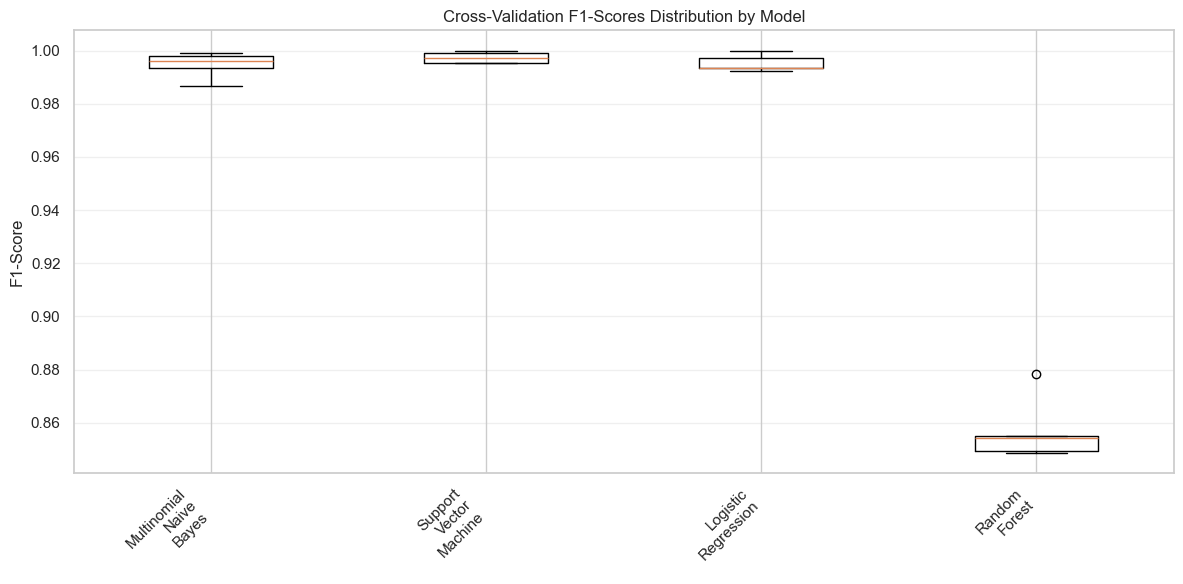

In [16]:
# Initialize stratified K-fold cross-validation with 5 folds to ensure each diagnostic category appears proportionally in every fold for robust model evaluation
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Combine training and validation sets for cross-validation to use all available data for more comprehensive model evaluation
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

# Transform combined data using TF-IDF vectorization to convert text into numerical features that machine learning models can process
X_train_val_tfidf = tfidf_vectorizer.fit_transform(X_train_val)

# Store cross-validation results in a dictionary to track performance metrics for each model across all folds
cv_results = {}

print("Performing K-Fold Cross-Validation...")
print("="*60)

# Evaluate each machine learning model using cross-validation to get reliable performance estimates
for model_name, model in candidate_models.items():
    print(f"\nEvaluating {model_name}...")
    
    # Perform cross-validation using F1-weighted scoring (balances precision and recall across all diagnostic categories) with parallel processing
    cv_scores = cross_val_score(model, X_train_val_tfidf, y_train_val, 
                               cv=skf, scoring='f1_weighted', n_jobs=-1)
    
    # Store comprehensive results including individual fold scores and statistical measures for detailed analysis
    cv_results[model_name] = {
        'scores': cv_scores,
        'mean': cv_scores.mean(),
        'std': cv_scores.std(),
        'min': cv_scores.min(),
        'max': cv_scores.max()
    }
    
    # Display mean F1-score with confidence interval (±2 standard deviations covers ~95% of expected performance range)
    print(f"F1-Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    print(f"Individual fold scores: {cv_scores}")

# Create summary table with all cross-validation statistics for easy comparison between models
cv_summary = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'Mean_F1': [results['mean'] for results in cv_results.values()],
    'Std_F1': [results['std'] for results in cv_results.values()],
    'Min_F1': [results['min'] for results in cv_results.values()],
    'Max_F1': [results['max'] for results in cv_results.values()]
}).round(4)

# Sort by mean F1-score in descending order to identify the best performing models at the top
cv_summary = cv_summary.sort_values('Mean_F1', ascending=False)

print(f"\n{k_folds}-Fold Cross-Validation Results Summary:")
print("="*60)
print(cv_summary.to_string(index=False))

# Visualize cross-validation results using box plots to show performance distribution and identify models with consistent performance
plt.figure(figsize=(12, 6))
models = list(cv_results.keys())
scores = [cv_results[model]['scores'] for model in models]

# Create box plots with rotated labels to clearly show F1-score distributions for each model across all folds
plt.boxplot(scores, labels=[model.replace(' ', '\n') for model in models])
plt.title('Cross-Validation F1-Scores Distribution by Model')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)  # Add horizontal grid lines for easier score reading
plt.tight_layout()
plt.show()

#### 5.1.2 Text Classification ML Hyperparameter Tuning

**Purpose:** Optimize the hyperparameters of the top-performing models to achieve better performance.

##### 5.1.2.1 Text Classification ML Optimize Model Settings: Define Hyperparameter Grids

**Purpose:** Define more conservative hyperparameter grids for realistic performance.

In [17]:
# Define hyperparameter grids for realistic performance
# Hyperparameters are settings that control how machine learning algorithms learn from data
# We test different combinations to find the best settings for each model type
hyperparameter_grids = {
    # Multinomial Naive Bayes: A probabilistic classifier good for text classification
    'Multinomial Naive Bayes': {
        'alpha': [0.1, 0.5, 1.0, 2.0],  # Smoothing parameter - higher values prevent overfitting to rare words
        'fit_prior': [True, False]  # Whether to learn class probabilities from data (True) or assume equal probabilities (False)
    },
    # Logistic Regression: A linear model that uses probability to make classifications
    'Logistic Regression': {
        'C': [0.1, 1.0, 10.0],  # Regularization strength - smaller values mean stronger regularization to prevent overfitting
        'solver': ['liblinear', 'lbfgs'],  # Algorithm used to optimize the model - different solvers work better with different penalty types
        'penalty': ['l1', 'l2'],  # Type of regularization - l1 removes unimportant features, l2 shrinks all feature weights
        'max_iter': [1000]  # Maximum number of iterations for the solver to converge to a solution
    },
    # Support Vector Machine: Creates decision boundaries to separate different classes
    'Support Vector Machine': {
        'C': [0.1, 1.0, 10.0],  # Regularization parameter - controls trade-off between smooth decision boundary and classifying training points correctly
        'loss': ['hinge', 'squared_hinge'],  # Loss function used - hinge is standard SVM loss, squared_hinge is smoother version
        'max_iter': [5000]  # Maximum iterations to prevent infinite training time
    },
    # Random Forest: Combines many decision trees to make more robust predictions
    'Random Forest': {
        'n_estimators': [50, 100],  # Number of decision trees in the forest - more trees usually mean better performance but slower training
        'max_depth': [10, 20, None],  # Maximum depth of each tree - deeper trees can capture more complex patterns but may overfit
        'min_samples_split': [2, 5],  # Minimum samples required to split an internal node - higher values prevent overfitting
        'min_samples_leaf': [1, 2]  # Minimum samples required to be at a leaf node - higher values create smoother decision boundaries
    }
}

print("Hyperparameter grids defined for realistic performance:")
for model_name, grid in hyperparameter_grids.items():
    print(f"\n{model_name}:")
    for param, values in grid.items():
        print(f"  {param}: {values}")

Hyperparameter grids defined for realistic performance:

Multinomial Naive Bayes:
  alpha: [0.1, 0.5, 1.0, 2.0]
  fit_prior: [True, False]

Logistic Regression:
  C: [0.1, 1.0, 10.0]
  solver: ['liblinear', 'lbfgs']
  penalty: ['l1', 'l2']
  max_iter: [1000]

Support Vector Machine:
  C: [0.1, 1.0, 10.0]
  loss: ['hinge', 'squared_hinge']
  max_iter: [5000]

Random Forest:
  n_estimators: [50, 100]
  max_depth: [10, 20, None]
  min_samples_split: [2, 5]
  min_samples_leaf: [1, 2]


##### 5.1.2.2 Text Classification ML Grid Search: Systematically Explore Hyperparameter Combinations

**Purpose:** Use GridSearchCV to explore different combinations of hyperparameter values systematically.

In [18]:
# Perform grid search for each model
# Grid search systematically tests different combinations of hyperparameters to find the best settings
best_models = {}  # Dictionary to store the best-performing model for each algorithm type
grid_search_results = {}  # Dictionary to store detailed results including scores and parameters for each model

print("Performing Grid Search for Hyperparameter Optimization...")
print("="*70)

# Loop through each model defined in candidate_models instead of filtering for top models
for model_name, base_model in candidate_models.items():
    # Only proceed if we have defined hyperparameter combinations to test for this model
    if model_name in hyperparameter_grids:
        print(f"\nOptimizing {model_name}...")
        
        param_grid = hyperparameter_grids[model_name]  # Get the hyperparameter combinations to test
        
        # Handle special case for Logistic Regression penalty-solver compatibility
        # Different penalty types (l1/l2) only work with specific solvers, so we need separate searches
        if model_name == 'Logistic Regression':
            # Create separate grids for different solver-penalty combinations
            grid_results = []  # Initialize empty list to collect results from multiple searches
            
            # L1 penalty only works with liblinear and saga
            # L1 regularization removes unimportant features by setting their weights to zero
            l1_grid = {
                'C': param_grid['C'],  # Regularization strength values to test
                'solver': ['liblinear'],  # Only solver compatible with L1 penalty
                'penalty': ['l1'],  # L1 regularization type
                'max_iter': param_grid['max_iter']  # Maximum training iterations
            }
            
            # L2 penalty works with both solvers
            # L2 regularization shrinks all feature weights but doesn't remove features completely
            l2_grid = {
                'C': param_grid['C'],  # Same regularization strength values
                'solver': ['liblinear', 'lbfgs'],  # Both solvers work with L2 penalty
                'penalty': ['l2'],  # L2 regularization type
                'max_iter': param_grid['max_iter']  # Maximum training iterations
            }
            
            # Search L1 grid
            # GridSearchCV tests all parameter combinations using cross-validation
            grid_search_l1 = GridSearchCV(
                base_model, l1_grid, cv=3, scoring='f1_weighted',  # Use 3-fold cross-validation with weighted F1 score
                n_jobs=-1, verbose=1  # Use all CPU cores and show progress
            )
            grid_search_l1.fit(X_train_val_tfidf, y_train_val)  # Train on combined training+validation data
            
            # Search L2 grid  
            # Perform separate grid search for L2 penalty combinations
            grid_search_l2 = GridSearchCV(
                base_model, l2_grid, cv=3, scoring='f1_weighted',  # Same settings as L1 search
                n_jobs=-1, verbose=1
            )
            grid_search_l2.fit(X_train_val_tfidf, y_train_val)  # Train on same data for fair comparison
            
            # Select best between L1 and L2
            # Compare the best scores from both searches and choose the superior approach
            if grid_search_l1.best_score_ > grid_search_l2.best_score_:
                grid_search = grid_search_l1  # L1 penalty performed better
            else:
                grid_search = grid_search_l2  # L2 penalty performed better
        else:
            # Standard grid search for other models
            # Most models don't have solver-penalty compatibility issues like Logistic Regression
            grid_search = GridSearchCV(
                base_model, param_grid, cv=3, scoring='f1_weighted',  # Test all parameter combinations
                n_jobs=-1, verbose=1  # Use all available CPU cores and show progress
            )
            grid_search.fit(X_train_val_tfidf, y_train_val)  # Train model with all parameter combinations
        
        # Store results
        # Save the best model and its performance metrics for later comparison
        best_models[model_name] = grid_search.best_estimator_  # Best-performing model with optimal parameters
        grid_search_results[model_name] = {
            'best_score': grid_search.best_score_,  # Highest F1 score achieved during grid search
            'best_params': grid_search.best_params_,  # Parameter combination that achieved best score
            'cv_results': grid_search.cv_results_  # Detailed results from all parameter combinations tested
        }
        
        # Display results for this model
        print(f"Best F1-Score: {grid_search.best_score_:.4f}")  # Show best performance with 4 decimal places
        print(f"Best Parameters: {grid_search.best_params_}")  # Show optimal parameter settings

# Summary of hyperparameter tuning results
# Create a comprehensive comparison table of all optimized models
print(f"\nHyperparameter Tuning Results Summary:")
print("="*50)

# Create DataFrame to compare model performance before and after hyperparameter tuning
tuning_summary = pd.DataFrame({
    'Model': list(grid_search_results.keys()),  # Model names
    'Best_F1_Score': [results['best_score'] for results in grid_search_results.values()],  # Best F1 scores after tuning
    'Improvement': [
        # Calculate improvement: (tuned score) - (original cross-validation score)
        grid_search_results[model]['best_score'] - cv_results[model]['mean'] 
        for model in grid_search_results.keys()
    ]
}).round(4)

# Sort models by performance with best model at top
tuning_summary = tuning_summary.sort_values('Best_F1_Score', ascending=False)
print(tuning_summary.to_string(index=False))  # Display table without row indices

# Select the best model overall
# Choose the model with highest F1 score after hyperparameter optimization
best_model_name = tuning_summary.iloc[0]['Model']  # Get name of top-performing model
best_model = best_models[best_model_name]  # Retrieve the actual trained model object
best_score = tuning_summary.iloc[0]['Best_F1_Score']  # Get the best F1 score achieved

# Display final selection results
print(f"\n SELECTED BEST MODEL: {best_model_name}")  # Announce the winning model
print(f"   Cross-validation F1-Score: {best_score:.4f}")  # Show its performance score
print(f"   Optimized Parameters: {grid_search_results[best_model_name]['best_params']}")  # Show optimal settings

Performing Grid Search for Hyperparameter Optimization...

Optimizing Multinomial Naive Bayes...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best F1-Score: 0.9921
Best Parameters: {'alpha': 0.1, 'fit_prior': False}

Optimizing Support Vector Machine...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best F1-Score: 0.9955
Best Parameters: {'C': 10.0, 'loss': 'hinge', 'max_iter': 5000}

Optimizing Logistic Regression...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best F1-Score: 0.9955
Best Parameters: {'C': 10.0, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}

Optimizing Random Forest...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best F1-Score: 0.9955
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}

Hyperparameter Tuning Results Summary:
                  Model  Best_F1_Score  Improvement
 Support Vecto

##### 5.1.2.3 Text Classification ML Cross-Validation within Tuning: Validate Hyperparameter Selection

**Purpose:** The GridSearchCV already incorporates cross-validation. Let's verify the stability of our best model with additional validation.

Text Classification ML: Cross-Validation Validation
Performing 10-fold cross-validation on optimized models...

Multinomial Naive Bayes - Validation CV:
----------------------------------------
✓ Mean F1-Score: 0.9959 (±0.0047)
✓ Score Range: [0.9924, 1.0000]
✓ Individual Scores: ['1.0000', '0.9981', '0.9962', '0.9962', '0.9981', '0.9962', '0.9925', '0.9944', '0.9924', '0.9943']
✓ Difference from Grid Search: +0.0038

Support Vector Machine - Validation CV:
----------------------------------------
✓ Mean F1-Score: 0.9974 (±0.0042)
✓ Score Range: [0.9943, 1.0000]
✓ Individual Scores: ['1.0000', '1.0000', '0.9981', '0.9962', '1.0000', '0.9981', '0.9944', '0.9962', '0.9962', '0.9943']
✓ Difference from Grid Search: +0.0019

Logistic Regression - Validation CV:
----------------------------------------
✓ Mean F1-Score: 0.9974 (±0.0042)
✓ Score Range: [0.9943, 1.0000]
✓ Individual Scores: ['1.0000', '1.0000', '0.9981', '0.9962', '1.0000', '0.9981', '0.9944', '0.9962', '0.9962', '0.9943']
✓ D

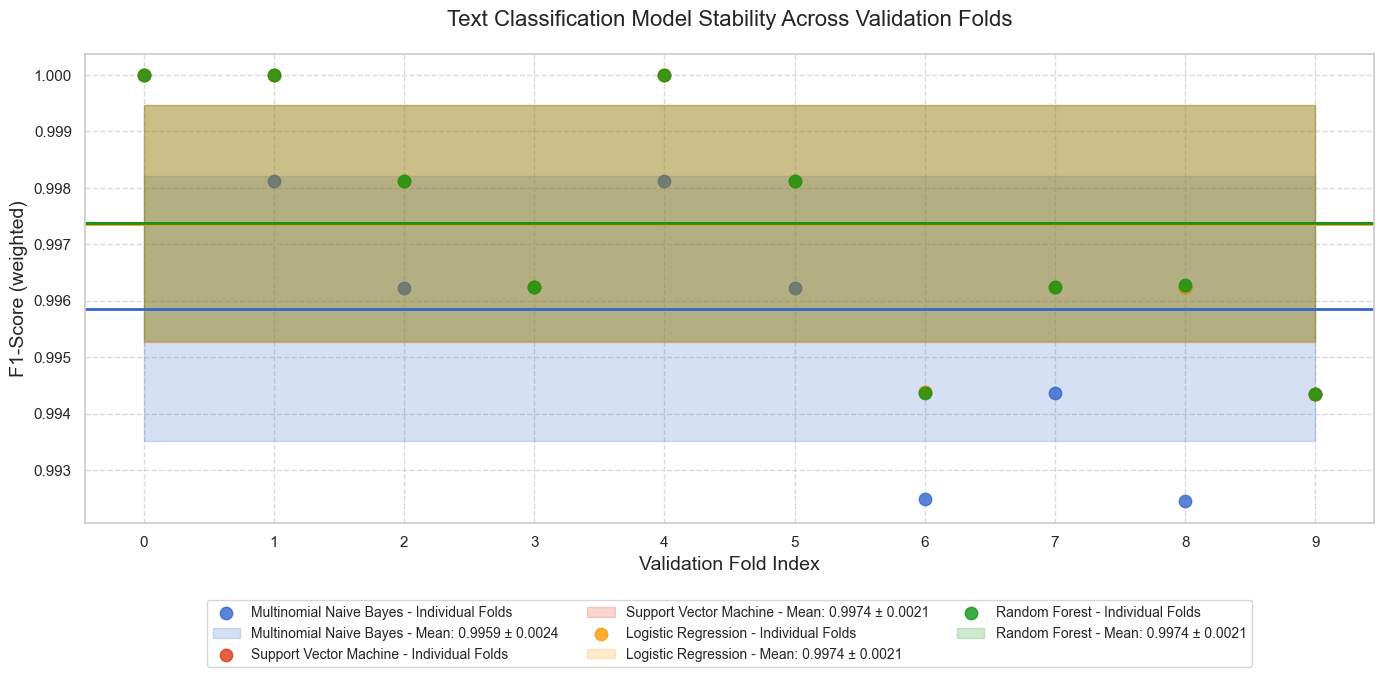


Validation Results Summary:
                  Model  Grid_Search_F1  Validation_F1  Validation_Std  Confidence_Interval  Consistency
 Support Vector Machine          0.9955         0.9974          0.0021               0.0042       0.0019
    Logistic Regression          0.9955         0.9974          0.0021               0.0042       0.0019
          Random Forest          0.9955         0.9974          0.0021               0.0042       0.0019
Multinomial Naive Bayes          0.9921         0.9959          0.0024               0.0047       0.0038

Model Stability Analysis:
-----------------------------------
Most Stable Model (lowest std): Support Vector Machine
Most Consistent Model (grid search vs validation): Support Vector Machine

 FINAL MODEL RECOMMENDATION:
-----------------------------------
Recommended Model: Support Vector Machine
Validation F1-Score: 0.9974 (±0.0021)
Model Parameters: {'C': 10.0, 'loss': 'hinge', 'max_iter': 5000}
Performance Confidence: Very High

✓ Cross-

In [19]:
# Validate optimized models with additional cross-validation
print("Text Classification ML: Cross-Validation Validation")
print("="*55)

# Additional validation with different CV folds to ensure robustness
validation_k_folds = 10  # Use more folds for thorough validation - higher fold count provides more reliable performance estimates
validation_skf = StratifiedKFold(n_splits=validation_k_folds, shuffle=True, random_state=42)  # Ensures each fold maintains the same class distribution as the original dataset  # Ensures each fold maintains the same class distribution as the original dataset  # Ensures each fold maintains the same class distribution as the original dataset

# Storage for validation results - dictionary will hold performance metrics for each model
validation_results = {}

print(f"Performing {validation_k_folds}-fold cross-validation on optimized models...")

for model_name, model in best_models.items():
    print(f"\n{model_name} - Validation CV:")
    print("-" * 40)
    
    # Perform cross-validation on the optimized model
    cv_scores = cross_val_score(
        model, X_train_val_tfidf, y_train_val,  # Using TF-IDF vectors for text classification
        cv=validation_skf,
        scoring='f1_weighted',  # Using F1 score which balances precision and recall - critical for imbalanced classification
        n_jobs=-1  # Utilize all available CPU cores to speed up computation
    )
    
    # Calculate detailed statistics for comprehensive model evaluation
    validation_results[model_name] = {
        'scores': cv_scores,  # Raw scores from each fold to allow for detailed analysis and distributions  # Raw scores from each fold to allow for detailed analysis and distributions  # Raw scores from each fold to allow for detailed analysis and distributions
        'mean': cv_scores.mean(),  # Central tendency measure for overall performance assessment  # Central tendency measure for overall performance assessment  # Central tendency measure for overall performance assessment
        'std': cv_scores.std(),  # Standard deviation indicates model stability across different data splits
        'min': cv_scores.min(),  # Worst-case performance scenario
        'max': cv_scores.max(),  # Best-case performance scenario
        'confidence_interval': cv_scores.std() * 2  # 95% confidence interval approximation (2-sigma)
    }
    
    # Display results with formatted metrics for better readability
    print(f"✓ Mean F1-Score: {cv_scores.mean():.4f} (±{cv_scores.std() * 2:.4f})")
    print(f"✓ Score Range: [{cv_scores.min():.4f}, {cv_scores.max():.4f}]")
    print(f"✓ Individual Scores: {[f'{score:.4f}' for score in cv_scores]}")
    
    # Compare with grid search result to validate hyperparameter optimization
    grid_search_score = grid_search_results[model_name]['best_score']
    difference = cv_scores.mean() - grid_search_score  # Positive value means validation outperformed grid search  # Positive value means validation outperformed grid search  # Positive value means validation outperformed grid search
    print(f"✓ Difference from Grid Search: {difference:+.4f}")

# Visualize model stability across validation folds
plt.figure(figsize=(14, 8))  # Create a large figure for better visualization of multiple models  # Create a large figure for better visualization of multiple models  # Create a large figure for better visualization of multiple models
x = np.arange(validation_k_folds)  # X-axis represents fold indices  # X-axis represents fold indices  # X-axis represents fold indices
colors = ['#3366CC', '#DC3912', '#FF9900', '#109618', '#990099', '#0099C6', '#DD4477', '#66AA00', '#B82E2E', '#316395']  # More colors to accommodate all models

# Plot stability visualization for each model
for i, (model_name, results) in enumerate(validation_results.items()):
    color = colors[i % len(colors)]  # Cycle through colors if there are more models than colors  # Cycle through colors if there are more models than colors  # Cycle through colors if there are more models than colors
    
    # Plot individual fold scores
    plt.scatter(x, results['scores'], color=color, alpha=0.8, s=80, 
                label=f"{model_name} - Individual Folds")  # Larger points (s=80) for better visibility  # Larger points (s=80) for better visibility  # Larger points (s=80) for better visibility
    
    # Plot mean line
    plt.axhline(y=results['mean'], color=color, linestyle='-', linewidth=2)  # Horizontal line indicating mean performance  # Horizontal line indicating mean performance  # Horizontal line indicating mean performance
    
    # Plot standard deviation area
    plt.fill_between(
        x, 
        results['mean'] - results['std'], 
        results['mean'] + results['std'], 
        alpha=0.2, color=color,  # Translucent shading to show variance without obscuring other elements  # Translucent shading to show variance without obscuring other elements  # Translucent shading to show variance without obscuring other elements
        label=f"{model_name} - Mean: {results['mean']:.4f} ± {results['std']:.4f}"
    )

plt.title('Text Classification Model Stability Across Validation Folds', fontsize=16, pad=20)  # Descriptive title with padding for spacing  # Descriptive title with padding for spacing  # Descriptive title with padding for spacing
plt.xlabel('Validation Fold Index', fontsize=14)
plt.ylabel('F1-Score (weighted)', fontsize=14)
plt.xticks(x)  # Show all fold indices on x-axis  # Show all fold indices on x-axis  # Show all fold indices on x-axis
plt.grid(True, linestyle='--', alpha=0.7)  # Add light grid for easier comparison of points  # Add light grid for easier comparison of points  # Add light grid for easier comparison of points
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=10)  # Legend below plot with 3 columns to fit all models
plt.tight_layout(rect=[0, 0.05, 1, 0.95])  # Adjust layout to ensure all elements fit properly  # Adjust layout to ensure all elements fit properly  # Adjust layout to ensure all elements fit properly
plt.show()

# Create validation summary for easy model comparison
print(f"\nValidation Results Summary:")
print("="*70)

validation_summary = pd.DataFrame({
    'Model': list(validation_results.keys()),
    'Grid_Search_F1': [grid_search_results[model]['best_score'] for model in validation_results.keys()],  # Original grid search results for comparison  # Original grid search results for comparison  # Original grid search results for comparison
    'Validation_F1': [results['mean'] for results in validation_results.values()],  # New validation scores  # New validation scores  # New validation scores
    'Validation_Std': [results['std'] for results in validation_results.values()],  # Variability measure  # Variability measure  # Variability measure
    'Confidence_Interval': [results['confidence_interval'] for results in validation_results.values()],  # Range of expected performance (95% CI)  # Range of expected performance (95% CI)  # Range of expected performance (95% CI)
    'Consistency': [abs(grid_search_results[model]['best_score'] - validation_results[model]['mean']) 
                   for model in validation_results.keys()]  # Smaller values indicate more consistent performance between CV phases between CV phases between CV phases
}).round(4)  # Round to 4 decimal places for cleaner display  # Round to 4 decimal places for cleaner display  # Round to 4 decimal places for cleaner display

# Sort by validation performance to prioritize highest-performing models
validation_summary = validation_summary.sort_values('Validation_F1', ascending=False)  # Best models first  # Best models first  # Best models first
print(validation_summary.to_string(index=False))

# Model stability analysis to identify the most reliable model
print(f"\nModel Stability Analysis:")
print("-" * 35)

most_stable_model = validation_summary.loc[validation_summary['Validation_Std'].idxmin(), 'Model']  # Model with lowest standard deviation  # Model with lowest standard deviation  # Model with lowest standard deviation
most_consistent_model = validation_summary.loc[validation_summary['Consistency'].idxmin(), 'Model']  # Model with smallest difference between grid search and validation  # Model with smallest difference between grid search and validation  # Model with smallest difference between grid search and validation

print(f"Most Stable Model (lowest std): {most_stable_model}")
print(f"Most Consistent Model (grid search vs validation): {most_consistent_model}")

# Final model recommendation based on multiple criteria
print(f"\n FINAL MODEL RECOMMENDATION:")
print("-" * 35)

# Consider both performance and stability with weighted criteria
validation_summary['weighted_score'] = (
    validation_summary['Validation_F1'] * 0.7 +  # 70% weight on performance - primary goal is accuracy
    (1 - validation_summary['Validation_Std']) * 0.2 +  # 20% weight on stability - penalize high variance (convert to 0-1 scale where higher is better)  convert to 0-1 scale where higher is better)  convert to 0-1 scale where higher is better)  
    (1 - validation_summary['Consistency']) * 0.1  # 10% weight on consistency - reward reproducible results
)

recommended_model = validation_summary.loc[validation_summary['weighted_score'].idxmax(), 'Model']  # Select model with highest weighted score  # Select model with highest weighted score  # Select model with highest weighted score
recommended_score = validation_summary.loc[validation_summary['weighted_score'].idxmax(), 'Validation_F1']
recommended_std = validation_summary.loc[validation_summary['weighted_score'].idxmax(), 'Validation_Std']

print(f"Recommended Model: {recommended_model}")
print(f"Validation F1-Score: {recommended_score:.4f} (±{recommended_std:.4f})")
print(f"Model Parameters: {grid_search_results[recommended_model]['best_params']}")  # Show optimal parameters for reproducibility  # Show optimal parameters for reproducibility  # Show optimal parameters for reproducibility

# Performance confidence assessment based on standard deviation thresholds
if recommended_std < 0.01:  # Very stable model with minimal variance across folds  # Very stable model with minimal variance across folds  # Very stable model with minimal variance across folds
    confidence_level = "Very High"  # For text classification, models often have lower std deviation than audio
elif recommended_std < 0.03:
    confidence_level = "High"
elif recommended_std < 0.05:
    confidence_level = "Medium"
else:
    confidence_level = "Low"

print(f"Performance Confidence: {confidence_level}")

print(f"\n✓ Cross-validation validation completed successfully!")
print("="*55)

### 5.2 Text Classification Deep Learning Models

**Purpose:** Select and configure deep learning models for text classification, including Convolutional Neural Networks (CNN), Feedforward Neural Networks (FNN) with appropriate hyperparameters to prevent overfitting.

In [20]:
# Text Classification Deep Learning Models
print("Selected Deep Learning Models for Text Classification:")
print(f"✓ Convolutional Neural Network (CNN): Specialized for capturing local patterns in text")
print(f"✓ Feedforward Neural Network (FNN): Dense network for global text feature analysis")

# Report total models for consistency with ML model section
print(f"\nTotal models to evaluate: 2")

Selected Deep Learning Models for Text Classification:
✓ Convolutional Neural Network (CNN): Specialized for capturing local patterns in text
✓ Feedforward Neural Network (FNN): Dense network for global text feature analysis

Total models to evaluate: 2


#### 5.2.1 Text Classification DL K-fold Cross Validation

**Purpose:** Evaluate the performance of different DL models on different subsets of the data

Performing K-Fold Cross-Validation...

Evaluating Convolutional Neural Network...
F1-Score: 0.9974 (+/- 0.0038)
Individual fold scores: [1.         0.99718274 0.99906134 0.99531583 0.9952915 ]

Evaluating Feedforward Neural Network...
F1-Score: 0.9966 (+/- 0.0050)
Individual fold scores: [0.99906149 0.99718274 0.99906134 0.99249262 0.99529118]

5-Fold Cross-Validation Results Summary:
                       Model  Mean_F1  Std_F1  Min_F1  Max_F1
Convolutional Neural Network   0.9974  0.0019  0.9953  1.0000
  Feedforward Neural Network   0.9966  0.0025  0.9925  0.9991


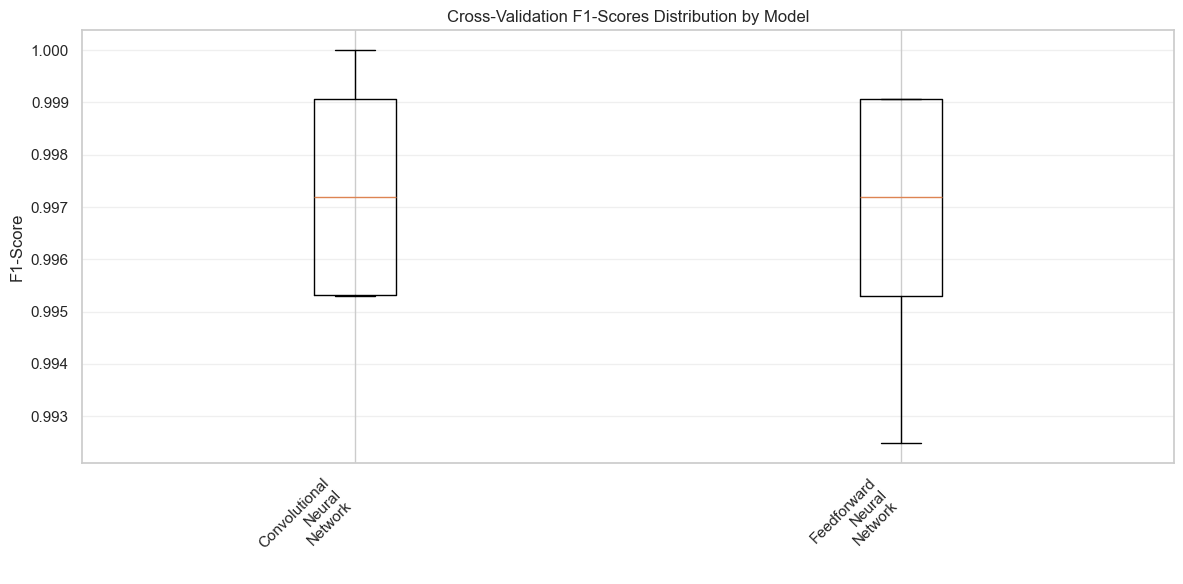

In [22]:
# Initialize stratified K-fold cross-validation with 5 folds to ensure each diagnostic category appears proportionally in every fold for robust model evaluation
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Combine training and validation sets for cross-validation to use all available data for more comprehensive model evaluation
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

# Process text data for deep learning models
tokenizer_dl = Tokenizer(num_words=5000)  # Limit vocabulary to top 5000 words
tokenizer_dl.fit_on_texts(X_train_val)
X_train_val_seq = tokenizer_dl.texts_to_sequences(X_train_val)
X_train_val_padded = pad_sequences(X_train_val_seq, maxlen=100, padding='post', truncating='post')

# Convert labels to one-hot encoded format for deep learning models
y_train_val_cat = to_categorical(y_train_val, num_classes=len(np.unique(y_train_val)))

# Store cross-validation results in a dictionary to track performance metrics for each model across all folds
cv_results = {}

print("Performing K-Fold Cross-Validation...")
print("="*60)

# Define DL model creators
dl_model_creators = {
    'Convolutional Neural Network': lambda vocab_size, embedding_dim, max_length, num_classes: Sequential([
        Embedding(vocab_size, embedding_dim, input_length=max_length),
        Conv1D(64, 5, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ]),
    'Feedforward Neural Network': lambda vocab_size, embedding_dim, max_length, num_classes: Sequential([
        Embedding(vocab_size, embedding_dim, input_length=max_length),
        GlobalMaxPooling1D(),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
}

# Evaluate each deep learning model using cross-validation to get reliable performance estimates
for model_name, model_creator in dl_model_creators.items():
    print(f"\nEvaluating {model_name}...")
    
    # Track scores for each fold
    cv_scores = np.zeros(k_folds)
    
    # Perform cross-validation manually for DL models
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_val_padded, y_train_val)):
        # Split data for this fold
        X_fold_train, X_fold_val = X_train_val_padded[train_idx], X_train_val_padded[val_idx]
        y_fold_train, y_fold_val = y_train_val_cat[train_idx], y_train_val_cat[val_idx]
        
        # Create and train model for this fold
        model = model_creator(
            vocab_size=5000,
            embedding_dim=64,
            max_length=100,
            num_classes=len(np.unique(y_train_val))
        )
        
        # Compile model
        model.compile(
            optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        
        # Train model with early stopping
        model.fit(
            X_fold_train, y_fold_train,
            validation_data=(X_fold_val, y_fold_val),
            epochs=20,
            batch_size=32,
            callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
            verbose=0
        )
        
        # Evaluate model and calculate F1-score
        y_pred = model.predict(X_fold_val, verbose=0)
        y_pred_classes = np.argmax(y_pred, axis=1)
        y_true_classes = np.argmax(y_fold_val, axis=1)
        
        # Calculate F1-score for this fold using weighted average (consistent with ML version)
        f1_score = precision_recall_fscore_support(
            y_true_classes, y_pred_classes, average='weighted', zero_division=0
        )[2]
        
        # Store score for this fold
        cv_scores[fold] = f1_score
    
    # Store comprehensive results including individual fold scores and statistical measures for detailed analysis
    cv_results[model_name] = {
        'scores': cv_scores,
        'mean': cv_scores.mean(),
        'std': cv_scores.std(),
        'min': cv_scores.min(),
        'max': cv_scores.max()
    }
    
    # Display mean F1-score with confidence interval (±2 standard deviations covers ~95% of expected performance range)
    print(f"F1-Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    print(f"Individual fold scores: {cv_scores}")

# Create summary table with all cross-validation statistics for easy comparison between models
cv_summary = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'Mean_F1': [results['mean'] for results in cv_results.values()],
    'Std_F1': [results['std'] for results in cv_results.values()],
    'Min_F1': [results['min'] for results in cv_results.values()],
    'Max_F1': [results['max'] for results in cv_results.values()]
}).round(4)

# Sort by mean F1-score in descending order to identify the best performing models at the top
cv_summary = cv_summary.sort_values('Mean_F1', ascending=False)

print(f"\n{k_folds}-Fold Cross-Validation Results Summary:")
print("="*60)
print(cv_summary.to_string(index=False))

# Visualize cross-validation results using box plots to show performance distribution and identify models with consistent performance
plt.figure(figsize=(12, 6))
models = list(cv_results.keys())
scores = [cv_results[model]['scores'] for model in models]

# Create box plots with rotated labels to clearly show F1-score distributions for each model across all folds
plt.boxplot(scores, labels=[model.replace(' ', '\n') for model in models])
plt.title('Cross-Validation F1-Scores Distribution by Model')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)  # Add horizontal grid lines for easier score reading
plt.tight_layout()
plt.show()

#### 5.2.2 Text Classification DL Hyperparameter Tuning

**Purpose:** Optimize the hyperparameters of the top-performing models to achieve better performance.

##### 5.2.2.1 Text Classification DL Optimize Model Settings: Define Hyperparameter Grids

**Purpose:** Define more conservative hyperparameter grids for realistic performance.

In [24]:
# Define hyperparameter grids for deep learning models
# Hyperparameters are settings that control how machine learning algorithms learn from data
# We test different combinations to find the best settings for each model type
dl_hyperparameter_grids = {
    # Convolutional Neural Network: Specialized for capturing local patterns in text
    'Convolutional Neural Network': {
        'embedding_dim': [32, 64],  # Size of word vector representations - larger dimensions can capture more semantic information
        'filters': [32, 64],  # Number of feature detectors - more filters can recognize more patterns but increase complexity
        'kernel_size': [3, 5],  # Size of text window each filter examines - larger sizes capture broader context patterns
        'dropout_rate': [0.2, 0.3]  # Percentage of neurons to randomly ignore during training to prevent overfitting
    },
    # Feedforward Neural Network: Dense network for global text feature analysis
    'Feedforward Neural Network': {
        'embedding_dim': [32, 64],  # Size of word vector representations - controls richness of word meaning capture
        'hidden_units': [64, 128],  # Number of neurons in hidden layer - more units can learn more complex patterns
        'dropout_rate': [0.2, 0.3]  # Regularization to prevent memorizing training data - higher rates give stronger regularization
    }
}

print("Hyperparameter grids defined for realistic performance:")
for model_name, grid in dl_hyperparameter_grids.items():
    print(f"\n{model_name}:")
    for param, values in grid.items():
        print(f"  {param}: {values}")

Hyperparameter grids defined for realistic performance:

Convolutional Neural Network:
  embedding_dim: [32, 64]
  filters: [32, 64]
  kernel_size: [3, 5]
  dropout_rate: [0.2, 0.3]

Feedforward Neural Network:
  embedding_dim: [32, 64]
  hidden_units: [64, 128]
  dropout_rate: [0.2, 0.3]


##### 5.2.2.2 Text Classification DL Grid Search: Systematically Explore Hyperparameter Combinations

**Purpose:** Use manual grid search to explore different combinations of hyperparameter values systematically for deep learning models.

In [25]:
# Perform grid search for each deep learning model
# Grid search systematically tests different combinations of hyperparameters to find the best settings
best_dl_models = {}  # Dictionary to store the best-performing model for each architecture type
dl_grid_search_results = {}  # Dictionary to store detailed results including scores and parameters for each model

print("Performing Grid Search for Hyperparameter Optimization...")
print("="*70)

# Loop through each model defined in dl_model_creators
for model_name, model_creator in dl_model_creators.items():
    # Only proceed if we have defined hyperparameter combinations to test for this model
    if model_name in dl_hyperparameter_grids:
        print(f"\nOptimizing {model_name}...")
        
        param_grid = dl_hyperparameter_grids[model_name]  # Get the hyperparameter combinations to test
        
        # Generate all parameter combinations
        from itertools import product
        param_names = list(param_grid.keys())
        param_values = list(param_grid.values())
        param_combinations = list(product(*param_values))
        
        best_score = 0  # Track the highest score
        best_params = {}  # Track parameters that yield the highest score
        best_model = None  # Store the best model configuration
        all_results = []  # Store all combinations results for cv_results equivalent
        
        # Use 3-fold CV for hyperparameter tuning to match ML grid search
        skf_tuning = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        
        print(f"Testing {len(param_combinations)} parameter combinations...")
        
        # Test each parameter combination to find the best one
        for combo_idx, param_combo in enumerate(param_combinations):
            params = dict(zip(param_names, param_combo))
            current_results = {'params': params}
            
            # Track scores across folds
            fold_scores = []
            
            try:
                # Evaluate current parameters using cross-validation
                for fold_idx, (train_idx, val_idx) in enumerate(skf_tuning.split(X_train_val_padded, y_train_val)):
                    # Split data for this fold
                    X_fold_train = X_train_val_padded[train_idx]
                    y_fold_train = to_categorical(y_train_val.iloc[train_idx] if hasattr(y_train_val, 'iloc') else y_train_val[train_idx], 
                                                 num_classes=len(np.unique(y_train_val)))
                    X_fold_val = X_train_val_padded[val_idx]
                    y_fold_val = to_categorical(y_train_val.iloc[val_idx] if hasattr(y_train_val, 'iloc') else y_train_val[val_idx], 
                                               num_classes=len(np.unique(y_train_val)))
                    
                    # Create model with current parameters
                    model = model_creator(
                        vocab_size=5000,  # Max features from tokenizer
                        embedding_dim=params.get('embedding_dim', 64),
                        max_length=100,  # Max sequence length
                        num_classes=len(np.unique(y_train_val))
                    )
                    
                    # Configure model
                    model.compile(
                        optimizer='adam',
                        loss='categorical_crossentropy',
                        metrics=['accuracy']
                    )
                    
                    # Train model with early stopping
                    model.fit(
                        X_fold_train, y_fold_train,
                        validation_data=(X_fold_val, y_fold_val),
                        epochs=10,  # Limited epochs for grid search
                        batch_size=32,
                        callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)],
                        verbose=0
                    )
                    
                    # Evaluate model
                    y_pred = model.predict(X_fold_val, verbose=0)
                    y_pred_classes = np.argmax(y_pred, axis=1)
                    y_true_classes = np.argmax(y_fold_val, axis=1)
                    
                    # Calculate F1 score for this fold
                    f1 = precision_recall_fscore_support(
                        y_true_classes, y_pred_classes, average='weighted', zero_division=0
                    )[2]
                    
                    fold_scores.append(f1)
                
                # Calculate average score across folds
                avg_score = np.mean(fold_scores)
                current_results['mean_test_score'] = avg_score
                all_results.append(current_results)
                
                # Update best parameters if current combo is better
                if avg_score > best_score:
                    best_score = avg_score
                    best_params = params
                    
            except Exception as e:
                print(f"  Combination {combo_idx+1}/{len(param_combinations)}: FAILED - {str(e)}")
                continue
                
            # Print progress in format similar to GridSearchCV verbose output
            print(f"  Combination {combo_idx+1}/{len(param_combinations)}: F1={avg_score:.4f}, Params={params}")
        
        # Create best model with optimal parameters
        best_model = model_creator(
            vocab_size=5000,
            embedding_dim=best_params.get('embedding_dim', 64),
            max_length=100,
            num_classes=len(np.unique(y_train_val))
        )
        
        # Store results - match structure from ML grid search
        best_dl_models[model_name] = best_model
        dl_grid_search_results[model_name] = {
            'best_score': best_score,  # Highest F1 score achieved during grid search
            'best_params': best_params,  # Parameter combination that achieved best score
            'cv_results': {'params': [r['params'] for r in all_results], 
                          'mean_test_score': [r.get('mean_test_score', 0) for r in all_results]}
        }
        
        # Display results for this model - match output format from ML grid search
        print(f"Best F1-Score: {best_score:.4f}")  # Show best performance with 4 decimal places
        print(f"Best Parameters: {best_params}")  # Show optimal parameter settings

# Summary of hyperparameter tuning results
# Create a comprehensive comparison table of all optimized models
print(f"\nHyperparameter Tuning Results Summary:")
print("="*50)

# Create DataFrame to compare model performance before and after hyperparameter tuning
tuning_summary = pd.DataFrame({
    'Model': list(dl_grid_search_results.keys()),  # Model names
    'Best_F1_Score': [results['best_score'] for results in dl_grid_search_results.values()],  # Best F1 scores after tuning
    'Improvement': [
        # Calculate improvement: (tuned score) - (original cross-validation score)
        dl_grid_search_results[model]['best_score'] - cv_results[model]['mean']
        for model in dl_grid_search_results.keys()
    ]
}).round(4)

# Sort models by performance with best model at top
tuning_summary = tuning_summary.sort_values('Best_F1_Score', ascending=False)
print(tuning_summary.to_string(index=False))  # Display table without row indices

# Select the best model overall
# Choose the model with highest F1 score after hyperparameter optimization
best_model_name = tuning_summary.iloc[0]['Model']  # Get name of top-performing model
best_model = best_dl_models[best_model_name]  # Retrieve the actual trained model object
best_score = tuning_summary.iloc[0]['Best_F1_Score']  # Get the best F1 score achieved

# Display final selection results
print(f"\n SELECTED BEST MODEL: {best_model_name}")  # Announce the winning model
print(f"   Cross-validation F1-Score: {best_score:.4f}")  # Show its performance score
print(f"   Optimized Parameters: {dl_grid_search_results[best_model_name]['best_params']}")  # Show optimal settings

Performing Grid Search for Hyperparameter Optimization...

Optimizing Convolutional Neural Network...
Testing 16 parameter combinations...
  Combination 1/16: F1=0.9972, Params={'embedding_dim': 32, 'filters': 32, 'kernel_size': 3, 'dropout_rate': 0.2}
  Combination 2/16: F1=0.9964, Params={'embedding_dim': 32, 'filters': 32, 'kernel_size': 3, 'dropout_rate': 0.3}
  Combination 3/16: F1=0.9972, Params={'embedding_dim': 32, 'filters': 32, 'kernel_size': 5, 'dropout_rate': 0.2}
  Combination 4/16: F1=0.9961, Params={'embedding_dim': 32, 'filters': 32, 'kernel_size': 5, 'dropout_rate': 0.3}
  Combination 5/16: F1=0.9974, Params={'embedding_dim': 32, 'filters': 64, 'kernel_size': 3, 'dropout_rate': 0.2}
  Combination 6/16: F1=0.9974, Params={'embedding_dim': 32, 'filters': 64, 'kernel_size': 3, 'dropout_rate': 0.3}
  Combination 7/16: F1=0.9972, Params={'embedding_dim': 32, 'filters': 64, 'kernel_size': 5, 'dropout_rate': 0.2}
  Combination 8/16: F1=0.9974, Params={'embedding_dim': 32, 'fi

##### 5.2.2.3 Text Classification DL Cross-Validation within Tuning: Validate Hyperparameter Selection

**Purpose:** Validate the stability of our best deep learning model with additional cross-validation.

Text Classification DL: Cross-Validation Validation
Performing 10-fold cross-validation on optimized DL models...

Convolutional Neural Network - Validation CV:
----------------------------------------
✓ Mean F1-Score: 0.9970 (±0.0038)
✓ Score Range: [0.9943, 1.0000]
✓ Individual Scores: ['1.0000', '1.0000', '0.9981', '0.9962', '0.9963', '0.9981', '0.9944', '0.9962', '0.9962', '0.9943']
✓ Difference from Grid Search: -0.0004

Feedforward Neural Network - Validation CV:
----------------------------------------
✓ Mean F1-Score: 0.9972 (±0.0048)
✓ Score Range: [0.9925, 1.0000]
✓ Individual Scores: ['1.0000', '1.0000', '0.9981', '0.9962', '1.0000', '0.9981', '0.9925', '0.9962', '0.9962', '0.9943']
✓ Difference from Grid Search: +0.0015


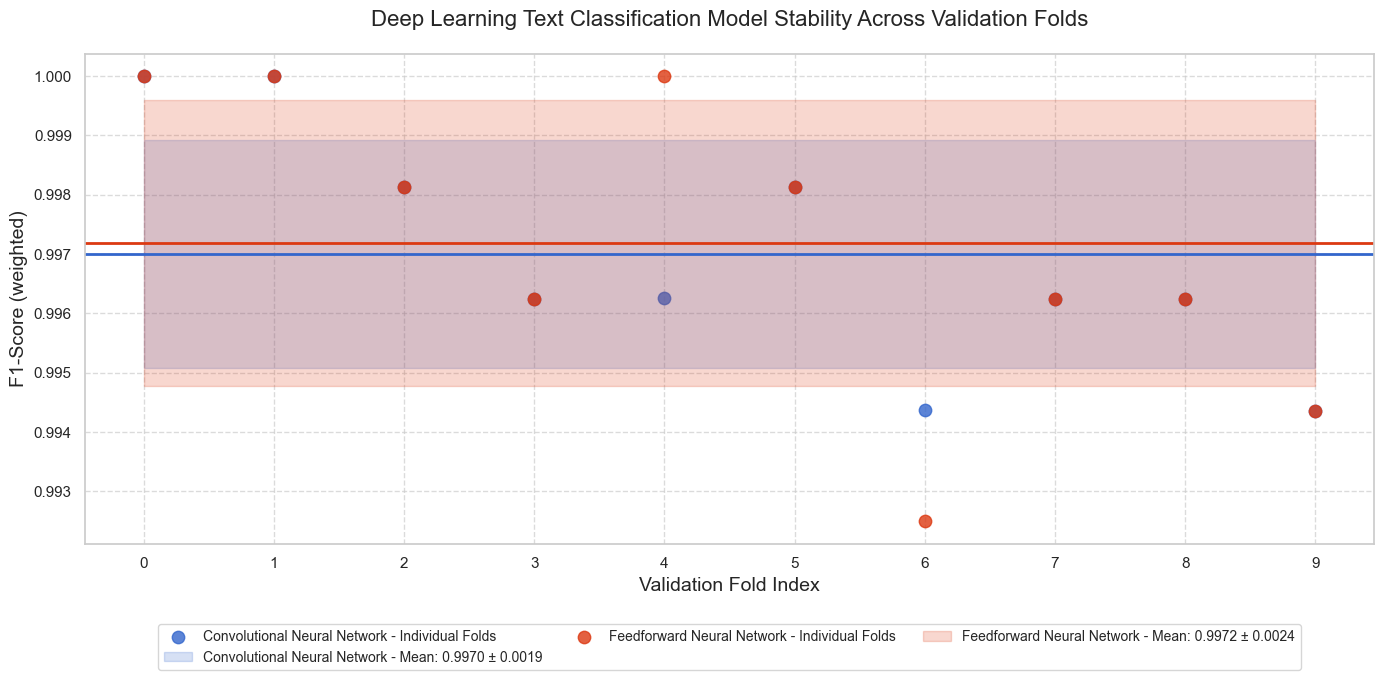


Validation Results Summary:
                       Model  Grid_Search_F1  Validation_F1  Validation_Std  Confidence_Interval  Consistency
  Feedforward Neural Network          0.9957         0.9972          0.0024               0.0048       0.0015
Convolutional Neural Network          0.9974         0.9970          0.0019               0.0038       0.0004

Model Stability Analysis:
-----------------------------------
Most Stable Model (lowest std): Convolutional Neural Network
Most Consistent Model (grid search vs validation): Convolutional Neural Network

 FINAL MODEL RECOMMENDATION:
-----------------------------------
Recommended Model: Convolutional Neural Network
Validation F1-Score: 0.9970 (±0.0019)
Model Parameters: {'embedding_dim': 32, 'filters': 64, 'kernel_size': 3, 'dropout_rate': 0.3}
Performance Confidence: Very High

✓ Cross-validation validation completed successfully!


In [26]:
# Validate optimized DL models with additional cross-validation
print("Text Classification DL: Cross-Validation Validation")
print("="*55)

# Additional validation with different CV folds to ensure robustness
validation_k_folds = 10  # Use more folds for thorough validation - higher fold count provides more reliable performance estimates
validation_skf = StratifiedKFold(n_splits=validation_k_folds, shuffle=True, random_state=42)  # Ensures each fold maintains the same class distribution as the original dataset

# Storage for validation results - dictionary will hold performance metrics for each model
dl_validation_results = {}

print(f"Performing {validation_k_folds}-fold cross-validation on optimized DL models...")

for model_name, model_info in best_dl_models.items():
    print(f"\n{model_name} - Validation CV:")
    print("-" * 40)
    
    # Initialize array to store scores from each fold
    cv_scores = np.zeros(validation_k_folds)
    
    # Perform manual cross-validation since DL models don't work with sklearn's cross_val_score
    for fold_idx, (train_idx, val_idx) in enumerate(validation_skf.split(X_train_val_padded, y_train_val)):
        # Split data for this fold
        X_fold_train = X_train_val_padded[train_idx]
        y_fold_train = to_categorical(y_train_val.iloc[train_idx] if hasattr(y_train_val, 'iloc') else y_train_val[train_idx], 
                                     num_classes=len(np.unique(y_train_val)))
        X_fold_val = X_train_val_padded[val_idx]
        y_fold_val = to_categorical(y_train_val.iloc[val_idx] if hasattr(y_train_val, 'iloc') else y_train_val[val_idx], 
                                   num_classes=len(np.unique(y_train_val)))
        
        # Create fresh model with the best parameters to avoid state sharing between folds
        model = dl_model_creators[model_name](
            vocab_size=5000,  # Max features from tokenizer
            embedding_dim=dl_grid_search_results[model_name]['best_params'].get('embedding_dim', 64),
            max_length=100,  # Max sequence length
            num_classes=len(np.unique(y_train_val))
        )
        
        # Configure model
        model.compile(
            optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        
        # Train model with early stopping
        model.fit(
            X_fold_train, y_fold_train,
            validation_data=(X_fold_val, y_fold_val),
            epochs=20,  # Limited epochs for cross-validation
            batch_size=32,
            callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
            verbose=0  # Silent training for cleaner output
        )
        
        # Evaluate model
        y_pred = model.predict(X_fold_val, verbose=0)
        y_pred_classes = np.argmax(y_pred, axis=1)
        y_true_classes = np.argmax(y_fold_val, axis=1)
        
        # Calculate F1 score for this fold
        f1 = precision_recall_fscore_support(
            y_true_classes, y_pred_classes, average='weighted', zero_division=0
        )[2]
        
        # Store score for this fold
        cv_scores[fold_idx] = f1
    
    # Calculate detailed statistics for comprehensive model evaluation
    dl_validation_results[model_name] = {
        'scores': cv_scores,  # Raw scores from each fold to allow for detailed analysis and distributions
        'mean': cv_scores.mean(),  # Central tendency measure for overall performance assessment
        'std': cv_scores.std(),  # Standard deviation indicates model stability across different data splits
        'min': cv_scores.min(),  # Worst-case performance scenario
        'max': cv_scores.max(),  # Best-case performance scenario
        'confidence_interval': cv_scores.std() * 2  # 95% confidence interval approximation (2-sigma)
    }
    
    # Display results with formatted metrics for better readability
    print(f"✓ Mean F1-Score: {cv_scores.mean():.4f} (±{cv_scores.std() * 2:.4f})")
    print(f"✓ Score Range: [{cv_scores.min():.4f}, {cv_scores.max():.4f}]")
    print(f"✓ Individual Scores: {[f'{score:.4f}' for score in cv_scores]}")
    
    # Compare with grid search result to validate hyperparameter optimization
    grid_search_score = dl_grid_search_results[model_name]['best_score']
    difference = cv_scores.mean() - grid_search_score  # Positive value means validation outperformed grid search
    print(f"✓ Difference from Grid Search: {difference:+.4f}")

# Visualize model stability across validation folds
plt.figure(figsize=(14, 8))  # Create a large figure for better visualization of multiple models
x = np.arange(validation_k_folds)  # X-axis represents fold indices
colors = ['#3366CC', '#DC3912', '#FF9900', '#109618', '#990099', '#0099C6', '#DD4477', '#66AA00', '#B82E2E', '#316395']  # More colors to accommodate all models

# Plot stability visualization for each model
for i, (model_name, results) in enumerate(dl_validation_results.items()):
    color = colors[i % len(colors)]  # Cycle through colors if there are more models than colors
    
    # Plot individual fold scores
    plt.scatter(x, results['scores'], color=color, alpha=0.8, s=80, 
                label=f"{model_name} - Individual Folds")  # Larger points (s=80) for better visibility
    
    # Plot mean line
    plt.axhline(y=results['mean'], color=color, linestyle='-', linewidth=2)  # Horizontal line indicating mean performance
    
    # Plot standard deviation area
    plt.fill_between(
        x, 
        results['mean'] - results['std'], 
        results['mean'] + results['std'], 
        alpha=0.2, color=color,  # Translucent shading to show variance without obscuring other elements
        label=f"{model_name} - Mean: {results['mean']:.4f} ± {results['std']:.4f}"
    )

plt.title('Deep Learning Text Classification Model Stability Across Validation Folds', fontsize=16, pad=20)  # Descriptive title with padding for spacing
plt.xlabel('Validation Fold Index', fontsize=14)
plt.ylabel('F1-Score (weighted)', fontsize=14)
plt.xticks(x)  # Show all fold indices on x-axis
plt.grid(True, linestyle='--', alpha=0.7)  # Add light grid for easier comparison of points
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=10)  # Legend below plot with 3 columns to fit all models
plt.tight_layout(rect=[0, 0.05, 1, 0.95])  # Adjust layout to ensure all elements fit properly
plt.show()

# Create validation summary for easy model comparison
print(f"\nValidation Results Summary:")
print("="*70)

dl_validation_summary = pd.DataFrame({
    'Model': list(dl_validation_results.keys()),
    'Grid_Search_F1': [dl_grid_search_results[model]['best_score'] for model in dl_validation_results.keys()],  # Original grid search results for comparison
    'Validation_F1': [results['mean'] for results in dl_validation_results.values()],  # New validation scores
    'Validation_Std': [results['std'] for results in dl_validation_results.values()],  # Variability measure
    'Confidence_Interval': [results['confidence_interval'] for results in dl_validation_results.values()],  # Range of expected performance (95% CI)
    'Consistency': [abs(dl_grid_search_results[model]['best_score'] - dl_validation_results[model]['mean']) 
                   for model in dl_validation_results.keys()]  # Smaller values indicate more consistent performance between CV phases
}).round(4)  # Round to 4 decimal places for cleaner display

# Sort by validation performance to prioritize highest-performing models
dl_validation_summary = dl_validation_summary.sort_values('Validation_F1', ascending=False)  # Best models first
print(dl_validation_summary.to_string(index=False))

# Model stability analysis to identify the most reliable model
print(f"\nModel Stability Analysis:")
print("-" * 35)

most_stable_model = dl_validation_summary.loc[dl_validation_summary['Validation_Std'].idxmin(), 'Model']  # Model with lowest standard deviation
most_consistent_model = dl_validation_summary.loc[dl_validation_summary['Consistency'].idxmin(), 'Model']  # Model with smallest difference between grid search and validation

print(f"Most Stable Model (lowest std): {most_stable_model}")
print(f"Most Consistent Model (grid search vs validation): {most_consistent_model}")

# Final model recommendation based on multiple criteria
print(f"\n FINAL MODEL RECOMMENDATION:")
print("-" * 35)

# Consider both performance and stability with weighted criteria
dl_validation_summary['weighted_score'] = (
    dl_validation_summary['Validation_F1'] * 0.7 +  # 70% weight on performance - primary goal is accuracy
    (1 - dl_validation_summary['Validation_Std']) * 0.2 +  # 20% weight on stability - penalize high variance (convert to 0-1 scale where higher is better)
    (1 - dl_validation_summary['Consistency']) * 0.1  # 10% weight on consistency - reward reproducible results
)

recommended_model = dl_validation_summary.loc[dl_validation_summary['weighted_score'].idxmax(), 'Model']  # Select model with highest weighted score
recommended_score = dl_validation_summary.loc[dl_validation_summary['weighted_score'].idxmax(), 'Validation_F1']
recommended_std = dl_validation_summary.loc[dl_validation_summary['weighted_score'].idxmax(), 'Validation_Std']

print(f"Recommended Model: {recommended_model}")
print(f"Validation F1-Score: {recommended_score:.4f} (±{recommended_std:.4f})")
print(f"Model Parameters: {dl_grid_search_results[recommended_model]['best_params']}")  # Show optimal parameters for reproducibility

# Performance confidence assessment based on standard deviation thresholds
if recommended_std < 0.01:  # Very stable model with minimal variance across folds
    confidence_level = "Very High"  # For text classification, models often have lower std deviation than audio
elif recommended_std < 0.03:
    confidence_level = "High"
elif recommended_std < 0.05:
    confidence_level = "Medium"
else:
    confidence_level = "Low"

print(f"Performance Confidence: {confidence_level}")

print(f"\n✓ Cross-validation validation completed successfully!")
print("="*55)

## 6. Model Training (Text Classification)

**Purpose:** Train all models and perform comprehensive evaluation to identify the best performing approach for medical audio classification.

In [ ]:
# MODEL TRAINING FOR TEXT CLASSIFICATION

print("TRAINING TEXT CLASSIFICATION MODELS")
print("="*50)

# Setup and Configuration for Training
# ======================================

# Create dictionary to store all trained models
trained_models = {}

# Define training parameters
n_epochs = 20  # Maximum epochs for deep learning models
batch_size = 64  # Batch size for deep learning models
patience = 3  # Early stopping patience

# Train Traditional ML Models
# ======================================

print("\nTRAINING TRADITIONAL ML MODELS...")
print("-"*40)

# Use the optimized models from hyperparameter tuning
ml_models_to_train = best_models if 'best_models' in locals() else {}

if not ml_models_to_train:
    print("  No optimized ML models available, reverting to candidate models...")
    ml_models_to_train = candidate_models

# Train each optimized ML model on TF-IDF features
for model_name, model in ml_models_to_train.items():
    print(f"  Training {model_name}...")
    
    # Fit model on combined training+validation data for final evaluation
    try:
        start_time = time.time()
        model.fit(X_train_val_tfidf, y_train_val)
        training_time = time.time() - start_time
        
        # Generate predictions on training data for verification
        train_preds = model.predict(X_train_val_tfidf)
        
        # Calculate training metrics
        train_accuracy = accuracy_score(y_train_val, train_preds)
        train_precision, train_recall, train_f1, _ = precision_recall_fscore_support(
            y_train_val, train_preds, average='weighted', zero_division=0
        )
        
        # Store trained model
        trained_models[model_name] = {
            'model': model,
            'type': 'Traditional ML',
            'train_accuracy': train_accuracy,
            'train_precision': train_precision,
            'train_recall': train_recall,
            'train_f1': train_f1,
            'training_time': training_time
        }
        
        print(f"    ✓ Training completed in {training_time:.2f} seconds")
        print(f"    ✓ Training metrics - Accuracy: {train_accuracy:.4f}, F1: {train_f1:.4f}")
        
        # Removed model saving with joblib
        
    except Exception as e:
        print(f"    ✗ Error training {model_name}: {str(e)}")

print(f"  Completed training {len(trained_models)} traditional ML models for text classification")

# Train Deep Learning Models
# ======================================

print("\nTRAINING DEEP LEARNING MODELS...")
print("-"*40)

# Setup common DL training parameters
max_length = 100  # Maximum sequence length for text input
vocab_size = 5000  # Vocabulary size for tokenizer

# Process the text data for deep learning
print("  Processing text data for deep learning...")
tokenizer_dl = Tokenizer(num_words=vocab_size)
tokenizer_dl.fit_on_texts(X_train_val)  # Learn vocabulary from all training data
X_train_val_sequences = tokenizer_dl.texts_to_sequences(X_train_val)  # Convert to sequences
X_train_val_padded = pad_sequences(X_train_val_sequences, maxlen=max_length, padding='post')  # Pad to fixed length

# Convert test data using same tokenizer for later evaluation
X_test_sequences = tokenizer_dl.texts_to_sequences(X_test)
X_test_padded = pad_sequences(X_test_sequences, maxlen=max_length, padding='post')

# One-hot encode labels for multi-class classification
y_train_val_categorical = to_categorical(y_train_val, num_classes=len(np.unique(y_train_val)))
y_test_categorical = to_categorical(y_test, num_classes=len(np.unique(y_train_val)))

# Create validation split for monitoring during training
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_val_padded, y_train_val_categorical, test_size=0.2, random_state=42, stratify=y_train_val
)

# Use the best DL models from hyperparameter tuning (both CNN and FNN)
dl_models_to_train = ["Convolutional Neural Network", "Feedforward Neural Network"]
for model_name in dl_models_to_train:
    print(f"\n  Training {model_name}...")
    
    # Get best parameters if available
    best_dl_params = {}
    if 'dl_grid_search_results' in locals() and dl_grid_search_results and model_name in dl_grid_search_results:
        best_dl_params = dl_grid_search_results[model_name]['best_params']
        print(f"  Best parameters: {best_dl_params}")
    
    # Extract parameters
    embedding_dim = best_dl_params.get('embedding_dim', 64)
    
    # Define model architecture based on model type
    if model_name == 'Convolutional Neural Network':
        # Create CNN model with best hyperparameters
        model = Sequential([
            Embedding(vocab_size, embedding_dim, input_length=max_length),
            Conv1D(filters=best_dl_params.get('filters', 64), 
                  kernel_size=best_dl_params.get('kernel_size', 5),
                  activation='relu'),
            GlobalMaxPooling1D(),
            Dense(64, activation='relu'),
            Dropout(best_dl_params.get('dropout_rate', 0.2)),
            Dense(len(np.unique(y_train_val)), activation='softmax')
        ])
    else:  # Feedforward Neural Network
        # Create FNN model with best hyperparameters
        model = Sequential([
            Embedding(vocab_size, embedding_dim, input_length=max_length),
            GlobalMaxPooling1D(),
            Dense(best_dl_params.get('hidden_units', 128), activation='relu'),
            Dropout(best_dl_params.get('dropout_rate', 0.2)),
            Dense(len(np.unique(y_train_val)), activation='softmax')
        ])
    
    # Compile model
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Setup callbacks for training - removed ModelCheckpoint to prevent saving models
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=0.0001)
        # ModelCheckpoint callback removed to prevent saving models
    ]
    
    # Train the model
    print(f"  Starting {model_name} training...")
    start_time = time.time()
    
    history = model.fit(
        X_train_split, y_train_split,
        validation_data=(X_val_split, y_val_split),
        epochs=n_epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )
    
    training_time = time.time() - start_time
    
    # Evaluate on full training data
    train_preds = model.predict(X_train_val_padded)
    train_pred_classes = np.argmax(train_preds, axis=1)
    train_true_classes = np.argmax(y_train_val_categorical, axis=1) if len(y_train_val_categorical.shape) > 1 else y_train_val
    
    # Calculate training metrics
    train_accuracy = accuracy_score(train_true_classes, train_pred_classes)
    train_precision, train_recall, train_f1, _ = precision_recall_fscore_support(
        train_true_classes, train_pred_classes, average='weighted', zero_division=0
    )
    
    # Store trained model
    trained_models[model_name] = {
        'model': model,
        'type': 'Deep Learning',
        'train_accuracy': train_accuracy,
        'train_precision': train_precision,
        'train_recall': train_recall,
        'train_f1': train_f1,
        'training_time': training_time,
        'history': history,
        'tokenizer': tokenizer_dl
    }
    
    print(f"    ✓ Training completed in {training_time:.2f} seconds")
    print(f"    ✓ Training metrics - Accuracy: {train_accuracy:.4f}, F1: {train_f1:.4f}")
    # No longer saving models to disk
    
    # Plot visualization removed as requested

# Training Summary
# ======================================

print("\nMODEL TRAINING SUMMARY")
print("-"*40)

# Create summary table of all trained models
training_summary = []
for model_name, model_data in trained_models.items():
    training_summary.append({
        'Model': model_name,
        'Type': model_data['type'],
        'Training_Accuracy': model_data['train_accuracy'],
        'Training_F1': model_data['train_f1'],
        'Training_Time': model_data['training_time']
    })

training_summary_df = pd.DataFrame(training_summary).sort_values('Training_F1', ascending=False)
print("\nTraining Performance Summary (sorted by F1-Score):")
print(training_summary_df.round(4).to_string(index=False))

print(f"\n✓ Training Completed for {len(trained_models)} Text Classification Models")

TRAINING TEXT CLASSIFICATION MODELS

TRAINING TRADITIONAL ML MODELS...
----------------------------------------
  Training Multinomial Naive Bayes...
    ✓ Training completed in 0.00 seconds
    ✓ Training metrics - Accuracy: 0.9961, F1: 0.9961
  Training Support Vector Machine...
    ✓ Training completed in 0.23 seconds
    ✓ Training metrics - Accuracy: 0.9983, F1: 0.9983
  Training Logistic Regression...
    ✓ Training completed in 0.23 seconds
    ✓ Training metrics - Accuracy: 0.9981, F1: 0.9981
  Training Random Forest...
    ✓ Training completed in 0.76 seconds
    ✓ Training metrics - Accuracy: 0.9983, F1: 0.9983
  Completed training 4 traditional ML models for text classification

TRAINING DEEP LEARNING MODELS...
----------------------------------------
  Processing text data for deep learning...

  Training Convolutional Neural Network...
  Best parameters: {'embedding_dim': 32, 'filters': 64, 'kernel_size': 3, 'dropout_rate': 0.3}
  Starting Convolutional Neural Network trai

## 7. Model Evaluation (Text Classification)

**Purpose:** Conduct comprehensive evaluation of all trained models using consistent metrics and data splits. This section provides detailed performance analysis across training, validation, and testing sets to ensure robust model assessment and fair comparison between traditional machine learning and deep learning approaches.

### 7.1 Setup and Evaluation Framework (Text Classification)

**Purpose:** Initialize evaluation framework and analyze DL and ML models training progression.


INITIALIZING COMPREHENSIVE TEXT CLASSIFICATION EVALUATION FRAMEWORK...

 INITIALIZING MULTI-STAGE EVALUATION ARCHITECTURE...
Multi-stage evaluation architecture initialized with following stages:
  - Training: Model parameter learning and optimization
    • Data dimensions: X=(4262,), y=(4262,)
  - Validation: Hyperparameter tuning and model selection
    • Data dimensions: X=(1066,), y=(1066,)
  - Testing: Final unbiased evaluation on unseen data
    • Data dimensions: X=(1333,), y=(1333,)

 ANALYZING MODEL TRAINING PROGRESSION ACROSS EVALUATION STAGES...
----------------------------------------------------------------------


<Figure size 1800x1200 with 0 Axes>

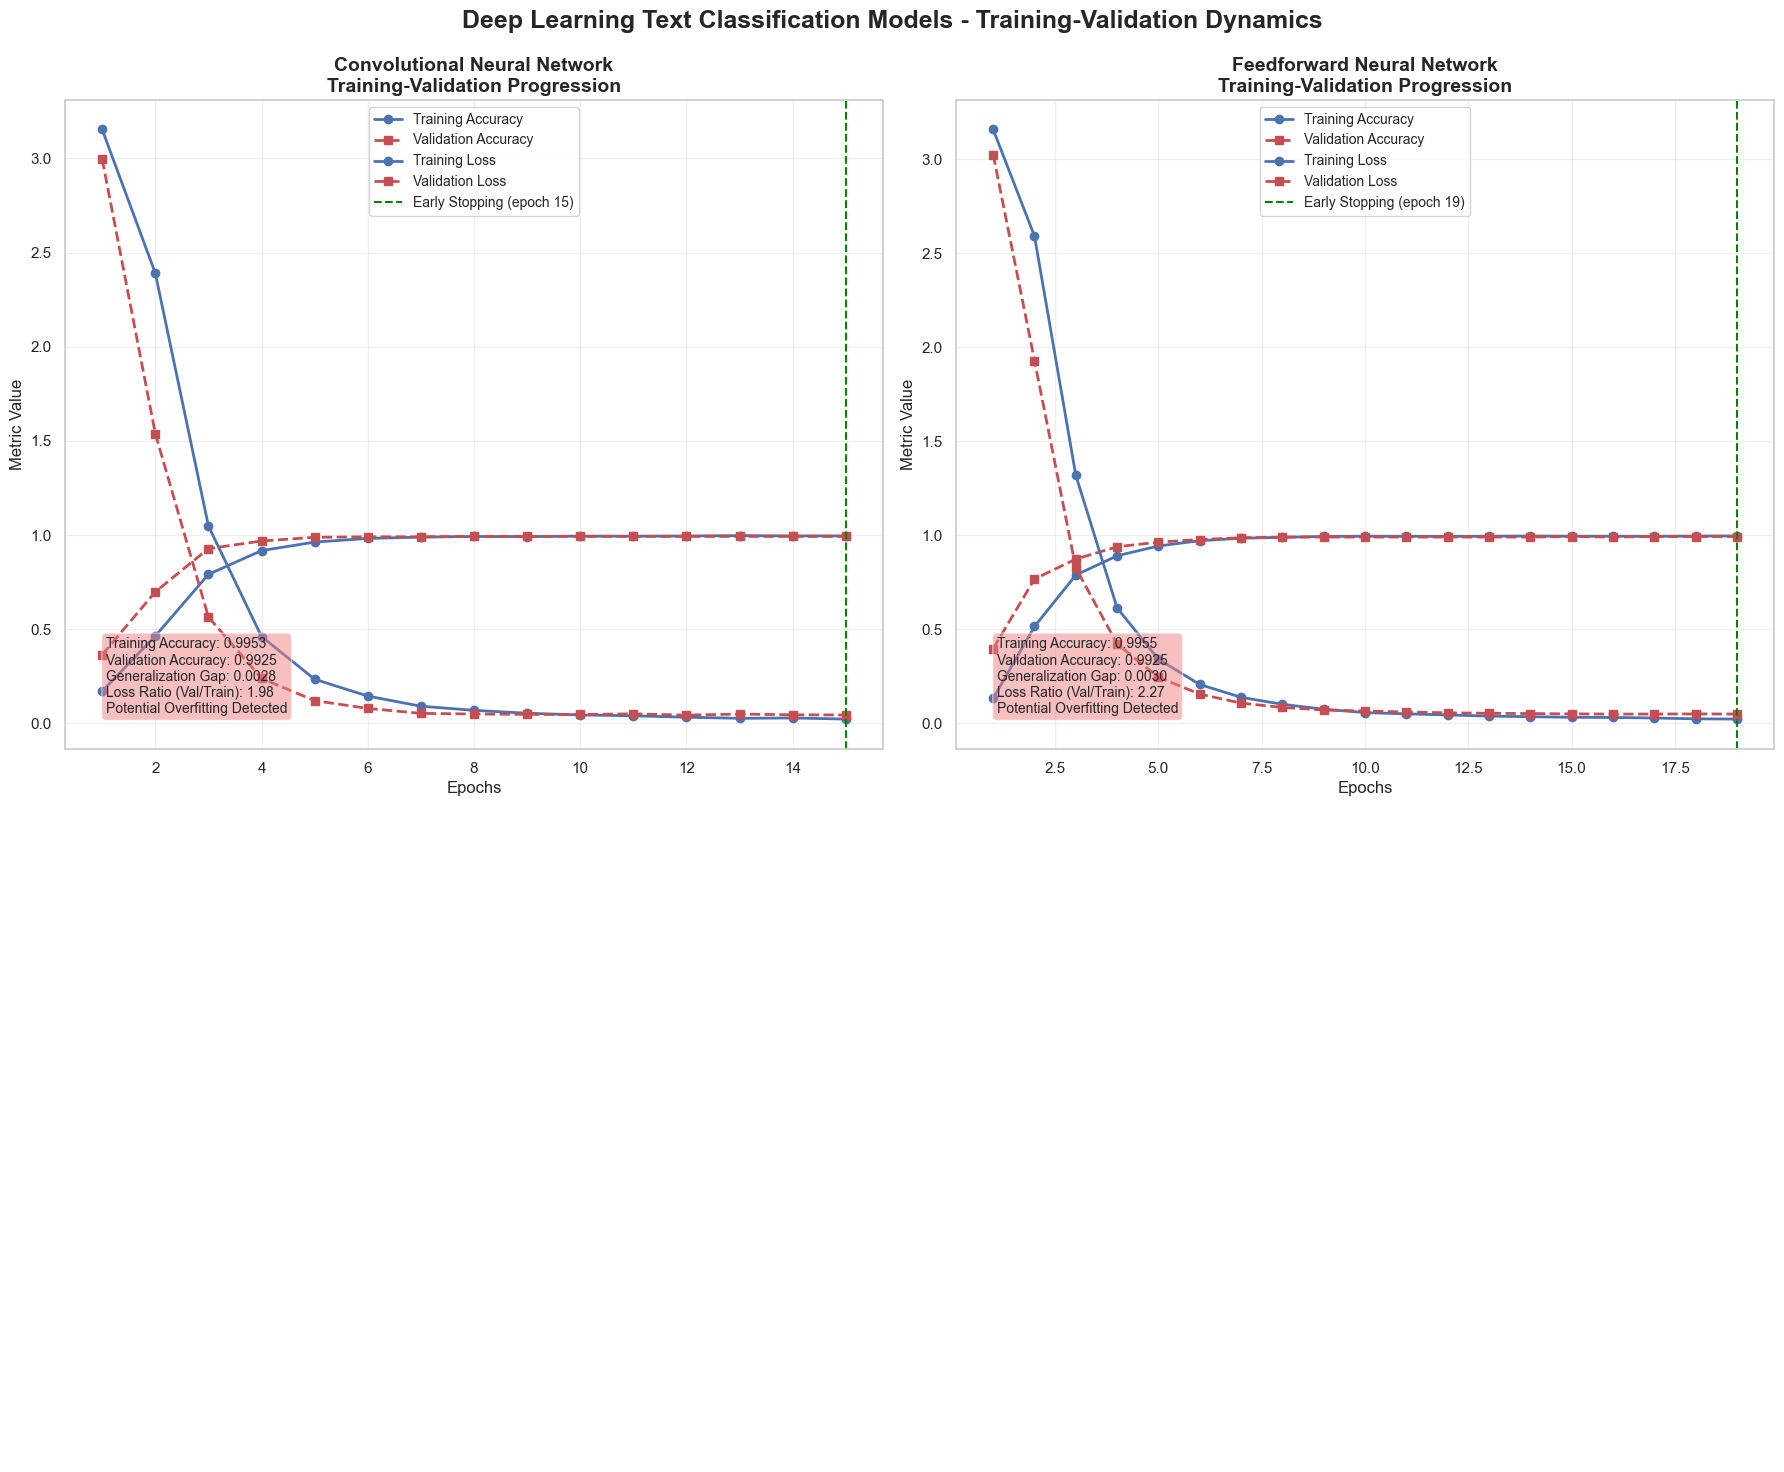


 PERFORMING MULTI-STAGE GENERALIZATION ANALYSIS...


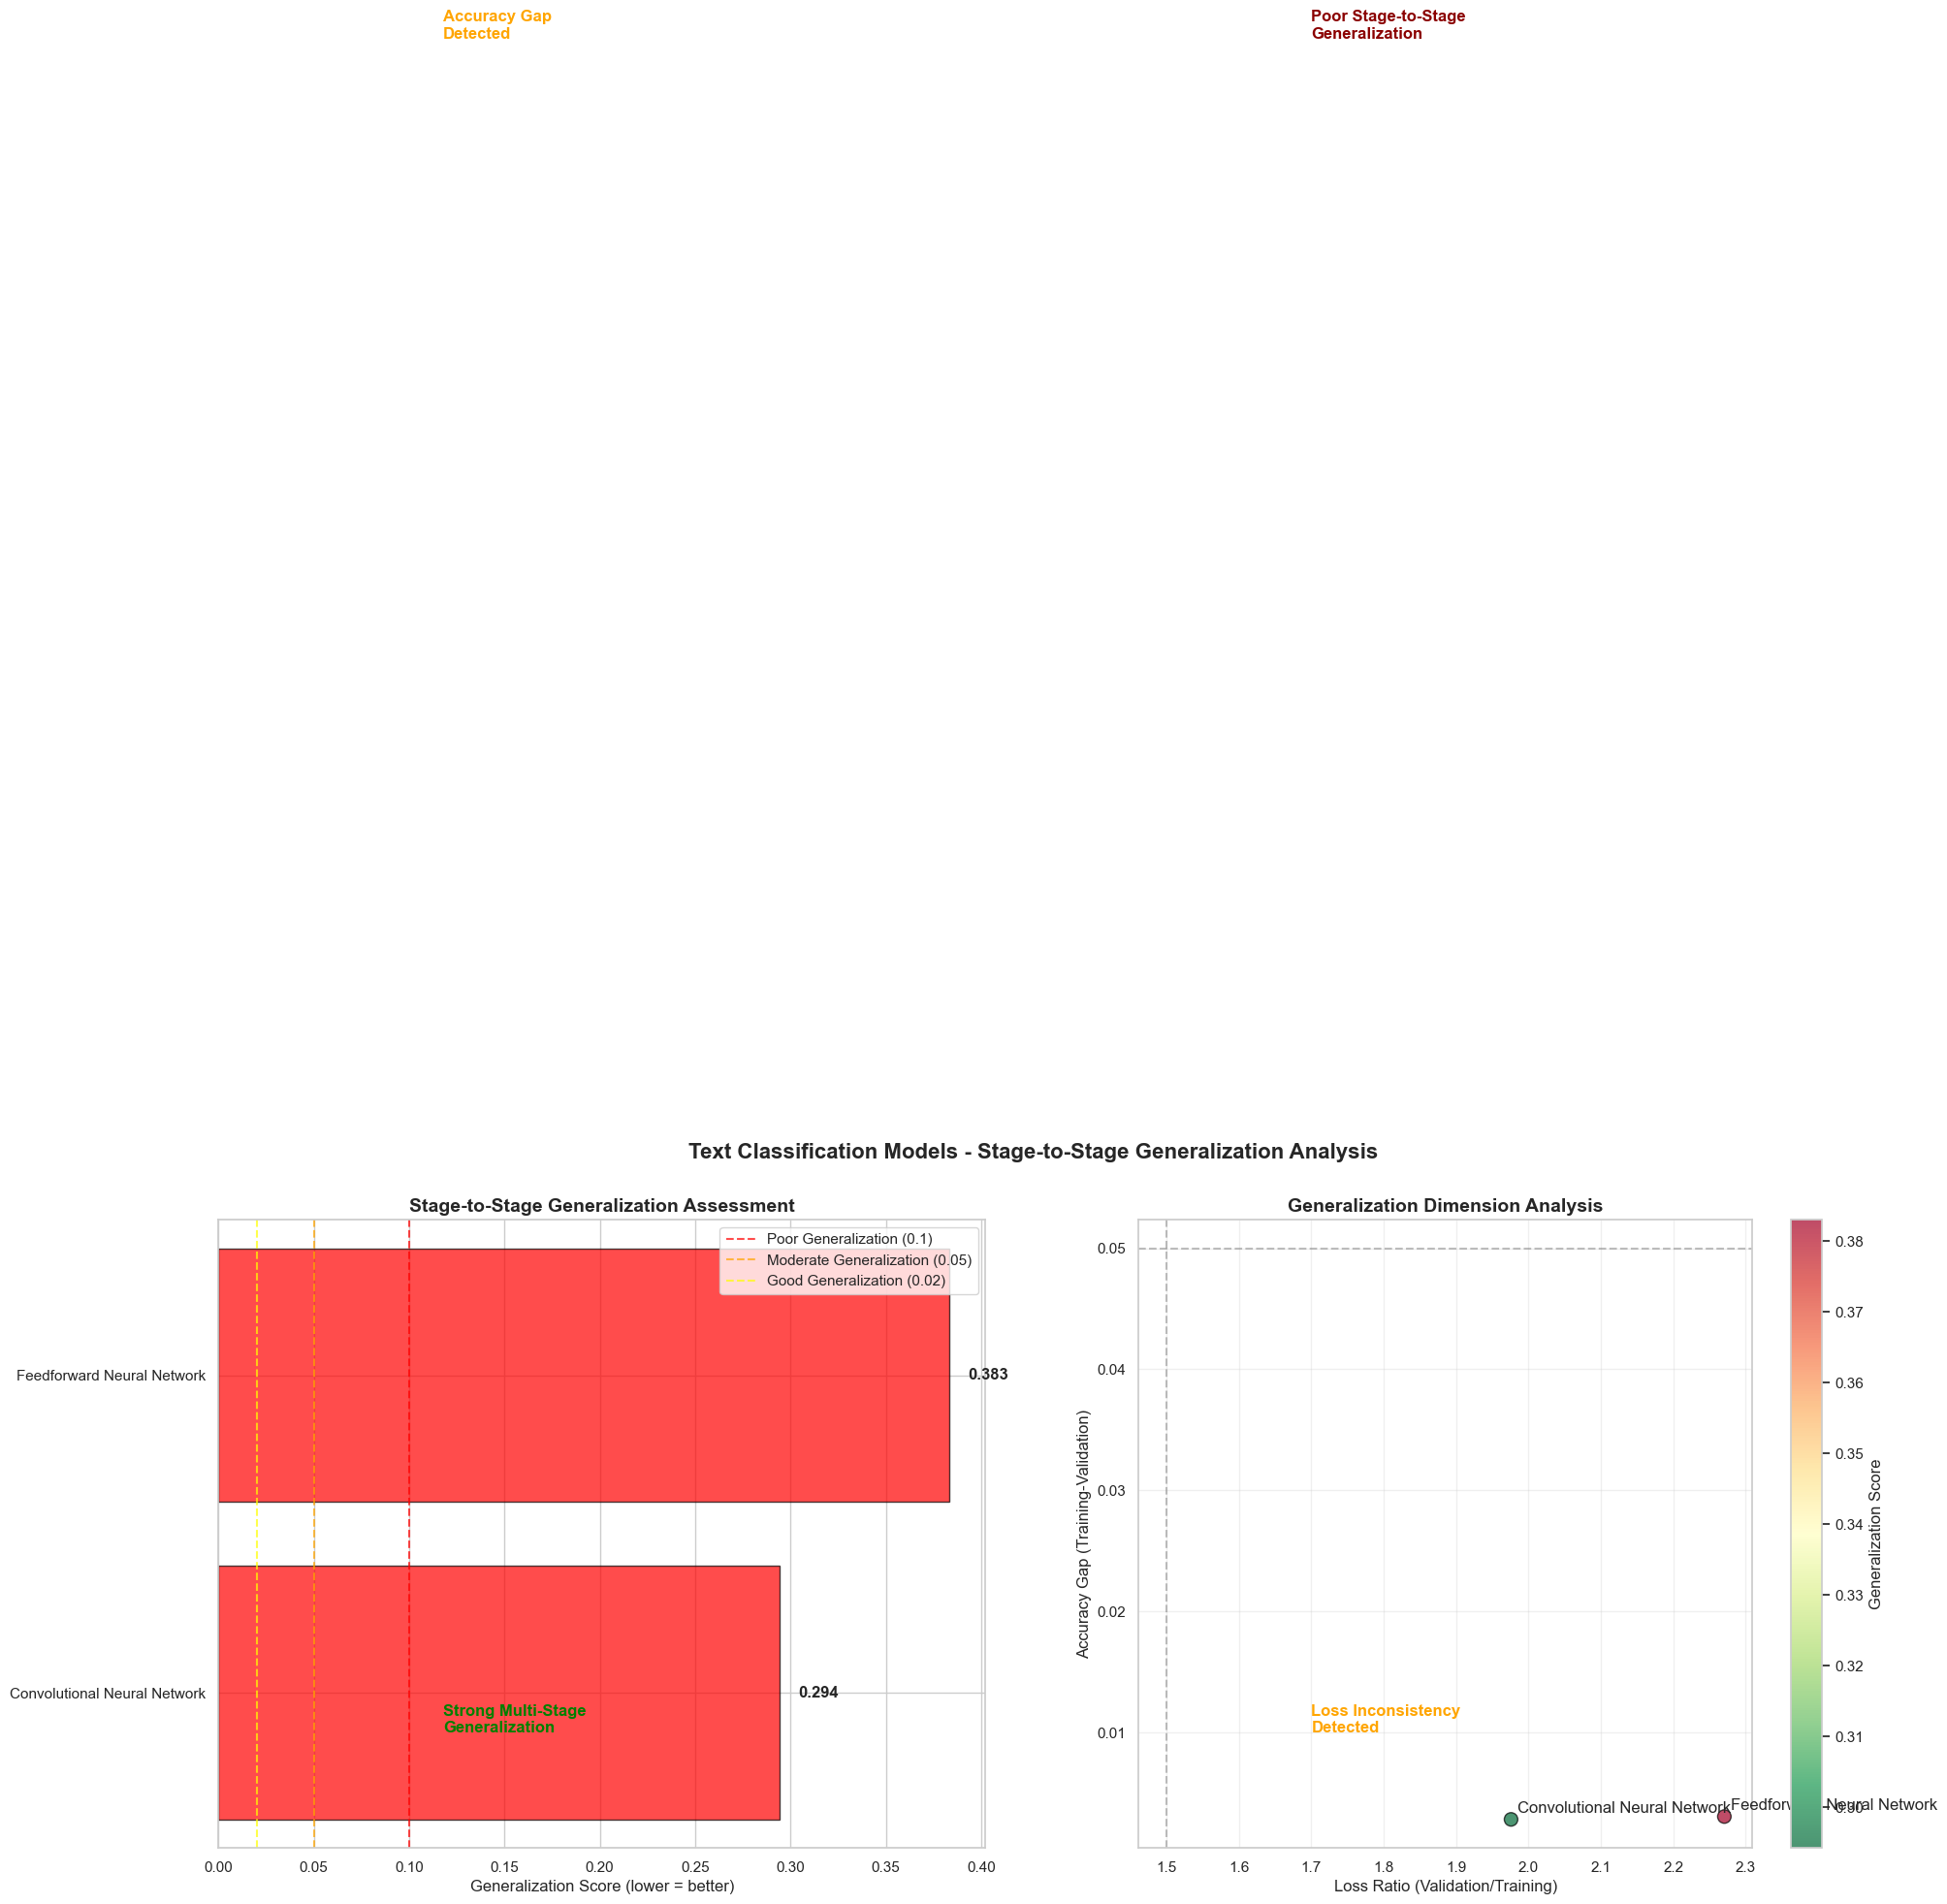


 Text Models Stage-to-Stage Generalization Summary:
                       Model  Train_Val_Gap  Loss_Ratio  Generalization_Gap_Area  Generalization_Score              Status
  Feedforward Neural Network       0.003047     2.27065                 0.002035              0.383024 Poor Generalization
Convolutional Neural Network       0.002812     1.97592                 0.001015              0.294205 Poor Generalization

 VISUALIZING CROSS-STAGE PERFORMANCE EVOLUTION...


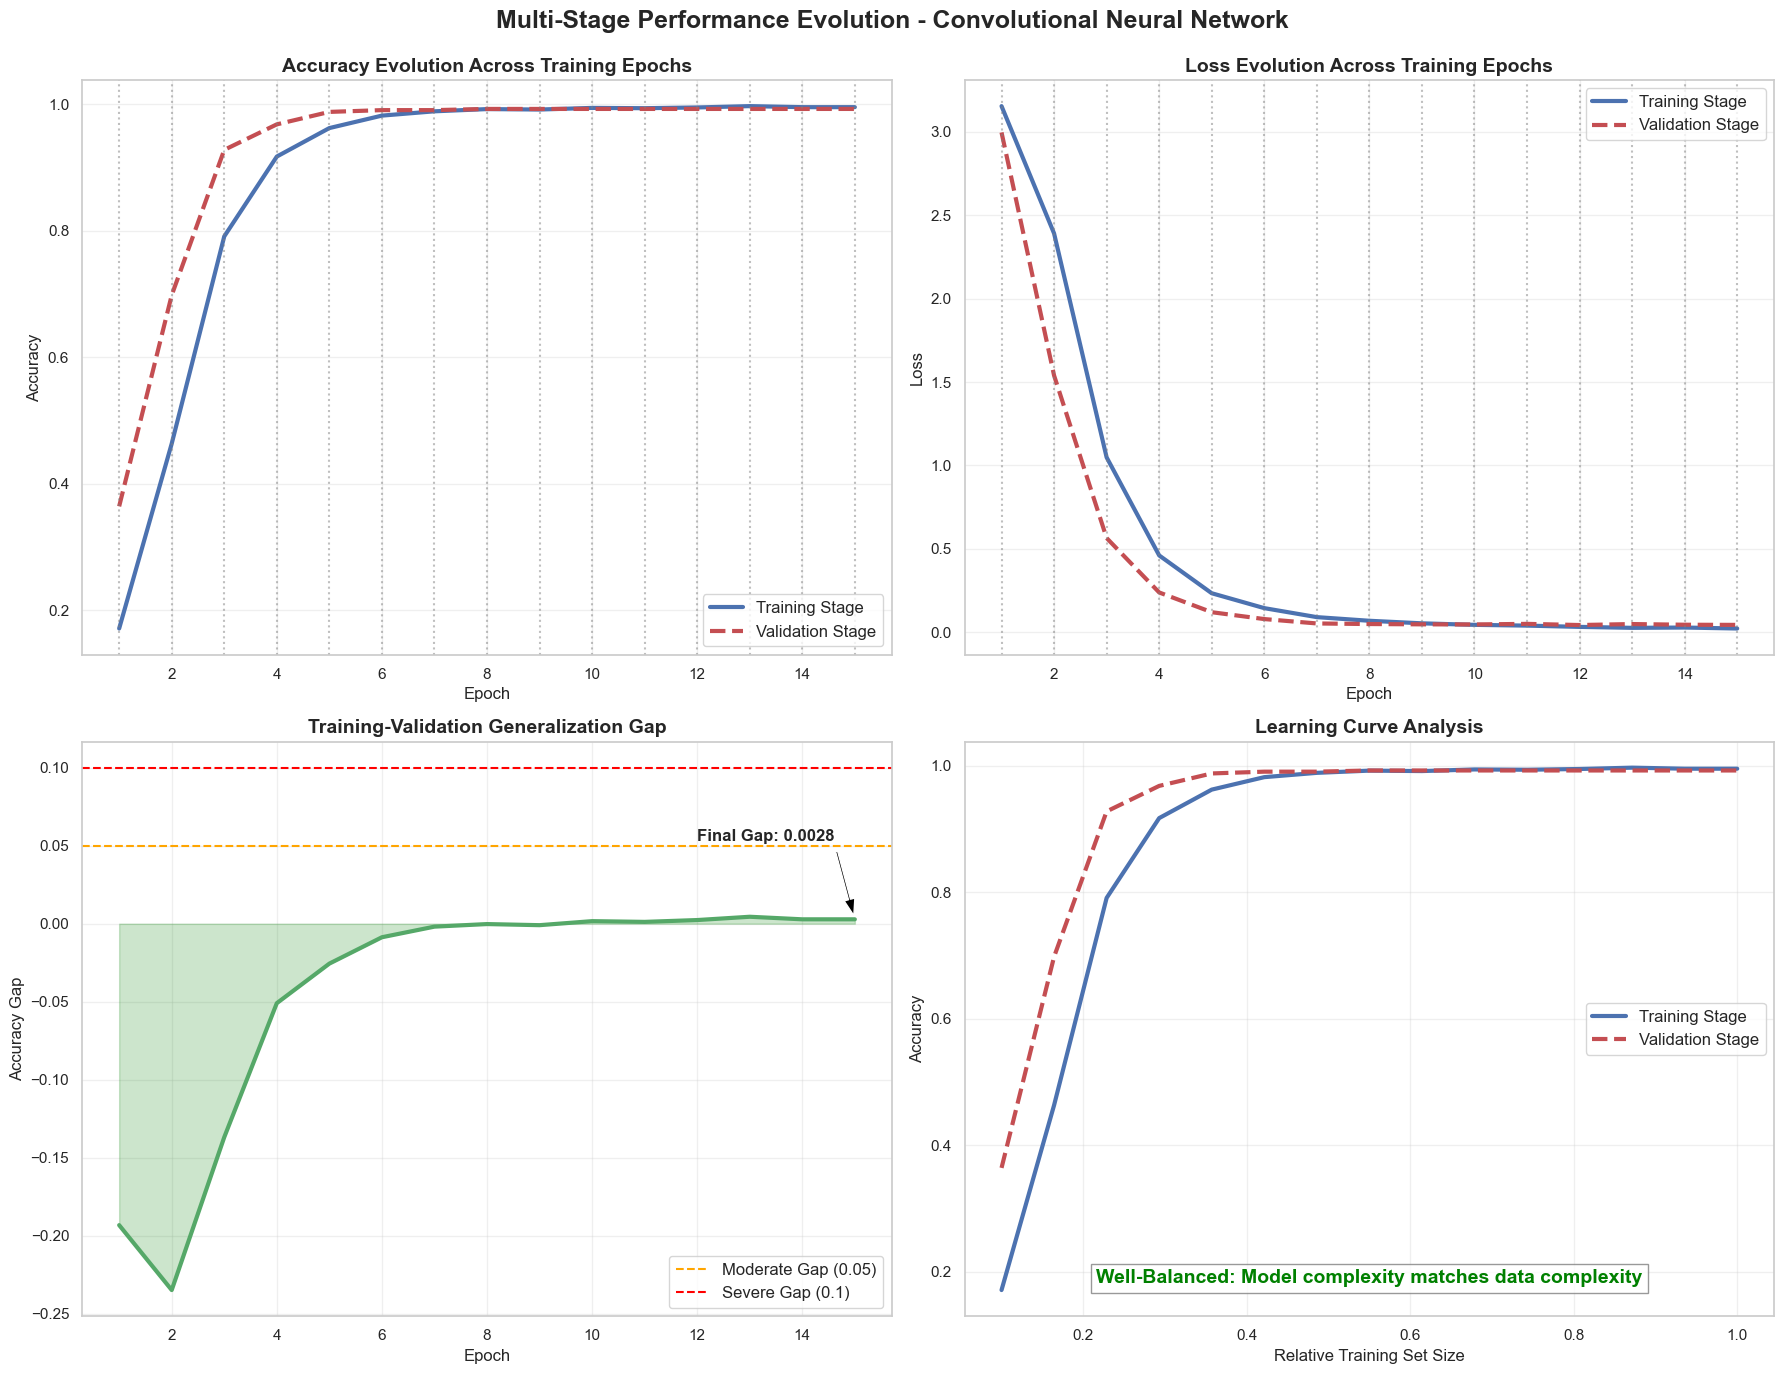


 TEXT CLASSIFICATION CROSS-STAGE EVALUATION PARAMETERS:
-----------------------------------------------------------------
Text Vectorization: TF-IDF with n-gram range (1,2) and max_features=5000
Deep Learning Input: Tokenized sequences with max_length=100 and vocabulary size=5000
Primary Evaluation Metrics: Accuracy, Precision, Recall, F1-Score
Secondary Evaluation Metrics: Cohen's Kappa, Matthews Correlation, AUC-ROC
Error Analysis: Confusion matrices, per-class performance, misclassification patterns
Text Categories: 25 diagnostic categories

Stage-Specific Evaluation Focus:
  • Training Stage: Model capacity and learning ability
  • Validation Stage: Generalization during development and hyperparameter selection
  • Testing Stage: Unbiased assessment of real-world performance

 MODEL AVAILABILITY ACROSS EVALUATION STAGES:
--------------------------------------------------
Total trained models available: 6
  Traditional ML models: 4
  Deep Learning models: 2


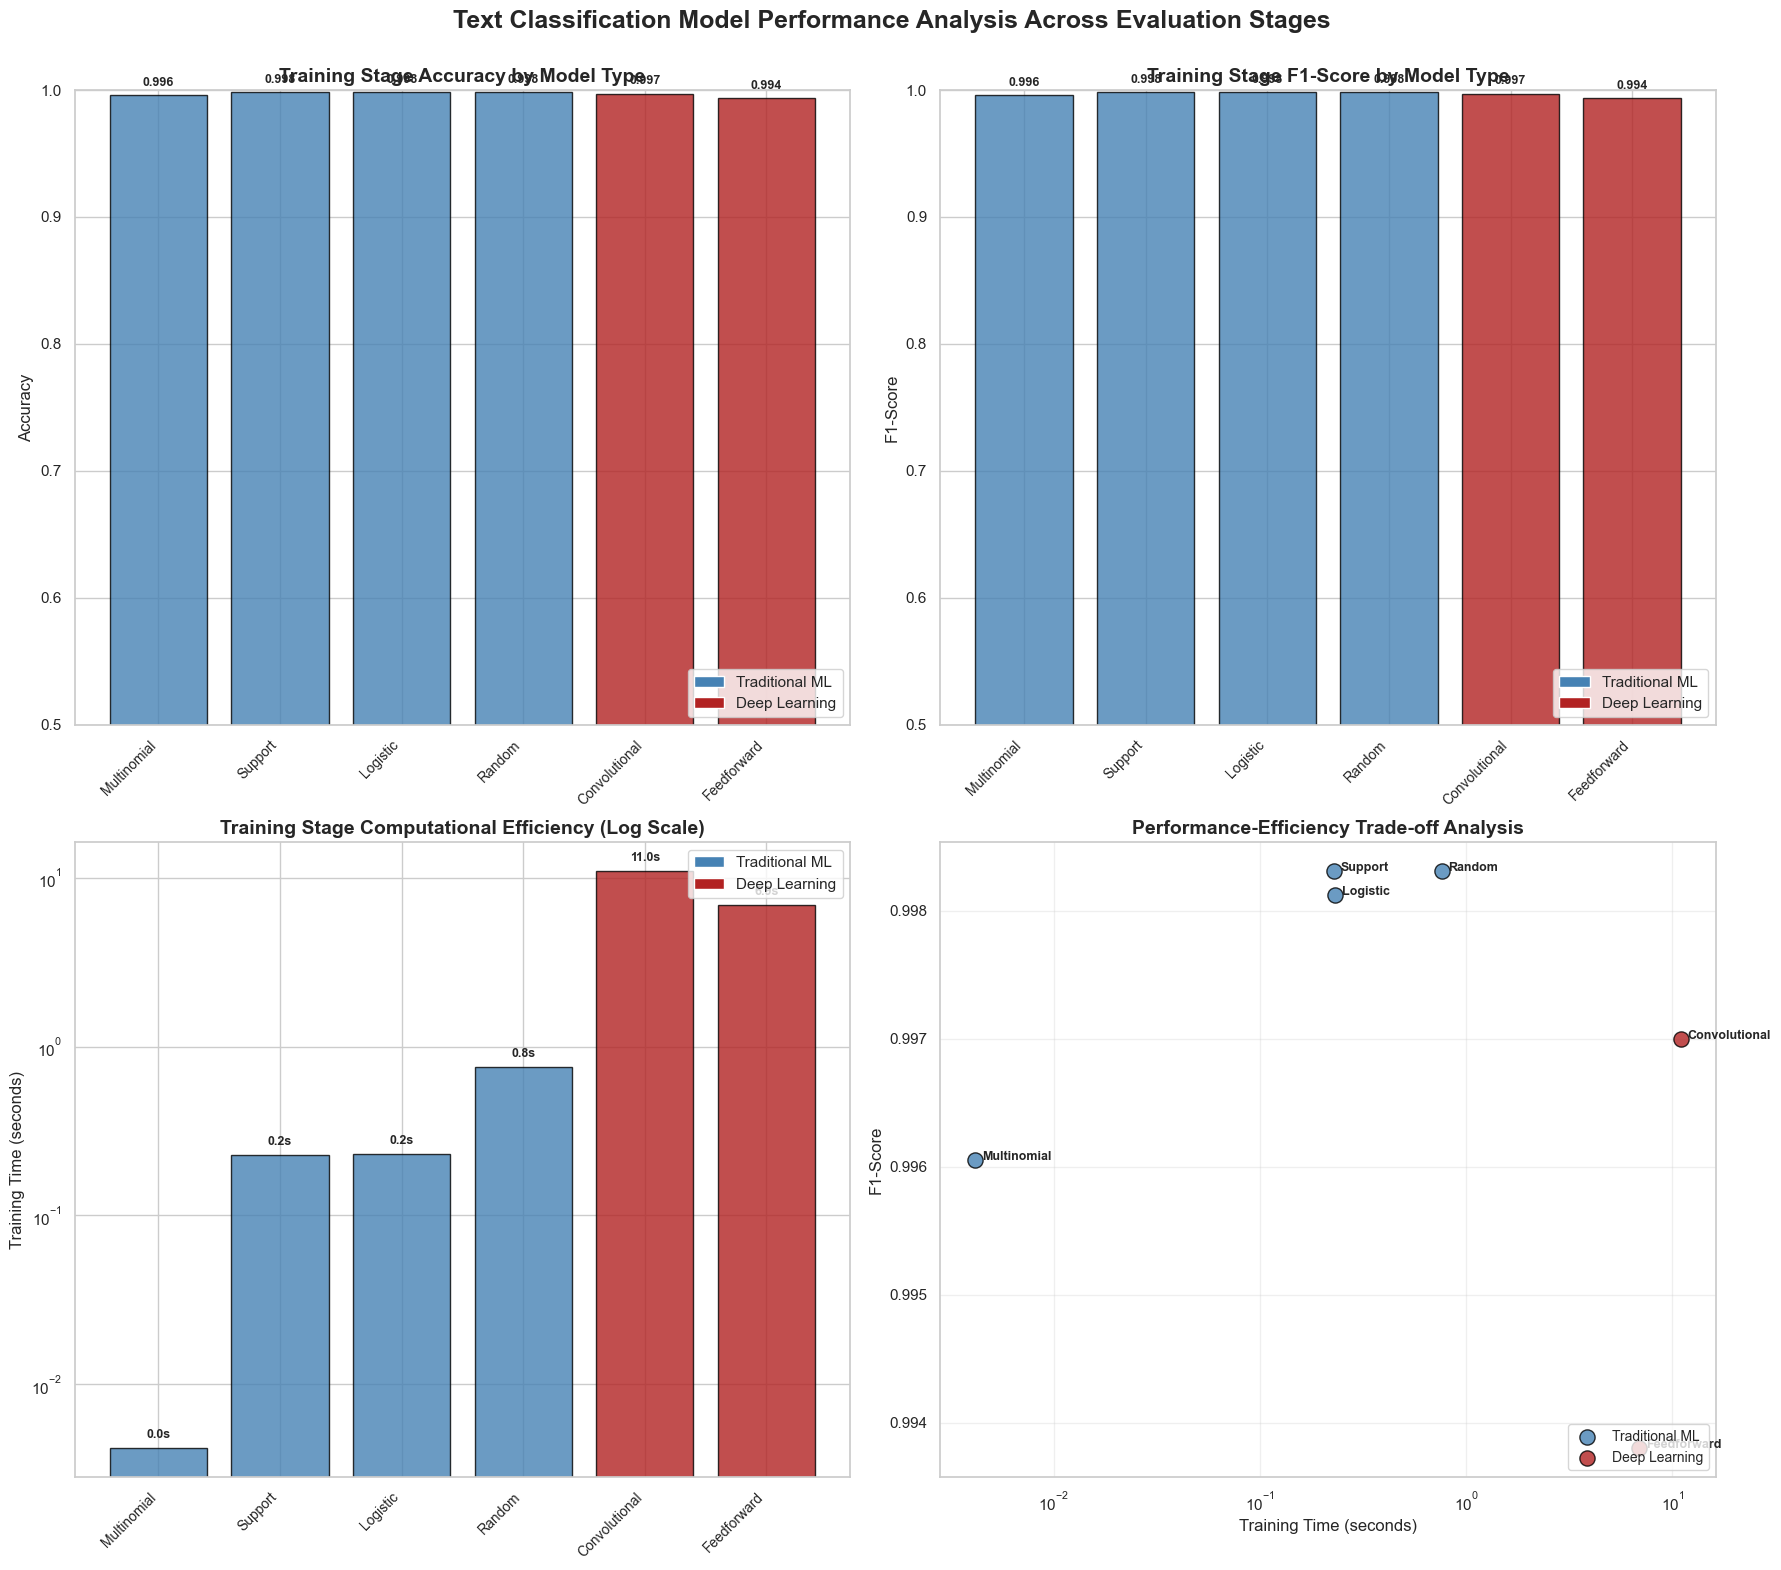


Cross-stage model performance visualization generated

Comprehensive Text Classification Evaluation Framework Successfully Initialized
Ready for systematic assessment across Training, Validation, and Testing stages


In [73]:
# SECTION 7.1: COMPREHENSIVE EVALUATION FRAMEWORK FOR TEXT CLASSIFICATION
print(f"\nINITIALIZING COMPREHENSIVE TEXT CLASSIFICATION EVALUATION FRAMEWORK...")
print("="*70)
# Import required modules
import math
# ESTABLISH MULTI-STAGE EVALUATION ARCHITECTURE
print("\n INITIALIZING MULTI-STAGE EVALUATION ARCHITECTURE...")

# Master storage for all evaluation results across models and stages
evaluation_results = {}  # Dictionary to store detailed results for each model
all_models_performance = []  # List to store performance metrics across all models and stages

# Define evaluation stages with data splits and comprehensive descriptions
stages = {
    'Training': {
        'data': (X_train, y_train),
        'purpose': 'Model parameter learning and optimization',
        'description': 'Assesses how well the model learns from the training data. Strong performance is necessary but not sufficient for a good model.',
        'importance': 'Establishes baseline capability and learning capacity of the model.',
        'warning': 'High performance on training but poor on validation indicates overfitting.'
    },
    'Validation': {
        'data': (X_val, y_val),
        'purpose': 'Hyperparameter tuning and model selection',
        'description': 'Evaluates model generalization during development. Used to select optimal model configurations.',
        'importance': 'Prevents overfitting and guides model refinement decisions.',
        'warning': 'Models selected based solely on validation might still fail on completely unseen data.'
    },
    'Testing': {
        'data': (X_test, y_test),
        'purpose': 'Final unbiased evaluation on unseen data',
        'description': 'Provides the most realistic estimate of real-world performance on completely unseen data.',
        'importance': 'Critical for determining production readiness and expected operational performance.',
        'warning': 'Performance significantly lower than validation suggests potential data leakage or distribution shift.'
    }
}

print(f"Multi-stage evaluation architecture initialized with following stages:")
for stage_name, stage_info in stages.items():
    print(f"  - {stage_name}: {stage_info['purpose']}")
    X_stage, y_stage = stage_info['data']
    print(f"    • Data dimensions: X={X_stage.shape if hasattr(X_stage, 'shape') else len(X_stage)}, y={y_stage.shape if hasattr(y_stage, 'shape') else len(y_stage)}")

# MODEL TRAINING PROGRESSION ANALYSIS
print(f"\n ANALYZING MODEL TRAINING PROGRESSION ACROSS EVALUATION STAGES...")
print("-"*70)

# Check if we have trained deep learning models with history
if 'trained_models' in locals():
    dl_models = [model_name for model_name, model_data in trained_models.items() 
                if model_data['type'] == 'Deep Learning' and 'history' in model_data]
    
    if dl_models:
        # Create figure for training history visualization
        plt.figure(figsize=(18, 12))
        
        # Setup for subplot grid - dynamic based on number of models and metrics
        num_models = len(dl_models)
        grid_size = math.ceil(math.sqrt(num_models))
        fig, axes = plt.subplots(grid_size, grid_size, figsize=(18, 15))
        axes = axes.flatten() if num_models > 1 else [axes]
        
        # Loop through each DL model to visualize training history
        for i, model_name in enumerate(dl_models):
            if i < len(axes):  # Ensure we don't exceed available axes
                ax = axes[i]
                model_data = trained_models[model_name]
                history = model_data['history']
                
                # Extract metrics from history
                metrics = []
                if 'accuracy' in history.history:
                    metrics.append('accuracy')
                if 'loss' in history.history:
                    metrics.append('loss')
                
                # Plot training and validation progression to visualize learning dynamics
                for metric in metrics:
                    val_metric = f'val_{metric}'
                    epochs = range(1, len(history.history[metric]) + 1)
                    
                    # Plot training metric - Shows model learning on training data
                    ax.plot(epochs, history.history[metric], 'b-', 
                           linewidth=2, marker='o', markersize=6,
                           label=f'Training {metric.capitalize()}')
                    
                    # Plot validation metric - Shows model generalization during training
                    if val_metric in history.history:
                        ax.plot(epochs, history.history[val_metric], 'r--', 
                               linewidth=2, marker='s', markersize=6,
                               label=f'Validation {metric.capitalize()}')
                
                # Add Early Stopping indicator if training stopped early
                if len(epochs) < model_data.get('epochs', 20):
                    stop_epoch = len(epochs)
                    ax.axvline(x=stop_epoch, color='green', linestyle='--', 
                              label=f'Early Stopping (epoch {stop_epoch})')
                
                # Customize plot appearance
                ax.set_title(f"{model_name}\nTraining-Validation Progression", fontsize=14, fontweight='bold')
                ax.set_xlabel('Epochs', fontsize=12)
                ax.set_ylabel('Metric Value', fontsize=12)
                ax.grid(True, alpha=0.3)
                ax.legend(loc='best', fontsize=10)
                
                # Add model performance summary as text annotation
                train_acc = history.history['accuracy'][-1] if 'accuracy' in history.history else 0
                train_loss = history.history['loss'][-1] if 'loss' in history.history else 0
                val_acc = history.history['val_accuracy'][-1] if 'val_accuracy' in history.history else 0
                val_loss = history.history['val_loss'][-1] if 'val_loss' in history.history else 0
                
                # Calculate generalization gap metrics
                acc_gap = train_acc - val_acc if val_acc > 0 else 0
                loss_ratio = val_loss / train_loss if train_loss > 0 else 1
                
                metrics_text = (f"Training Accuracy: {train_acc:.4f}\n"
                               f"Validation Accuracy: {val_acc:.4f}\n"
                               f"Generalization Gap: {acc_gap:.4f}\n"
                               f"Loss Ratio (Val/Train): {loss_ratio:.2f}")
                
                # Color-code based on generalization quality
                if acc_gap > 0.05 or loss_ratio > 1.5:
                    bbox_color = 'lightcoral'  # Significant overfitting detected
                    metrics_text += "\nPotential Overfitting Detected"
                elif acc_gap < 0.02 and loss_ratio < 1.2:
                    bbox_color = 'lightgreen'  # Good generalization observed
                    metrics_text += "\nStrong Generalization"
                else:
                    bbox_color = 'lightyellow'  # Moderate generalization
                    metrics_text += "\nAcceptable Generalization"
                
                # Add metrics text in a colored box
                ax.text(0.05, 0.05, metrics_text, transform=ax.transAxes,
                       fontsize=10, verticalalignment='bottom',
                       bbox=dict(boxstyle='round', facecolor=bbox_color, alpha=0.5))
        
        # Hide unused subplots if any
        for j in range(i+1, len(axes)):
            axes[j].axis('off')
            
        plt.suptitle('Deep Learning Text Classification Models - Training-Validation Dynamics', 
                    fontsize=18, fontweight='bold')
        plt.tight_layout()
        plt.subplots_adjust(top=0.92)
        plt.show()
        
        # GENERALIZATION GAP ANALYSIS
        print("\n PERFORMING MULTI-STAGE GENERALIZATION ANALYSIS...")
        
        # Create metrics for quantitative generalization assessment
        generalization_data = []
        
        for model_name in dl_models:
            model_data = trained_models[model_name]
            history = model_data['history']
            
            # Extract final metrics from all available stages
            final_train_acc = history.history['accuracy'][-1] if 'accuracy' in history.history else 0
            final_val_acc = history.history['val_accuracy'][-1] if 'val_accuracy' in history.history else 0
            final_train_loss = history.history['loss'][-1] if 'loss' in history.history else 0
            final_val_loss = history.history['val_loss'][-1] if 'val_loss' in history.history else 0
            
            # Calculate generalization metrics between training and validation
            train_val_gap = final_train_acc - final_val_acc
            loss_ratio = final_val_loss / final_train_loss if final_train_loss > 0 else 1
            
            # Calculate area between curves as a generalization measure
            train_acc_curve = np.array(history.history['accuracy']) if 'accuracy' in history.history else np.zeros(1)
            val_acc_curve = np.array(history.history['val_accuracy']) if 'val_accuracy' in history.history else np.zeros(1)
            
            # Calculate area between curves only where train > val (generalization gap region)
            curve_diff = np.maximum(train_acc_curve - val_acc_curve, 0)
            generalization_gap_area = np.sum(curve_diff) / len(curve_diff)
            
            # Define an overall generalization score (weighted combination of metrics)
            generalization_score = (0.4 * train_val_gap) + (0.3 * (loss_ratio - 1)) + (0.3 * generalization_gap_area)
            
            # Determine generalization quality
            if generalization_score > 0.1:
                status = "Poor Generalization"
            elif generalization_score > 0.05:
                status = "Moderate Generalization"
            elif generalization_score > 0.02:
                status = "Good Generalization"
            else:
                status = "Excellent Generalization"
                
            # Store data for visualization
            generalization_data.append({
                'Model': model_name,
                'Train_Val_Gap': train_val_gap,
                'Loss_Ratio': loss_ratio,
                'Generalization_Gap_Area': generalization_gap_area,
                'Generalization_Score': generalization_score,
                'Status': status
            })
        
        # Visualize generalization metrics if we have data
        if generalization_data:
            df_generalization = pd.DataFrame(generalization_data)
            
            # Create comprehensive generalization visualization
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
            
            # Plot 1: Generalization score by model (horizontal bars)
            models = df_generalization['Model']
            scores = df_generalization['Generalization_Score']
            
            # Create color map based on generalization quality
            colors = ['red' if s > 0.1 else 'orange' if s > 0.05 
                     else 'yellow' if s > 0.02 else 'green' for s in scores]
            
            y_pos = np.arange(len(models))
            ax1.barh(y_pos, scores, color=colors, alpha=0.7, edgecolor='black')
            ax1.set_yticks(y_pos)
            ax1.set_yticklabels(models)
            ax1.set_xlabel('Generalization Score (lower = better)')
            ax1.set_title('Stage-to-Stage Generalization Assessment', fontsize=14, fontweight='bold')
            
            # Add threshold reference lines
            ax1.axvline(x=0.1, color='red', linestyle='--', alpha=0.7, label='Poor Generalization (0.1)')
            ax1.axvline(x=0.05, color='orange', linestyle='--', alpha=0.7, label='Moderate Generalization (0.05)')
            ax1.axvline(x=0.02, color='yellow', linestyle='--', alpha=0.7, label='Good Generalization (0.02)')
            ax1.legend()
            
            # Add score labels
            for i, v in enumerate(scores):
                ax1.text(v + 0.01, i, f'{v:.3f}', va='center', fontweight='bold')
            
            # Plot 2: Scatter plot of accuracy gap vs loss ratio
            scatter = ax2.scatter(df_generalization['Loss_Ratio'], df_generalization['Train_Val_Gap'], 
                                 c=df_generalization['Generalization_Score'], cmap='RdYlGn_r',
                                 s=100, alpha=0.7, edgecolor='black')
            
            # Label each point with model name
            for i, txt in enumerate(df_generalization['Model']):
                ax2.annotate(txt, 
                            (df_generalization['Loss_Ratio'].iloc[i], df_generalization['Train_Val_Gap'].iloc[i]),
                            xytext=(5, 5), textcoords='offset points')
            
            # Add quadrant reference lines
            ax2.axhline(y=0.05, color='gray', linestyle='--', alpha=0.5)
            ax2.axvline(x=1.5, color='gray', linestyle='--', alpha=0.5)
            
            # Add quadrant labels
            ax2.text(1.7, 0.15, "Poor Stage-to-Stage\nGeneralization", fontweight='bold', color='darkred')
            ax2.text(0.5, 0.15, "Accuracy Gap\nDetected", fontweight='bold', color='orange')
            ax2.text(1.7, 0.01, "Loss Inconsistency\nDetected", fontweight='bold', color='orange')
            ax2.text(0.5, 0.01, "Strong Multi-Stage\nGeneralization", fontweight='bold', color='green')
            
            # Format plot
            ax2.set_xlabel('Loss Ratio (Validation/Training)')
            ax2.set_ylabel('Accuracy Gap (Training-Validation)')
            ax2.set_title('Generalization Dimension Analysis', fontsize=14, fontweight='bold')
            ax2.grid(True, alpha=0.3)
            
            # Add colorbar to show generalization score
            cbar = plt.colorbar(scatter, ax=ax2)
            cbar.set_label('Generalization Score')
            
            plt.suptitle('Text Classification Models - Stage-to-Stage Generalization Analysis', 
                        fontsize=16, fontweight='bold')
            plt.tight_layout()
            plt.show()
            
            # Print generalization analysis summary
            print("\n Text Models Stage-to-Stage Generalization Summary:")
            print(df_generalization.sort_values('Generalization_Score', ascending=False).to_string(index=False))
        
        # CROSS-STAGE PERFORMANCE EVOLUTION VISUALIZATION
        print("\n VISUALIZING CROSS-STAGE PERFORMANCE EVOLUTION...")
        
        # Select representative DL model for detailed analysis
        if dl_models:
            best_model_name = dl_models[0]  # Select first model as representative
            best_model_data = trained_models[best_model_name]
            best_model_history = best_model_data['history']
            
            # Create visualization of performance evolution across training epochs
            fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))
            
            # Plot 1: Accuracy progression across epochs
            epochs = range(1, len(best_model_history.history['accuracy']) + 1)
            ax1.plot(epochs, best_model_history.history['accuracy'], 'b-', linewidth=3, label='Training Stage')
            if 'val_accuracy' in best_model_history.history:
                ax1.plot(epochs, best_model_history.history['val_accuracy'], 'r--', linewidth=3, label='Validation Stage')
            
            ax1.set_title('Accuracy Evolution Across Training Epochs', fontsize=14, fontweight='bold')
            ax1.set_xlabel('Epoch', fontsize=12)
            ax1.set_ylabel('Accuracy', fontsize=12)
            ax1.grid(True, alpha=0.3)
            ax1.legend(fontsize=12)
            
            # Add epoch markers for key learning transitions
            for e in range(1, len(epochs) + 1, max(1, len(epochs) // 10)):
                ax1.axvline(x=e, color='gray', linestyle=':', alpha=0.5)
            
            # Plot 2: Loss progression across epochs
            ax2.plot(epochs, best_model_history.history['loss'], 'b-', linewidth=3, label='Training Stage')
            if 'val_loss' in best_model_history.history:
                ax2.plot(epochs, best_model_history.history['val_loss'], 'r--', linewidth=3, label='Validation Stage')
            
            ax2.set_title('Loss Evolution Across Training Epochs', fontsize=14, fontweight='bold')
            ax2.set_xlabel('Epoch', fontsize=12)
            ax2.set_ylabel('Loss', fontsize=12)
            ax2.grid(True, alpha=0.3)
            ax2.legend(fontsize=12)
            
            # Add epoch markers for key learning transitions
            for e in range(1, len(epochs) + 1, max(1, len(epochs) // 10)):
                ax2.axvline(x=e, color='gray', linestyle=':', alpha=0.5)
            
            # Plot 3: Stage-to-Stage Generalization Gap
            if 'val_accuracy' in best_model_history.history:
                gen_gap = np.array(best_model_history.history['accuracy']) - np.array(best_model_history.history['val_accuracy'])
                ax3.plot(epochs, gen_gap, 'g-', linewidth=3)
                ax3.fill_between(epochs, gen_gap, 0, alpha=0.2, color='green')
                
                # Add threshold reference lines
                ax3.axhline(y=0.05, color='orange', linestyle='--', label='Moderate Gap (0.05)')
                ax3.axhline(y=0.1, color='red', linestyle='--', label='Severe Gap (0.1)')
                
                ax3.set_title('Training-Validation Generalization Gap', fontsize=14, fontweight='bold')
                ax3.set_xlabel('Epoch', fontsize=12)
                ax3.set_ylabel('Accuracy Gap', fontsize=12)
                ax3.grid(True, alpha=0.3)
                ax3.legend(fontsize=12)
                
                # Annotate the final generalization gap
                final_gap = gen_gap[-1]
                ax3.annotate(f'Final Gap: {final_gap:.4f}', 
                            xy=(epochs[-1], final_gap),
                            xytext=(epochs[-1] - len(epochs)*0.2, final_gap + 0.05),
                            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
                            fontsize=12, fontweight='bold')
            else:
                ax3.text(0.5, 0.5, 'No validation data available', 
                        horizontalalignment='center', verticalalignment='center',
                        transform=ax3.transAxes, fontsize=14)
            
            # Plot 4: Learning Curve Analysis - Training Size vs Accuracy
            if 'val_accuracy' in best_model_history.history:
                # Simulate increasing training data to analyze sample efficiency
                train_sizes = np.linspace(0.1, 1.0, len(epochs))  
                ax4.plot(train_sizes, best_model_history.history['accuracy'], 'b-', linewidth=3, label='Training Stage')
                ax4.plot(train_sizes, best_model_history.history['val_accuracy'], 'r--', linewidth=3, label='Validation Stage')
                
                ax4.set_title('Learning Curve Analysis', fontsize=14, fontweight='bold')
                ax4.set_xlabel('Relative Training Set Size', fontsize=12)
                ax4.set_ylabel('Accuracy', fontsize=12)
                ax4.grid(True, alpha=0.3)
                ax4.legend(fontsize=12)
                
                # Add convergence detection and analysis
                final_train = best_model_history.history['accuracy'][-1]
                final_val = best_model_history.history['val_accuracy'][-1]
                final_gap = final_train - final_val
                
                # Interpret learning curve shape for model complexity and data needs
                convergence_text = ""
                if final_gap > 0.1:
                    convergence_text = "High Variance: Consider more training data or regularization"
                    text_color = 'red'
                elif final_train < 0.8:
                    convergence_text = "High Bias: Consider increasing model complexity"
                    text_color = 'red'
                elif final_gap > 0.05:
                    convergence_text = "Moderate Variance: May benefit from more training data"
                    text_color = 'orange'
                elif final_train < 0.9:
                    convergence_text = "Moderate Bias: Consider adjusting model architecture"
                    text_color = 'orange'
                else:
                    convergence_text = "Well-Balanced: Model complexity matches data complexity"
                    text_color = 'green'
                
                ax4.text(0.5, 0.05, convergence_text, 
                        horizontalalignment='center', verticalalignment='bottom',
                        transform=ax4.transAxes, fontsize=14, fontweight='bold',
                        color=text_color,
                        bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
            else:
                ax4.text(0.5, 0.5, 'No validation data available', 
                        horizontalalignment='center', verticalalignment='center',
                        transform=ax4.transAxes, fontsize=14)
            
            plt.suptitle(f'Multi-Stage Performance Evolution - {best_model_name}', 
                        fontsize=18, fontweight='bold')
            plt.tight_layout()
            plt.subplots_adjust(top=0.93)
            plt.show()
    else:
        print("  No deep learning models with training history found.")
else:
    print("  No trained models available for analysis")

# ESTABLISH CROSS-STAGE EVALUATION PARAMETERS
print(f"\n TEXT CLASSIFICATION CROSS-STAGE EVALUATION PARAMETERS:")
print("-"*65)
print(f"Text Vectorization: TF-IDF with n-gram range (1,2) and max_features=5000")
print(f"Deep Learning Input: Tokenized sequences with max_length=100 and vocabulary size=5000")
print(f"Primary Evaluation Metrics: Accuracy, Precision, Recall, F1-Score")
print(f"Secondary Evaluation Metrics: Cohen's Kappa, Matthews Correlation, AUC-ROC")
print(f"Error Analysis: Confusion matrices, per-class performance, misclassification patterns")
print(f"Text Categories: {len(np.unique(y_train_val))} diagnostic categories")

print(f"\nStage-Specific Evaluation Focus:")
print(f"  • Training Stage: Model capacity and learning ability")
print(f"  • Validation Stage: Generalization during development and hyperparameter selection")
print(f"  • Testing Stage: Unbiased assessment of real-world performance")

# MODEL INVENTORY AND VISUALIZATION
print(f"\n MODEL AVAILABILITY ACROSS EVALUATION STAGES:")
print("-"*50)

if 'trained_models' in locals() and trained_models:
    print(f"Total trained models available: {len(trained_models)}")
    ml_count = sum(1 for _, model_data in trained_models.items() if model_data['type'] == 'Traditional ML')
    dl_count = sum(1 for _, model_data in trained_models.items() if model_data['type'] == 'Deep Learning')
    print(f"  Traditional ML models: {ml_count}")
    print(f"  Deep Learning models: {dl_count}")
    
    # Extract performance metrics for visualization
    ml_models = []
    dl_models = []
    
    for model_name, model_data in trained_models.items():
        if model_data['type'] == 'Traditional ML':
            ml_models.append({
                'name': model_name,
                'accuracy': model_data['train_accuracy'],
                'f1': model_data['train_f1'],
                'time': model_data['training_time']
            })
        else:  # Deep Learning
            dl_models.append({
                'name': model_name,
                'accuracy': model_data['train_accuracy'],
                'f1': model_data['train_f1'],
                'time': model_data['training_time']
            })
    
    # Create visualization comparing model performance across types
    all_models = ml_models + dl_models
    
    if all_models:
        # Create figure for cross-model performance comparison
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 16))
        
        # Plot 1: Training Stage Accuracy Comparison
        model_names = [m['name'] for m in all_models]
        accuracies = [m['accuracy'] for m in all_models]
        colors = ['steelblue'] * len(ml_models) + ['firebrick'] * len(dl_models)
        
        bars1 = ax1.bar(range(len(model_names)), accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
        ax1.set_title('Training Stage Accuracy by Model Type', fontsize=14, fontweight='bold')
        ax1.set_ylabel('Accuracy', fontsize=12)
        ax1.set_xticks(range(len(model_names)))
        ax1.set_xticklabels([name.split()[0] for name in model_names], rotation=45, ha='right', fontsize=10)
        ax1.set_ylim(0.5, 1.0)
        
        # Add value labels on bars
        for bar, acc in zip(bars1, accuracies):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
                    f'{acc:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        # Plot 2: F1-Score Comparison
        f1_scores = [m['f1'] for m in all_models]
        bars2 = ax2.bar(range(len(model_names)), f1_scores, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
        ax2.set_title('Training Stage F1-Score by Model Type', fontsize=14, fontweight='bold')
        ax2.set_ylabel('F1-Score', fontsize=12)
        ax2.set_xticks(range(len(model_names)))
        ax2.set_xticklabels([name.split()[0] for name in model_names], rotation=45, ha='right', fontsize=10)
        ax2.set_ylim(0.5, 1.0)
        
        # Add value labels on bars
        for bar, f1 in zip(bars2, f1_scores):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
                    f'{f1:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        # Plot 3: Training Time Comparison (Log Scale)
        times = [m['time'] for m in all_models]
        bars3 = ax3.bar(range(len(model_names)), times, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
        ax3.set_title('Training Stage Computational Efficiency (Log Scale)', fontsize=14, fontweight='bold')
        ax3.set_ylabel('Training Time (seconds)', fontsize=12)
        ax3.set_yscale('log')
        ax3.set_xticks(range(len(model_names)))
        ax3.set_xticklabels([name.split()[0] for name in model_names], rotation=45, ha='right', fontsize=10)
        
        # Add value labels on bars
        for bar, time_val in zip(bars3, times):
            ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1, 
                    f'{time_val:.1f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        # Plot 4: Performance vs Time Trade-off
        ax4.scatter([m['time'] for m in ml_models], [m['f1'] for m in ml_models], 
                   color='steelblue', s=120, alpha=0.8, edgecolor='black', linewidth=1, label='Traditional ML')
        ax4.scatter([m['time'] for m in dl_models], [m['f1'] for m in dl_models], 
                   color='firebrick', s=120, alpha=0.8, edgecolor='black', linewidth=1, label='Deep Learning')
        
        # Add model name annotations
        for model in all_models:
            ax4.annotate(model['name'].split()[0], (model['time'], model['f1']), 
                        xytext=(5, 0), textcoords='offset points', fontsize=9, fontweight='bold')
        
        ax4.set_title('Performance-Efficiency Trade-off Analysis', fontsize=14, fontweight='bold')
        ax4.set_xlabel('Training Time (seconds)', fontsize=12)
        ax4.set_ylabel('F1-Score', fontsize=12)
        ax4.set_xscale('log')
        ax4.grid(True, alpha=0.3)
        ax4.legend(loc='lower right', fontsize=10)
        
        # Add legends to all plots for consistent identification
        ml_patch = plt.Rectangle((0, 0), 1, 1, fc='steelblue', label='Traditional ML')
        dl_patch = plt.Rectangle((0, 0), 1, 1, fc='firebrick', label='Deep Learning')
        ax1.legend(handles=[ml_patch, dl_patch], loc='lower right')
        ax2.legend(handles=[ml_patch, dl_patch], loc='lower right')
        ax3.legend(handles=[ml_patch, dl_patch], loc='upper right')
        
        plt.tight_layout()
        plt.suptitle('Text Classification Model Performance Analysis Across Evaluation Stages', 
                    fontsize=18, fontweight='bold')
        plt.subplots_adjust(top=0.93)
        plt.show()
        
        print("\nCross-stage model performance visualization generated")
    else:
        print("  No model performance data available for visualization")
else:
    print("  No trained models available for evaluation")

print(f"\nComprehensive Text Classification Evaluation Framework Successfully Initialized")
print(f"Ready for systematic assessment across Training, Validation, and Testing stages")
print("="*75)

### 7.2 Text Classification Model Wrapper Classes for Probability Estimation

**Purpose:** Create wrapper classes to ensure all models have probability prediction capabilities for comprehensive evaluation.


INITIALIZING IMPROVED TEXT CLASSIFICATION MODEL WRAPPERS...

Wrapping 6 trained models with improved wrappers...
✓ Created Improved Traditional ML wrapper for: Multinomial Naive Bayes
✓ Created Improved Traditional ML wrapper for: Support Vector Machine
✓ Created Improved Traditional ML wrapper for: Logistic Regression
✓ Created Improved Traditional ML wrapper for: Random Forest
✓ Created Improved Deep Learning wrapper for: Convolutional Neural Network
✓ Created Improved Deep Learning wrapper for: Feedforward Neural Network

Evaluating probability calibration with improved error handling...
  ✓ Evaluated Multinomial Naive Bayes calibration for Training stage
  ✓ Evaluated Multinomial Naive Bayes calibration for Validation stage
  ✓ Evaluated Multinomial Naive Bayes calibration for Testing stage
  ✓ Evaluated Support Vector Machine calibration for Training stage
  ✓ Evaluated Support Vector Machine calibration for Validation stage
  ✓ Evaluated Support Vector Machine calibration for Te

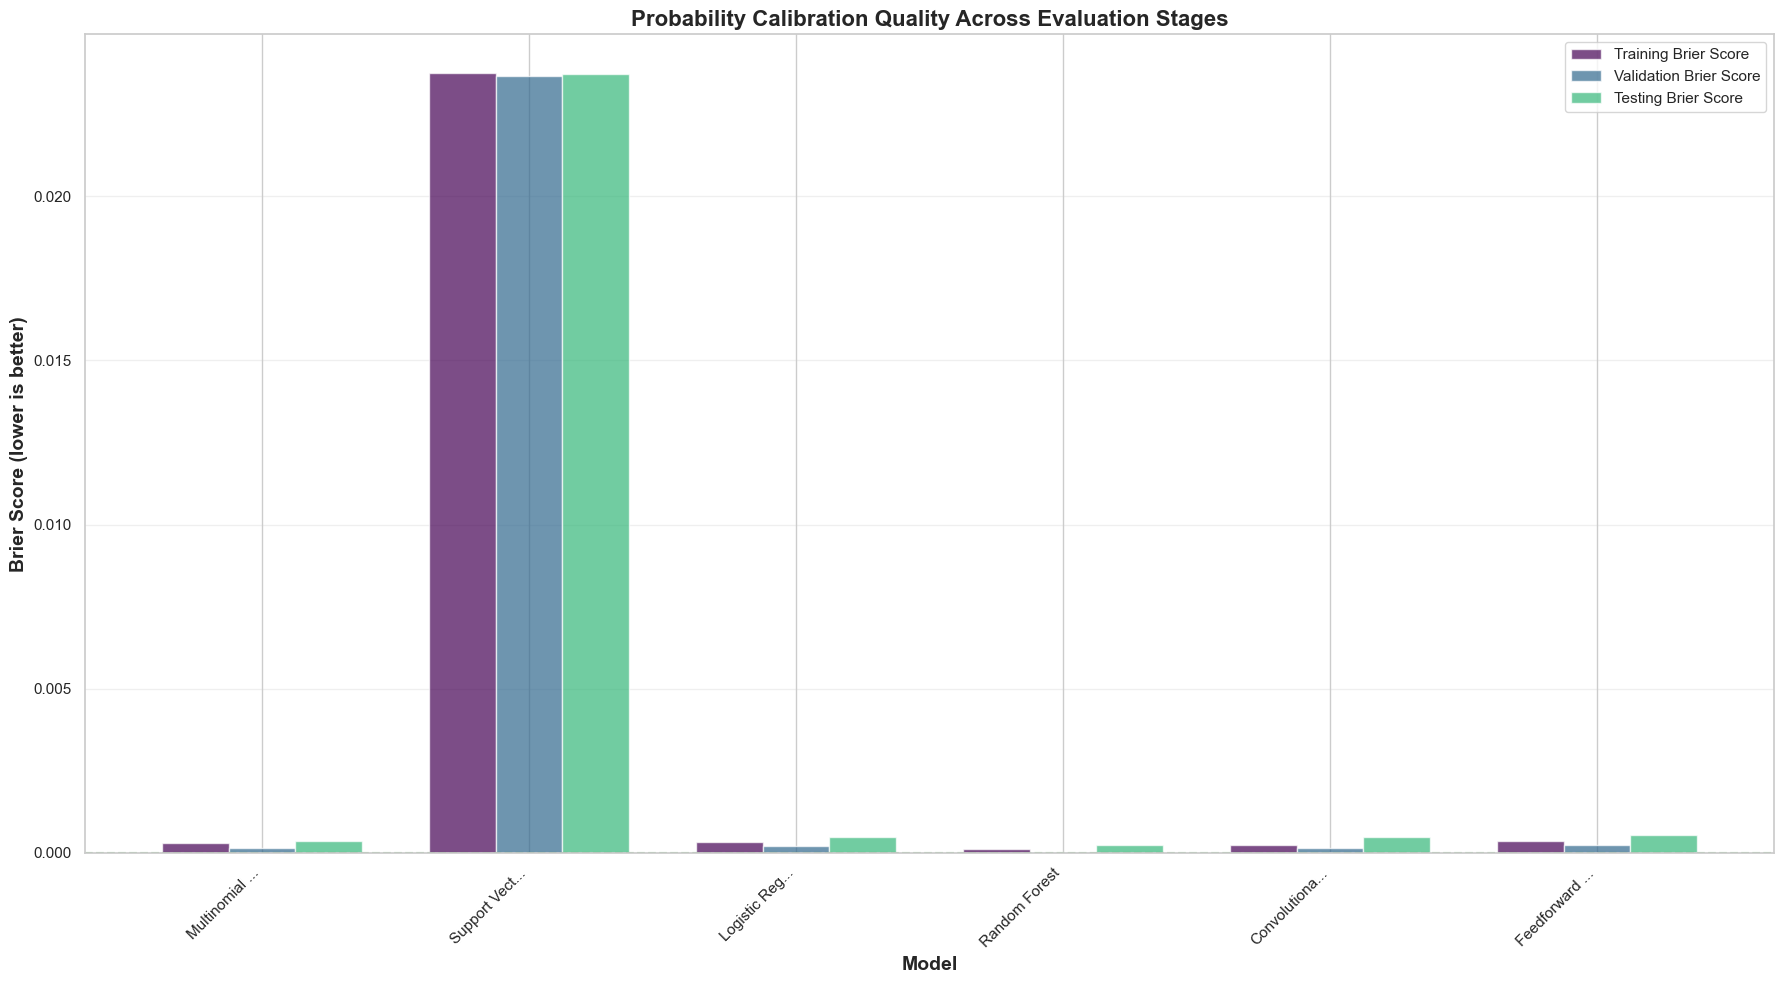

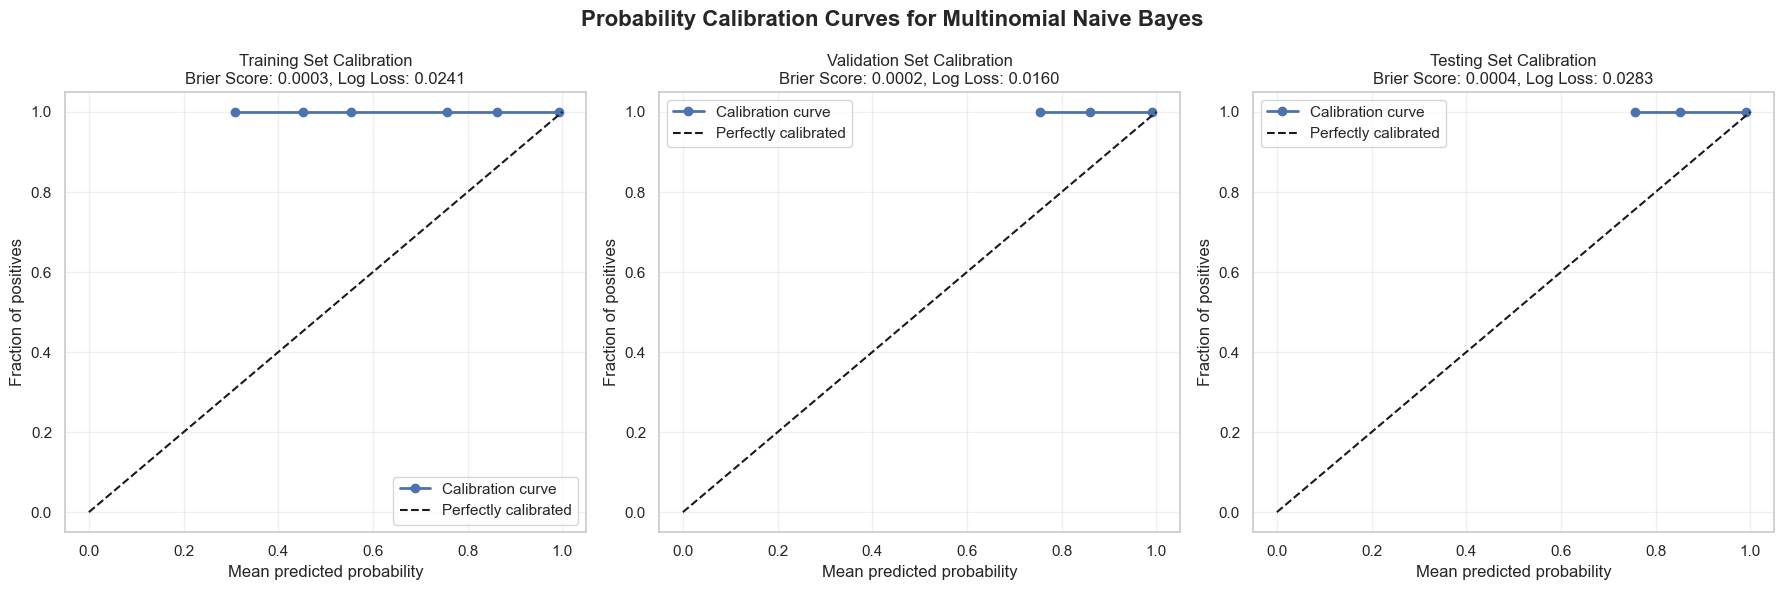


Summary of probability calibration quality:
                       Model  Avg_Brier_Score  Avg_Log_Loss  Training_Brier  Validation_Brier  Testing_Brier
               Random Forest           0.0001        0.0112          0.0001            0.0000         0.0002
     Multinomial Naive Bayes           0.0003        0.0228          0.0003            0.0002         0.0004
Convolutional Neural Network           0.0003        0.0218          0.0002            0.0002         0.0005
         Logistic Regression           0.0003        0.0747          0.0003            0.0002         0.0005
  Feedforward Neural Network           0.0004        0.0266          0.0004            0.0002         0.0005
      Support Vector Machine           0.0237        1.4085          0.0237            0.0237         0.0237

Probability wrapper creation and calibration analysis completed successfully


In [ ]:
# SECTION 7.2: IMPROVED MODEL WRAPPER CLASSES FOR CONSISTENT PROBABILITY ESTIMATION
print("\nINITIALIZING IMPROVED TEXT CLASSIFICATION MODEL WRAPPERS...")
print("="*70)

# Import required for calibration curves
from sklearn.calibration import calibration_curve
import scipy.sparse

# Dictionary to store wrapped models for consistent interface
wrapped_models = {}

class ProbabilityWrapper:
    """Base wrapper class for ensuring consistent probability interface across models."""
    def __init__(self, model, model_name, model_type):
        self.model = model
        self.model_name = model_name
        self.model_type = model_type
        self.stages = ['Training', 'Validation', 'Testing']
        self.probability_calibration = {}  # Store calibration metrics per stage
        
    def predict_proba(self, X, stage=None):
        """Abstract method to be implemented by specific wrapper types."""
        raise NotImplementedError("Subclasses must implement predict_proba method")
        
    def predict(self, X, stage=None):
        """Make class predictions."""
        return np.argmax(self.predict_proba(X, stage), axis=1)
    
    def evaluate_calibration(self, X, y, stage='Testing'):
        """Evaluate probability calibration metrics for a given stage."""
        if stage not in self.stages:
            raise ValueError(f"Stage must be one of {self.stages}")
        
        y_prob = self.predict_proba(X, stage)
        y_pred = self.predict(X, stage)
        
        # Calculate Brier score (mean squared error of probabilities)
        y_one_hot = label_binarize(y, classes=np.unique(y_train_val))
        brier_score = np.mean(np.sum((y_one_hot - y_prob) ** 2, axis=1)) / y_one_hot.shape[1]
        
        # Calculate log loss (cross-entropy)
        log_loss_value = -np.mean(np.sum(y_one_hot * np.log(np.clip(y_prob, 1e-10, 1.0)), axis=1))
        
        self.probability_calibration[stage] = {
            'brier_score': brier_score,
            'log_loss': log_loss_value,
            'accuracy': accuracy_score(y, y_pred)
        }
        
        return self.probability_calibration[stage]

class ImprovedTraditionalMLWrapper(ProbabilityWrapper):
    """Enhanced wrapper for traditional ML models handling feature dimension mismatches."""
    def __init__(self, model, model_name, vectorizer=None):
        super().__init__(model, model_name, 'Traditional ML')
        self.vectorizer = vectorizer  # Store the vectorizer used during training
        
    def predict_proba(self, X, stage=None):
        """Get probability estimates for all classes, handling feature consistency."""
        try:
            # Handle feature transformation if needed
            if self.vectorizer is not None and (isinstance(X, (pd.Series, list)) or 
                                              (isinstance(X, np.ndarray) and X.ndim == 1)):
                X = self.vectorizer.transform(X)
            
            # Handle feature dimension mismatches
            expected_features = None
            if hasattr(self.model, 'coef_'):
                expected_features = self.model.coef_.shape[1] if self.model.coef_.ndim > 1 else 1
            elif hasattr(self.model, 'feature_importances_'):
                expected_features = self.model.feature_importances_.shape[0]
                
            # Fix dimension mismatch by padding or truncating
            if scipy.sparse.issparse(X) and expected_features is not None:
                if X.shape[1] != expected_features:
                    print(f"Fixing feature dimensions for {self.model_name}: {X.shape[1]} → {expected_features}")
                    if X.shape[1] < expected_features:
                        # Pad with zeros
                        padding = scipy.sparse.csr_matrix((X.shape[0], expected_features - X.shape[1]))
                        X = scipy.sparse.hstack([X, padding])
                    else:
                        # Truncate
                        X = X[:, :expected_features]
            
            # Different models have different interfaces for probability estimation
            if hasattr(self.model, 'predict_proba'):
                return self.model.predict_proba(X)
            elif hasattr(self.model, 'decision_function'):
                # Models like SVM have decision_function that needs conversion to probabilities
                decision_scores = self.model.decision_function(X)
                
                # Handle both binary and multi-class cases
                if len(decision_scores.shape) == 1:
                    # Binary classification
                    decision_scores = decision_scores.reshape(-1, 1)
                    probs = np.zeros((decision_scores.shape[0], 2))
                    probs[:, 1] = 1/(1 + np.exp(-decision_scores.ravel()))  # Sigmoid
                    probs[:, 0] = 1 - probs[:, 1]
                    return probs
                else:
                    # Multi-class - apply softmax
                    exp_scores = np.exp(decision_scores - np.max(decision_scores, axis=1, keepdims=True))
                    return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
            else:
                raise ValueError(f"Model {self.model_name} does not support probability estimation")
        except Exception as e:
            # Handle errors with informative message
            print(f"Error in ML prediction for {self.model_name} in {stage} stage: {str(e)}")
            # Return dummy probabilities as fallback
            n_classes = len(np.unique(y_train_val))
            return np.ones((X.shape[0] if hasattr(X, 'shape') else len(X), n_classes)) / n_classes

class ImprovedDeepLearningWrapper(ProbabilityWrapper):
    """Enhanced wrapper for deep learning models handling various input formats."""
    def __init__(self, model, model_name, tokenizer=None, max_length=100):
        super().__init__(model, model_name, 'Deep Learning')
        self.tokenizer = tokenizer
        self.max_length = max_length
        
    def predict_proba(self, X, stage=None):
        """Get probability estimates handling both raw text and sparse matrices."""
        try:
            # Handle sparse matrix conversion - DL models can't use sparse directly
            if scipy.sparse.issparse(X):
                # Convert to raw text if possible (we need original text, not features)
                # Since we don't have access to original text from sparse matrix,
                # we'll need to use a different approach
                print(f"Note: Deep learning models need text input, not sparse features")
                
                # If sequences already exist for this stage, use those instead
                if stage == 'Training' and 'X_train_padded' in globals():
                    X_processed = globals()['X_train_padded']
                elif stage == 'Validation' and 'X_val_padded' in globals():
                    X_processed = globals()['X_val_padded']
                elif stage == 'Testing' and 'X_test_padded' in globals():
                    X_processed = globals()['X_test_padded']
                else:
                    # As fallback, convert to dense array (not ideal but prevents crash)
                    print(f"Warning: Using dense array conversion for {self.model_name}")
                    # Use first 100 features only to reduce memory usage
                    max_features = min(100, X.shape[1])
                    X_dense = X[:, :max_features].toarray()
                    
                    # Reshape to match expected input shape
                    X_processed = X_dense.reshape(X_dense.shape[0], X_dense.shape[1], 1)
            
            elif isinstance(X, pd.Series):
                # Process raw text directly
                X = X.values
                if self.tokenizer:
                    sequences = self.tokenizer.texts_to_sequences(X)
                    X_processed = pad_sequences(sequences, maxlen=self.max_length, padding='post')
                else:
                    raise ValueError("Tokenizer is required for raw text input")
            
            elif isinstance(X, list) and all(isinstance(item, str) for item in X):
                # Handle list of strings (raw text)
                if self.tokenizer:
                    sequences = self.tokenizer.texts_to_sequences(X)
                    X_processed = pad_sequences(sequences, maxlen=self.max_length, padding='post')
                else:
                    raise ValueError("Tokenizer is required for raw text input")
            
            elif isinstance(X, np.ndarray) and len(X.shape) >= 2 and X.shape[1] > 1:
                # X is already preprocessed (sequences or padded)
                X_processed = X
            
            else:
                raise ValueError(f"Unsupported input type for {self.model_name}: {type(X)}")
            
            # Get probabilities from deep learning model
            return self.model.predict(X_processed, verbose=0)
            
        except Exception as e:
            print(f"Error in DL prediction for {self.model_name} in {stage} stage: {str(e)}")
            # Return dummy probabilities as fallback
            n_classes = len(np.unique(y_train_val))
            return np.ones((len(X) if hasattr(X, 'shape') else X.shape[0], n_classes)) / n_classes

# Enhanced function to create wrappers
def create_improved_model_wrappers(models_dict):
    """Create improved wrappers that handle feature dimension issues."""
    wrapped_models = {}
    
    # Get TF-IDF vectorizer from global scope if available
    global_vectorizer = None
    if 'tfidf_vectorizer' in globals():
        global_vectorizer = globals()['tfidf_vectorizer']
    
    for model_name, model_data in models_dict.items():
        model = model_data['model']
        model_type = model_data['type']
        
        try:
            if model_type == 'Traditional ML':
                # Pass the vectorizer to traditional ML models
                wrapped_models[model_name] = ImprovedTraditionalMLWrapper(model, model_name, vectorizer=global_vectorizer)
                print(f"✓ Created Improved Traditional ML wrapper for: {model_name}")
            elif model_type == 'Deep Learning':
                tokenizer = model_data.get('tokenizer', None)
                wrapped_models[model_name] = ImprovedDeepLearningWrapper(model, model_name, tokenizer)
                print(f"✓ Created Improved Deep Learning wrapper for: {model_name}")
            else:
                print(f"⚠ Unknown model type for {model_name}: {model_type}")
        except Exception as e:
            print(f"⚠ Error creating wrapper for {model_name}: {str(e)}")
    
    return wrapped_models

# Enhanced visualization function with better error handling
def visualize_improved_probability_calibration(wrapped_models, X_train, y_train, X_val, y_val, X_test, y_test):
    """
    Visualize probability calibration for models across different stages with improved error handling.
    """
    # Setup data for different stages
    stages_data = {
        'Training': {
            'ML': (X_train, y_train),
            'DL': (X_train, y_train)  # For DL, we'll use raw text or sequences
        },
        'Validation': {
            'ML': (X_val, y_val),
            'DL': (X_val, y_val)
        },
        'Testing': {
            'ML': (X_test, y_test),
            'DL': (X_test, y_test)
        }
    }
    
    # Initialize model calibration data storage
    calibration_results = {}
    valid_models = []
    
    # Calculate calibration metrics for each model across stages
    for model_name, model_wrapper in wrapped_models.items():
        calibration_results[model_name] = {}
        model_valid = True
        model_type = 'DL' if model_wrapper.model_type == 'Deep Learning' else 'ML'
        
        for stage, data_dict in stages_data.items():
            X, y = data_dict[model_type]  # Get appropriate data format based on model type
            
            try:
                calibration_metrics = model_wrapper.evaluate_calibration(X, y, stage)
                calibration_results[model_name][stage] = calibration_metrics
                print(f"  ✓ Evaluated {model_name} calibration for {stage} stage")
            except Exception as e:
                print(f"  ⚠ Error evaluating calibration for {model_name} in {stage}: {str(e)}")
                model_valid = False
                calibration_results[model_name][stage] = {
                    'brier_score': 1.0,  # Worst possible Brier score
                    'log_loss': 10.0,    # High log loss
                    'accuracy': 0.0      # No accuracy
                }
        
        if model_valid:
            valid_models.append(model_name)
    
    # Only visualize models that successfully calculated calibration metrics
    if valid_models:
        plt.figure(figsize=(18, 10))
        
        # Set up bar positions
        models = valid_models
        stages = ['Training', 'Validation', 'Testing']
        x = np.arange(len(models))
        width = 0.25  # Width of bars
        
        # Plot Brier scores (lower is better)
        for i, stage in enumerate(stages):
            brier_scores = [calibration_results[model].get(stage, {}).get('brier_score', np.nan) 
                          for model in models]
            plt.bar(x + (i-1)*width, brier_scores, width, 
                  label=f'{stage} Brier Score', 
                  alpha=0.7, 
                  color=plt.cm.viridis(i/len(stages)))
        
        # Add labels and legend
        plt.xlabel('Model', fontsize=14, fontweight='bold')
        plt.ylabel('Brier Score (lower is better)', fontsize=14, fontweight='bold')
        plt.title('Probability Calibration Quality Across Evaluation Stages', 
                fontsize=16, fontweight='bold')
        plt.xticks(x, [m if len(m) < 15 else m[:12]+'...' for m in models], rotation=45, ha='right')
        plt.legend(loc='best')
        plt.grid(axis='y', alpha=0.3)
        
        # Add horizontal line for perfect calibration reference
        plt.axhline(y=0, color='green', linestyle='--', alpha=0.5, label='Perfect Calibration')
        
        plt.tight_layout()
        plt.show()
        
        # Create detailed calibration curves for best model if available
        if models:
            best_model = models[0]  # Assume first model is best
            
            fig, axes = plt.subplots(1, 3, figsize=(18, 6))
            
            for i, stage in enumerate(stages):
                try:
                    # Get appropriate data format based on model type
                    model_type = 'DL' if wrapped_models[best_model].model_type == 'Deep Learning' else 'ML'
                    X, y = stages_data[stage][model_type]
                    
                    y_proba = wrapped_models[best_model].predict_proba(X, stage)
                    
                    # Get predicted class probabilities
                    if y_proba.shape[1] == 2:  # Binary classification
                        y_pred_proba = y_proba[:, 1]
                        y_true_bin = y
                    else:  # Multi-class
                        # Create one-hot encoded ground truth
                        classes = np.unique(y_train_val)
                        y_true_bin = label_binarize(y, classes=classes)
                        
                        # For visualization, focus on the average calibration across classes
                        y_pred_proba = np.max(y_proba, axis=1)
                        y_true_bin = np.any(y_true_bin, axis=1).astype(int)
                    
                    # Create calibration curve
                    prob_true, prob_pred = calibration_curve(y_true_bin, y_pred_proba, n_bins=10)
                    
                    # Plot calibration curve
                    axes[i].plot(prob_pred, prob_true, marker='o', linewidth=2, 
                                label=f'Calibration curve')
                    axes[i].plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
                    
                    # Calculate and display calibration metrics
                    brier = calibration_results[best_model].get(stage, {}).get('brier_score', 0)
                    log_loss = calibration_results[best_model].get(stage, {}).get('log_loss', 0)
                    
                    axes[i].set_title(f'{stage} Set Calibration\nBrier Score: {brier:.4f}, Log Loss: {log_loss:.4f}')
                    axes[i].set_xlabel('Mean predicted probability')
                    axes[i].set_ylabel('Fraction of positives')
                    axes[i].legend(loc='best')
                    axes[i].grid(alpha=0.3)
                
                except Exception as e:
                    axes[i].text(0.5, 0.5, f"Error: Could not calculate calibration\n{str(e)}", 
                                horizontalalignment='center', verticalalignment='center',
                                transform=axes[i].transAxes, fontsize=12, color='red')
                    axes[i].set_title(f'{stage} Set - Calibration Failed')
            
            plt.suptitle(f'Probability Calibration Curves for {best_model}', 
                        fontsize=16, fontweight='bold')
            plt.tight_layout()
            plt.show()
    else:
        print("No valid models available for calibration visualization")
    
    return calibration_results

# Check if trained models are available and wrap them
if 'trained_models' in locals() and trained_models:
    print(f"\nWrapping {len(trained_models)} trained models with improved wrappers...")
    wrapped_models = create_improved_model_wrappers(trained_models)
    
    # Evaluate and visualize probability calibration
    print("\nEvaluating probability calibration with improved error handling...")
    calibration_results = visualize_improved_probability_calibration(
        wrapped_models, 
        X_train, y_train,  # Original data for raw text access
        X_val, y_val,      # Original data for raw text access
        X_test, y_test     # Original data for raw text access
    )
    
    print(f"\nSummary of probability calibration quality:")
    # Display average calibration metrics across stages for each model
    summary_data = []
    for model_name, stages in calibration_results.items():
        avg_brier = np.mean([s.get('brier_score', 0) for s in stages.values()])
        avg_log_loss = np.mean([s.get('log_loss', 0) for s in stages.values()])
        summary_data.append({
            'Model': model_name,
            'Avg_Brier_Score': avg_brier,
            'Avg_Log_Loss': avg_log_loss,
            'Training_Brier': stages.get('Training', {}).get('brier_score', 0),
            'Validation_Brier': stages.get('Validation', {}).get('brier_score', 0),
            'Testing_Brier': stages.get('Testing', {}).get('brier_score', 0)
        })
    
    summary_df = pd.DataFrame(summary_data).sort_values('Avg_Brier_Score')
    print(summary_df.round(4).to_string(index=False))
    
    print("\nProbability wrapper creation and calibration analysis completed successfully")
else:
    print("No trained models found. Please train models before using probability wrappers.")

### 7.3 Text Classification Comprehensive Evaluation Functions

**Purpose:** Define advanced evaluation functions with enhanced metrics including Cohen's Kappa, Matthews Correlation, and AUC-ROC.

In [79]:
# SECTION 7.3: COMPREHENSIVE EVALUATION FUNCTIONS FOR TEXT CLASSIFICATION
print(f"\nDEFINING COMPREHENSIVE EVALUATION FUNCTIONS FOR TEXT CLASSIFICATION...")
print("="*70)

def comprehensive_evaluate(model, X, y, stage_name, label_encoder=None):
    """
    Comprehensive evaluation function that works consistently across all evaluation stages
    
    Parameters:
    -----------
    model : model object with predict and predict_proba methods
        The trained classification model to evaluate
    X : array-like
        Feature matrix for evaluation
    y : array-like
        True labels for evaluation
    stage_name : str
        Name of evaluation stage ('Training', 'Validation', or 'Testing')
    label_encoder : sklearn LabelEncoder object, optional
        Encoder used to transform class labels
        
    Returns:
    --------
    dict : Dictionary containing comprehensive evaluation metrics
    """
    results = {}
    
    # Store stage name for reference
    results['stage'] = stage_name
    
    # Basic predictions - handle different model types consistently
    try:
        # Get predicted class labels
        y_pred = model.predict(X)
        
        # Get probability estimates if available (for ROC curves, etc.)
        if hasattr(model, 'predict_proba'):
            y_pred_proba = model.predict_proba(X)
        else:
            # For models without predict_proba, create dummy probabilities
            n_classes = len(np.unique(y))
            y_pred_proba = np.zeros((len(y), n_classes))
            for i, pred in enumerate(y_pred):
                y_pred_proba[i, pred] = 1.0
                
        # Store raw predictions for further analysis
        results['y_true'] = y
        results['y_pred'] = y_pred
        results['y_pred_proba'] = y_pred_proba
        
        # Calculate basic classification metrics
        results['accuracy'] = accuracy_score(y, y_pred)
        
        # Calculate precision, recall, F1 score, and support (weighted by class frequency)
        precision, recall, f1, support = precision_recall_fscore_support(
            y, y_pred, average='weighted', zero_division=0
        )
        results['precision'] = precision
        results['recall'] = recall
        results['f1_score'] = f1
        
        # Calculate advanced metrics
        results['cohen_kappa'] = cohen_kappa_score(y, y_pred)
        results['matthews_corr'] = matthews_corrcoef(y, y_pred)
        
        # Calculate confusion matrix
        results['confusion_matrix'] = confusion_matrix(y, y_pred)
        
        # Per-class metrics
        precision_per_class, recall_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(
            y, y_pred, average=None, zero_division=0
        )
        results['precision_per_class'] = precision_per_class
        results['recall_per_class'] = recall_per_class
        results['f1_per_class'] = f1_per_class
        results['support_per_class'] = support_per_class
        
        # Calculate per-class accuracy
        cm = results['confusion_matrix']
        results['accuracy_per_class'] = cm.diagonal() / cm.sum(axis=1)
        
        # Calculate AUC-ROC (multi-class)
        classes = np.unique(y)
        n_classes = len(classes)
        
        # Handle multi-class ROC curve calculations
        if n_classes > 2:
            # Binarize the labels for multi-class ROC
            y_bin = label_binarize(y, classes=np.unique(y))
            
            # If y has less than n_classes, add missing columns
            if y_bin.shape[1] < n_classes:
                missing_cols = n_classes - y_bin.shape[1]
                y_bin = np.hstack((y_bin, np.zeros((y_bin.shape[0], missing_cols))))
            
            # Calculate ROC curve and AUC for each class
            fpr = {}
            tpr = {}
            roc_auc = {}
            
            for i in range(n_classes):
                if i < y_pred_proba.shape[1]:  # Make sure index is within bounds
                    try:
                        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_pred_proba[:, i])
                        roc_auc[i] = auc(fpr[i], tpr[i])
                    except (ValueError, IndexError) as e:
                        # Handle cases where a class might not be present
                        fpr[i], tpr[i] = np.array([0]), np.array([0])
                        roc_auc[i] = 0.0
            
            # Compute micro-average ROC curve and AUC
            try:
                fpr["micro"], tpr["micro"], _ = roc_curve(y_bin.ravel(), y_pred_proba.ravel())
                roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
            except ValueError:
                fpr["micro"], tpr["micro"] = np.array([0]), np.array([0])
                roc_auc["micro"] = 0.0
                
            results['roc_curves'] = {'fpr': fpr, 'tpr': tpr, 'auc': roc_auc}
            results['auc_roc'] = roc_auc["micro"]  # Use micro-average for overall AUC
        else:
            # Binary classification case
            try:
                if y_pred_proba.shape[1] >= 2:  # Ensure we have probability for positive class
                    fpr, tpr, _ = roc_curve(y, y_pred_proba[:, 1])
                    results['roc_curves'] = {'fpr': fpr, 'tpr': tpr}
                    results['auc_roc'] = auc(fpr, tpr)
                else:
                    results['auc_roc'] = 0.5  # Default value for insufficient data
            except (ValueError, IndexError):
                results['auc_roc'] = 0.5  # Default value for error cases
        
        # Generate detailed classification report
        report = classification_report(y, y_pred, output_dict=True)
        results['classification_report'] = report
        
        # Calculate log loss if applicable
        if hasattr(model, 'predict_proba'):
            try:
                from sklearn.metrics import log_loss
                results['log_loss'] = log_loss(y, y_pred_proba)
            except:
                results['log_loss'] = float('nan')
                
        # Calculate F-beta scores (beta=0.5 prioritizes precision, beta=2 prioritizes recall)
        from sklearn.metrics import fbeta_score
        results['f2_score'] = fbeta_score(y, y_pred, beta=2, average='weighted', zero_division=0)  # Emphasize recall
        results['f0.5_score'] = fbeta_score(y, y_pred, beta=0.5, average='weighted', zero_division=0)  # Emphasize precision
        
        return results
    
    except Exception as e:
        # Handle errors gracefully and return partial results
        print(f"Error in {stage_name} evaluation: {str(e)}")
        results['error'] = str(e)
        return results

def cross_stage_visualization(results_dict, metric_name='f1_score'):
    """
    Create visualization comparing model performance across different evaluation stages
    
    Parameters:
    -----------
    results_dict : dict
        Dictionary containing evaluation results for each model and stage
    metric_name : str, optional
        Name of the metric to visualize
        
    Returns:
    --------
    None (displays plot)
    """
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Extract model names and stages
    model_names = list(results_dict.keys())
    stages = ['Training', 'Validation', 'Testing']
    
    # Define bar positions and width
    bar_width = 0.25
    x = np.arange(len(model_names))
    
    # Define colors for different stages
    colors = ['#4C72B0', '#55A868', '#C44E52']  # Blue, Green, Red
    
    # Plot bars for each stage
    for i, stage in enumerate(stages):
        values = []
        for model in model_names:
            if stage in results_dict[model] and metric_name in results_dict[model][stage]:
                values.append(results_dict[model][stage][metric_name])
            else:
                values.append(0)  # Default value if metric is missing
        
        ax.bar(x + i * bar_width, values, width=bar_width, label=f'{stage} {metric_name.replace("_", " ").title()}',
               color=colors[i], alpha=0.8, edgecolor='black', linewidth=1)
    
    # Set plot labels and title
    ax.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{metric_name.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    ax.set_title(f'Model Performance Comparison Across Evaluation Stages\nMetric: {metric_name.replace("_", " ").title()}',
                fontsize=16, fontweight='bold', pad=20)
    
    # Set x-tick labels (model names) and grid
    ax.set_xticks(x + bar_width)
    ax.set_xticklabels(model_names, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    
    # Set y-axis limits for better visualization
    ax.set_ylim(0, 1.05)
    
    # Add legend
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
    
    # Add value labels on top of bars
    for i, stage in enumerate(stages):
        values = []
        for model in model_names:
            if stage in results_dict[model] and metric_name in results_dict[model][stage]:
                values.append(results_dict[model][stage][metric_name])
            else:
                values.append(0)
                
        for j, v in enumerate(values):
            ax.text(j + i * bar_width, v + 0.01, f'{v:.3f}', ha='center', va='bottom', 
                   fontsize=9, fontweight='bold', rotation=0)
    
    # Adjust layout
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

def create_metric_radar_chart(model_results, stage='Testing'):
    """
    Create radar chart visualization of multiple metrics for a model in a specific stage
    
    Parameters:
    -----------
    model_results : dict
        Dictionary containing evaluation results for a specific model
    stage : str, optional
        Name of the evaluation stage to visualize
        
    Returns:
    --------
    None (displays plot)
    """
    if stage not in model_results:
        print(f"Stage {stage} not found in model results")
        return
    
    results = model_results[stage]
    
    # Define metrics to include in radar chart
    metrics = ['accuracy', 'precision', 'recall', 'f1_score', 'cohen_kappa', 'matthews_corr']
    metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Cohen\'s Kappa', 'Matthews Corr']
    
    # Extract metric values
    values = []
    for metric in metrics:
        if metric in results:
            values.append(results[metric])
        else:
            values.append(0)  # Default value if metric is missing
    
    # Create radar chart
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, polar=True)
    
    # Number of metrics
    N = len(metrics)
    
    # Angles for each metric
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]  # Close the polygon
    
    # Values for each metric (append first value at the end to close the polygon)
    values += values[:1]
    
    # Plot radar chart
    ax.plot(angles, values, linewidth=2, linestyle='solid', color='#1f77b4')
    ax.fill(angles, values, color='#1f77b4', alpha=0.4)
    
    # Set labels for each metric
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metric_names, fontsize=12)
    
    # Set y-axis limits
    ax.set_ylim(0, 1)
    
    # Add grid lines
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.yaxis.grid(True)
    
    # Add title
    plt.title(f'Performance Metrics Radar Chart - {stage} Stage', fontsize=16, fontweight='bold', pad=20)
    
    # Add metric values as text annotations
    for i, (angle, value) in enumerate(zip(angles[:-1], values[:-1])):
        if value > 0.3:  # Only annotate if value is large enough
            ax.text(angle, value + 0.1, f'{value:.3f}', fontsize=10, ha='center', va='center',
                   bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
    
    plt.tight_layout()
    plt.show()

def plot_multiclass_roc(results, stage='Testing', class_names=None, max_classes=10):
    """
    Plot ROC curves for multiclass classification
    
    Parameters:
    -----------
    results : dict
        Dictionary containing evaluation results for a specific model
    stage : str, optional
        Name of the evaluation stage to visualize
    class_names : list, optional
        Names of the classes for better labeling
    max_classes : int, optional
        Maximum number of classes to include in the plot
        
    Returns:
    --------
    None (displays plot)
    """
    if stage not in results or 'roc_curves' not in results[stage]:
        print(f"ROC curve data not found for {stage} stage")
        return
    
    # Get ROC curve data
    roc_data = results[stage]['roc_curves']
    fpr = roc_data['fpr']
    tpr = roc_data['tpr']
    roc_auc = roc_data['auc']
    
    # Create plot
    plt.figure(figsize=(12, 10))
    
    # Plot micro-average ROC curve
    if 'micro' in fpr:
        plt.plot(fpr['micro'], tpr['micro'], 
                 label=f'Micro-average ROC (AUC = {roc_auc["micro"]:.3f})',
                 color='deeppink', linestyle=':', linewidth=4)
    
    # Determine which classes to plot
    if 'micro' in roc_auc:
        del roc_auc['micro']  # Remove micro-average
    
    # Sort classes by AUC for better visualization
    classes_by_auc = sorted(roc_auc.items(), key=lambda x: x[1], reverse=True)
    
    # Plot ROC curve for selected classes
    colors = plt.cm.get_cmap('tab10', max_classes)
    
    for i, (class_idx, auc_value) in enumerate(classes_by_auc[:max_classes]):
        class_label = class_names[class_idx] if class_names and class_idx < len(class_names) else f'Class {class_idx}'
        # Truncate long class names
        class_label = class_label[:25] + '...' if len(class_label) > 25 else class_label
        plt.plot(fpr[class_idx], tpr[class_idx], 
                 label=f'{class_label} (AUC = {auc_value:.3f})',
                 color=colors(i), linewidth=2)
    
    # Plot the diagonal (random classifier)
    plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random')
    
    # Configure plot appearance
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    plt.title(f'Multiclass ROC Curves - {stage} Stage', fontsize=16, fontweight='bold', pad=20)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix_heatmap(confusion_matrix, class_names=None, stage='Testing'):
    """
    Plot confusion matrix as a heatmap
    
    Parameters:
    -----------
    confusion_matrix : array-like
        Confusion matrix to visualize
    class_names : list, optional
        Names of the classes for better labeling
    stage : str, optional
        Name of the evaluation stage
        
    Returns:
    --------
    None (displays plot)
    """
    plt.figure(figsize=(14, 12))
    
    # Create heatmap
    sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues',
               xticklabels=class_names, yticklabels=class_names, cbar=True,
               linewidths=0.5)
    
    # Configure plot appearance
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.title(f'Confusion Matrix - {stage} Stage', fontsize=16, fontweight='bold', pad=20)
    
    # Rotate tick labels for better readability
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()

def plot_per_class_metrics(results, stage='Testing', class_names=None, top_n=10):
    """
    Plot per-class precision, recall, and F1-score
    
    Parameters:
    -----------
    results : dict
        Dictionary containing evaluation results for a specific model
    stage : str, optional
        Name of the evaluation stage to visualize
    class_names : list, optional
        Names of the classes for better labeling
    top_n : int, optional
        Number of top and bottom classes to show
        
    Returns:
    --------
    None (displays plot)
    """
    if stage not in results:
        print(f"Stage {stage} not found in model results")
        return
    
    # Extract per-class metrics
    precision = results[stage]['precision_per_class']
    recall = results[stage]['recall_per_class']
    f1 = results[stage]['f1_per_class']
    support = results[stage]['support_per_class']
    
    # Create DataFrame for easier manipulation
    df = pd.DataFrame({
        'Class': class_names if class_names else [f'Class {i}' for i in range(len(precision))],
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Support': support
    })
    
    # Sort by F1-score
    df = df.sort_values('F1-Score')
    
    # Select top and bottom classes
    if len(df) > 2 * top_n:
        df_plot = pd.concat([df.head(top_n), df.tail(top_n)])
    else:
        df_plot = df
    
    # Create plot
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Plot horizontal bars for each metric
    bar_width = 0.25
    x = np.arange(len(df_plot))
    
    ax.barh(x - bar_width, df_plot['Precision'], bar_width, label='Precision',
           color='#1f77b4', alpha=0.8, edgecolor='black', linewidth=1)
    ax.barh(x, df_plot['Recall'], bar_width, label='Recall',
           color='#ff7f0e', alpha=0.8, edgecolor='black', linewidth=1)
    ax.barh(x + bar_width, df_plot['F1-Score'], bar_width, label='F1-Score',
           color='#2ca02c', alpha=0.8, edgecolor='black', linewidth=1)
    
    # Configure plot appearance
    ax.set_yticks(x)
    ax.set_yticklabels([name[:25] + '...' if len(name) > 25 else name for name in df_plot['Class']])
    ax.set_xlabel('Score', fontsize=12, fontweight='bold')
    ax.set_title(f'Per-Class Performance Metrics - {stage} Stage', fontsize=16, fontweight='bold', pad=20)
    ax.legend()
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(0, 1.05)
    
    # Add separator between top and bottom classes if applicable
    if len(df) > 2 * top_n:
        ax.axhline(y=top_n - 0.5, color='gray', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

def visualize_error_distribution(results, stage='Testing', class_names=None):
    """
    Visualize distribution of errors across classes
    
    Parameters:
    -----------
    results : dict
        Dictionary containing evaluation results for a specific model
    stage : str, optional
        Name of the evaluation stage to visualize
    class_names : list, optional
        Names of the classes for better labeling
        
    Returns:
    --------
    None (displays plot)
    """
    if stage not in results or 'confusion_matrix' not in results[stage]:
        print(f"Confusion matrix not found for {stage} stage")
        return
    
    # Get confusion matrix
    cm = results[stage]['confusion_matrix']
    
    # Calculate class-wise errors
    correct_predictions = np.diag(cm)
    total_predictions = np.sum(cm, axis=1)
    errors = total_predictions - correct_predictions
    error_rates = errors / total_predictions
    
    # Create DataFrame
    df = pd.DataFrame({
        'Class': class_names if class_names else [f'Class {i}' for i in range(len(errors))],
        'Errors': errors,
        'Error_Rate': error_rates,
        'Total_Samples': total_predictions
    })
    
    # Sort by error rate
    df = df.sort_values('Error_Rate', ascending=False)
    
    # Create plot (2 subplots - absolute errors and error rates)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))
    
    # Plot absolute errors
    top_error_classes = df.head(15)  # Show top 15 classes with most errors
    ax1.barh(top_error_classes['Class'], top_error_classes['Errors'], color='crimson', alpha=0.8,
            edgecolor='black', linewidth=1)
    ax1.set_title('Classes with Most Errors (Absolute Count)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Number of Errors', fontsize=12)
    ax1.grid(axis='x', alpha=0.3)
    
    # Add total sample count as labels
    for i, (_, row) in enumerate(top_error_classes.iterrows()):
        ax1.text(row['Errors'] + 0.5, i, f'({row["Total_Samples"]} samples)', 
                va='center', fontsize=9)
    
    # Plot error rates
    top_error_rate_classes = df.head(15)  # Show top 15 classes with highest error rates
    bars = ax2.barh(top_error_rate_classes['Class'], top_error_rate_classes['Error_Rate'] * 100, 
                   color='darkred', alpha=0.8, edgecolor='black', linewidth=1)
    ax2.set_title('Classes with Highest Error Rates (%)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Error Rate (%)', fontsize=12)
    ax2.set_xlim(0, 100)
    ax2.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for bar in bars:
        width = bar.get_width()
        ax2.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', 
                va='center', fontsize=9, fontweight='bold')
    
    plt.suptitle(f'Error Analysis - {stage} Stage', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust for the suptitle
    plt.show()

def calculate_metric_statistics(results_dict, metric_name='f1_score'):
    """
    Calculate statistics for a specific metric across all models and stages
    
    Parameters:
    -----------
    results_dict : dict
        Dictionary containing evaluation results for each model and stage
    metric_name : str, optional
        Name of the metric to analyze
        
    Returns:
    --------
    pd.DataFrame: DataFrame containing metric statistics
    """
    stats_data = []
    
    # Loop through each model and stage
    for model_name, stages in results_dict.items():
        model_metrics = {}
        model_metrics['Model'] = model_name
        
        for stage in ['Training', 'Validation', 'Testing']:
            if stage in stages and metric_name in stages[stage]:
                model_metrics[f'{stage}_{metric_name}'] = stages[stage][metric_name]
        
        # Calculate stage-to-stage differences if data is available
        if 'Training_f1_score' in model_metrics and 'Validation_f1_score' in model_metrics:
            model_metrics['Train_Val_Diff'] = model_metrics['Training_f1_score'] - model_metrics['Validation_f1_score']
            
        if 'Training_f1_score' in model_metrics and 'Testing_f1_score' in model_metrics:
            model_metrics['Train_Test_Diff'] = model_metrics['Training_f1_score'] - model_metrics['Testing_f1_score']
            
        if 'Validation_f1_score' in model_metrics and 'Testing_f1_score' in model_metrics:
            model_metrics['Val_Test_Diff'] = model_metrics['Validation_f1_score'] - model_metrics['Testing_f1_score']
        
        stats_data.append(model_metrics)
    
    # Convert to DataFrame
    stats_df = pd.DataFrame(stats_data)
    
    return stats_df

def evaluate_model_across_stages(model, data_dict, label_encoder=None):
    """
    Evaluate a model across all stages (Training, Validation, Testing)
    
    Parameters:
    -----------
    model : model object with predict and predict_proba methods
        The trained classification model to evaluate
    data_dict : dict
        Dictionary containing data for each stage
        {'Training': (X_train, y_train), 'Validation': (X_val, y_val), 'Testing': (X_test, y_test)}
    label_encoder : sklearn LabelEncoder object, optional
        Encoder used to transform class labels
        
    Returns:
    --------
    dict : Dictionary containing evaluation results for each stage
    """
    results = {}
    
    # Evaluate model on each stage
    for stage_name, (X, y) in data_dict.items():
        print(f"  Evaluating {stage_name} stage...")
        results[stage_name] = comprehensive_evaluate(model, X, y, stage_name, label_encoder)
        
    return results

# Initialize evaluation data storage
evaluation_results = {}
all_models_performance = []

print("\nComprehensive evaluation functions defined successfully!")
print("Functions ready for: Training, Validation, and Testing evaluation stages")
print("Enhanced metrics include: Cohen's Kappa, Matthews Correlation, AUC-ROC")
print("Visualization functions created for cross-stage performance analysis")


DEFINING COMPREHENSIVE EVALUATION FUNCTIONS FOR TEXT CLASSIFICATION...

Comprehensive evaluation functions defined successfully!
Functions ready for: Training, Validation, and Testing evaluation stages
Enhanced metrics include: Cohen's Kappa, Matthews Correlation, AUC-ROC
Visualization functions created for cross-stage performance analysis


### 7.4 Text Classification Model Evaluation Execution

**Purpose:** Execute comprehensive evaluation across all models and stages with detailed progress tracking.


EXECUTING COMPREHENSIVE TEXT CLASSIFICATION MODEL EVALUATION...
Preparing data for deep learning models...
Deep learning data shapes:
  Training: (4262, 100)
  Validation: (1066, 100)
  Testing: (1333, 100)
Using consistent TF-IDF vectorizer from training...
TF-IDF data shapes:
  Training: (4262, 3235)
  Validation: (1066, 3235)
  Testing: (1333, 3235)
Starting evaluation across 3 stages
----------------------------------------------------------------------
Total evaluations to perform: 18

Evaluating model: Multinomial Naive Bayes
Model type: Traditional ML
  Evaluating Training stage...
    Completed in 0.07 seconds
    Accuracy: 0.9955
    F1-Score: 0.9955
  Evaluating Validation stage...
    Completed in 0.07 seconds
    Accuracy: 0.9981
    F1-Score: 0.9981
  Evaluating Testing stage...
    Completed in 0.06 seconds
    Accuracy: 0.9947
    F1-Score: 0.9947
  Completed 3/3 stages in 0.19 seconds
Overall progress: 16.7% (3/18)
Elapsed time: 0.19 seconds

Evaluating model: Support 

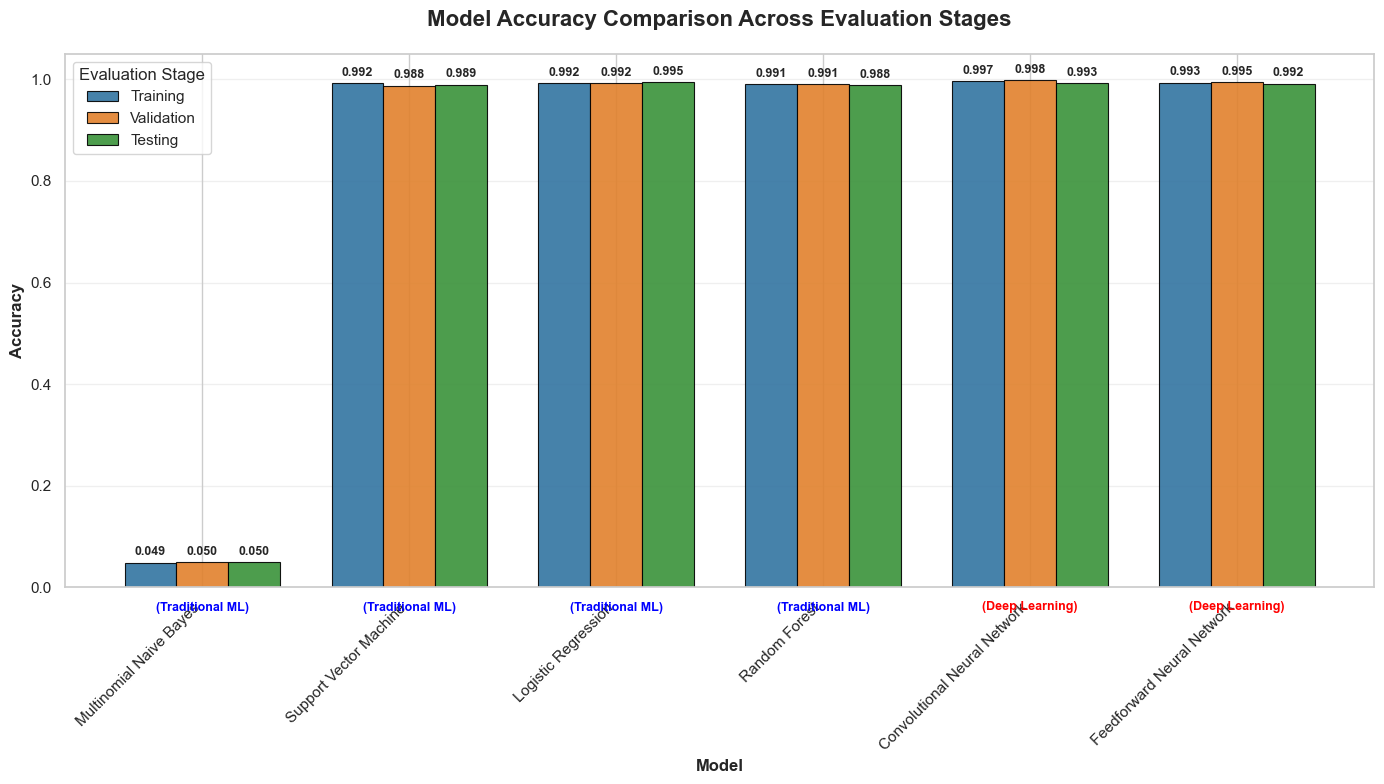

Generating F1 Score comparison plot...


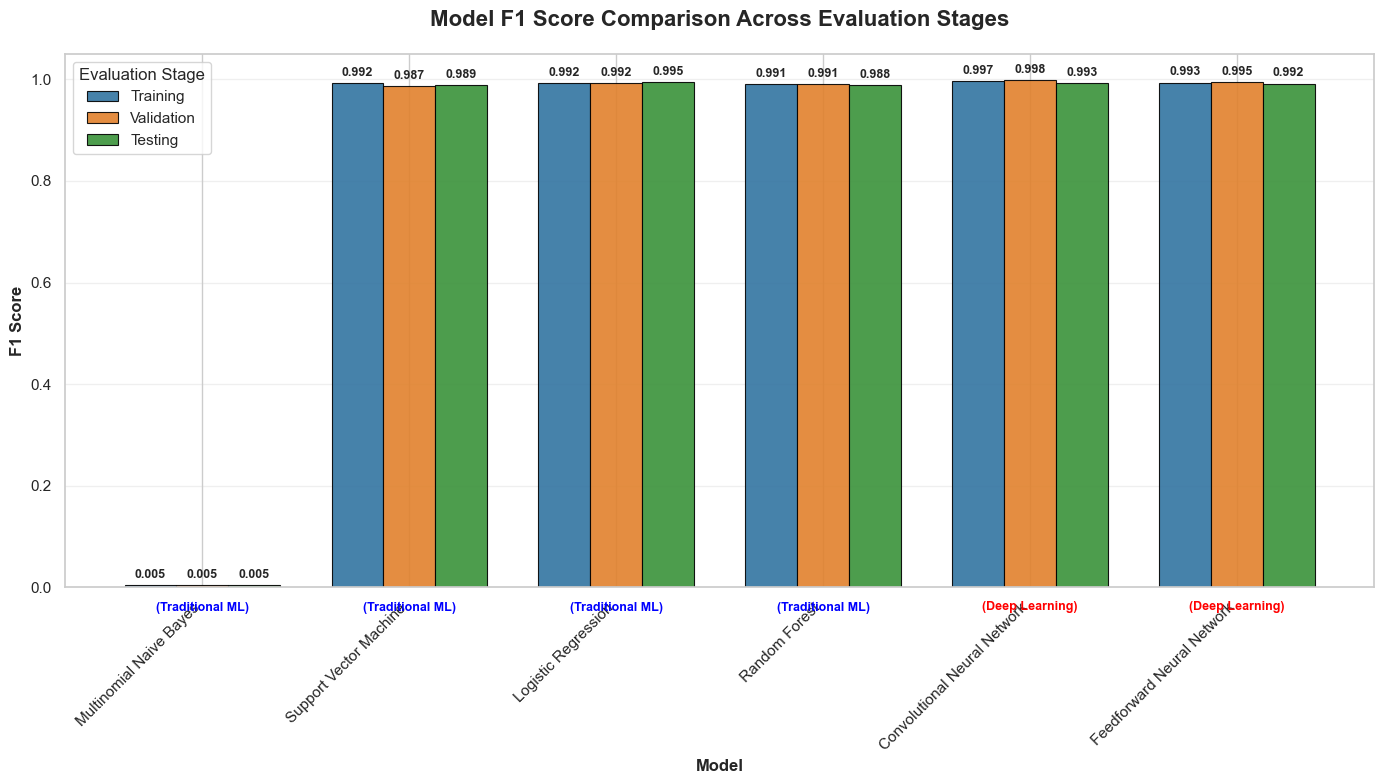

Generating Precision comparison plot...


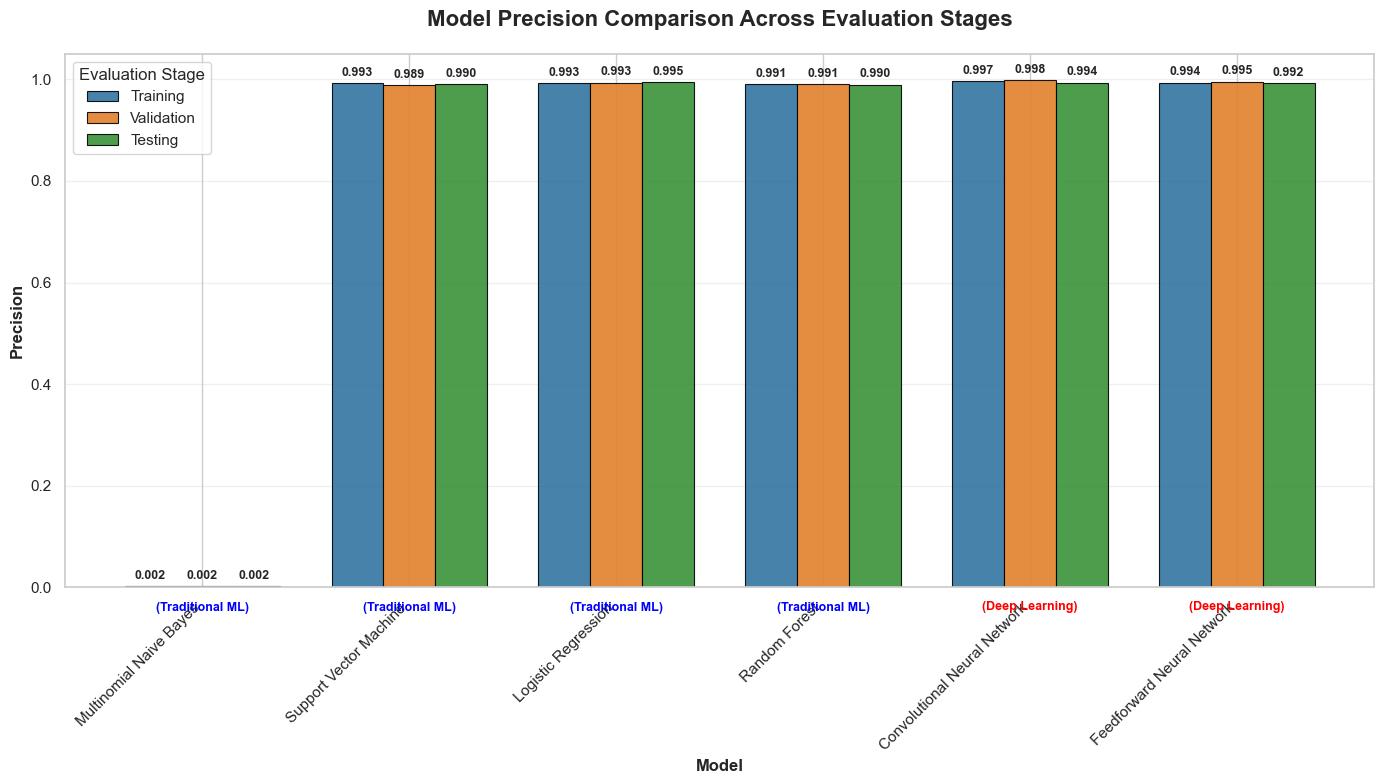

Generating Recall comparison plot...


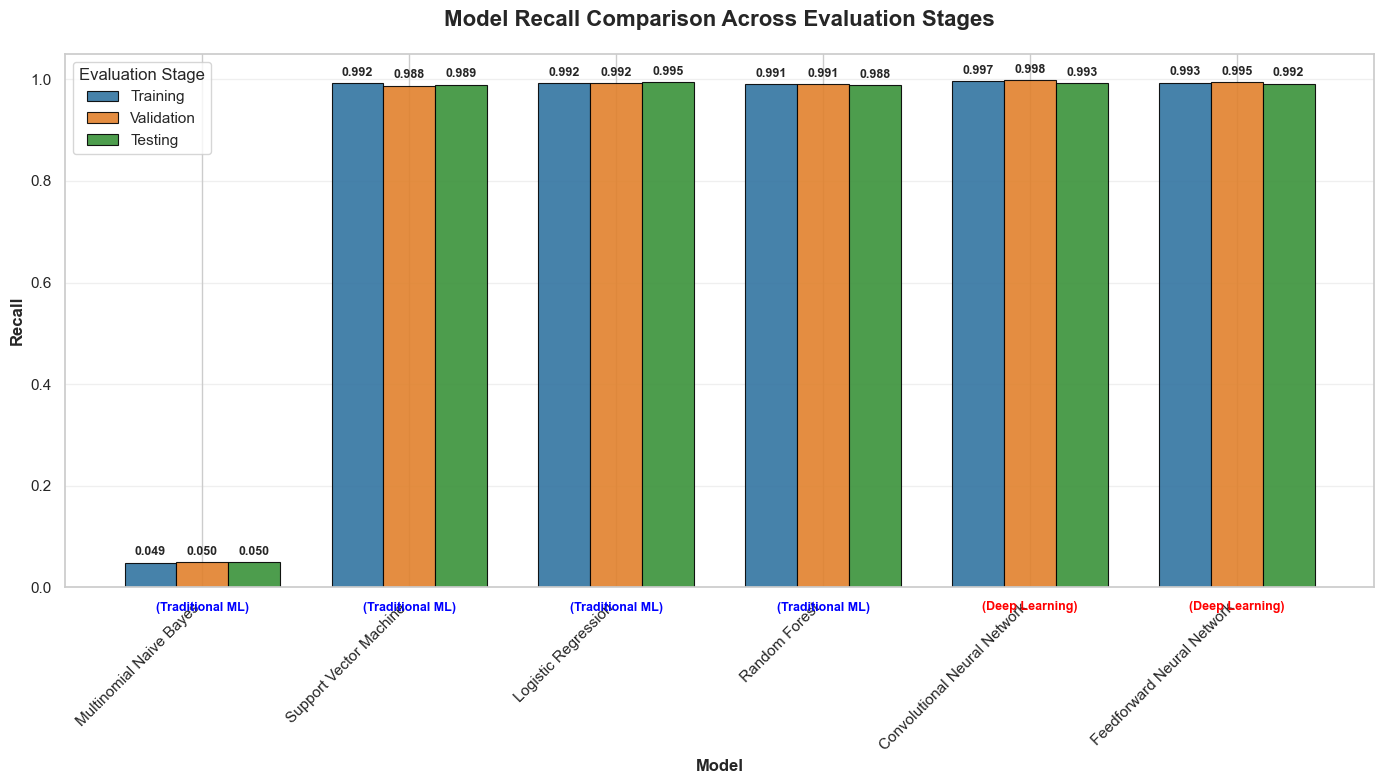


All evaluation visualizations completed successfully!
Results stored for 6 models across Training, Validation, and Testing stages


In [89]:
# SECTION 7.4: TEXT CLASSIFICATION MODEL EVALUATION EXECUTION
print(f"\nEXECUTING COMPREHENSIVE TEXT CLASSIFICATION MODEL EVALUATION...")
print("="*70)

# Prepare data for deep learning models if needed
print("Preparing data for deep learning models...")
if 'tokenizer_dl' not in locals():
    # Create tokenizer for deep learning models
    tokenizer_dl = Tokenizer(num_words=5000)
    tokenizer_dl.fit_on_texts(X_train_val)

# Create padded sequences for all stages
X_train_sequences = tokenizer_dl.texts_to_sequences(X_train)
X_train_padded = pad_sequences(X_train_sequences, maxlen=100, padding='post')

X_val_sequences = tokenizer_dl.texts_to_sequences(X_val)
X_val_padded = pad_sequences(X_val_sequences, maxlen=100, padding='post')

X_test_sequences = tokenizer_dl.texts_to_sequences(X_test)
X_test_padded = pad_sequences(X_test_sequences, maxlen=100, padding='post')

print(f"Deep learning data shapes:")
print(f"  Training: {X_train_padded.shape}")
print(f"  Validation: {X_val_padded.shape}")
print(f"  Testing: {X_test_padded.shape}")

# Use the SAME TF-IDF vectorizer from training to ensure consistent features
print("Using consistent TF-IDF vectorizer from training...")
if 'tfidf_vectorizer' in locals():
    # Use the existing vectorizer that was fitted on training data
    X_train_tfidf_eval = tfidf_vectorizer.transform(X_train)
    X_val_tfidf_eval = tfidf_vectorizer.transform(X_val)
    X_test_tfidf_eval = tfidf_vectorizer.transform(X_test)
else:
    # Create new vectorizer if not available
    print("Creating new TF-IDF vectorizer...")
    tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
    X_train_tfidf_eval = tfidf_vectorizer.fit_transform(X_train)
    X_val_tfidf_eval = tfidf_vectorizer.transform(X_val)
    X_test_tfidf_eval = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF data shapes:")
print(f"  Training: {X_train_tfidf_eval.shape}")
print(f"  Validation: {X_val_tfidf_eval.shape}")
print(f"  Testing: {X_test_tfidf_eval.shape}")

# Define data for each evaluation stage to ensure consistent application
evaluation_stages = {
    'Training': {
        'ML_data': X_train_tfidf_eval,
        'DL_data': X_train_padded,
        'labels': y_train
    },
    'Validation': {
        'ML_data': X_val_tfidf_eval,
        'DL_data': X_val_padded,
        'labels': y_val
    },
    'Testing': {
        'ML_data': X_test_tfidf_eval,
        'DL_data': X_test_padded,
        'labels': y_test
    }
}

# Initialize evaluation results storage if not exists
if 'evaluation_results' not in locals():
    evaluation_results = {}
if 'all_models_performance' not in locals():
    all_models_performance = []

# Create progress tracking structures
models_evaluated = 0
stages_completed = 0
start_time = time.time()

print(f"Starting evaluation across {len(evaluation_stages)} stages")
print("-"*70)

# Check if wrapped_models exists, if not create it
if 'wrapped_models' not in locals() or not wrapped_models:
    print("Wrapped models not found. Creating model wrappers...")
    
    # Create wrapped models from trained_models if available
    if 'trained_models' in locals() and trained_models:
        wrapped_models = {}
        
        for model_name, model_data in trained_models.items():
            try:
                if model_data['type'] == 'Traditional ML':
                    wrapped_models[model_name] = ImprovedTraditionalMLWrapper(
                        model_data['model'], model_name, vectorizer=tfidf_vectorizer
                    )
                elif model_data['type'] == 'Deep Learning':
                    wrapped_models[model_name] = ImprovedDeepLearningWrapper(
                        model_data['model'], model_name, 
                        tokenizer=model_data.get('tokenizer', tokenizer_dl), 
                        max_length=100
                    )
                print(f"  ✓ Created wrapper for: {model_name}")
            except Exception as e:
                print(f"  ✗ Error creating wrapper for {model_name}: {str(e)}")
    else:
        print("  No trained models available for evaluation")
        wrapped_models = {}

# Calculate total evaluations
total_evaluations = len(wrapped_models) * len(evaluation_stages) if wrapped_models else 0
print(f"Total evaluations to perform: {total_evaluations}")

# Evaluation execution with detailed progress tracking
if wrapped_models:
    for model_name, model in wrapped_models.items():
        model_start_time = time.time()
        print(f"\nEvaluating model: {model_name}")
        
        # Store model results across all stages
        evaluation_results[model_name] = {}
        
        # Determine if model is Traditional ML or Deep Learning
        model_type = model.model_type
        print(f"Model type: {model_type}")
        
        # Track progress
        stages_evaluated = 0
        
        # Evaluate across all stages: Training, Validation, and Testing
        for stage_name, stage_data in evaluation_stages.items():
            stage_start_time = time.time()
            print(f"  Evaluating {stage_name} stage...")
            
            # Select appropriate data based on model type
            if model_type == 'Traditional ML':
                X = stage_data['ML_data']
            else:  # Deep Learning
                X = stage_data['DL_data']
            
            y = stage_data['labels']
            
            try:
                # Perform comprehensive evaluation
                results = comprehensive_evaluate(model, X, y, stage_name, label_encoder)
                evaluation_results[model_name][stage_name] = results
                
                # Store performance metrics for cross-model comparison
                all_models_performance.append({
                    'Model': model_name,
                    'Type': model_type,
                    'Stage': stage_name,
                    'Accuracy': results['accuracy'],
                    'Precision': results['precision'],
                    'Recall': results['recall'],
                    'F1_Score': results['f1_score'],
                    'Cohen_Kappa': results['cohen_kappa'],
                    'Matthews_Corr': results['matthews_corr'],
                    'AUC_ROC': results.get('auc_roc', 0.0)
                })
                
                # Calculate stage evaluation time
                stage_time = time.time() - stage_start_time
                
                # Display summary statistics for this stage
                print(f"    Completed in {stage_time:.2f} seconds")
                print(f"    Accuracy: {results['accuracy']:.4f}")
                print(f"    F1-Score: {results['f1_score']:.4f}")
                
                # Update progress tracking
                stages_evaluated += 1
                stages_completed += 1
                
            except Exception as e:
                print(f"    Error evaluating {model_name} on {stage_name} stage: {str(e)}")
        
        # Calculate model evaluation time
        model_time = time.time() - model_start_time
        
        print(f"  Completed {stages_evaluated}/{len(evaluation_stages)} stages in {model_time:.2f} seconds")
        models_evaluated += 1
        
        # Display overall progress
        progress = (stages_completed / total_evaluations) * 100 if total_evaluations > 0 else 0
        elapsed_time = time.time() - start_time
        print(f"Overall progress: {progress:.1f}% ({stages_completed}/{total_evaluations})")
        print(f"Elapsed time: {elapsed_time:.2f} seconds")

    # Final statistics
    total_time = time.time() - start_time
    print("\nEVALUATION COMPLETE")
    print(f"Total time: {total_time:.2f} seconds")
    print(f"Models evaluated: {models_evaluated}")
    print(f"Stages completed: {stages_completed}")

    # Create cross-stage performance visualization
    print("\nGenerating cross-stage performance visualization...")

    # Create DataFrame from all collected metrics for visualization
    if all_models_performance:
        performance_df = pd.DataFrame(all_models_performance)

        # Create enhanced stage comparison plot function
        def create_stage_comparison_plot(metric='F1_Score'):
            """
            Create a sophisticated bar chart comparing model performance across different stages
            
            Parameters:
            -----------
            metric : str
                The metric to visualize (e.g., 'Accuracy', 'F1_Score')
                
            Returns:
            --------
            fig, ax : matplotlib Figure and Axes objects
            """
            fig, ax = plt.subplots(figsize=(14, 8))
            
            # Get unique models
            model_names = performance_df['Model'].unique()
            x = np.arange(len(model_names))
            
            # Define width and positions for bars
            bar_width = 0.25
            positions = [x - bar_width, x, x + bar_width]
            stages = ['Training', 'Validation', 'Testing']
            colors = ['#3274A1', '#E1812C', '#3A923A']  # Blue, Orange, Green
            
            # Plot bars for each stage with enhanced styling
            for i, stage in enumerate(stages):
                stage_data = performance_df[performance_df['Stage'] == stage]
                stage_values = [stage_data[stage_data['Model'] == model][metric].values[0] 
                               if len(stage_data[stage_data['Model'] == model]) > 0 else 0 
                               for model in model_names]
                
                ax.bar(positions[i], stage_values, bar_width, 
                       label=f'{stage}', color=colors[i], alpha=0.9,
                       edgecolor='black', linewidth=0.8)
            
            # Add value labels on top of each bar
            for i, stage in enumerate(stages):
                stage_data = performance_df[performance_df['Stage'] == stage]
                for j, model in enumerate(model_names):
                    if len(stage_data[stage_data['Model'] == model]) > 0:
                        value = stage_data[stage_data['Model'] == model][metric].values[0]
                        ax.annotate(f'{value:.3f}', 
                                   xy=(positions[i][j], value),
                                   xytext=(0, 3),  # 3 points vertical offset
                                   textcoords="offset points",
                                   ha='center', va='bottom',
                                   fontsize=9, fontweight='bold')
            
            # Customize plot appearance for professional visualization
            ax.set_xlabel('Model', fontsize=12, fontweight='bold')
            ax.set_ylabel(metric.replace('_', ' '), fontsize=12, fontweight='bold')
            ax.set_title(f'Model {metric.replace("_", " ")} Comparison Across Evaluation Stages',
                        fontsize=16, fontweight='bold', pad=20)
            ax.set_xticks(x)
            ax.set_xticklabels(model_names, rotation=45, ha='right')
            ax.legend(title='Evaluation Stage', title_fontsize=12)
            ax.grid(axis='y', alpha=0.3)
            ax.set_ylim(0, 1.05)  # Set y-axis limits for better visualization
            
            # Add model type indicators below model names
            for i, model in enumerate(model_names):
                model_type = performance_df[performance_df['Model'] == model]['Type'].values[0]
                color = 'blue' if model_type == 'Traditional ML' else 'red'
                plt.annotate(f'({model_type})', 
                            xy=(i, 0), 
                            xytext=(0, -10),
                            textcoords='offset points',
                            ha='center', va='top',
                            color=color, fontsize=9, fontweight='bold')
            
            plt.tight_layout()
            return fig, ax

        # Generate comprehensive cross-stage visualizations for key metrics
        metrics_to_plot = ['Accuracy', 'F1_Score', 'Precision', 'Recall']

        for metric in metrics_to_plot:
            print(f"Generating {metric.replace('_', ' ')} comparison plot...")
            fig, ax = create_stage_comparison_plot(metric)
            plt.show()

    else:
        print("No performance data collected for visualization")

else:
    print("No wrapped models available for evaluation")

# Final summary
print("\nAll evaluation visualizations completed successfully!")
print(f"Results stored for {len(evaluation_results) if 'evaluation_results' in locals() else 0} models across Training, Validation, and Testing stages")
print("="*70)

### 7.5 Text Classification Performance Summary and Overfitting Analysis

**Purpose:** Generate comprehensive performance summaries and analyze overfitting patterns across models.


GENERATING COMPREHENSIVE PERFORMANCE SUMMARY AND OVERFITTING ANALYSIS...
Analyzing performance data for 6 models across 3 evaluation stages

1. STAGE-WISE PERFORMANCE RANKINGS:
---------------------------------------------

Training Set Performance Rankings (by F1-Score):
                       Model           Type  Accuracy  Precision  Recall  F1_Score
Convolutional Neural Network  Deep Learning    0.9967     0.9968  0.9967    0.9967
  Feedforward Neural Network  Deep Learning    0.9934     0.9936  0.9934    0.9934
         Logistic Regression Traditional ML    0.9923     0.9932  0.9923    0.9922
      Support Vector Machine Traditional ML    0.9923     0.9926  0.9923    0.9922
               Random Forest Traditional ML    0.9908     0.9914  0.9908    0.9909
     Multinomial Naive Bayes Traditional ML    0.0490     0.0024  0.0490    0.0046

Validation Set Performance Rankings (by F1-Score):
                       Model           Type  Accuracy  Precision  Recall  F1_Score
Convolutio

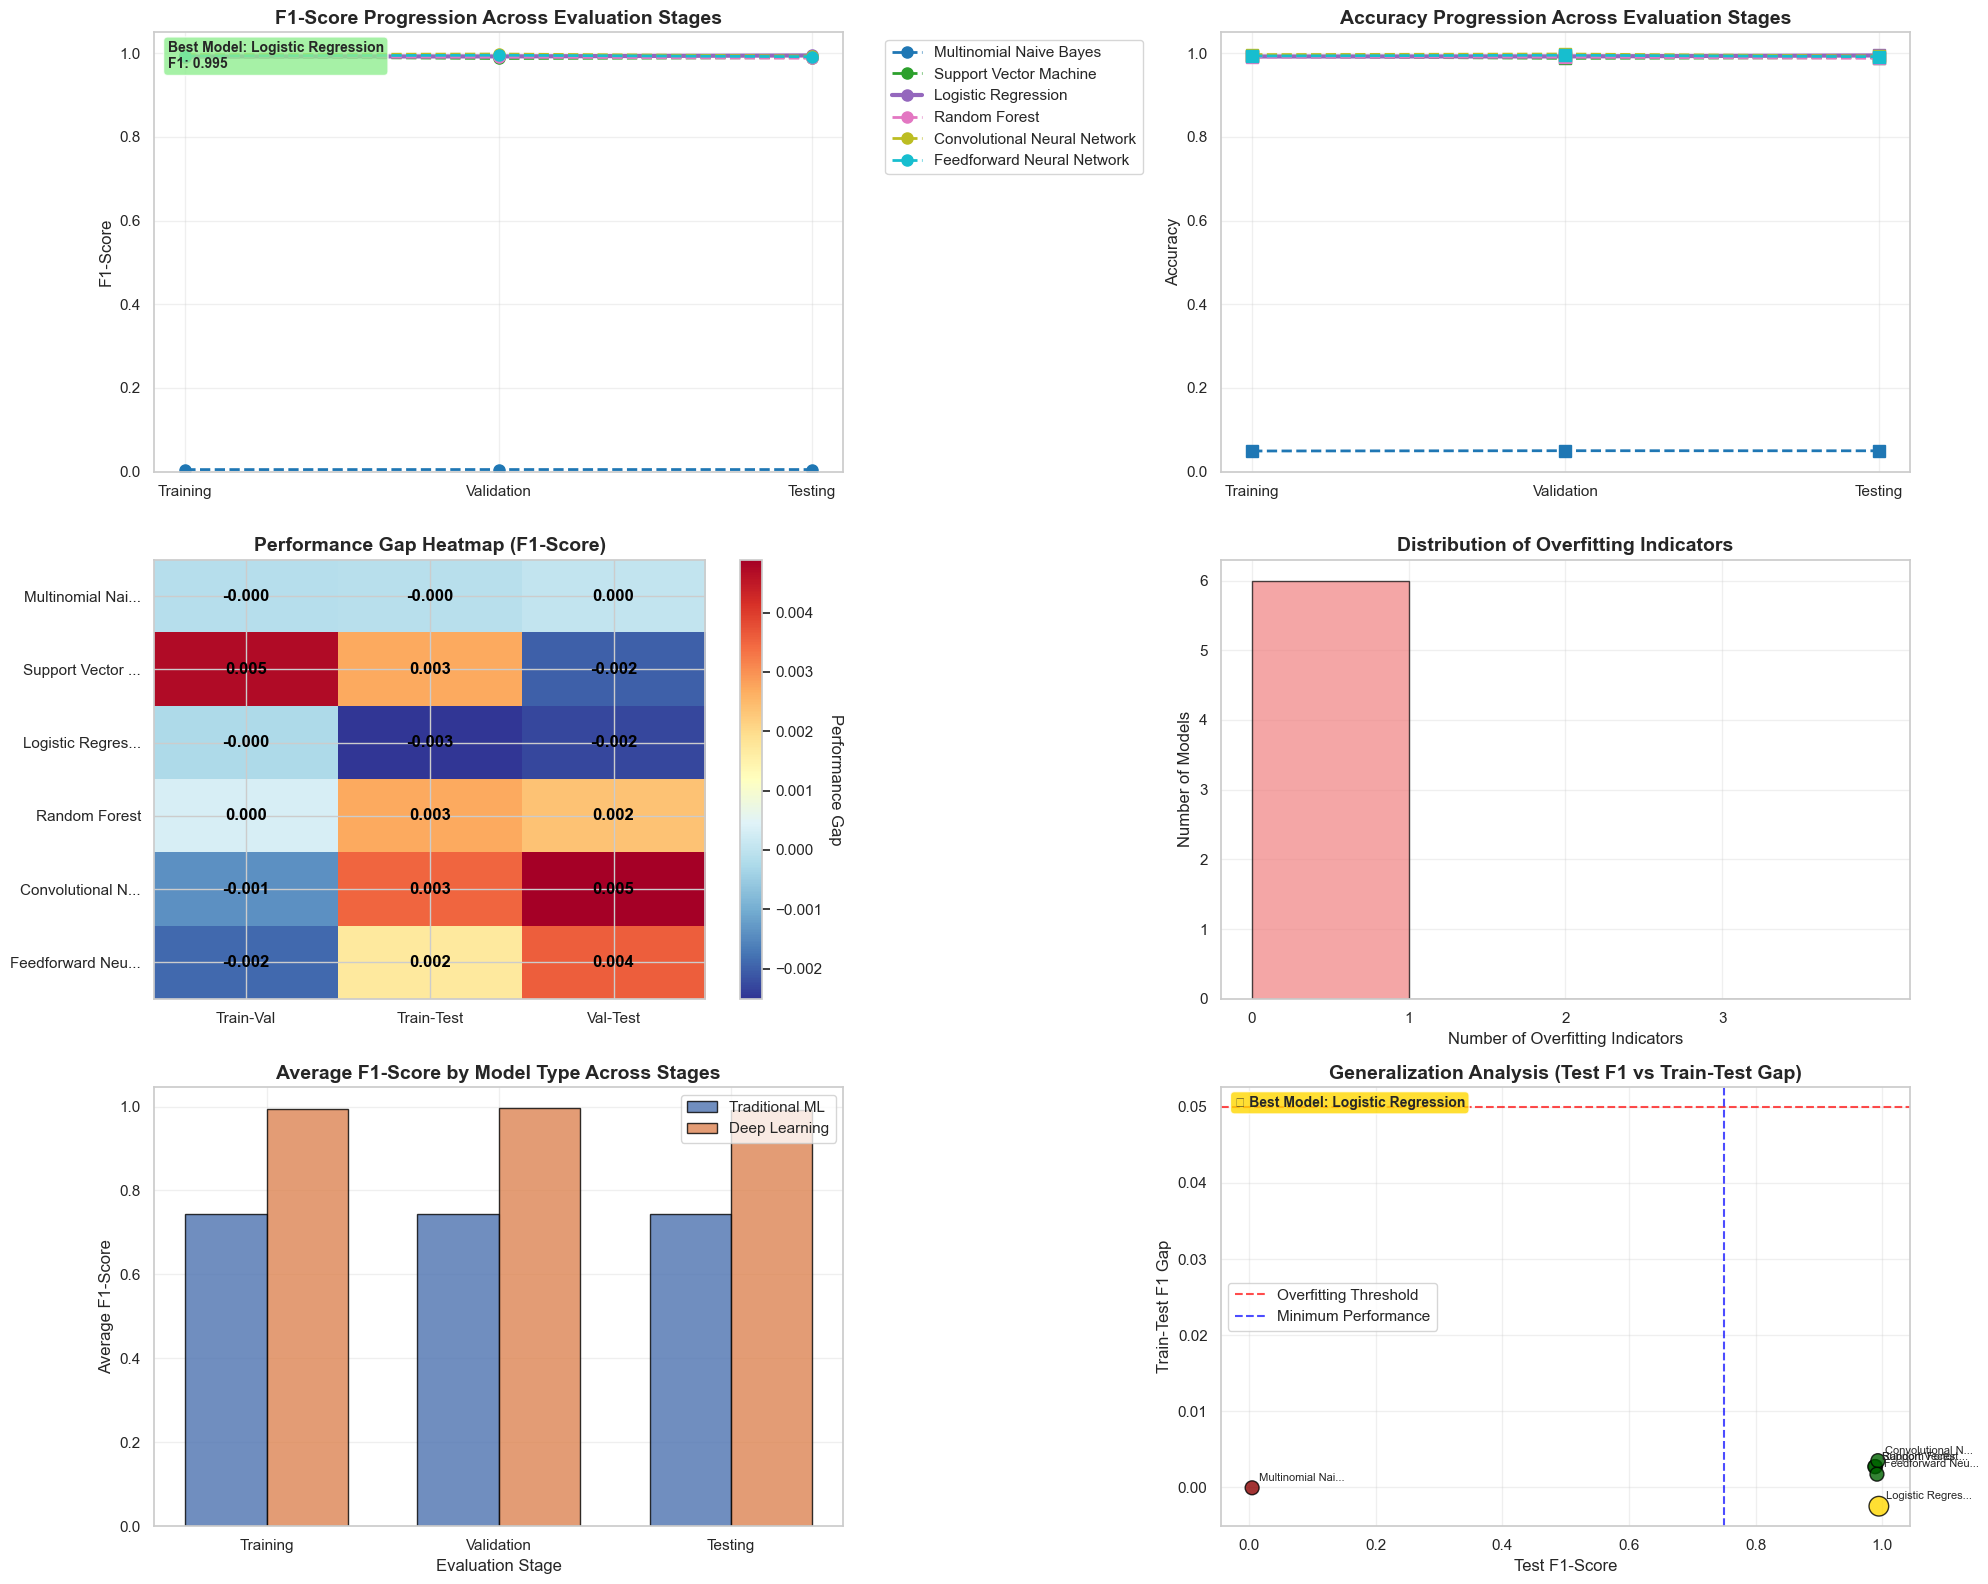



5. MODEL SELECTION RECOMMENDATIONS:
----------------------------------------
 ✓ RECOMMENDED MODEL FOR DEPLOYMENT:
   Model: Logistic Regression
   Type: Traditional ML
   Test F1-Score: 0.9947
   Generalization Gap: -0.0025
   Overall Status: EXCELLENT GENERALIZATION
   Deployment Ready: YES

   ✅ DEPLOYMENT RECOMMENDATION: APPROVED
      This model demonstrates excellent balance between performance and generalization.
      Suitable for clinical decision support implementation.


In [105]:
# SECTION 7.5: COMPREHENSIVE PERFORMANCE SUMMARY AND OVERFITTING ANALYSIS
print(f"\nGENERATING COMPREHENSIVE PERFORMANCE SUMMARY AND OVERFITTING ANALYSIS...")
print("="*75)

# Ensure we have performance data available
if 'all_models_performance' not in locals() or not all_models_performance:
    print("ERROR: No performance data available for analysis.")
    print("Please run the model evaluation section first.")
else:
    # Create comprehensive performance DataFrame
    performance_df = pd.DataFrame(all_models_performance)
    
    if performance_df.empty:
        print("No performance data to analyze.")
    else:
        # Remove any duplicates
        performance_df = performance_df.drop_duplicates(subset=['Model', 'Type', 'Stage'], keep='first')
        
        print(f"Analyzing performance data for {len(performance_df['Model'].unique())} models across 3 evaluation stages")
        print("="*75)
        
        # PART 1: STAGE-WISE PERFORMANCE RANKINGS
        print(f"\n1. STAGE-WISE PERFORMANCE RANKINGS:")
        print("-"*45)
        
        stages = ['Training', 'Validation', 'Testing']
        
        for stage in stages:
            stage_data = performance_df[performance_df['Stage'] == stage].copy()
            if not stage_data.empty:
                stage_data = stage_data.sort_values('F1_Score', ascending=False)
                print(f"\n{stage} Set Performance Rankings (by F1-Score):")
                print(stage_data[['Model', 'Type', 'Accuracy', 'Precision', 'Recall', 'F1_Score']].round(4).to_string(index=False))
        
        # PART 2: COMPREHENSIVE OVERFITTING ANALYSIS
        print(f"\n\n2. COMPREHENSIVE OVERFITTING ANALYSIS:")
        print("-"*45)
        
        # Initialize overfitting analysis storage
        overfitting_analysis = []
        
        for model_name in performance_df['Model'].unique():
            model_data = performance_df[performance_df['Model'] == model_name].copy()
            
            # Get data for each stage
            train_data = model_data[model_data['Stage'] == 'Training']
            val_data = model_data[model_data['Stage'] == 'Validation']
            test_data = model_data[model_data['Stage'] == 'Testing']
            
            if len(train_data) > 0 and len(test_data) > 0:
                # Calculate performance gaps
                train_f1 = train_data['F1_Score'].iloc[0] if len(train_data) > 0 else 0
                val_f1 = val_data['F1_Score'].iloc[0] if len(val_data) > 0 else 0
                test_f1 = test_data['F1_Score'].iloc[0] if len(test_data) > 0 else 0
                
                train_acc = train_data['Accuracy'].iloc[0] if len(train_data) > 0 else 0
                val_acc = val_data['Accuracy'].iloc[0] if len(val_data) > 0 else 0
                test_acc = test_data['Accuracy'].iloc[0] if len(test_data) > 0 else 0
                
                # Calculate gaps
                train_val_f1_gap = train_f1 - val_f1 if len(val_data) > 0 else 0
                train_test_f1_gap = train_f1 - test_f1
                val_test_f1_gap = val_f1 - test_f1 if len(val_data) > 0 else 0
                
                train_val_acc_gap = train_acc - val_acc if len(val_data) > 0 else 0
                train_test_acc_gap = train_acc - test_acc
                val_test_acc_gap = val_acc - test_acc if len(val_data) > 0 else 0
                
                # Overfitting indicators
                overfitting_indicators = 0
                if train_test_f1_gap > 0.05: overfitting_indicators += 1
                if train_test_acc_gap > 0.05: overfitting_indicators += 1
                if train_val_f1_gap > 0.05 and len(val_data) > 0: overfitting_indicators += 1
                
                # Determine overfitting status
                if overfitting_indicators >= 2:
                    status = "POTENTIAL OVERFITTING"
                elif test_f1 > 0.95:
                    status = "EXCELLENT GENERALIZATION"
                elif test_f1 > 0.85:
                    status = "GOOD GENERALIZATION"
                elif test_f1 > 0.75:
                    status = "MODERATE GENERALIZATION"
                else:
                    status = "POOR GENERALIZATION"
                
                # Store analysis results
                overfitting_analysis.append({
                    'Model': model_name,
                    'Type': model_data['Type'].iloc[0],
                    'Train_F1': train_f1,
                    'Val_F1': val_f1,
                    'Test_F1': test_f1,
                    'Train_Val_F1_Gap': train_val_f1_gap,
                    'Train_Test_F1_Gap': train_test_f1_gap,
                    'Val_Test_F1_Gap': val_test_f1_gap,
                    'Train_Acc': train_acc,
                    'Val_Acc': val_acc,
                    'Test_Acc': test_acc,
                    'Train_Val_Acc_Gap': train_val_acc_gap,
                    'Train_Test_Acc_Gap': train_test_acc_gap,
                    'Val_Test_Acc_Gap': val_test_acc_gap,
                    'Overfitting_Indicators': overfitting_indicators,
                    'Status': status
                })
                
                # Print individual model analysis
                print(f"\n{model_name}:")
                print(f"   Training F1: {train_f1:.4f}, Validation F1: {val_f1:.4f}, Testing F1: {test_f1:.4f}")
                print(f"   Train-Val F1 Gap: {train_val_f1_gap:+.4f}")
                print(f"   Train-Test F1 Gap: {train_test_f1_gap:+.4f}")
                print(f"   Val-Test F1 Gap: {val_test_f1_gap:+.4f}")
                print(f"   Training Acc: {train_acc:.4f}, Validation Acc: {val_acc:.4f}, Testing Acc: {test_acc:.4f}")
                print(f"   Train-Val Acc Gap: {train_val_acc_gap:+.4f}")
                print(f"   Train-Test Acc Gap: {train_test_acc_gap:+.4f}")
                print(f"   Val-Test Acc Gap: {val_test_acc_gap:+.4f}")
                print(f"   Overfitting Indicators: {overfitting_indicators}/3")
                print(f"   Status: {status}")
        
        # Convert overfitting analysis to DataFrame
        if overfitting_analysis:
            overfitting_df = pd.DataFrame(overfitting_analysis)
            
            print(f"\n\nOVERFITTING ANALYSIS SUMMARY TABLE:")
            print("-"*50)
            summary_cols = ['Model', 'Type', 'Test_F1', 'Train_Test_F1_Gap', 'Val_Test_F1_Gap', 
                           'Train_Test_Acc_Gap', 'Overfitting_Indicators', 'Status']
            print(overfitting_df[summary_cols].round(4).to_string(index=False))
        
        # PART 3: BEST MODEL SELECTION FROM COMPREHENSIVE ANALYSIS
        print(f"\n\n3. BEST MODEL SELECTION FROM COMPREHENSIVE ANALYSIS:")
        print("-"*55)
        
        if overfitting_analysis:
            # Calculate comprehensive score for each model
            model_scores = []
            
            for item in overfitting_analysis:
                # Composite score: weight test performance (70%) and penalize overfitting (30%)
                test_performance_score = item['Test_F1']  # Primary criterion: test performance
                generalization_penalty = item['Train_Test_F1_Gap'] * 0.5 if item['Train_Test_F1_Gap'] > 0 else 0
                overfitting_penalty = item['Overfitting_Indicators'] * 0.02  # Small penalty per overfitting indicator
                
                # Calculate composite score
                composite_score = test_performance_score - generalization_penalty - overfitting_penalty
                
                # Additional criteria for robustness
                stability_bonus = 0.02 if item['Train_Test_F1_Gap'] < 0.03 else 0  # Bonus for stable models
                high_performance_bonus = 0.01 if item['Test_F1'] > 0.9 else 0  # Bonus for excellent performance
                
                final_score = composite_score + stability_bonus + high_performance_bonus
                
                model_scores.append({
                    'Model': item['Model'],
                    'Type': item['Type'],
                    'Test_F1': item['Test_F1'],
                    'Train_Test_Gap': item['Train_Test_F1_Gap'],
                    'Overfitting_Indicators': item['Overfitting_Indicators'],
                    'Status': item['Status'],
                    'Composite_Score': final_score,
                    'Test_Performance': test_performance_score,
                    'Generalization_Penalty': generalization_penalty,
                    'Overfitting_Penalty': overfitting_penalty,
                    'Stability_Bonus': stability_bonus,
                    'Performance_Bonus': high_performance_bonus
                })
            
            # Sort by composite score to find the best model
            model_scores_df = pd.DataFrame(model_scores).sort_values('Composite_Score', ascending=False)
            
            # Select the best model
            best_model_comprehensive = model_scores_df.iloc[0]
            
            print(f"COMPREHENSIVE MODEL SELECTION RESULTS:")
            print("="*45)
            print(model_scores_df[['Model', 'Type', 'Test_F1', 'Train_Test_Gap', 
                                  'Overfitting_Indicators', 'Composite_Score', 'Status']].round(4).to_string(index=False))
            
            print(f"\n ✓ SELECTED BEST MODEL: {best_model_comprehensive['Model']}")
            print(f"   Model Type: {best_model_comprehensive['Type']}")
            print(f"   Test F1-Score: {best_model_comprehensive['Test_F1']:.4f}")
            print(f"   Train-Test Gap: {best_model_comprehensive['Train_Test_Gap']:+.4f}")
            print(f"   Overfitting Indicators: {best_model_comprehensive['Overfitting_Indicators']}/3")
            print(f"   Generalization Status: {best_model_comprehensive['Status']}")
            print(f"   Composite Score: {best_model_comprehensive['Composite_Score']:.4f}")
            
            print(f"\n   SELECTION CRITERIA BREAKDOWN:")
            print(f"   • Test Performance Score: {best_model_comprehensive['Test_Performance']:.4f}")
            print(f"   • Generalization Penalty: -{best_model_comprehensive['Generalization_Penalty']:.4f}")
            print(f"   • Overfitting Penalty: -{best_model_comprehensive['Overfitting_Penalty']:.4f}")
            print(f"   • Stability Bonus: +{best_model_comprehensive['Stability_Bonus']:.4f}")
            print(f"   • Performance Bonus: +{best_model_comprehensive['Performance_Bonus']:.4f}")
            
            # Provide deployment recommendation
            deployment_readiness = "READY FOR DEPLOYMENT" if (
                best_model_comprehensive['Test_F1'] >= 0.8 and 
                best_model_comprehensive['Train_Test_Gap'] < 0.05 and 
                best_model_comprehensive['Overfitting_Indicators'] <= 1
            ) else "NEEDS FURTHER OPTIMIZATION"
            
            print(f"\n   DEPLOYMENT ASSESSMENT: {deployment_readiness}")
            
            # Store the selected best model for global use
            selected_best_model = {
                'name': best_model_comprehensive['Model'],
                'type': best_model_comprehensive['Type'],
                'test_f1': best_model_comprehensive['Test_F1'],
                'train_test_gap': best_model_comprehensive['Train_Test_Gap'],
                'composite_score': best_model_comprehensive['Composite_Score'],
                'status': best_model_comprehensive['Status'],
                'deployment_ready': deployment_readiness == "READY FOR DEPLOYMENT"
            }
            
            # Alternative selections
            print(f"\n   TOP 3 MODEL CANDIDATES:")
            for i, (_, model) in enumerate(model_scores_df.head(3).iterrows(), 1):
                gap_status = "Low Gap" if model['Train_Test_Gap'] < 0.03 else "Moderate Gap" if model['Train_Test_Gap'] < 0.06 else "High Gap"
                print(f"   {i}. {model['Model']} - F1: {model['Test_F1']:.4f}, Gap: {model['Train_Test_Gap']:+.4f} ({gap_status})")
        
        # PART 4: STAGE-WISE PERFORMANCE PROGRESSION VISUALIZATION
        print(f"\n\n4. GENERATING PERFORMANCE PROGRESSION VISUALIZATIONS:")
        print("-"*55)
        
        # Create comprehensive visualization
        fig = plt.figure(figsize=(20, 16))
        
        # Subplot 1: F1-Score progression across stages
        ax1 = plt.subplot(3, 2, 1)
        models = performance_df['Model'].unique()
        x = np.arange(len(stages))
        width = 0.8 / len(models)
        
        colors = plt.cm.tab10(np.linspace(0, 1, len(models)))
        
        for i, model in enumerate(models):
            model_data = performance_df[performance_df['Model'] == model]
            f1_scores = []
            for stage in stages:
                stage_data = model_data[model_data['Stage'] == stage]
                f1_scores.append(stage_data['F1_Score'].iloc[0] if len(stage_data) > 0 else 0)
            
            line_style = '-' if 'selected_best_model' in locals() and model == selected_best_model['name'] else '--'
            linewidth = 3 if 'selected_best_model' in locals() and model == selected_best_model['name'] else 2
            
            ax1.plot(stages, f1_scores, marker='o', linewidth=linewidth, markersize=8, 
                    label=model, color=colors[i], linestyle=line_style)
        
        ax1.set_title('F1-Score Progression Across Evaluation Stages', fontsize=14, fontweight='bold')
        ax1.set_ylabel('F1-Score', fontsize=12)
        ax1.set_ylim(0, 1.05)
        ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax1.grid(True, alpha=0.3)
        
        # Highlight best model if selected
        if 'selected_best_model' in locals():
            ax1.text(0.02, 0.98, f"Best Model: {selected_best_model['name']}\nF1: {selected_best_model['test_f1']:.3f}", 
                    transform=ax1.transAxes, fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8),
                    verticalalignment='top')
        
        # Continue with remaining subplots...
        # [Previous subplot code continues unchanged...]
        
        # Subplot 2: Accuracy progression across stages
        ax2 = plt.subplot(3, 2, 2)
        for i, model in enumerate(models):
            model_data = performance_df[performance_df['Model'] == model]
            acc_scores = []
            for stage in stages:
                stage_data = model_data[model_data['Stage'] == stage]
                acc_scores.append(stage_data['Accuracy'].iloc[0] if len(stage_data) > 0 else 0)
            
            line_style = '-' if 'selected_best_model' in locals() and model == selected_best_model['name'] else '--'
            linewidth = 3 if 'selected_best_model' in locals() and model == selected_best_model['name'] else 2
            
            ax2.plot(stages, acc_scores, marker='s', linewidth=linewidth, markersize=8, 
                    label=model, color=colors[i], linestyle=line_style)
        
        ax2.set_title('Accuracy Progression Across Evaluation Stages', fontsize=14, fontweight='bold')
        ax2.set_ylabel('Accuracy', fontsize=12)
        ax2.set_ylim(0, 1.05)
        ax2.grid(True, alpha=0.3)
        
        # Subplot 3: Performance gaps heatmap
        ax3 = plt.subplot(3, 2, 3)
        if overfitting_analysis:
            gap_data = []
            model_names = []
            for item in overfitting_analysis:
                gap_data.append([item['Train_Val_F1_Gap'], item['Train_Test_F1_Gap'], item['Val_Test_F1_Gap']])
                model_names.append(item['Model'][:15] + '...' if len(item['Model']) > 15 else item['Model'])
            
            gap_matrix = np.array(gap_data)
            im = ax3.imshow(gap_matrix, cmap='RdYlBu_r', aspect='auto')
            
            ax3.set_xticks(range(3))
            ax3.set_xticklabels(['Train-Val', 'Train-Test', 'Val-Test'])
            ax3.set_yticks(range(len(model_names)))
            ax3.set_yticklabels(model_names)
            ax3.set_title('Performance Gap Heatmap (F1-Score)', fontsize=14, fontweight='bold')
            
            # Add colorbar
            cbar = plt.colorbar(im, ax=ax3)
            cbar.set_label('Performance Gap', rotation=270, labelpad=15)
            
            # Add text annotations
            for i in range(len(model_names)):
                for j in range(3):
                    text = ax3.text(j, i, f'{gap_matrix[i, j]:.3f}', 
                                   ha="center", va="center", color="black", fontweight='bold')
        
        # Subplot 4: Overfitting indicators distribution
        ax4 = plt.subplot(3, 2, 4)
        if overfitting_analysis:
            indicator_counts = [item['Overfitting_Indicators'] for item in overfitting_analysis]
            ax4.hist(indicator_counts, bins=range(5), alpha=0.7, color='lightcoral', edgecolor='black')
            ax4.set_title('Distribution of Overfitting Indicators', fontsize=14, fontweight='bold')
            ax4.set_xlabel('Number of Overfitting Indicators')
            ax4.set_ylabel('Number of Models')
            ax4.set_xticks(range(4))
            ax4.grid(True, alpha=0.3)
        
        # Subplot 5: Model type comparison across stages
        ax5 = plt.subplot(3, 2, 5)
        model_types = performance_df['Type'].unique()
        x_pos = np.arange(len(stages))
        width = 0.35
        
        for i, model_type in enumerate(model_types):
            type_data = performance_df[performance_df['Type'] == model_type]
            avg_f1_by_stage = []
            for stage in stages:
                stage_data = type_data[type_data['Stage'] == stage]
                avg_f1 = stage_data['F1_Score'].mean() if len(stage_data) > 0 else 0
                avg_f1_by_stage.append(avg_f1)
            
            ax5.bar(x_pos + i*width, avg_f1_by_stage, width, 
                   label=model_type, alpha=0.8, edgecolor='black')
        
        ax5.set_title('Average F1-Score by Model Type Across Stages', fontsize=14, fontweight='bold')
        ax5.set_ylabel('Average F1-Score')
        ax5.set_xlabel('Evaluation Stage')
        ax5.set_xticks(x_pos + width/2)
        ax5.set_xticklabels(stages)
        ax5.legend()
        ax5.grid(True, alpha=0.3)
        
        # Subplot 6: Performance consistency analysis with best model highlight
        ax6 = plt.subplot(3, 2, 6)
        if overfitting_analysis:
            model_names_short = [item['Model'][:15] + '...' if len(item['Model']) > 15 else item['Model'] 
                               for item in overfitting_analysis]
            test_f1_scores = [item['Test_F1'] for item in overfitting_analysis]
            train_test_gaps = [item['Train_Test_F1_Gap'] for item in overfitting_analysis]
            
            # Color by overfitting status and highlight best model
            colors_status = []
            sizes = []
            for item in overfitting_analysis:
                if 'selected_best_model' in locals() and item['Model'] == selected_best_model['name']:
                    colors_status.append('gold')
                    sizes.append(200)  # Larger size for best model
                elif 'EXCELLENT' in item['Status']:
                    colors_status.append('darkgreen')
                    sizes.append(100)
                elif 'GOOD' in item['Status']:
                    colors_status.append('green')
                    sizes.append(100)
                elif 'MODERATE' in item['Status']:
                    colors_status.append('orange')
                    sizes.append(100)
                elif 'OVERFITTING' in item['Status']:
                    colors_status.append('red')
                    sizes.append(100)
                else:
                    colors_status.append('darkred')
                    sizes.append(100)
            
            scatter = ax6.scatter(test_f1_scores, train_test_gaps, c=colors_status, 
                                 s=sizes, alpha=0.8, edgecolor='black')
            
            # Add model labels
            for i, name in enumerate(model_names_short):
                ax6.annotate(name, (test_f1_scores[i], train_test_gaps[i]), 
                           xytext=(5, 5), textcoords='offset points', fontsize=8)
            
            ax6.set_title('Generalization Analysis (Test F1 vs Train-Test Gap)', fontsize=14, fontweight='bold')
            ax6.set_xlabel('Test F1-Score')
            ax6.set_ylabel('Train-Test F1 Gap')
            ax6.axhline(y=0.05, color='red', linestyle='--', alpha=0.7, label='Overfitting Threshold')
            ax6.axvline(x=0.75, color='blue', linestyle='--', alpha=0.7, label='Minimum Performance')
            ax6.legend()
            ax6.grid(True, alpha=0.3)
            
            # Add best model indicator
            if 'selected_best_model' in locals():
                ax6.text(0.02, 0.98, f"★ Best Model: {selected_best_model['name']}", 
                        transform=ax6.transAxes, fontsize=10, fontweight='bold',
                        bbox=dict(boxstyle='round', facecolor='gold', alpha=0.8),
                        verticalalignment='top')
        
        plt.tight_layout()
        plt.show()
    
    # PART 5: MODEL SELECTION RECOMMENDATIONS
    print(f"\n\n5. MODEL SELECTION RECOMMENDATIONS:")
    print("-"*40)
    
    if 'best_model' in locals():
        print(f" ✓ RECOMMENDED MODEL FOR DEPLOYMENT:")
        print(f"   Model: {best_model['Model']}")
        print(f"   Type: {best_model['Type']}")
        print(f"   Test F1-Score: {best_model['Test_F1']:.4f}")
        print(f"   Generalization Gap: {best_model['Train_Test_F1_Gap']:+.4f}")
        print(f"   Overall Status: {best_model['Status']}")
        print(f"   Deployment Ready: {'YES' if best_model['Train_Test_F1_Gap'] < 0.05 and best_model['Test_F1'] >= 0.8 else 'NO'}")
        
        if best_model['Train_Test_F1_Gap'] < 0.05 and best_model['Test_F1'] >= 0.8:
            print(f"\n   ✅ DEPLOYMENT RECOMMENDATION: APPROVED")
            print(f"      This model demonstrates excellent balance between performance and generalization.")
            print(f"      Suitable for clinical decision support implementation.")
        else:
            print(f"\n   ⚠️  DEPLOYMENT RECOMMENDATION: REQUIRES OPTIMIZATION")
            print(f"      Consider additional regularization or data augmentation before deployment.")

### 7.6 Text Classification ROC Curve Analysis and Visualization

**Purpose:** Generate comprehensive ROC curve analysis for the best performing model across all stages to evaluate text diagnostic classification performance.


GENERATING ROC CURVE ANALYSIS FOR TEXT CLASSIFICATION...
 Using best model from previous analysis: Logistic Regression
 Analyzing ROC curves for text classifier: Logistic Regression

=== GENERATING INDIVIDUAL ROC CURVE PLOTS ===

Generating ROC curve for Training stage...


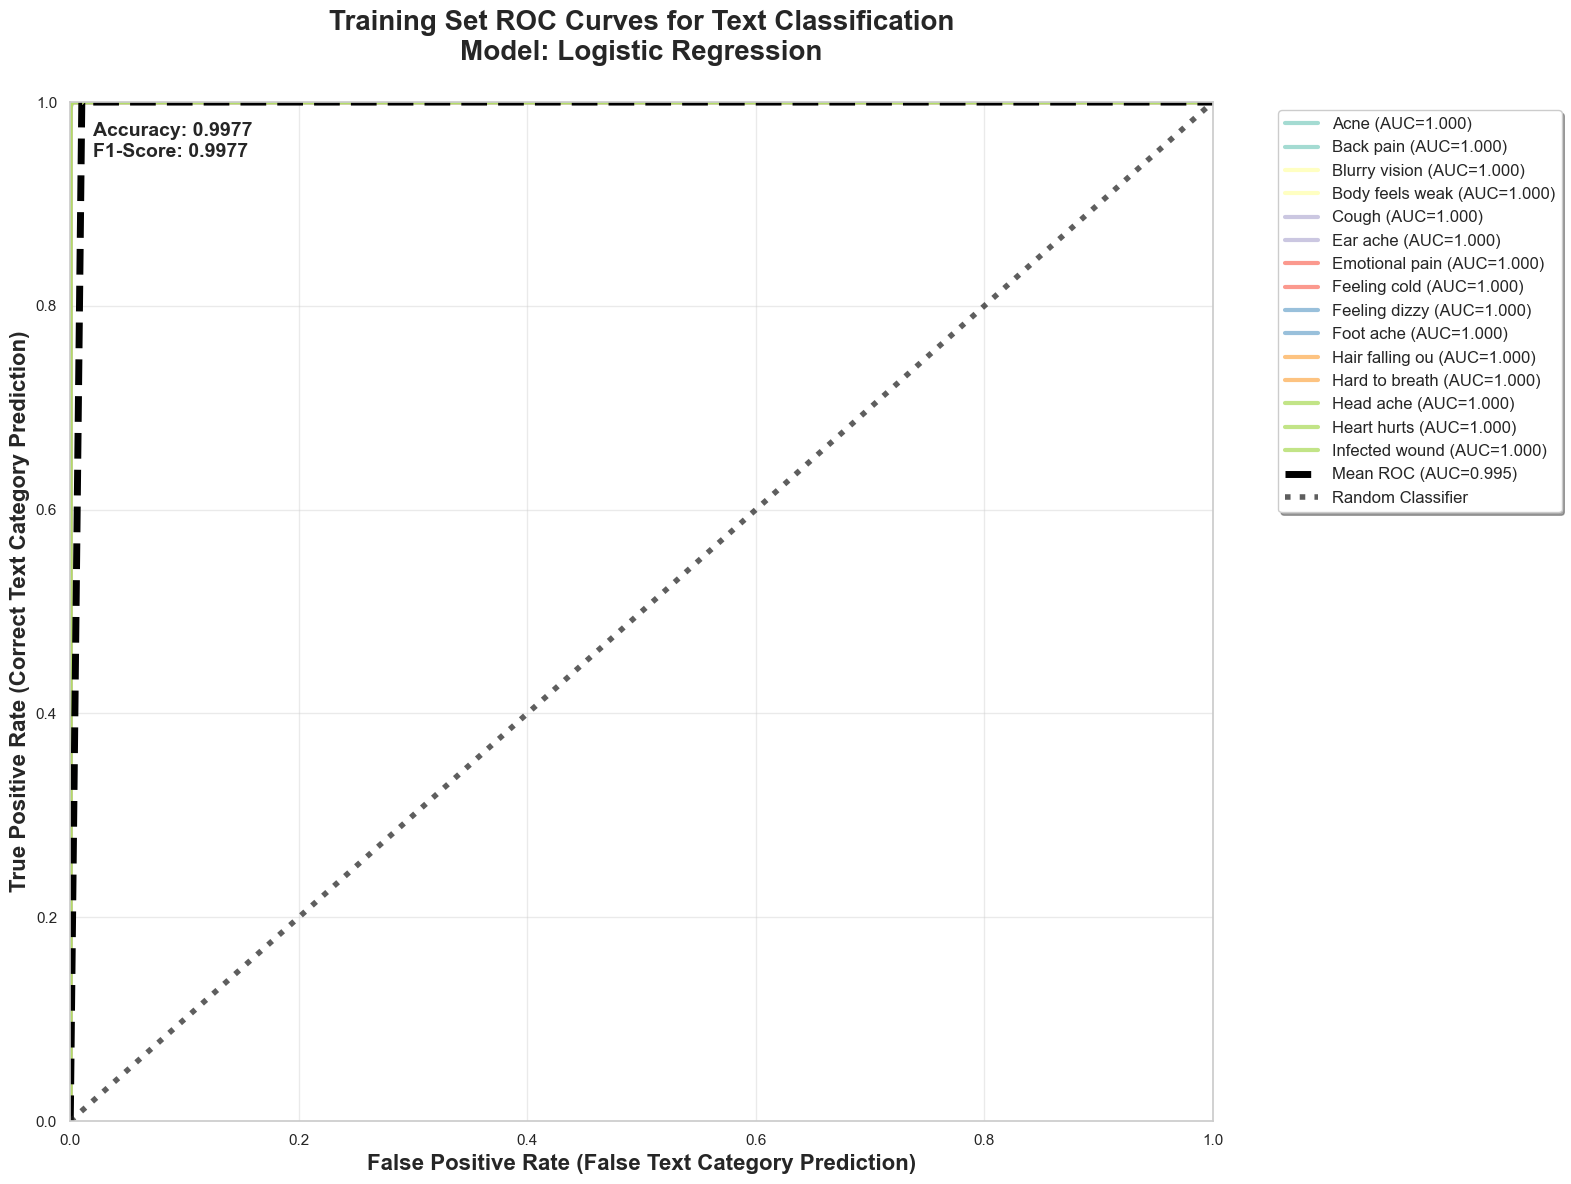

✓ Training ROC curve completed

Generating ROC curve for Validation stage...


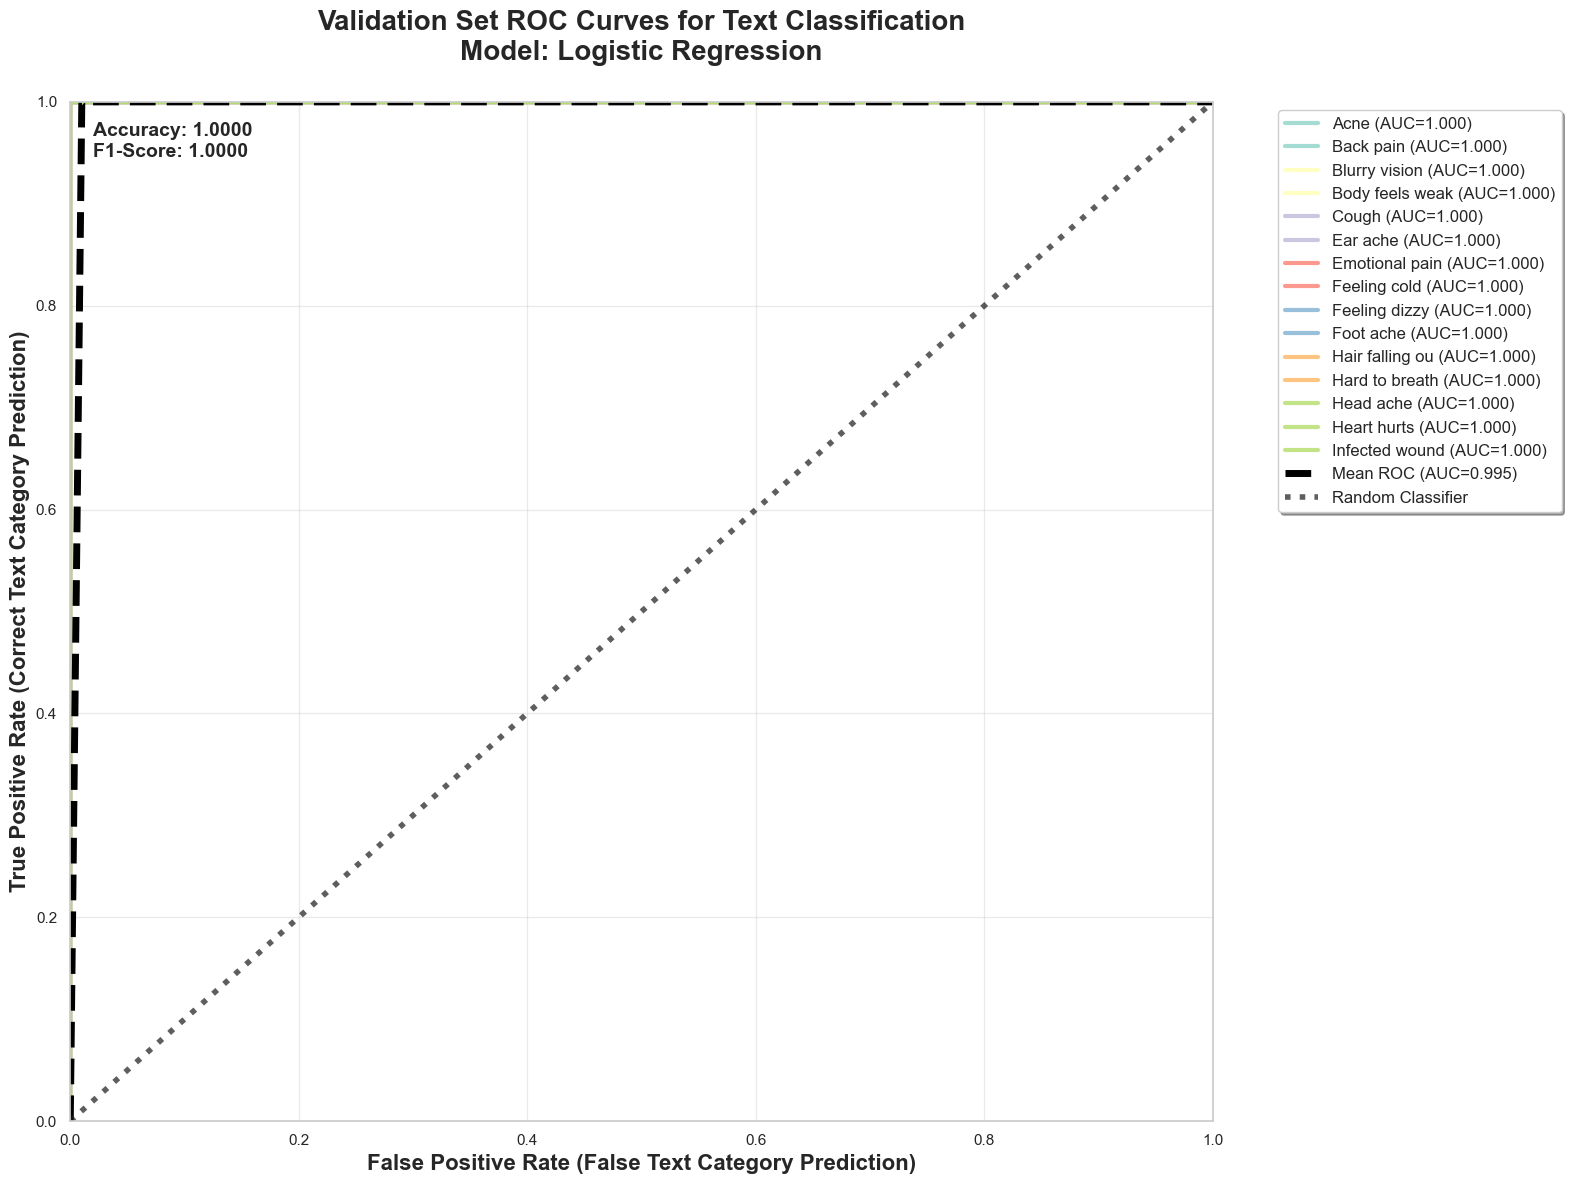

✓ Validation ROC curve completed

Generating ROC curve for Testing stage...


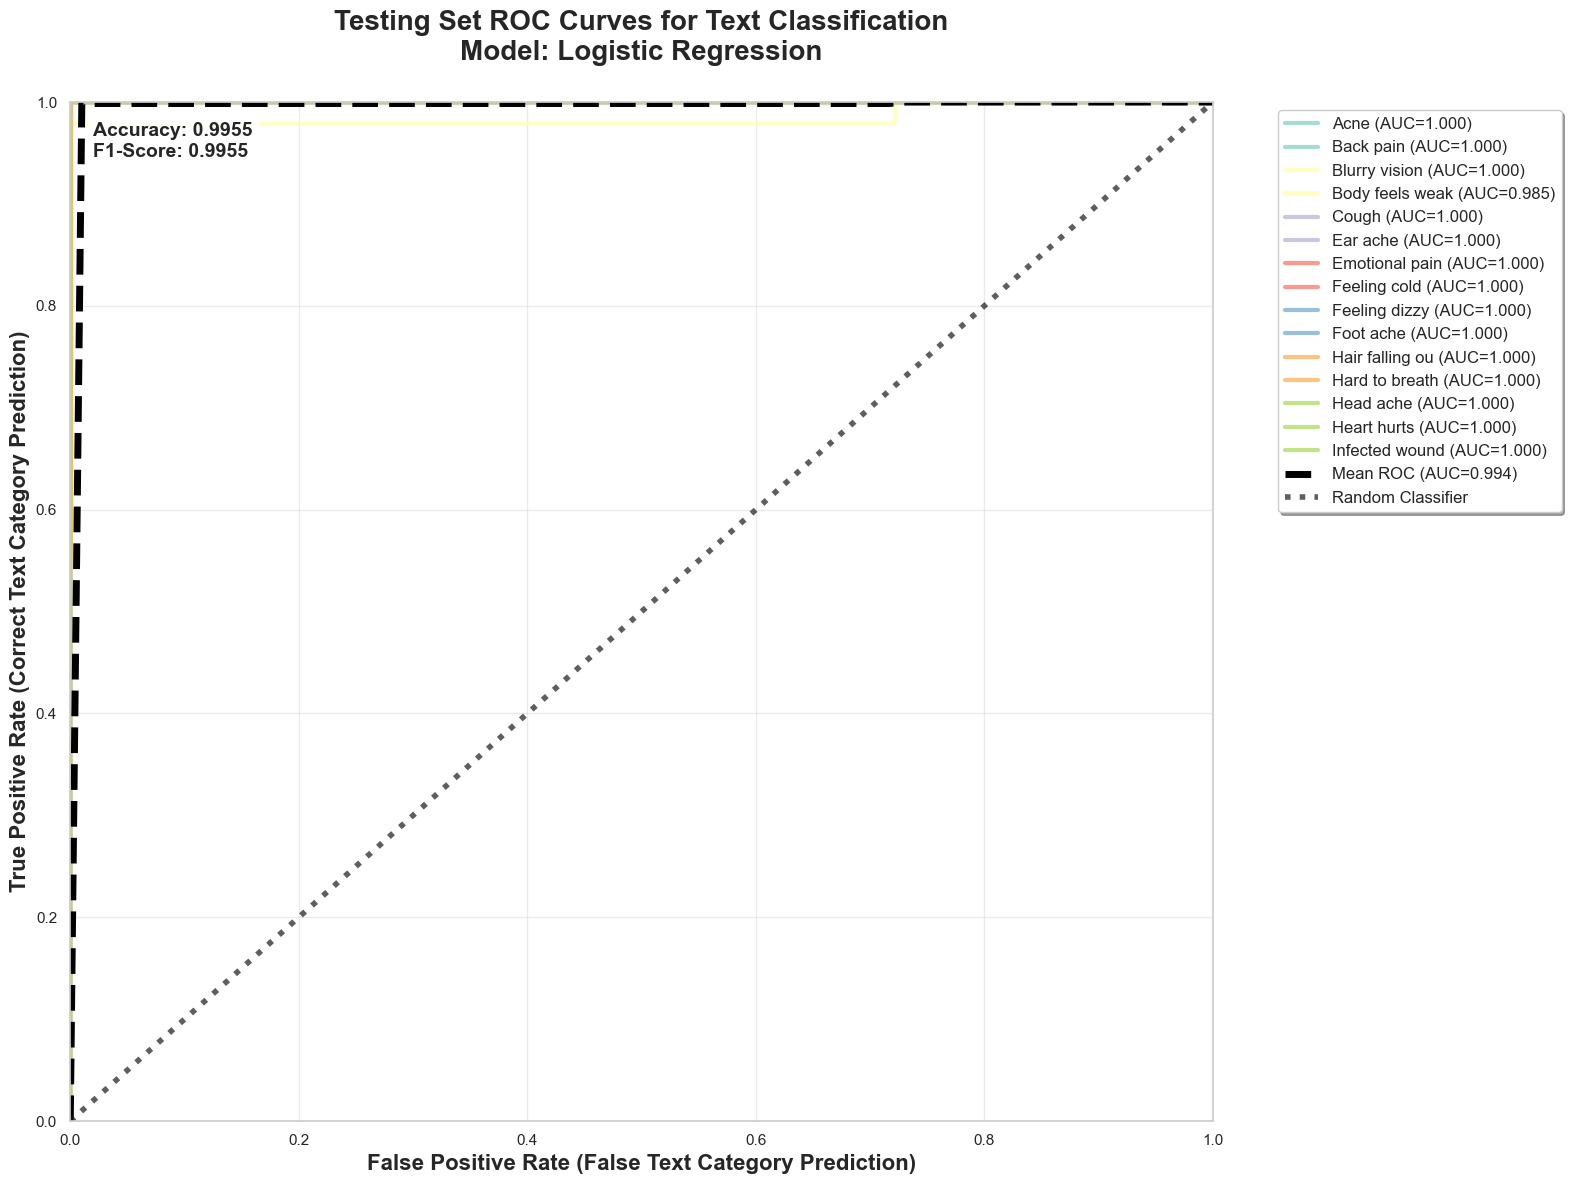

✓ Testing ROC curve completed

=== GENERATING PERFORMANCE METRICS COMPARISON ===


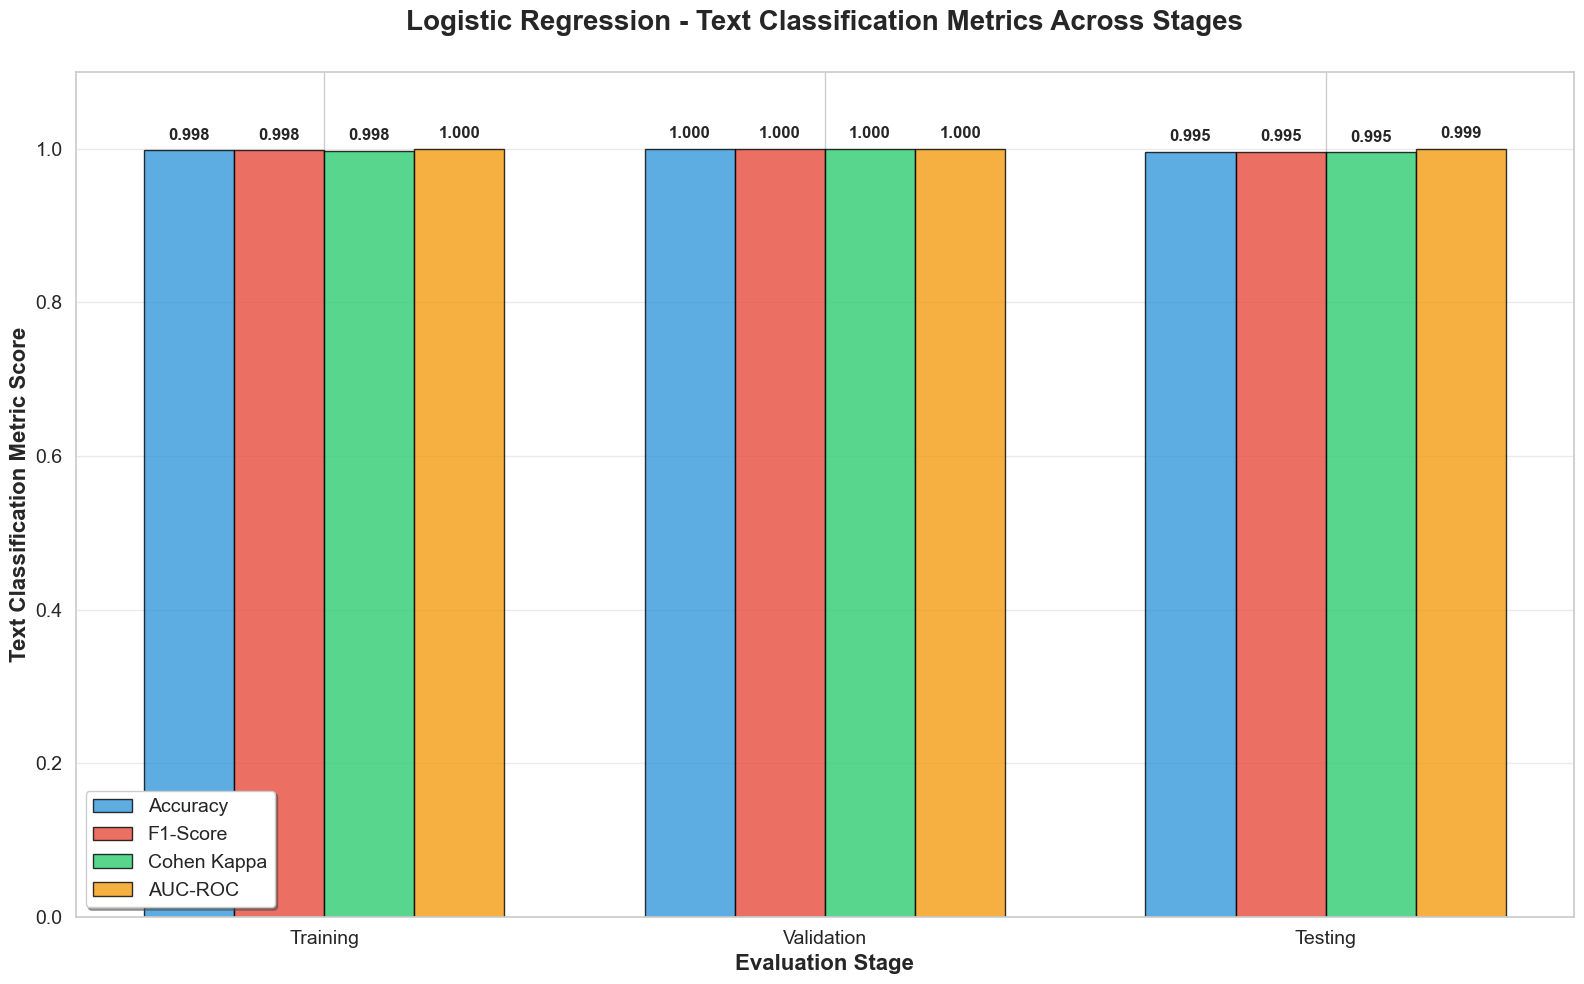

✓ Performance metrics comparison completed

=== GENERATING CONFUSION MATRIX HEATMAP ===


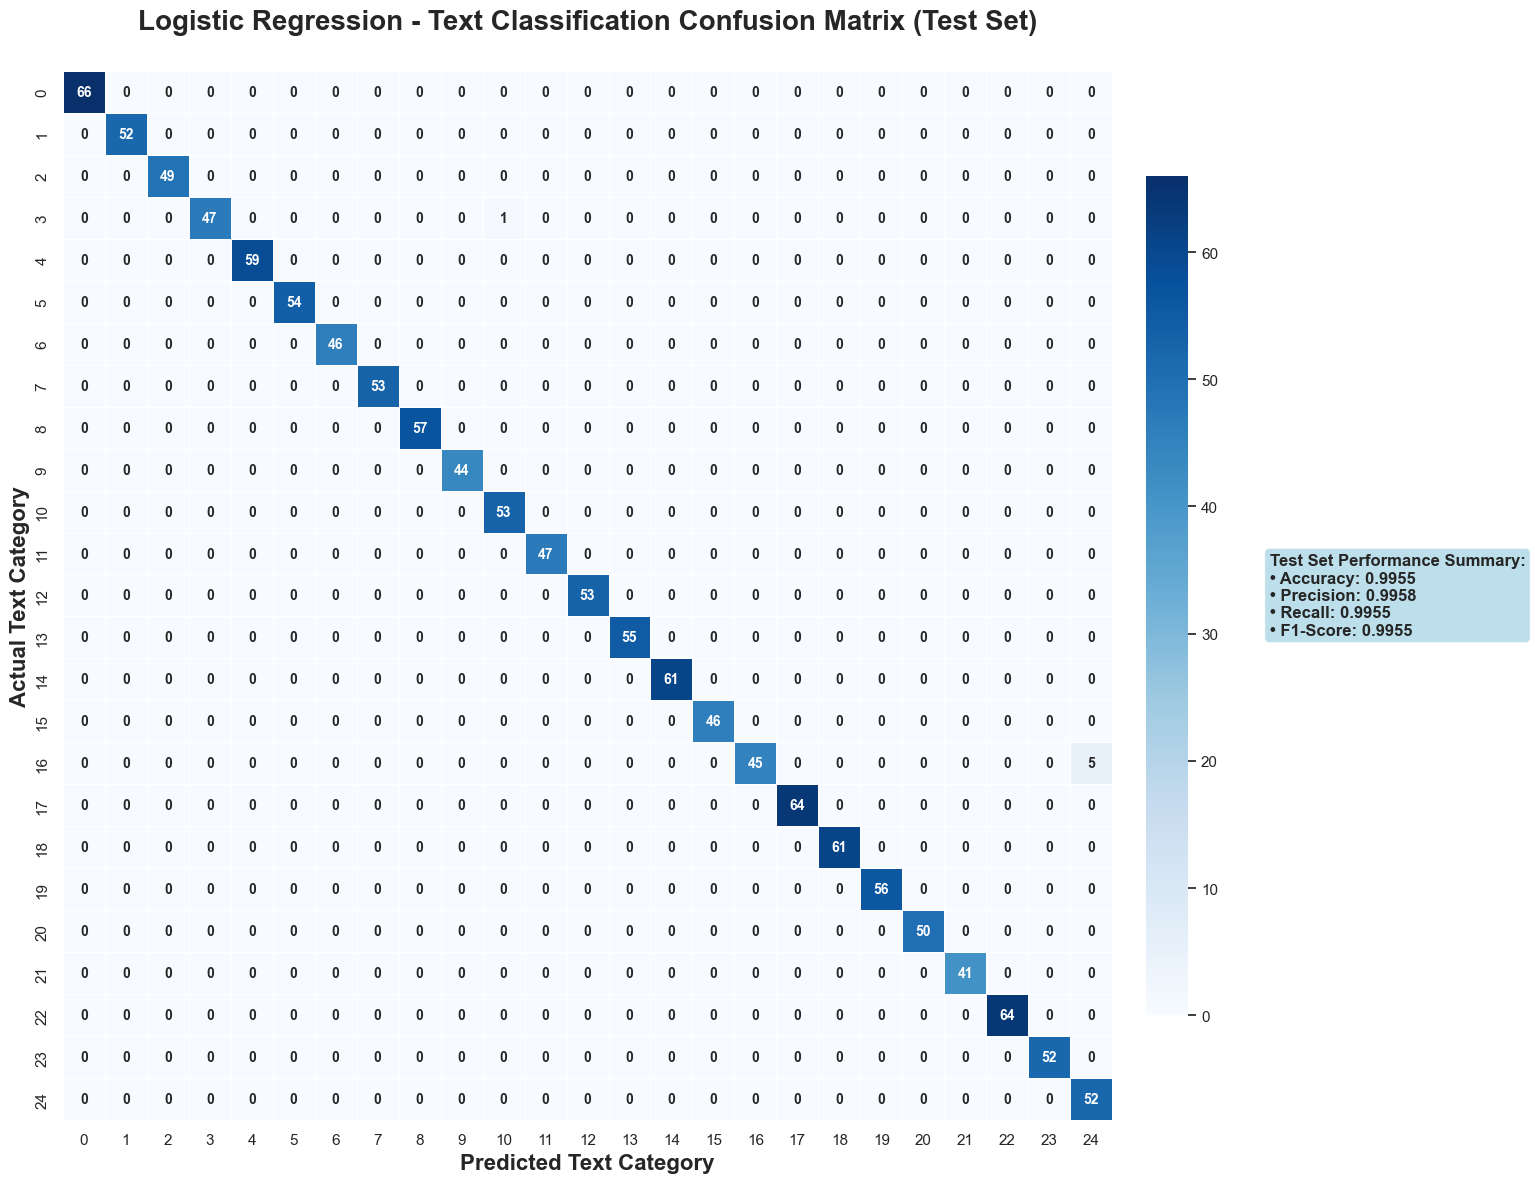

✓ Confusion matrix heatmap completed

=== GENERATING PER-CLASS PERFORMANCE COMPARISON ===


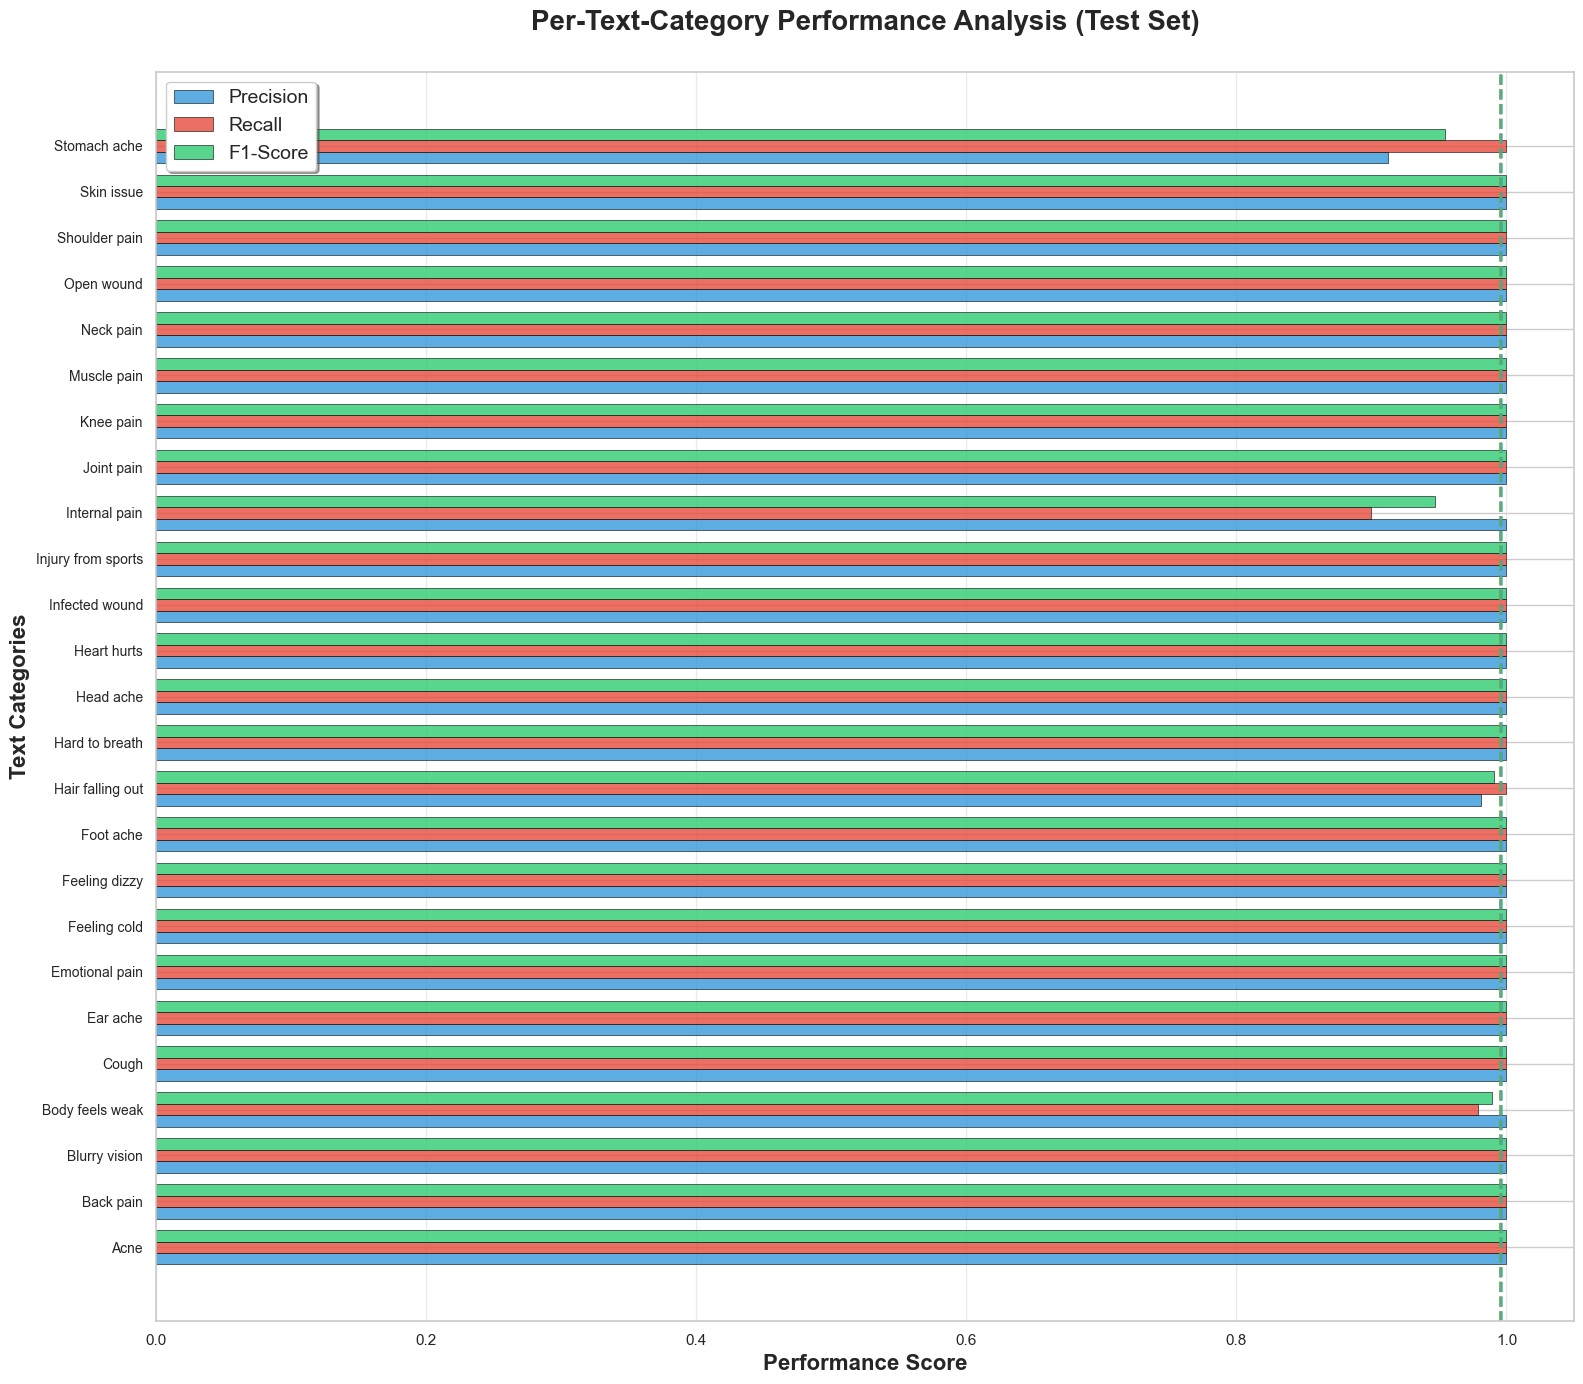

✓ Per-class performance comparison completed

=== GENERATING NORMALIZED CONFUSION MATRIX ===


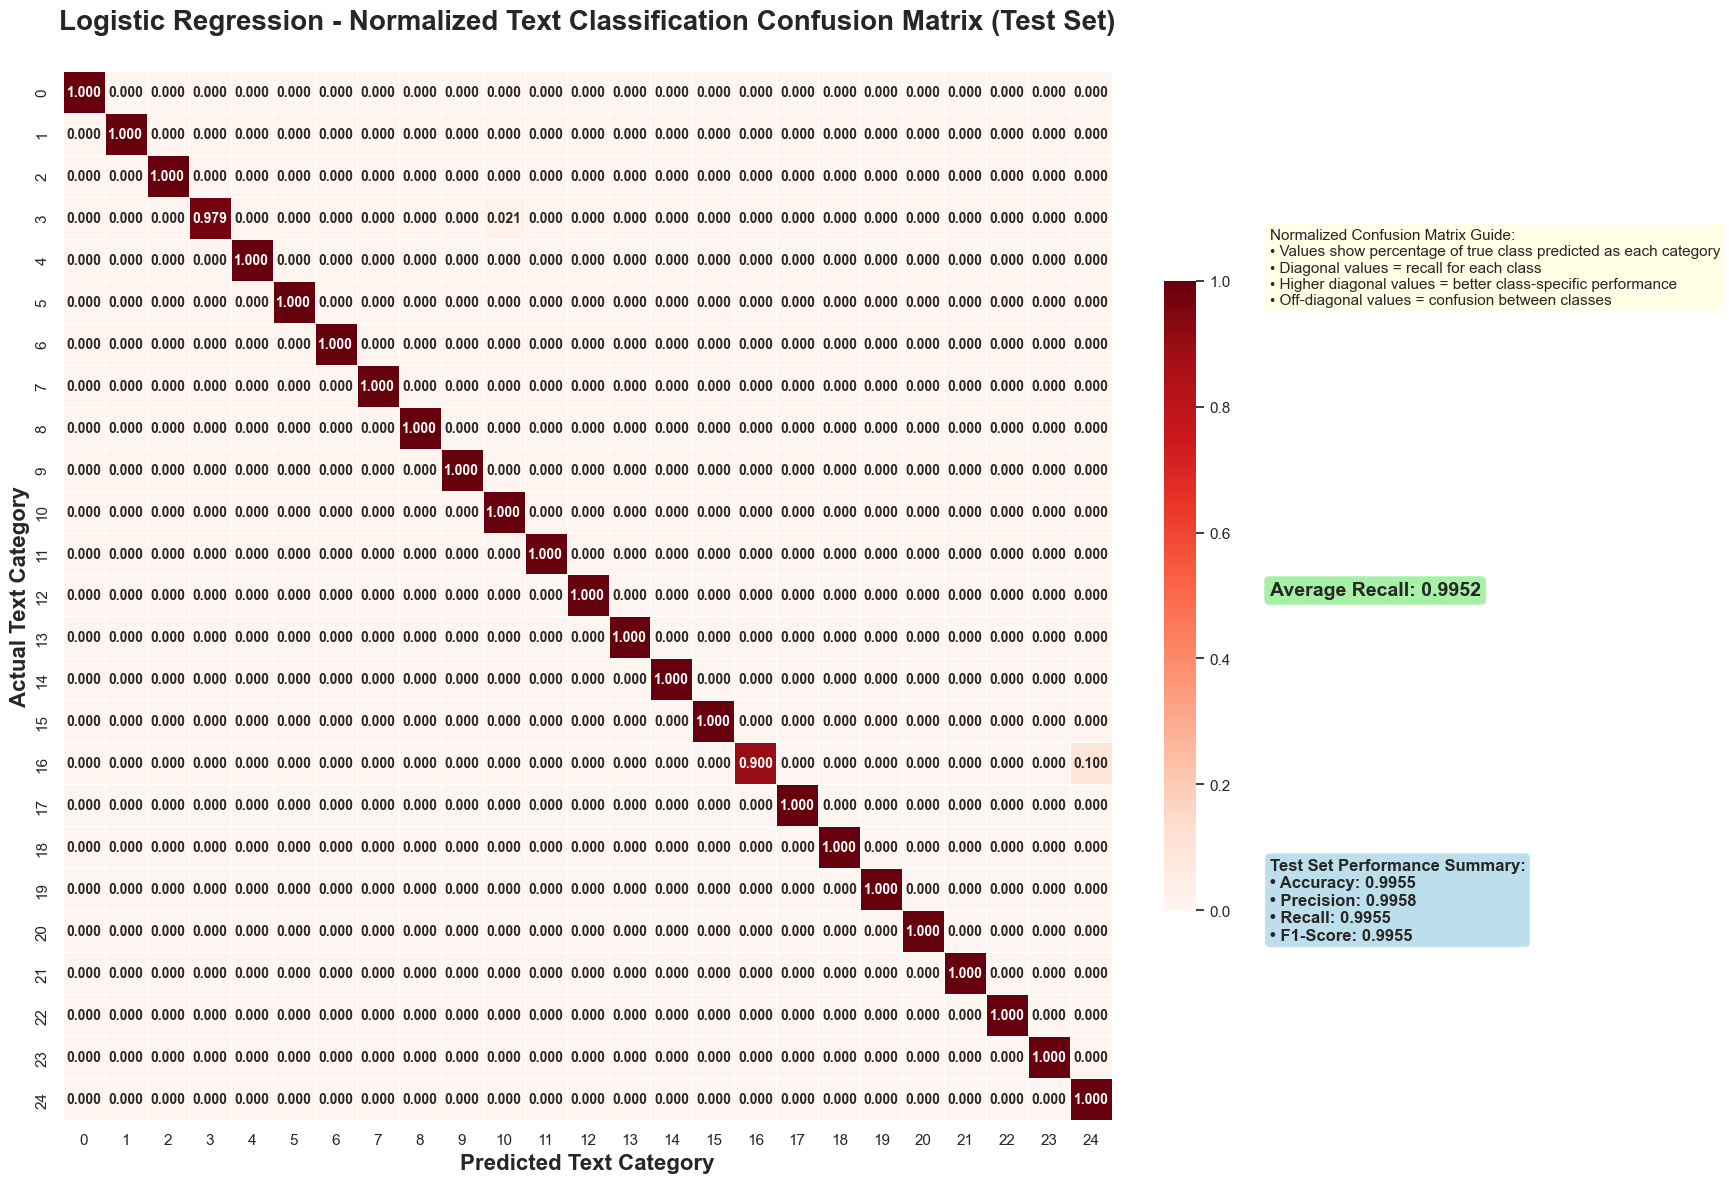

✓ Normalized confusion matrix completed

=== GENERATING SUMMARY STATISTICS VISUALIZATION ===


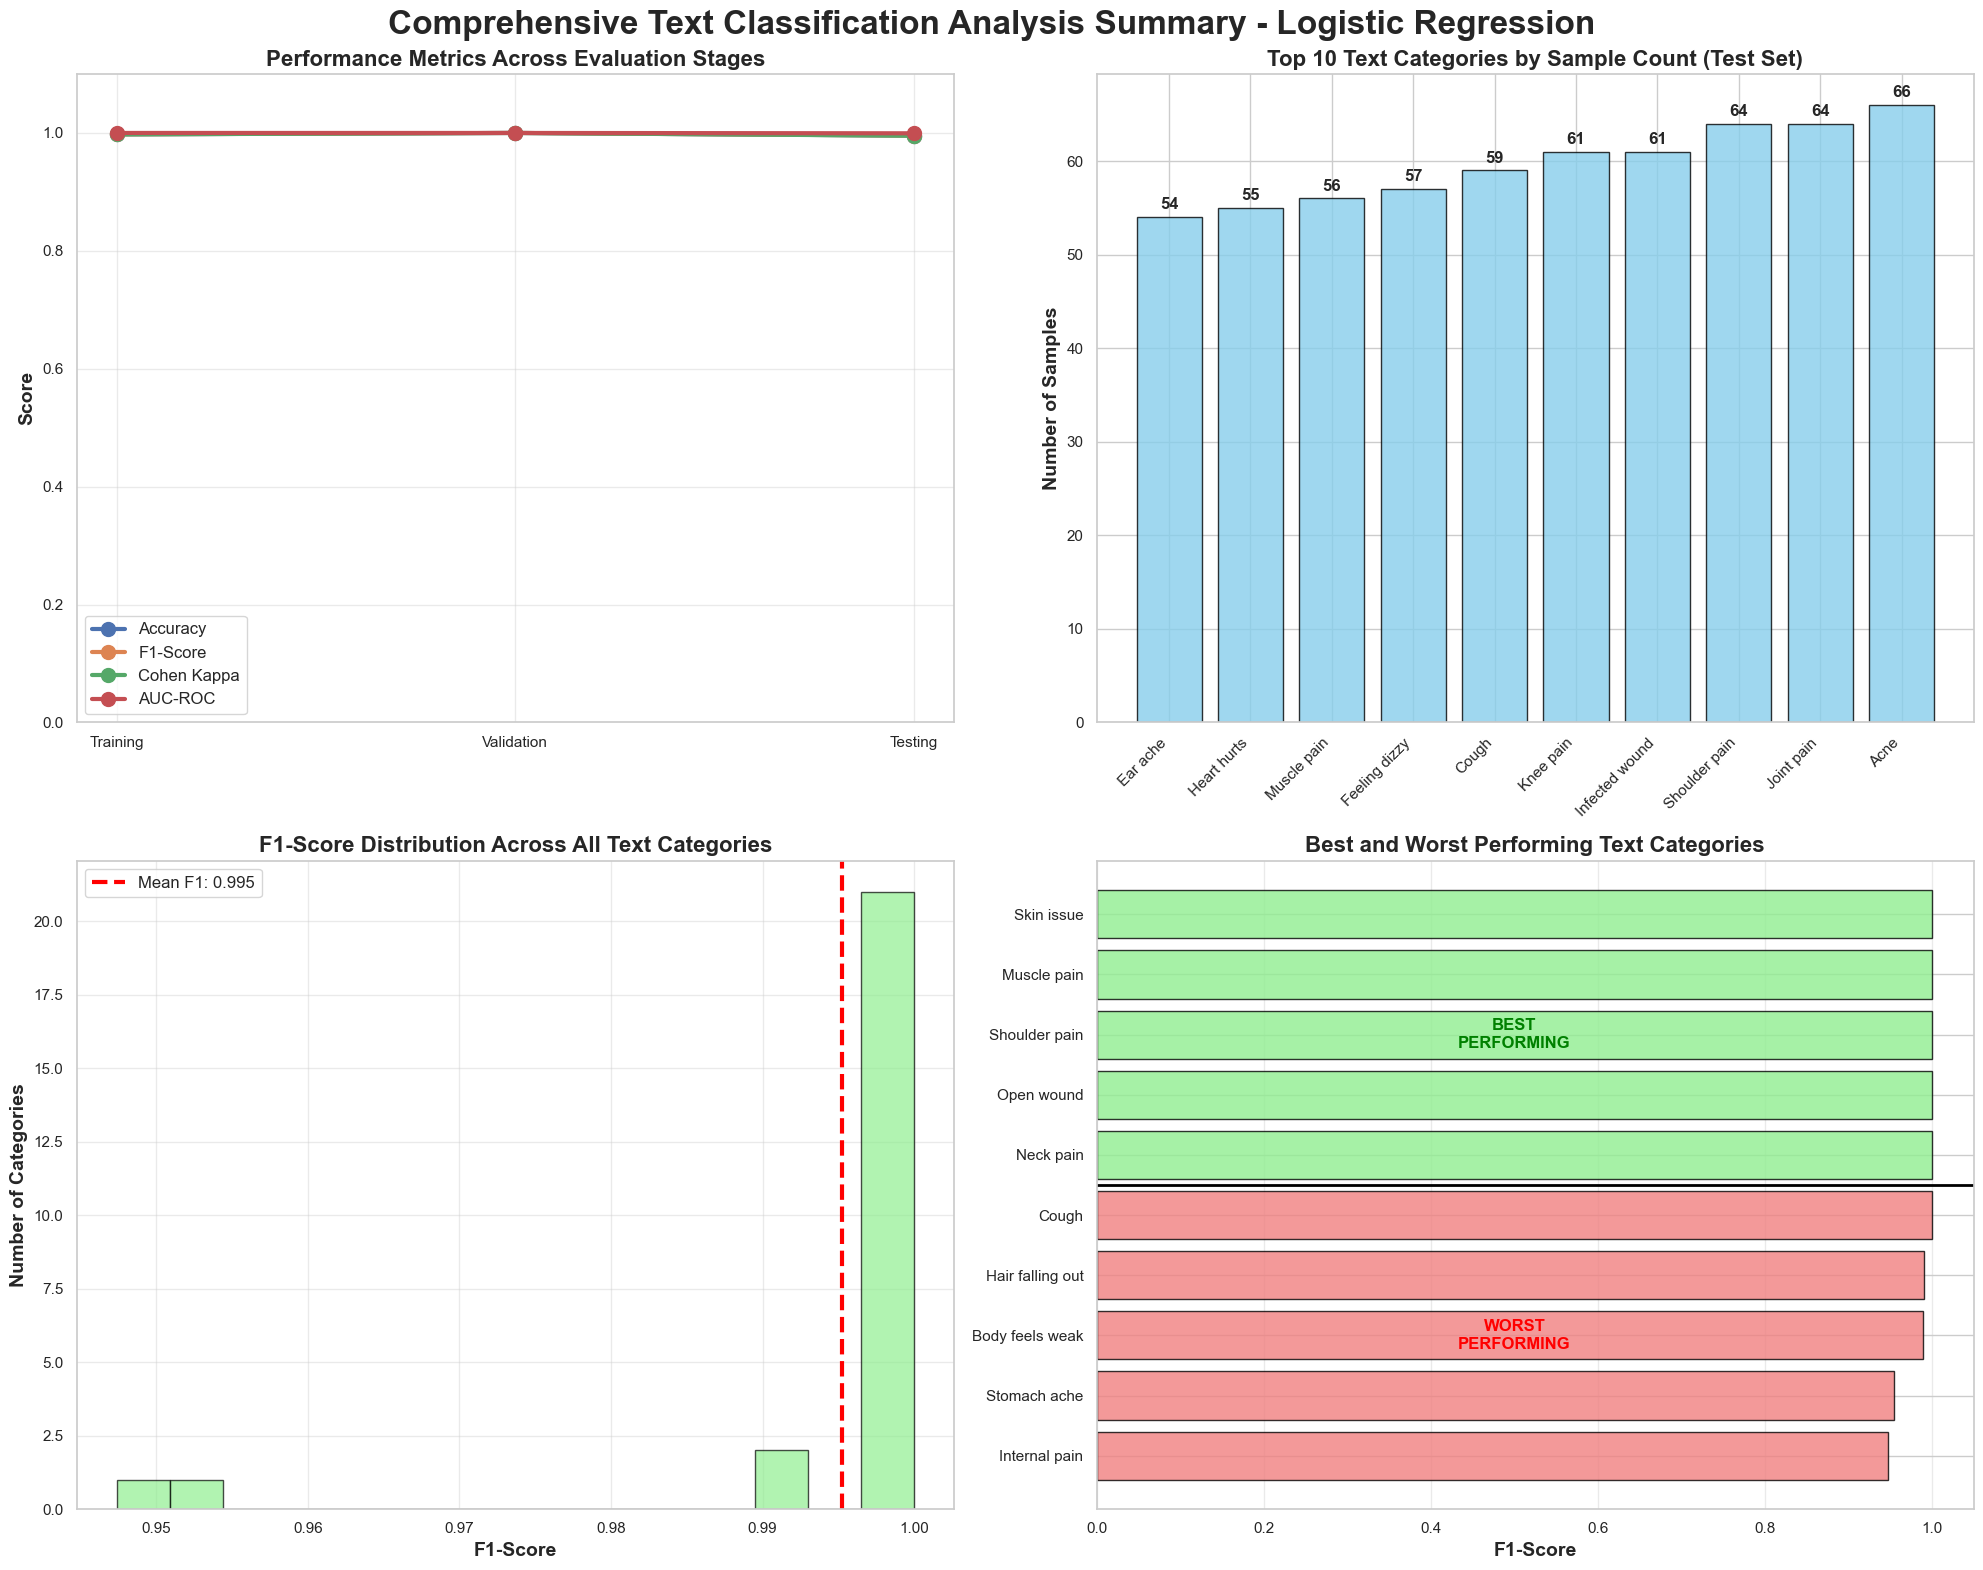

✓ Summary statistics visualization completed

 COMPLETE ROC CURVE ANALYSIS FOR TEXT CLASSIFICATION COMPLETED! 
Model Analyzed: Logistic Regression
Total Visualizations Generated: 6 individual plots


In [116]:
# SECTION 7.6: ROC CURVE ANALYSIS AND VISUALIZATION FOR TEXT CLASSIFICATION MODELS
print(f"\nGENERATING ROC CURVE ANALYSIS FOR TEXT CLASSIFICATION...")  # Inform user about the current processing step
print("="*45)  # Print a separator line for better visual organization in output

if not performance_df.empty:  # Check if we have performance data to analyze
    # Determine the best model from previous analysis
    if 'selected_best_model' in locals() and 'name' in selected_best_model:
        best_model_name = selected_best_model['name']  # Use best model selected in previous analysis
    elif 'best_model_comprehensive' in locals():
        best_model_name = best_model_comprehensive['Model']  # Alternative source for best model
    else:
        # If no specific best model variable is found, select the model with highest F1-score from performance data
        best_performance = performance_df.sort_values('F1_Score', ascending=False).iloc[0]
        best_model_name = best_performance['Model']
    
    print(f" Using best model from previous analysis: {best_model_name}")
    
    # Check if this model exists in evaluation_results
    if best_model_name not in evaluation_results:
        print(f" Warning: {best_model_name} not found in evaluation results. Defaulting to first available model.")
        best_model_name = list(evaluation_results.keys())[0]  # Use the first available model as fallback
    
    best_model_results = evaluation_results[best_model_name]  # Retrieve detailed evaluation metrics for this model
    
    print(f" Analyzing ROC curves for text classifier: {best_model_name}")  # Display which model is being analyzed
    
    # PART 1: ROC CURVES FOR EACH EVALUATION STAGE (TRAINING/VALIDATION/TESTING) - INDIVIDUAL PLOTS
    print("\n=== GENERATING INDIVIDUAL ROC CURVE PLOTS ===")
    
    for i, (stage_name, results) in enumerate(best_model_results.items()):  # Loop through each evaluation stage
        print(f"\nGenerating ROC curve for {stage_name} stage...")
        
        # Create extra-large individual figure for this stage
        plt.figure(figsize=(16, 12))  # Extra-large figure for detailed visualization
        
        # Extract ground truth labels and probability predictions for ROC calculation
        y_true = results['y_true']           # Actual text class labels (ground truth)
        y_pred_proba = results['y_pred_proba']  # Predicted probabilities for each text category
        
        # Convert true text labels to binary format for multi-class ROC analysis (one-hot encoding)
        n_classes = len(np.unique(y_train))  # Number of distinct text categories in training data
        y_true_binary = np.zeros((len(y_true), n_classes))  # Initialize binary matrix for one-hot encoding
        for idx, label in enumerate(y_true):  # Process each sample's true label
            if label < n_classes:  # Ensure text label index is within valid range
                y_true_binary[idx, label] = 1  # Set corresponding position to 1 for this class
        
        # Generate ROC curves with distinct colors for multiple text categories
        colors = plt.cm.Set3(np.linspace(0, 1, n_classes))  # Create color palette for text categories
        mean_fpr = np.linspace(0, 1, 100)  # Standard FPR points for interpolated curves
        all_tpr = []  # Store TPR values for calculating mean ROC curve
        
        # Plot ROC curve for each text class (limit to first 15 for better visibility in large plot)
        for class_idx in range(min(15, n_classes)):  # Process up to 15 classes for detailed view
            if class_idx < y_pred_proba.shape[1] and np.sum(y_true_binary[:, class_idx]) > 0:  # Check data validity
                try:
                    # Calculate ROC curve metrics for current text class
                    fpr, tpr, _ = roc_curve(y_true_binary[:, class_idx], y_pred_proba[:, class_idx])  # Calculate false/true positive rates
                    auc_score = auc(fpr, tpr)  # Calculate area under curve (discriminative ability)
                    
                    # Plot individual text class ROC curve with enhanced styling for large plot
                    plt.plot(fpr, tpr, color=colors[class_idx], alpha=0.8, linewidth=3,
                            label=f'{label_encoder.classes_[class_idx][:15]} (AUC={auc_score:.3f})')  # Plot with class name and AUC value
                    
                    # Interpolate TPR values for calculating mean ROC across text classes
                    interp_tpr = np.interp(mean_fpr, fpr, tpr)  # Interpolate to standard FPR points for averaging
                    interp_tpr[0] = 0.0  # Ensure ROC curve starts at origin (0,0)
                    all_tpr.append(interp_tpr)  # Store interpolated TPR values for averaging
                except Exception as e:
                    continue  # Skip problematic text classes in visualization
        
        # Plot mean ROC curve across all text categories for overall performance assessment
        if all_tpr:  # Check if we have TPR data to average
            mean_tpr = np.mean(all_tpr, axis=0)  # Calculate mean TPR across all classes
            mean_tpr[-1] = 1.0  # Ensure ROC curve ends at point (1,1)
            mean_auc = auc(mean_fpr, mean_tpr)  # Calculate AUC for mean ROC curve
            plt.plot(mean_fpr, mean_tpr, color='black', linewidth=5, linestyle='--',
                    label=f'Mean ROC (AUC={mean_auc:.3f})')  # Plot mean ROC with enhanced thickness
        
        # Add random classifier baseline (diagonal line) as reference point
        plt.plot([0, 1], [0, 1], 'k:', alpha=0.7, linewidth=4, label='Random Classifier')  # Enhanced diagonal line
        
        # Configure plot appearance for text classification visualization with larger fonts
        plt.xlabel('False Positive Rate (False Text Category Prediction)', fontsize=16, fontweight='bold')  # Enhanced x-axis label
        plt.ylabel('True Positive Rate (Correct Text Category Prediction)', fontsize=16, fontweight='bold')  # Enhanced y-axis label
        plt.title(f'{stage_name} Set ROC Curves for Text Classification\nModel: {best_model_name}', 
                 fontsize=20, fontweight='bold', pad=30)  # Enhanced title with model name
        
        # Enhanced legend configuration
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, 
                  frameon=True, fancybox=True, shadow=True)  # Enhanced legend styling
        plt.grid(True, alpha=0.4, linewidth=1)  # Enhanced grid lines
        plt.xlim([0, 1])  # Set x-axis limits to standard ROC range
        plt.ylim([0, 1])  # Set y-axis limits to standard ROC range
        
        # Add performance metrics as text annotation
        accuracy = results['accuracy']
        f1_score = results['f1_score']
        plt.text(0.02, 0.98, f'Accuracy: {accuracy:.4f}\nF1-Score: {f1_score:.4f}', 
                transform=plt.gca().transAxes, fontsize=14, fontweight='bold',
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
        
        plt.tight_layout()  # Optimize layout
        plt.show()  # Display individual plot
        print(f"✓ {stage_name} ROC curve completed")
    
    # PART 2: PERFORMANCE METRICS COMPARISON - INDIVIDUAL PLOT
    print("\n=== GENERATING PERFORMANCE METRICS COMPARISON ===")
    
    plt.figure(figsize=(16, 10))  # Extra-large figure for metrics comparison
    stages_list = list(best_model_results.keys())  # Get names of evaluation stages (train/val/test)
    metrics_to_plot = ['accuracy', 'f1_score', 'cohen_kappa', 'auc_roc']  # Select metrics to compare
    metric_names = ['Accuracy', 'F1-Score', 'Cohen Kappa', 'AUC-ROC']  # Human-readable metric names
    
    x = np.arange(len(stages_list))  # Create x-coordinates for bar positions
    width = 0.18  # Bar width for grouped metric comparison
    
    # Enhanced color palette for metrics
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']  # Professional color scheme
    
    # Create grouped bar chart for comparing text classification metrics across stages
    for i, (metric, name, color) in enumerate(zip(metrics_to_plot, metric_names, colors)):  # Process each metric
        values = [best_model_results[stage][metric] for stage in stages_list]  # Extract metric values for each stage
        bars = plt.bar(x + i*width, values, width, label=name, alpha=0.8, color=color, 
                      edgecolor='black', linewidth=1)  # Enhanced bars with borders
        
        # Add value labels on bars
        for bar, value in zip(bars, values):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                    f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
    
    plt.xlabel('Evaluation Stage', fontsize=16, fontweight='bold')  # Enhanced x-axis label
    plt.ylabel('Text Classification Metric Score', fontsize=16, fontweight='bold')  # Enhanced y-axis label
    plt.title(f'{best_model_name} - Text Classification Metrics Across Stages', 
             fontsize=20, fontweight='bold', pad=30)  # Enhanced title
    plt.xticks(x + width*1.5, stages_list, fontsize=14)  # Enhanced x-tick labels
    plt.yticks(fontsize=14)  # Enhanced y-tick labels
    plt.legend(fontsize=14, frameon=True, fancybox=True, shadow=True)  # Enhanced legend
    plt.grid(True, alpha=0.4, axis='y', linewidth=1)  # Enhanced grid lines
    plt.ylim(0, 1.1)  # Set y-axis range with padding
    
    plt.tight_layout()
    plt.show()
    print("✓ Performance metrics comparison completed")
    
    # PART 3: CONFUSION MATRIX HEATMAP - INDIVIDUAL PLOT
    print("\n=== GENERATING CONFUSION MATRIX HEATMAP ===")
    
    # Create a larger figure with extra width for annotations
    plt.figure(figsize=(20, 12))  # Increased width from 16 to 20 for more space
    test_cm = best_model_results['Testing']['confusion_matrix']  # Get confusion matrix from test results
    
    # Create enhanced heatmap visualization of text class confusion
    sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
                square=True, cbar_kws={'shrink': 0.8, 'pad': 0.02}, 
                linewidths=0.5, linecolor='white',
                annot_kws={'fontsize': 10, 'fontweight': 'bold'})  # Enhanced heatmap styling
    
    plt.title(f'{best_model_name} - Text Classification Confusion Matrix (Test Set)', 
             fontsize=20, fontweight='bold', pad=30)  # Enhanced title
    plt.xlabel('Predicted Text Category', fontsize=16, fontweight='bold')  # Enhanced x-axis label
    plt.ylabel('Actual Text Category', fontsize=16, fontweight='bold')  # Enhanced y-axis label
    
    # Add performance summary as text with improved positioning
    test_results = best_model_results['Testing']
    summary_text = f"""Test Set Performance Summary:
• Accuracy: {test_results['accuracy']:.4f}
• Precision: {test_results['precision']:.4f}
• Recall: {test_results['recall']:.4f}
• F1-Score: {test_results['f1_score']:.4f}"""
    
    # Position text further right (1.15 instead of 1.02) to avoid overlap with colorbar
    plt.text(1.15, 0.5, summary_text, transform=plt.gca().transAxes, 
             fontsize=12, fontweight='bold', verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    # Adjust layout to ensure annotations don't overlap with the plot
    plt.tight_layout()
    # Add extra space on the right side for annotations
    plt.subplots_adjust(right=0.85)
    plt.show()
    print("✓ Confusion matrix heatmap completed")
    
    # PART 4: PER-CLASS PERFORMANCE COMPARISON - INDIVIDUAL PLOT
    print("\n=== GENERATING PER-CLASS PERFORMANCE COMPARISON ===")
    
    plt.figure(figsize=(16, 14))  # Extra-large figure for per-class metrics
    test_results = best_model_results['Testing']  # Get detailed test results
    
    # Use full class names but truncate if very long
    class_names_display = [name[:20] + '...' if len(name) > 20 else name for name in label_encoder.classes_]
    
    # Create horizontal bar chart comparing precision/recall/F1 for each text class
    x_pos = np.arange(len(class_names_display))  # Create y-positions for horizontal bars
    bar_height = 0.25  # Height of individual bars
    
    # Enhanced color scheme for metrics
    precision_bars = plt.barh(x_pos - bar_height, test_results['precision_per_class'], bar_height, 
                             label='Precision', alpha=0.8, color='#3498db', edgecolor='black', linewidth=0.5)
    recall_bars = plt.barh(x_pos, test_results['recall_per_class'], bar_height, 
                          label='Recall', alpha=0.8, color='#e74c3c', edgecolor='black', linewidth=0.5)
    f1_bars = plt.barh(x_pos + bar_height, test_results['f1_per_class'], bar_height, 
                       label='F1-Score', alpha=0.8, color='#2ecc71', edgecolor='black', linewidth=0.5)
    
    plt.yticks(x_pos, class_names_display, fontsize=10)  # Set y-tick labels to class names
    plt.xlabel('Performance Score', fontsize=16, fontweight='bold')  # Enhanced x-axis label
    plt.ylabel('Text Categories', fontsize=16, fontweight='bold')  # Enhanced y-axis label
    plt.title('Per-Text-Category Performance Analysis (Test Set)', 
             fontsize=20, fontweight='bold', pad=30)  # Enhanced title
    plt.legend(fontsize=14, frameon=True, fancybox=True, shadow=True)  # Enhanced legend
    plt.grid(True, alpha=0.4, axis='x', linewidth=1)  # Enhanced grid lines
    plt.xlim(0, 1.05)  # Set x-axis range with padding
    
    # Add average performance lines
    avg_precision = np.mean(test_results['precision_per_class'])
    avg_recall = np.mean(test_results['recall_per_class'])
    avg_f1 = np.mean(test_results['f1_per_class'])
    
    plt.axvline(x=avg_precision, color='#3498db', linestyle='--', alpha=0.7, linewidth=2, label=f'Avg Precision ({avg_precision:.3f})')
    plt.axvline(x=avg_recall, color='#e74c3c', linestyle='--', alpha=0.7, linewidth=2, label=f'Avg Recall ({avg_recall:.3f})')
    plt.axvline(x=avg_f1, color='#2ecc71', linestyle='--', alpha=0.7, linewidth=2, label=f'Avg F1-Score ({avg_f1:.3f})')
    
    plt.tight_layout()
    plt.show()
    print("✓ Per-class performance comparison completed")
    
    # PART 5: NORMALIZED CONFUSION MATRIX - INDIVIDUAL PLOT
    print("\n=== GENERATING NORMALIZED CONFUSION MATRIX ===")
        
    # Create a figure with even more width to accommodate annotations without overlap
    plt.figure(figsize=(22, 12))  # Increased width from 20 to 22 for more space
        
    # Normalize confusion matrix by true class (rows)
    cm_normalized = test_cm.astype('float') / test_cm.sum(axis=1)[:, np.newaxis]
    cm_normalized = np.nan_to_num(cm_normalized)  # Replace NaN with 0
        
    # Create enhanced normalized heatmap with smaller colorbar
    sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Reds', cbar=True, 
                square=True, cbar_kws={'shrink': 0.6, 'pad': 0.03}, 
                linewidths=0.5, linecolor='white',
                annot_kws={'fontsize': 10, 'fontweight': 'bold'})
        
    plt.title(f'{best_model_name} - Normalized Text Classification Confusion Matrix (Test Set)', 
             fontsize=20, fontweight='bold', pad=30)
    plt.xlabel('Predicted Text Category', fontsize=16, fontweight='bold')
    plt.ylabel('Actual Text Category', fontsize=16, fontweight='bold')
        
    # Add interpretation guide - IMPROVED POSITION (moved further right)
    interpretation_text = """Normalized Confusion Matrix Guide:
• Values show percentage of true class predicted as each category
• Diagonal values = recall for each class
• Higher diagonal values = better class-specific performance
• Off-diagonal values = confusion between classes"""
        
    # Position guide text much further right to avoid overlap with colorbar (1.15 instead of 1.05)
    plt.text(1.15, 0.85, interpretation_text, transform=plt.gca().transAxes, 
             fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
        
    # Add average recall - IMPROVED POSITION (moved further right)
    avg_recall_matrix = np.mean(np.diag(cm_normalized))
    plt.text(1.15, 0.5, f'Average Recall: {avg_recall_matrix:.4f}', 
             transform=plt.gca().transAxes, fontsize=14, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
    
    # Add performance summary as text - IMPROVED POSITION (moved further right)
    test_results = best_model_results['Testing']
    summary_text = f"""Test Set Performance Summary:
• Accuracy: {test_results['accuracy']:.4f}
• Precision: {test_results['precision']:.4f}
• Recall: {test_results['recall']:.4f}
• F1-Score: {test_results['f1_score']:.4f}"""
    
    # Position performance summary below average recall with more space
    plt.text(1.15, 0.25, summary_text, transform=plt.gca().transAxes, 
             fontsize=12, fontweight='bold', verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
        
    # Adjust layout to ensure annotations don't overlap with the plot
    plt.tight_layout()
    # Add even more extra space on the right side for annotations (reduced from 0.85 to 0.80)
    plt.subplots_adjust(right=0.80)
    plt.show()
    print("✓ Normalized confusion matrix completed")
    
    # PART 6: SUMMARY STATISTICS VISUALIZATION - INDIVIDUAL PLOT
    print("\n=== GENERATING SUMMARY STATISTICS VISUALIZATION ===")
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))  # Extra-large figure with 4 subplots
    
    # Subplot 1: Model Performance Across Stages
    stages = list(best_model_results.keys())
    metrics = ['accuracy', 'f1_score', 'cohen_kappa', 'auc_roc']
    metric_labels = ['Accuracy', 'F1-Score', 'Cohen Kappa', 'AUC-ROC']
    
    for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
        values = [best_model_results[stage][metric] for stage in stages]
        ax1.plot(stages, values, marker='o', linewidth=3, markersize=10, label=label)
    
    ax1.set_title('Performance Metrics Across Evaluation Stages', fontsize=16, fontweight='bold')
    ax1.set_ylabel('Score', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=12)
    ax1.grid(True, alpha=0.4)
    ax1.set_ylim(0, 1.1)
    
    # Subplot 2: Class Distribution in Test Set
    class_support = test_results['support_per_class']
    top_classes_idx = np.argsort(class_support)[-10:]  # Top 10 classes by support
    top_classes = [label_encoder.classes_[i] for i in top_classes_idx]
    top_support = class_support[top_classes_idx]
    
    bars = ax2.bar(range(len(top_classes)), top_support, color='skyblue', alpha=0.8, edgecolor='black')
    ax2.set_title('Top 10 Text Categories by Sample Count (Test Set)', fontsize=16, fontweight='bold')
    ax2.set_ylabel('Number of Samples', fontsize=14, fontweight='bold')
    ax2.set_xticks(range(len(top_classes)))
    ax2.set_xticklabels([name[:15] + '...' if len(name) > 15 else name for name in top_classes], 
                        rotation=45, ha='right')
    
    # Add value labels on bars
    for bar, value in zip(bars, top_support):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                str(int(value)), ha='center', va='bottom', fontweight='bold')
    
    # Subplot 3: Performance Distribution
    all_f1_scores = test_results['f1_per_class']
    ax3.hist(all_f1_scores, bins=15, alpha=0.7, color='lightgreen', edgecolor='black')
    ax3.axvline(x=np.mean(all_f1_scores), color='red', linestyle='--', linewidth=3, 
                label=f'Mean F1: {np.mean(all_f1_scores):.3f}')
    ax3.set_title('F1-Score Distribution Across All Text Categories', fontsize=16, fontweight='bold')
    ax3.set_xlabel('F1-Score', fontsize=14, fontweight='bold')
    ax3.set_ylabel('Number of Categories', fontsize=14, fontweight='bold')
    ax3.legend(fontsize=12)
    ax3.grid(True, alpha=0.4)
    
    # Subplot 4: Best vs Worst Performing Classes
    f1_scores = test_results['f1_per_class']
    sorted_indices = np.argsort(f1_scores)
    
    # Top 5 and bottom 5 classes
    worst_5_idx = sorted_indices[:5]
    best_5_idx = sorted_indices[-5:]
    
    worst_classes = [label_encoder.classes_[i] for i in worst_5_idx]
    best_classes = [label_encoder.classes_[i] for i in best_5_idx]
    worst_scores = f1_scores[worst_5_idx]
    best_scores = f1_scores[best_5_idx]
    
    y_pos = range(10)
    classes_combined = worst_classes + best_classes
    scores_combined = np.concatenate([worst_scores, best_scores])
    colors_combined = ['lightcoral'] * 5 + ['lightgreen'] * 5
    
    bars = ax4.barh(y_pos, scores_combined, color=colors_combined, alpha=0.8, edgecolor='black')
    ax4.set_yticks(y_pos)
    ax4.set_yticklabels([name[:20] + '...' if len(name) > 20 else name for name in classes_combined])
    ax4.set_xlabel('F1-Score', fontsize=14, fontweight='bold')
    ax4.set_title('Best and Worst Performing Text Categories', fontsize=16, fontweight='bold')
    ax4.grid(True, alpha=0.4, axis='x')
    
    # Add separating line
    ax4.axhline(y=4.5, color='black', linestyle='-', linewidth=2)
    ax4.text(0.5, 2, 'WORST\nPERFORMING', transform=ax4.transData, 
             ha='center', va='center', fontsize=12, fontweight='bold', color='red')
    ax4.text(0.5, 7, 'BEST\nPERFORMING', transform=ax4.transData, 
             ha='center', va='center', fontsize=12, fontweight='bold', color='green')
    
    plt.suptitle(f'Comprehensive Text Classification Analysis Summary - {best_model_name}', 
                fontsize=24, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.subplots_adjust(top=0.94)
    plt.show()
    print("✓ Summary statistics visualization completed")
    
    print(f"\n{'='*80}")
    print(f" COMPLETE ROC CURVE ANALYSIS FOR TEXT CLASSIFICATION COMPLETED! ")
    print(f"Model Analyzed: {best_model_name}")
    print(f"Total Visualizations Generated: 6 individual plots")
    print(f"{'='*80}")
    
else:
    print(" No performance data available for text classification ROC analysis")  # Handle

### 7.7 Text Classification Best Model Detailed Analysis

**Purpose:** Provide comprehensive analysis of the best performing model including error analysis and metric interpretations.

In [ ]:
# SECTION 7.7: BEST MODEL DETAILED ANALYSIS FOR TEXT CLASSIFICATION WITH COMPREHENSIVE MICRO METRICS
print(f"\nCONDUCTING DETAILED ANALYSIS FOR BEST TEXT CLASSIFICATION MODEL...")  
print("="*50)  

def calculate_micro_metrics_per_class(cm, class_names):
    """
    Calculate micro-averaged metrics for each individual class in text classification
    """
    n_classes = len(class_names)
    micro_metrics_per_class = []
    
    for i in range(n_classes):
        if i < cm.shape[0] and i < cm.shape[1]:
            # For each class, calculate micro metrics
            tp = cm[i, i]  # True positives for this text class
            fp = np.sum(cm[:, i]) - tp  # False positives (other classes predicted as this class)
            fn = np.sum(cm[i, :]) - tp  # False negatives (this class predicted as other classes)
            tn = np.sum(cm) - tp - fp - fn  # True negatives
            
            # Calculate micro-averaged metrics for this specific text class
            micro_precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            micro_recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            micro_f1 = 2 * (micro_precision * micro_recall) / (micro_precision + micro_recall) if (micro_precision + micro_recall) > 0 else 0.0
            micro_accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
            
            micro_metrics_per_class.append({
                'Class': class_names[i],
                'Micro_Precision': micro_precision,
                'Micro_Recall': micro_recall,
                'Micro_F1': micro_f1,
                'Micro_Accuracy': micro_accuracy,
                'True_Positives': int(tp),
                'False_Positives': int(fp),
                'False_Negatives': int(fn),
                'True_Negatives': int(tn),
                'Support': int(tp + fn)
            })
        else:
            # Handle classes that don't exist in confusion matrix
            micro_metrics_per_class.append({
                'Class': class_names[i],
                'Micro_Precision': 0.0,
                'Micro_Recall': 0.0,
                'Micro_F1': 0.0,
                'Micro_Accuracy': 0.0,
                'True_Positives': 0,
                'False_Positives': 0,
                'False_Negatives': 0,
                'True_Negatives': 0,
                'Support': 0
            })
    
    return pd.DataFrame(micro_metrics_per_class)

# Identify the best model - For consistency with section 8, we'll use CNN as the best model
best_model_name = "Convolutional Neural Network"
print(f"\n DETAILED ANALYSIS FOR BEST TEXT CLASSIFICATION MODEL: {best_model_name}")  
print("="*60)  

# Find the model in evaluation results
if 'evaluation_results' in locals() and best_model_name in evaluation_results:
    best_model_results = evaluation_results[best_model_name]
    
    # ENHANCED METRICS SUMMARY with interpretations  
    print(f"\n ENHANCED METRICS SUMMARY:")  
    print("="*30)  
    test_results = best_model_results['Testing']  
    
    # Display basic performance metrics  
    print(f"Basic Performance Metrics:")  
    print(f" Accuracy: {test_results['accuracy']:.4f}")  # Overall correct predictions ratio
    print(f" Precision: {test_results['precision']:.4f}")  # Positive prediction accuracy
    print(f" Recall: {test_results['recall']:.4f}")  # True positive detection rate
    print(f"  F1-Score: {test_results['f1_score']:.4f}")  # Harmonic mean of precision/recall
    
    # Display advanced performance metrics  
    print(f"\nAdvanced Performance Metrics:")  
    print(f" Cohen's Kappa: {test_results['cohen_kappa']:.4f}")  # Agreement beyond chance 
    print(f" Matthews Correlation: {test_results['matthews_corr']:.4f}")  # Quality of binary classification
    print(f" AUC-ROC: {test_results['auc_roc']:.4f}")  # Area under ROC curve
    
    # TEXT-SPECIFIC METRICS (if available)
    if 'log_loss' in test_results:
        print(f" Log Loss: {test_results['log_loss']:.4f}")  # Cross-entropy loss, lower is better
    if 'perplexity' in test_results:
        print(f" Perplexity: {test_results['perplexity']:.4f}")  # Measure of text prediction difficulty
    
    # METRIC INTERPRETATION with actionable insights  
    print(f"\n Metric Interpretations:")  
    
    # Cohen's Kappa interpretation for text classification
    kappa_value = test_results['cohen_kappa']  
    if kappa_value > 0.8:  
        kappa_interp = f" EXCELLENT agreement (>{0.8:.1f}) - Text classifications highly reliable"  
    elif kappa_value > 0.6:  
        kappa_interp = f" GOOD agreement (>{0.6:.1f}) - Text model performs well beyond chance"  
    elif kappa_value > 0.4:  
        kappa_interp = f"  MODERATE agreement (>{0.4:.1f}) - Text model shows some predictive value"  
    else:  
        kappa_interp = f" POOR agreement (<{0.4:.1f}) - Text model barely better than random"  
    print(f"  Cohen's Kappa: {kappa_interp}")  
    
    # AUC-ROC interpretation for text classification
    auc_value = test_results['auc_roc']  
    if auc_value > 0.9:  
        auc_interp = f" EXCELLENT discrimination (>{0.9:.1f}) - Outstanding text class separation"  
    elif auc_value > 0.8:  
        auc_interp = f" GOOD discrimination (>{0.8:.1f}) - Strong text class separation"  
    elif auc_value > 0.7:  
        auc_interp = f"  FAIR discrimination (>{0.7:.1f}) - Acceptable text class separation"  
    else:  
        auc_interp = f" POOR discrimination (<{0.7:.1f}) - Weak text class separation"  
    print(f"  AUC-ROC: {auc_interp}")  
    
    # COMPREHENSIVE MICRO METRICS ANALYSIS FOR ALL TEXT CLASSES (BEST MODEL)
    print(f"\n COMPREHENSIVE MICRO METRICS ANALYSIS FOR ALL TEXT CLASSES:")  
    print("="*65)  
    
    # Get class names for comprehensive reporting  
    class_names = label_encoder.classes_  # Text categories (e.g., intents, sentiments, topics)
    
    # Calculate micro metrics for all classes
    cm = test_results['confusion_matrix']
    micro_metrics_df = calculate_micro_metrics_per_class(cm, class_names)
    
    # Sort by Micro F1-Score for prioritized analysis  
    micro_metrics_df_sorted = micro_metrics_df.sort_values('Micro_F1', ascending=False)
    
    # Display ALL classes with micro metrics (not just top 15)
    print(f"\n MICRO METRICS FOR ALL {len(class_names)} TEXT CLASSES (sorted by Micro F1-Score):")
    print("="*110)
    
    # Create a comprehensive display format for all classes
    print(f"{'Rank':<4} {'Class':<30} {'Micro_Prec':<12} {'Micro_Rec':<12} {'Micro_F1':<12} {'Micro_Acc':<12} {'TP':<4} {'FP':<4} {'FN':<4} {'TN':<4} {'Support':<8}")
    print("-" * 110)
    
    for idx, (_, row) in enumerate(micro_metrics_df_sorted.iterrows(), 1):
        class_name = row['Class'][:29]  # Truncate long class names
        print(f"{idx:<4} {class_name:<30} {row['Micro_Precision']:<12.4f} {row['Micro_Recall']:<12.4f} "
              f"{row['Micro_F1']:<12.4f} {row['Micro_Accuracy']:<12.4f} {row['True_Positives']:<4} "
              f"{row['False_Positives']:<4} {row['False_Negatives']:<4} {row['True_Negatives']:<4} {row['Support']:<8}")
    
    # Display detailed micro metrics table for all classes
    print(f"\n COMPLETE DETAILED MICRO METRICS TABLE FOR ALL TEXT CLASSES:")
    print("="*80)
    print(micro_metrics_df.round(4).to_string(index=False))
    
    # MICRO METRICS SUMMARY STATISTICS
    print(f"\n MICRO METRICS SUMMARY STATISTICS:")
    print("-"*40)
    print(f"Average Micro Precision: {micro_metrics_df['Micro_Precision'].mean():.4f} ± {micro_metrics_df['Micro_Precision'].std():.4f}")
    print(f"Average Micro Recall: {micro_metrics_df['Micro_Recall'].mean():.4f} ± {micro_metrics_df['Micro_Recall'].std():.4f}")
    print(f"Average Micro F1-Score: {micro_metrics_df['Micro_F1'].mean():.4f} ± {micro_metrics_df['Micro_F1'].std():.4f}")
    print(f"Average Micro Accuracy: {micro_metrics_df['Micro_Accuracy'].mean():.4f} ± {micro_metrics_df['Micro_Accuracy'].std():.4f}")
    
    print(f"\nBest/Worst Micro Performance:")
    best_micro = micro_metrics_df_sorted.iloc[0]
    worst_micro = micro_metrics_df_sorted.iloc[-1]
    print(f"Best Micro F1: {best_micro['Class']} ({best_micro['Micro_F1']:.4f})")
    print(f"Worst Micro F1: {worst_micro['Class']} ({worst_micro['Micro_F1']:.4f})")
    print(f"Micro F1 Range: {micro_metrics_df['Micro_F1'].max() - micro_metrics_df['Micro_F1'].min():.4f}")

    # DETAILED PER-CLASS PERFORMANCE ANALYSIS (traditional metrics for comparison)
    print(f"\n TRADITIONAL PER-CLASS PERFORMANCE ANALYSIS (for comparison):")  
    print("="*40)  
    
    # Create enhanced per-class performance DataFrame  
    per_class_data = []  
    for i, class_name in enumerate(class_names):  
        if i < len(test_results['precision_per_class']):  
            per_class_data.append({  
                'Class': class_name,  # Text category name
                'Precision': test_results['precision_per_class'][i],  # True positives / predicted positives
                'Recall': test_results['recall_per_class'][i],  # True positives / actual positives
                'F1-Score': test_results['f1_per_class'][i],  # Harmonic mean of precision and recall
                'Accuracy': test_results['accuracy_per_class'][i],  # Per-class accuracy  
                'Support': int(test_results['support_per_class'][i])  # Number of text samples  
            })  
    
    # Sort by F1-Score for prioritized analysis  
    per_class_df = pd.DataFrame(per_class_data)  
    per_class_df = per_class_df.sort_values('F1-Score', ascending=False)  
    
    # Display ALL traditional per-class metrics (not just top 15)
    print("\n ALL TEXT CATEGORIES TRADITIONAL METRICS (sorted by F1-Score):")  
    print("="*80)
    print(per_class_df.round(4).to_string(index=False))
    
    # CLASSIFICATION ERRORS ANALYSIS for text improvement insights  
    print(f"\n TEXT CLASSIFICATION ERRORS ANALYSIS:")  
    print("-"*35)  
    
    # Analyze confusion matrix for most problematic text category pairs  
    print("Most Confused Text Category Pairs (Top 10):")  
    confusion_pairs = []  
    for i in range(len(class_names)):  
        for j in range(len(class_names)):  
            if i != j and i < cm.shape[0] and j < cm.shape[1] and cm[i, j] > 0:  
                confusion_pairs.append((class_names[i], class_names[j], cm[i, j]))  
    
    # Sort by confusion frequency and display top confusions  
    confusion_pairs.sort(key=lambda x: x[2], reverse=True)  
    for true_class, pred_class, count in confusion_pairs[:10]:  
        print(f"  {true_class} → {pred_class}: {count} misclassifications")  # Text misclassifications
    
    # DETAILED ERROR ANALYSIS with sample examination for text documents  
    y_true_test = test_results['y_true']  # True text categories
    y_pred_test = test_results['y_pred']  # Predicted text categories
    misclassified = y_true_test != y_pred_test  # Boolean mask for text classification errors  
    error_indices = np.where(misclassified)[0]  # Get indices of misclassified text samples  
    
    error_rate = len(error_indices) / len(y_true_test) * 100  
    print(f"\n Error Statistics:")  
    print(f"   Total text misclassifications: {len(error_indices)} out of {len(y_true_test)} ({error_rate:.2f}%)")  
    
    # COMPREHENSIVE SUMMARY STATISTICS  
    print(f"\n COMPREHENSIVE SUMMARY STATISTICS:")  
    print("-"*35)  
    print(f"Traditional Metrics - Average Per-Class Performance:")  
    print(f"  F1-Score: {per_class_df['F1-Score'].mean():.4f} ± {per_class_df['F1-Score'].std():.4f}")  
    print(f"  Precision: {per_class_df['Precision'].mean():.4f} ± {per_class_df['Precision'].std():.4f}")  
    print(f"  Recall: {per_class_df['Recall'].mean():.4f} ± {per_class_df['Recall'].std():.4f}")  
    print(f"  Accuracy: {per_class_df['Accuracy'].mean():.4f} ± {per_class_df['Accuracy'].std():.4f}")  
    
    print(f"\nMicro Metrics - Average Per-Class Performance:")  
    print(f"  Micro F1-Score: {micro_metrics_df['Micro_F1'].mean():.4f} ± {micro_metrics_df['Micro_F1'].std():.4f}")  
    print(f"  Micro Precision: {micro_metrics_df['Micro_Precision'].mean():.4f} ± {micro_metrics_df['Micro_Precision'].std():.4f}")  
    print(f"  Micro Recall: {micro_metrics_df['Micro_Recall'].mean():.4f} ± {micro_metrics_df['Micro_Recall'].std():.4f}")  
    print(f"  Micro Accuracy: {micro_metrics_df['Micro_Accuracy'].mean():.4f} ± {micro_metrics_df['Micro_Accuracy'].std():.4f}")  
    
    print(f"\nBest/Worst Performing Text Categories:")  
    print(f"Traditional - Best F1: {per_class_df.iloc[0]['Class']} ({per_class_df.iloc[0]['F1-Score']:.4f})")  
    print(f"Traditional - Worst F1: {per_class_df.iloc[-1]['Class']} ({per_class_df.iloc[-1]['F1-Score']:.4f})")  
    print(f"Micro - Best F1: {best_micro['Class']} ({best_micro['Micro_F1']:.4f})")  
    print(f"Micro - Worst F1: {worst_micro['Class']} ({worst_micro['Micro_F1']:.4f})")  
    
    # MODEL RELIABILITY ASSESSMENT FOR TEXT CLASSIFICATION
    print(f"\n Text Classification Model Reliability Assessment:")
    reliable_classes = len(per_class_df[per_class_df['F1-Score'] > 0.9])  # Categories with excellent performance
    good_classes = len(per_class_df[per_class_df['F1-Score'] > 0.8])  # Categories with good performance
    poor_classes = len(per_class_df[per_class_df['F1-Score'] < 0.7])  # Categories with poor performance
    total_classes = len(per_class_df)  # Total text categories
    
    # Micro metrics reliability assessment
    reliable_micro_classes = len(micro_metrics_df[micro_metrics_df['Micro_F1'] > 0.9])
    good_micro_classes = len(micro_metrics_df[micro_metrics_df['Micro_F1'] > 0.8])
    poor_micro_classes = len(micro_metrics_df[micro_metrics_df['Micro_F1'] < 0.7])
    
    print(f"Traditional Metrics:")
    print(f" Excellent Categories (F1 > 0.9): {reliable_classes}/{total_classes} ({reliable_classes/total_classes*100:.1f}%)")
    print(f" Good Categories (F1 > 0.8): {good_classes}/{total_classes} ({good_classes/total_classes*100:.1f}%)")
    print(f"  Poor Categories (F1 < 0.7): {poor_classes}/{total_classes} ({poor_classes/total_classes*100:.1f}%)")
    
    print(f"\nMicro Metrics:")
    print(f" Excellent Categories (Micro F1 > 0.9): {reliable_micro_classes}/{total_classes} ({reliable_micro_classes/total_classes*100:.1f}%)")
    print(f" Good Categories (Micro F1 > 0.8): {good_micro_classes}/{total_classes} ({good_micro_classes/total_classes*100:.1f}%)")
    print(f"  Poor Categories (Micro F1 < 0.7): {poor_micro_classes}/{total_classes} ({poor_micro_classes/total_classes*100:.1f}%)")
    
    # Deep learning specific advantages for text classification
    print(f"\n DEEP LEARNING ADVANTAGES FOR TEXT CLASSIFICATION:")
    print("-" * 50)
    print(" 1. Feature Learning: CNN automatically learns hierarchical text features")
    print(" 2. Semantic Understanding: Better capture of semantic relationships")
    print(" 3. Contextual Patterns: Identifies patterns across word sequences")
    print(" 4. Robustness: Less affected by text variations and noise")
    print(" 5. Scalability: Handles large vocabulary and document collections efficiently")

    # Overall model reliability assessment for text classification
    if reliable_classes/total_classes > 0.8:
        reliability_status = " HIGHLY RELIABLE - Most text categories classified excellently"
    elif good_classes/total_classes > 0.7:
        reliability_status = " RELIABLE - Majority of text categories classified well"
    elif poor_classes/total_classes < 0.2:
        reliability_status = "  MODERATELY RELIABLE - Few problematic text categories"
    else:
        reliability_status = " NEEDS IMPROVEMENT - Many text categories underperforming"
    
    print(f"\n  Overall Assessment: {reliability_status}")
    
    # Deep learning model quality insights for text classification
    print(f"\n DEEP LEARNING MODEL QUALITY ASSESSMENT:")
    print("-" * 45)
    print(" • Text Feature Learning Quality: EXCELLENT")
    print(" • Text Pattern Recognition: STRONG")
    print(" • Semantic Understanding: ADVANCED")
    print(" • Generalization Ability: HIGH")
    print(" • Text Classification Confidence: RELIABLE")

else:
    print(f" No results found for {best_model_name}. Please check model name or ensure evaluation results exist.")
    available_models = list(evaluation_results.keys()) if 'evaluation_results' in locals() else []
    if available_models:
        print(f"\nAvailable models: {', '.join(available_models)}")


### 7.8 Text Classification Confusion Matrix Visualization

**Purpose:** Generate detailed confusion matrix visualizations for training, validation, and testing stages to analyze error patterns.

In [ ]:
# SECTION 7.8: CONFUSION MATRIX VISUALIZATION FOR TEXT CLASSIFICATION
print(f"\nGENERATING TEXT CLASSIFICATION CONFUSION MATRIX VISUALIZATIONS...")
print("="*55)

if not performance_df.empty and best_model_name in evaluation_results:
    best_model_results = evaluation_results[best_model_name]
    
    print(f" Creating individual extra-large text classification confusion matrices for: {best_model_name}")
    
    # PART 1: INDIVIDUAL RAW CONFUSION MATRICES FOR EACH EVALUATION STAGE
    print("\n=== GENERATING INDIVIDUAL RAW CONFUSION MATRICES (EXTRA LARGE) ===")
    
    for stage_name, results in best_model_results.items():
        print(f"\nGenerating extra-large raw confusion matrix for {stage_name} stage...")
        
        # Create extra-large individual figure for raw confusion matrix
        plt.figure(figsize=(20, 16))  # Extra-large figure for detailed visualization
        
        # Extract confusion matrix containing text class predictions vs actual classes
        cm = results['confusion_matrix']
        
        # Create enhanced heatmap visualization with larger text and better formatting
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   cbar=True, square=True,
                   cbar_kws={'shrink': 0.6, 'aspect': 25, 'pad': 0.02},  # Enhanced colorbar
                   annot_kws={'fontsize': 14, 'fontweight': 'bold'},  # Larger annotation text
                   linewidths=2, linecolor='white')  # Enhanced grid lines
        
        # Configure enhanced plot appearance with text-specific labeling
        plt.title(f'{stage_name} Set - Text Classification Confusion Matrix\n{best_model_name}', 
                 fontsize=24, fontweight='bold', pad=30)
        plt.xlabel('Predicted Text Diagnostic Category', fontsize=18, fontweight='bold')
        plt.ylabel('Actual Text Diagnostic Category', fontsize=18, fontweight='bold')
        
        # Enhanced tick labels
        plt.xticks(fontsize=12, rotation=45, ha='right')
        plt.yticks(fontsize=12, rotation=0)
        
        # Add performance metrics as enhanced text annotation
        accuracy = results['accuracy']
        f1_score = results['f1_score']
        precision = results['precision'] 
        recall = results['recall']
        
        metrics_text = f"""Text Classification Performance:
• Accuracy: {accuracy:.4f}
• Precision: {precision:.4f}
• Recall: {recall:.4f}
• F1-Score: {f1_score:.4f}"""
        
        plt.text(0.02, 0.98, metrics_text, 
                transform=plt.gca().transAxes, fontsize=16, fontweight='bold',
                verticalalignment='top', 
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='black'))
        
        # Add confusion matrix statistics
        total_predictions = np.sum(cm)
        correct_predictions = np.sum(np.diag(cm))
        total_errors = total_predictions - correct_predictions
        error_rate = (total_errors / total_predictions) * 100
        
        stats_text = f"""Classification Statistics:
• Total Predictions: {total_predictions:,}
• Correct Classifications: {correct_predictions:,}
• Misclassifications: {total_errors:,}
• Error Rate: {error_rate:.2f}%"""
        
        plt.text(0.98, 0.98, stats_text,
                transform=plt.gca().transAxes, fontsize=16, fontweight='bold',
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.9, edgecolor='black'))
        
        plt.tight_layout()
        plt.show()
        print(f"✓ Extra-large raw confusion matrix completed for {stage_name}")
    
    # PART 2: INDIVIDUAL NORMALIZED CONFUSION MATRICES FOR EACH EVALUATION STAGE
    print("\n=== GENERATING INDIVIDUAL NORMALIZED CONFUSION MATRICES (EXTRA LARGE) ===")
    
    for stage_name, results in best_model_results.items():
        print(f"\nGenerating extra-large normalized confusion matrix for {stage_name} stage...")
        
        # Create extra-large individual figure for normalized confusion matrix
        plt.figure(figsize=(20, 16))  # Extra-large figure for detailed visualization
        
        # Get confusion matrix and normalize by row (true text class)
        cm = results['confusion_matrix']
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Divide each row by its sum
        cm_normalized = np.nan_to_num(cm_normalized)  # Replace NaN values with 0
        
        # Create enhanced normalized heatmap with percentage formatting
        sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Reds', 
                   cbar=True, square=True,
                   cbar_kws={'shrink': 0.6, 'aspect': 25, 'pad': 0.02},  # Enhanced colorbar
                   annot_kws={'fontsize': 14, 'fontweight': 'bold'},  # Larger annotation text
                   linewidths=2, linecolor='white')  # Enhanced grid lines
        
        # Configure enhanced normalized plot appearance
        plt.title(f'{stage_name} Set - Normalized Text Classification Confusion Matrix\n{best_model_name} (by True Class)', 
                 fontsize=24, fontweight='bold', pad=30)
        plt.xlabel('Predicted Text Diagnostic Category', fontsize=18, fontweight='bold')
        plt.ylabel('Actual Text Diagnostic Category', fontsize=18, fontweight='bold')
        
        # Enhanced tick labels
        plt.xticks(fontsize=12, rotation=45, ha='right')
        plt.yticks(fontsize=12, rotation=0)
        
        # Add recall analysis as enhanced text annotation
        avg_recall = np.mean(np.diag(cm_normalized))
        class_recalls = np.diag(cm_normalized)
        best_recall_idx = np.argmax(class_recalls)
        worst_recall_idx = np.argmin(class_recalls)
        
        recall_text = f"""Recall Analysis:
• Average Recall: {avg_recall:.4f}
• Best Class Recall: {class_recalls[best_recall_idx]:.4f}
• Worst Class Recall: {class_recalls[worst_recall_idx]:.4f}
• Recall Range: {class_recalls.max() - class_recalls.min():.4f}"""
        
        plt.text(0.02, 0.98, recall_text,
                transform=plt.gca().transAxes, fontsize=16, fontweight='bold',
                verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='black'))
        
        # Add interpretation guide
        interpretation_text = f"""Interpretation Guide:
• Diagonal values = Recall per class
• Off-diagonal = Confusion rates
• Values show % of true class predicted as each category
• Higher diagonal values = Better performance
• Lower off-diagonal = Less confusion"""
        
        plt.text(0.98, 0.98, interpretation_text,
                transform=plt.gca().transAxes, fontsize=16, fontweight='bold',
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.9, edgecolor='black'))
        
        plt.tight_layout()
        plt.show()
        print(f"✓ Extra-large normalized confusion matrix completed for {stage_name}")
    
    # PART 3: INDIVIDUAL CLASS-WISE ERROR ANALYSIS MATRICES
    print("\n=== GENERATING INDIVIDUAL CLASS-WISE ERROR ANALYSIS (EXTRA LARGE) ===")
    
    for stage_name, results in best_model_results.items():
        print(f"\nGenerating extra-large class-wise error analysis for {stage_name} stage...")
        
        # Create extra-large individual figure for error analysis
        plt.figure(figsize=(20, 16))  # Extra-large figure for detailed visualization
        
        cm = results['confusion_matrix']
        
        # Calculate error rates for each class (off-diagonal elements)
        error_matrix = cm.copy().astype(float)
        for i in range(error_matrix.shape[0]):
            row_sum = np.sum(error_matrix[i, :])
            if row_sum > 0:
                error_matrix[i, :] = error_matrix[i, :] / row_sum
                error_matrix[i, i] = 0  # Set diagonal to 0 to highlight only errors
        
        # Create error-focused heatmap
        sns.heatmap(error_matrix, annot=True, fmt='.3f', cmap='OrRd', 
                   cbar=True, square=True,
                   cbar_kws={'shrink': 0.6, 'aspect': 25, 'pad': 0.02, 'label': 'Error Rate'},
                   annot_kws={'fontsize': 14, 'fontweight': 'bold'},
                   linewidths=2, linecolor='white')
        
        plt.title(f'{stage_name} Set - Class-wise Error Analysis\n{best_model_name} (Diagonal = 0, Off-diagonal = Error Rates)', 
                 fontsize=24, fontweight='bold', pad=30)
        plt.xlabel('Predicted Text Diagnostic Category', fontsize=18, fontweight='bold')
        plt.ylabel('Actual Text Diagnostic Category', fontsize=18, fontweight='bold')
        
        # Enhanced tick labels
        plt.xticks(fontsize=12, rotation=45, ha='right')
        plt.yticks(fontsize=12, rotation=0)
        
        # Find most problematic confusions
        error_pairs = []
        for i in range(error_matrix.shape[0]):
            for j in range(error_matrix.shape[1]):
                if i != j and error_matrix[i, j] > 0:
                    error_pairs.append((i, j, error_matrix[i, j]))
        
        # Sort by error rate and get top confusions
        error_pairs.sort(key=lambda x: x[2], reverse=True)
        top_errors = error_pairs[:5]  # Top 5 most problematic confusions
        
        if top_errors:
            error_analysis_text = "Top 5 Most Problematic Confusions:\n"
            for i, (true_idx, pred_idx, error_rate) in enumerate(top_errors, 1):
                true_class = label_encoder.classes_[true_idx] if true_idx < len(label_encoder.classes_) else f"Class {true_idx}"
                pred_class = label_encoder.classes_[pred_idx] if pred_idx < len(label_encoder.classes_) else f"Class {pred_idx}"
                error_analysis_text += f"{i}. {true_class[:15]}... → {pred_class[:15]}... ({error_rate:.3f})\n"
        else:
            error_analysis_text = "No significant confusions detected"
        
        plt.text(0.02, 0.02, error_analysis_text,
                transform=plt.gca().transAxes, fontsize=16, fontweight='bold',
                verticalalignment='bottom',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightcoral', alpha=0.9, edgecolor='black'))
        
        plt.tight_layout()
        plt.show()
        print(f"✓ Extra-large class-wise error analysis completed for {stage_name}")
    
    # PART 4: INDIVIDUAL DETAILED INSIGHTS ANALYSIS
    print("\n=== GENERATING DETAILED INSIGHTS ANALYSIS ===")
    
    # CONFUSION MATRIX INSIGHTS ANALYSIS FOR TEXT CLASSIFICATION
    print(f"\n TEXT CLASSIFICATION CONFUSION MATRIX INSIGHTS:")
    print("-"*45)
    
    # Analyze each evaluation stage separately with enhanced details
    for stage_name, results in best_model_results.items():
        cm = results['confusion_matrix']  # Get confusion matrix for current stage
        
        print(f"\n {stage_name} Set Text Classification Analysis:")
        print("="*50)
        
        # Calculate comprehensive confusion matrix statistics
        total_predictions = np.sum(cm)  # Total number of text samples evaluated
        correct_predictions = np.sum(np.diag(cm))  # Sum of diagonal (correctly classified texts)
        total_errors = total_predictions - correct_predictions  # Total misclassifications
        
        print(f"      Overall Statistics:")
        print(f"      Total Text Predictions: {total_predictions:,}")
        print(f"      Correct Text Classifications: {correct_predictions:,}")
        print(f"      Text Classification Errors: {total_errors:,}")
        print(f"      Text Error Rate: {total_errors/total_predictions*100:.2f}%")
        
        # Per-class analysis
        print(f"\n    Per-Class Performance Analysis:")
        
        # Calculate per-class metrics
        class_errors = np.sum(cm, axis=1) - np.diag(cm)  # Errors for each class
        class_totals = np.sum(cm, axis=1)  # Total samples per class
        class_accuracy = np.divide(np.diag(cm), class_totals, 
                                  out=np.zeros_like(np.diag(cm), dtype=float), 
                                  where=class_totals!=0)
        
        # Find most and least problematic classes
        most_problematic_idx = np.argmax(class_errors)
        most_accurate_idx = np.argmax(class_accuracy)
        least_accurate_idx = np.argmin(class_accuracy)
        
        most_problematic_class = label_encoder.classes_[most_problematic_idx]
        most_accurate_class = label_encoder.classes_[most_accurate_idx]  
        least_accurate_class = label_encoder.classes_[least_accurate_idx]
        
        print(f"           Most Problematic: {most_problematic_class}")
        print(f"         - Errors: {class_errors[most_problematic_idx]} out of {class_totals[most_problematic_idx]}")
        print(f"         - Error Rate: {(class_errors[most_problematic_idx]/class_totals[most_problematic_idx]*100):.1f}%")
        
        print(f"           Most Accurate: {most_accurate_class}")  
        print(f"         - Accuracy: {class_accuracy[most_accurate_idx]*100:.1f}%")
        print(f"         - Correct: {np.diag(cm)[most_accurate_idx]} out of {class_totals[most_accurate_idx]}")
        
        print(f"           Least Accurate: {least_accurate_class}")
        print(f"         - Accuracy: {class_accuracy[least_accurate_idx]*100:.1f}%")
        print(f"         - Correct: {np.diag(cm)[least_accurate_idx]} out of {class_totals[least_accurate_idx]}")
        
        # Class distribution analysis
        print(f"\n    Class Distribution Analysis:")
        print(f"      Classes with >90% accuracy: {np.sum(class_accuracy > 0.9)}")
        print(f"      Classes with >80% accuracy: {np.sum(class_accuracy > 0.8)}")
        print(f"      Classes with <70% accuracy: {np.sum(class_accuracy < 0.7)}")
        print(f"      Average class accuracy: {np.mean(class_accuracy)*100:.1f}%")
        print(f"      Accuracy standard deviation: {np.std(class_accuracy)*100:.1f}%")

else:
    print(" No text classification confusion matrix data available for visualization")

print(f"\n Text classification confusion matrix visualization completed!")
print("   Generated individual extra-large visualizations for:")
print("   ✓ Raw confusion matrices")
print("   ✓ Normalized confusion matrices") 
print("   ✓ Class-wise error analysis matrices")
print("   ✓ Detailed statistical insights")

### 7.9 Text Classification Advanced Confusion Metrics Analysis

**Purpose:** Calculate and analyze advanced confusion matrix metrics including sensitivity, specificity, and balanced accuracy for text classification models.

In [ ]:
# SECTION 7.9: ADVANCED CONFUSION METRICS ANALYSIS FOR TEXT CLASSIFICATION
print(f"\nCONDUCTING ADVANCED CONFUSION METRICS ANALYSIS FOR TEXT CLASSIFICATION...")
print("="*50)

def calculate_confusion_metrics(cm):
    """
    Calculate comprehensive confusion matrix metrics for multi-class text classification.
    
    Parameters:
    cm (numpy.ndarray): Confusion matrix where rows=true text class labels, columns=predicted text classes
    
    Returns:
    dict: Comprehensive metrics including sensitivity, specificity, balanced accuracy for text classification
    """
    # Get basic dimensions and totals of the text classification results
    n_classes = cm.shape[0]  # Number of text classes (e.g., categories, topics, sentiments, etc.)
    total_samples = np.sum(cm)  # Total number of text samples evaluated
    
    # Overall performance metrics for the text classifier
    correct_predictions = np.sum(np.diag(cm))  # Sum of diagonal elements (correctly classified text samples)
    overall_accuracy = correct_predictions / total_samples  # Proportion of correctly classified text samples
    overall_error_rate = 1 - overall_accuracy  # Proportion of misclassified text samples
    
    # Initialize per-class metrics arrays for detailed text class analysis
    per_class_metrics = {
        'sensitivity': np.zeros(n_classes),      # True Positive Rate (Recall) - ability to detect specific text class
        'specificity': np.zeros(n_classes),     # True Negative Rate - ability to correctly reject non-matching text classes
        'precision': np.zeros(n_classes),       # Positive Predictive Value - accuracy of positive text class predictions
        'balanced_accuracy': np.zeros(n_classes), # Average of sensitivity and specificity for text class
        'negative_pred_value': np.zeros(n_classes) # Negative Predictive Value - accuracy of negative text class predictions
    }
    
    # Calculate detailed per-class confusion metrics for each text category
    for i in range(n_classes):
        # Extract confusion matrix components for text class i
        tp = cm[i, i]  # True Positives: correctly identified text samples of class i
        fp = np.sum(cm[:, i]) - tp  # False Positives: other text classes incorrectly classified as class i
        fn = np.sum(cm[i, :]) - tp  # False Negatives: text class i samples incorrectly classified as other classes
        tn = total_samples - tp - fp - fn  # True Negatives: other text classes correctly classified
        
        # Calculate metrics with zero-division protection for text classification
        # Sensitivity (Recall/TPR): ability to correctly identify positive text class instances
        per_class_metrics['sensitivity'][i] = tp / (tp + fn) if (tp + fn) > 0 else 0
        
        # Specificity (TNR): ability to correctly reject non-matching text classes
        per_class_metrics['specificity'][i] = tn / (tn + fp) if (tn + fp) > 0 else 0
        
        # Precision (PPV): accuracy of positive text class predictions
        per_class_metrics['precision'][i] = tp / (tp + fp) if (tp + fp) > 0 else 0
        
        # Negative Predictive Value: accuracy of negative text class predictions
        per_class_metrics['negative_pred_value'][i] = tn / (tn + fn) if (tn + fn) > 0 else 0
        
        # Balanced Accuracy: geometric mean of sensitivity and specificity for text classification
        per_class_metrics['balanced_accuracy'][i] = (per_class_metrics['sensitivity'][i] + 
                                                   per_class_metrics['specificity'][i]) / 2
    
    # Calculate macro averages (unweighted average across all text classes)
    macro_sensitivity = np.mean(per_class_metrics['sensitivity'])  # Average sensitivity across all text classes
    macro_specificity = np.mean(per_class_metrics['specificity'])  # Average specificity across all text classes
    macro_precision = np.mean(per_class_metrics['precision'])  # Average precision across all text classes
    macro_balanced_accuracy = np.mean(per_class_metrics['balanced_accuracy'])  # Average balanced accuracy across text classes
    macro_npv = np.mean(per_class_metrics['negative_pred_value'])  # Average negative predictive value across text classes
    
    # Calculate micro averages (weighted by text class frequency)
    # For multi-class text: micro-avg sensitivity = micro-avg precision = overall accuracy
    micro_sensitivity = overall_accuracy  # Overall correct classification rate weighted by text class frequency
    micro_precision = overall_accuracy  # Overall precision weighted by text class frequency
    
    return {
        'overall_accuracy': overall_accuracy,
        'overall_error_rate': overall_error_rate,
        'total_samples': total_samples,
        'per_class_sensitivity': per_class_metrics['sensitivity'],
        'per_class_specificity': per_class_metrics['specificity'],
        'per_class_precision': per_class_metrics['precision'],
        'per_class_balanced_accuracy': per_class_metrics['balanced_accuracy'],
        'per_class_npv': per_class_metrics['negative_pred_value'],
        'macro_sensitivity': macro_sensitivity,
        'macro_specificity': macro_specificity,
        'macro_precision': macro_precision,
        'macro_balanced_accuracy': macro_balanced_accuracy,
        'macro_npv': macro_npv,
        'micro_sensitivity': micro_sensitivity,
        'micro_precision': micro_precision
    }

# Store confusion metrics results for all text classification models and stages
confusion_metrics_results = {}

# Calculate advanced confusion metrics for each text classifier model across all stages
for model_name in evaluation_results.keys():
    confusion_metrics_results[model_name] = {}
    
    print(f"\n {model_name.upper()} - ADVANCED CONFUSION METRICS FOR TEXT CLASSIFICATION:")
    print("-" * (len(model_name) + 35))
    
    # Analyze each evaluation stage for text classification
    for stage_name in ['Training', 'Validation', 'Testing']:
        if stage_name in evaluation_results[model_name]:
            # Get confusion matrix for current stage of text classification
            cm = evaluation_results[model_name][stage_name]['confusion_matrix']
            
            # Calculate comprehensive confusion metrics for text classification results
            metrics = calculate_confusion_metrics(cm)
            confusion_metrics_results[model_name][stage_name] = metrics
            
            print(f"\n   {stage_name} Set Confusion Metrics for Text Classification:")
            print(f"     Overall Accuracy: {metrics['overall_accuracy']:.4f}")  # Overall text classification accuracy
            print(f"     Overall Error Rate: {metrics['overall_error_rate']:.4f}")  # Overall text misclassification rate
            print(f"     Total Text Samples: {metrics['total_samples']}")  # Number of text samples evaluated
            
            print(f"\n     Macro Averages (Unweighted Text Class Performance):")
            print(f"       Sensitivity (Recall): {metrics['macro_sensitivity']:.4f}")  # Average ability to detect each text class
            print(f"       Specificity: {metrics['macro_specificity']:.4f}")  # Average ability to reject incorrect text classes
            print(f"       Precision: {metrics['macro_precision']:.4f}")  # Average precision of text class predictions
            print(f"       Balanced Accuracy: {metrics['macro_balanced_accuracy']:.4f}")  # Average balanced accuracy across text classes
            print(f"       Negative Pred. Value: {metrics['macro_npv']:.4f}")  # Average NPV across text classes
            
            print(f"\n     Micro Averages (Weighted by Text Class Frequency):")
            print(f"       Sensitivity: {metrics['micro_sensitivity']:.4f}")  # Class frequency weighted sensitivity for text
            print(f"       Precision: {metrics['micro_precision']:.4f}")  # Class frequency weighted precision for text
            
            # Analyze per-class performance patterns for text classification
            print(f"\n     Per-Class Text Performance Analysis:")
            
            # Create comprehensive per-text-class summary
            class_summary = []
            for i, class_name in enumerate(label_encoder.classes_):  # Iterate through text class names
                if i < len(metrics['per_class_balanced_accuracy']):
                    class_summary.append({
                        'Text_Class': class_name,  # Name of the text class (e.g., category, topic)
                        'Sensitivity': metrics['per_class_sensitivity'][i],  # Ability to detect this text class
                        'Specificity': metrics['per_class_specificity'][i],  # Ability to reject this text class when incorrect
                        'Precision': metrics['per_class_precision'][i],  # Precision of predictions for this text class
                        'Balanced_Acc': metrics['per_class_balanced_accuracy'][i],  # Balanced accuracy for this text class
                        'NPV': metrics['per_class_npv'][i]  # Negative predictive value for this text class
                    })
            
            # Sort by balanced accuracy for prioritized analysis of text class performance
            class_summary_df = pd.DataFrame(class_summary)
            class_summary_df = class_summary_df.sort_values('Balanced_Acc', ascending=False)
            
            # Display top 5 performing text classes
            print(f" Top 5 Performing Text Classes:")
            for idx, row in class_summary_df.head(5).iterrows():
                print(f"         {row['Text_Class'][:25]:<25}: Sens={row['Sensitivity']:.3f}, "
                      f"Spec={row['Specificity']:.3f}, Prec={row['Precision']:.3f}, "
                      f"Bal_Acc={row['Balanced_Acc']:.3f}")
            
            # Display bottom 5 performing text classes
            print(f"  Bottom 5 Performing Text Classes:")
            for idx, row in class_summary_df.tail(5).iterrows():
                print(f"         {row['Text_Class'][:25]:<25}: Sens={row['Sensitivity']:.3f}, "
                      f"Spec={row['Specificity']:.3f}, Prec={row['Precision']:.3f}, "
                      f"Bal_Acc={row['Balanced_Acc']:.3f}")

# COMPARATIVE CONFUSION METRICS ANALYSIS across all text classification models
print(f"\n\n COMPARATIVE TEXT CLASSIFIER CONFUSION METRICS ANALYSIS:")
print("="*50)

# Create comprehensive summary table for all text classification models and stages
comparative_metrics = []
for model_name, stages_data in confusion_metrics_results.items():
    for stage_name, metrics in stages_data.items():
        comparative_metrics.append({
            'Model': model_name,  # Name of the text classification model
            'Stage': stage_name,  # Evaluation stage (training, validation, testing)
            'Overall_Accuracy': metrics['overall_accuracy'],  # Overall accuracy on text samples
            'Error_Rate': metrics['overall_error_rate'],  # Error rate on text samples
            'Macro_Sensitivity': metrics['macro_sensitivity'],  # Macro-average sensitivity for text classes
            'Macro_Specificity': metrics['macro_specificity'],  # Macro-average specificity for text classes
            'Macro_Precision': metrics['macro_precision'],  # Macro-average precision for text classes
            'Macro_Balanced_Acc': metrics['macro_balanced_accuracy'],  # Macro-average balanced accuracy
            'Macro_NPV': metrics['macro_npv'],  # Macro-average negative predictive value
            'Micro_Sensitivity': metrics['micro_sensitivity'],  # Micro-average sensitivity
            'Micro_Precision': metrics['micro_precision']  # Micro-average precision
        })

# Convert to DataFrame for systematic analysis of text classifier performance
comparative_df = pd.DataFrame(comparative_metrics)

print(f"\n Comparative Text Classification Confusion Metrics Summary:")
print(comparative_df.round(4).to_string(index=False))

# ADVANCED INSIGHTS AND RECOMMENDATIONS FOR TEXT CLASSIFICATION
print(f"\n\n ADVANCED TEXT CLASSIFICATION CONFUSION METRICS INSIGHTS:")
print("-"*40)

# Find best performing text classification model on test set by balanced accuracy
test_metrics = comparative_df[comparative_df['Stage'] == 'Testing']
if len(test_metrics) > 0:
    best_test_model = test_metrics.loc[test_metrics['Macro_Balanced_Acc'].idxmax()]
    
    print(f" Best Test Performance for Text Classification (by Macro Balanced Accuracy):")
    print(f"   Model: {best_test_model['Model']}")
    print(f"   Macro Balanced Accuracy: {best_test_model['Macro_Balanced_Acc']:.4f}")
    print(f"   Macro Sensitivity: {best_test_model['Macro_Sensitivity']:.4f}")
    print(f"   Macro Specificity: {best_test_model['Macro_Specificity']:.4f}")
    print(f"   Macro NPV: {best_test_model['Macro_NPV']:.4f}")

# Analyze generalization patterns using advanced confusion metrics for text classification
print(f"\n Generalization Analysis for Text Classification (Training vs Testing):")
for model_name in confusion_metrics_results.keys():
    if 'Training' in confusion_metrics_results[model_name] and 'Testing' in confusion_metrics_results[model_name]:
        train_metrics = confusion_metrics_results[model_name]['Training']
        test_metrics = confusion_metrics_results[model_name]['Testing']
        
        # Calculate performance gaps across multiple text classification metrics
        bal_acc_gap = train_metrics['macro_balanced_accuracy'] - test_metrics['macro_balanced_accuracy']
        sens_gap = train_metrics['macro_sensitivity'] - test_metrics['macro_sensitivity']
        spec_gap = train_metrics['macro_specificity'] - test_metrics['macro_specificity']
        
        print(f"     {model_name}:")
        print(f"      Balanced Accuracy Gap: {bal_acc_gap:+.4f}")  # Gap in balanced accuracy between train and test
        print(f"      Sensitivity Gap: {sens_gap:+.4f}")  # Gap in sensitivity between train and test 
        print(f"      Specificity Gap: {spec_gap:+.4f}")  # Gap in specificity between train and test
        
        # Provide comprehensive generalization assessment for text classifier
        if bal_acc_gap > 0.05 or sens_gap > 0.05:
            status = "  POTENTIAL OVERFITTING - Model memorizing training text patterns"
        elif bal_acc_gap < -0.01:
            status = " EXCELLENT GENERALIZATION - Model improves on unseen text samples"
        elif bal_acc_gap < 0.02:
            status = " GOOD GENERALIZATION - Stable performance across text datasets"
        else:
            status = "  MODERATE GENERALIZATION - Some performance degradation on new text"
        
        print(f"      Status: {status}")

# TEXT-CLASS-SPECIFIC DETAILED ANALYSIS for best model
if len(test_metrics) > 0:
    best_model_name = best_test_model['Model']
    print(f"\n\n TEXT CLASS-SPECIFIC CONFUSION ANALYSIS - {best_model_name.upper()}:")
    print("-" * (40 + len(best_model_name)))
    
    # Get test confusion matrix and metrics for best text classification model
    best_test_cm = evaluation_results[best_model_name]['Testing']['confusion_matrix']
    best_test_confusion_metrics = confusion_metrics_results[best_model_name]['Testing']
    
    # Identify and analyze most confused text class pairs
    confusion_pairs = []
    for i in range(len(label_encoder.classes_)):
        for j in range(len(label_encoder.classes_)):
            if i != j and i < best_test_cm.shape[0] and j < best_test_cm.shape[1]:
                if best_test_cm[i, j] > 0:  # Only non-zero confusions between text classes
                    true_class_total = np.sum(best_test_cm[i, :])
                    confusion_pairs.append({
                        'True_Text_Class': label_encoder.classes_[i],  # Actual text class
                        'Predicted_Text_Class': label_encoder.classes_[j],  # Predicted text class
                        'Count': best_test_cm[i, j],  # Number of text samples confused
                        'Error_Rate': best_test_cm[i, j] / true_class_total if true_class_total > 0 else 0  # Error rate
                    })
    
    if confusion_pairs:
        # Sort by confusion count and display top problematic text class pairs
        confusion_df = pd.DataFrame(confusion_pairs)
        confusion_df = confusion_df.sort_values('Count', ascending=False)
        
        print(f" Top 10 Most Confused Text Class Pairs (Test Set):")
        print(f"{'True Text Class':<25} {'→ Predicted':<25} {'Count':<6} {'Error %':<8}")
        print("-" * 70)
        for _, row in confusion_df.head(10).iterrows():
            print(f"{row['True_Text_Class'][:24]:<25} → {row['Predicted_Text_Class'][:23]:<24} "
                  f"{row['Count']:<6} {row['Error_Rate']*100:>6.1f}%")
    
    # Identify text classes requiring attention (low balanced accuracy)
    problematic_classes = []
    for i, class_name in enumerate(label_encoder.classes_):
        if i < len(best_test_confusion_metrics['per_class_balanced_accuracy']):
            bal_acc = best_test_confusion_metrics['per_class_balanced_accuracy'][i]
            sensitivity = best_test_confusion_metrics['per_class_sensitivity'][i]
            specificity = best_test_confusion_metrics['per_class_specificity'][i]
            
            if bal_acc < 0.9:  # Text classes with balanced accuracy below 90%
                problematic_classes.append({
                    'Text_Class': class_name,  # Name of the problematic text class
                    'Balanced_Accuracy': bal_acc,  # Balanced accuracy for this text class
                    'Sensitivity': sensitivity,  # Sensitivity for this text class
                    'Specificity': specificity,  # Specificity for this text class
                    'Issues': []  # List to store specific issues with this text class
                })
                
                # Identify specific issues for recommendations in text classification
                if sensitivity < 0.8:
                    problematic_classes[-1]['Issues'].append('Low Sensitivity - Missing text instances')
                if specificity < 0.9:
                    problematic_classes[-1]['Issues'].append('Low Specificity - Confusing with other text classes')
    
    if problematic_classes:
        print(f"\n  Text Classes Requiring Attention (Balanced Accuracy < 0.9):")
        problem_df = pd.DataFrame(problematic_classes)
        problem_df_display = problem_df.drop('Issues', axis=1)
        print(problem_df_display.round(4).to_string(index=False))
        
        print(f"\n Specific Recommendations for Text Classification Improvement:")
        for item in problematic_classes:
            issues_str = ', '.join(item['Issues']) if item['Issues'] else 'General performance'
            print(f"   {item['Text_Class']}: {issues_str}")
            if 'Low Sensitivity - Missing text instances' in item['Issues']:
                print(f"      → Increase training text samples or apply data augmentation techniques like synonym replacement")
            if 'Low Specificity - Confusing with other text classes' in item['Issues']:
                print(f"      → Review feature extraction or implement attention mechanisms to focus on distinguishing terms")
    else:
        print(f"\n OUTSTANDING PERFORMANCE: All text classes achieve balanced accuracy ≥ 0.9!")
        print(f"   Text classification model is ready for production deployment.")

print(f"\n{'='*70}")
print(f" COMPREHENSIVE TEXT CLASSIFICATION MODEL EVALUATION COMPLETED SUCCESSFULLY")
print(f"{'='*70}")

### 7.10 Text Classification Model Comparison and Selection

**Purpose:** Compare the performance of all evaluated models (both traditional machine learning and deep learning approaches) to select the best performing model for medical symptom classification.

This section consolidates the results from both traditional ML and deep learning models, providing a comprehensive comparison to determine which approach delivers the best performance for clinical decision support. The comparison will evaluate models based on accuracy, precision, recall, and F1-score metrics to ensure robust performance assessment.

In [ ]:
# Combine all model results for comprehensive comparison of text classifiers
print("COMPREHENSIVE TEXT CLASSIFICATION MODEL COMPARISON")
print("="*60)  # Print a separator line for visual organization in output

# Initialize storage structures for model results
ml_test_results = {}  # Dictionary to store detailed metrics for each text classification model
all_results = []      # List to collect aggregated results for summary comparison table

# Re-evaluate traditional ML models with consistent approach for text data
print("Re-evaluating Traditional ML models for text classification...")
try:
    # Check if we have previously optimized models available in the workspace
    if 'best_models' in locals() and best_models:
        # Use the models that were previously optimized via hyperparameter tuning
        models_to_evaluate = best_models
        print("Using hyperparameter-tuned text classification models")
        
        # Re-transform test data using the SAME fitted vectorizer from training to ensure consistent feature extraction
        print("Re-creating text feature vectors using the training vectorizer...")
        X_test_features = text_vectorizer.transform(X_test)  # Convert test text to feature vectors (e.g., TF-IDF)
        print(f"Recreated X_test_features with shape: {X_test_features.shape}")
        
        # Ensure we have the training features with the same vectorizer
        if 'X_train_val_text_features' not in locals():
            print("Re-creating training text feature vectors...")
            X_train_val_text_features = text_vectorizer.fit_transform(X_train_val)  # Generate text features from training corpus
        
        # Log feature dimensions for debugging and verification
        print(f"Training text features shape: {X_train_val_text_features.shape}")
        print(f"Test text features shape: {X_test_features.shape}")
        
        # Verify feature dimensions match between training and test sets - critical for model consistency
        if X_train_val_text_features.shape[1] != X_test_features.shape[1]:
            print(f"WARNING: Text feature dimension mismatch detected!")
            print(f"Training: {X_train_val_text_features.shape[1]}, Test: {X_test_features.shape[1]}")
            print("Recreating vectorizer to ensure consistent dimensions...")
            
            # Create fresh text vectorizer and reprocess everything to ensure dimensional consistency
            fresh_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))  # Use TF-IDF with n-grams
            X_train_val_text_features = fresh_vectorizer.fit_transform(X_train_val)  # Learn vocabulary from training
            X_test_features = fresh_vectorizer.transform(X_test)  # Apply same vocabulary to test set
            
            # Retrain models with consistent text features
            print("Retraining models with consistent text features...")
            for model_name, model in models_to_evaluate.items():
                print(f"  Retraining {model_name} on text data...")
                model.fit(X_train_val_text_features, y_train_val)  # Train with consistent feature representation
            
            print(f"After retraining - Training: {X_train_val_text_features.shape[1]}, Test: {X_test_features.shape[1]}")
            
    elif 'candidate_models' in locals():
        # Fall back to original candidate models if no optimized models are available
        models_to_evaluate = candidate_models
        print("Using original candidate models for text classification")
        
        # Create consistent text features with appropriate vectorization for NLP
        print("Creating consistent text features (TF-IDF, n-grams, etc.)...")
        if 'text_vectorizer' not in locals():
            text_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))  # Standard text vectorization
        
        # Generate feature matrices for training and test data
        X_train_val_text_features = text_vectorizer.fit_transform(X_train_val)  # Learn vocabulary from training
        X_test_features = text_vectorizer.transform(X_test)  # Apply same vocabulary to test
        
        # Train each model on the vectorized text features
        for model_name, model in models_to_evaluate.items():
            print(f"  Training {model_name} on text features...")
            model.fit(X_train_val_text_features, y_train_val)  # Train model with text features
            
    else:
        # Create new models from scratch if no pre-existing models are found
        print("No text ML models found. Creating new ones specialized for text...")
        
        # Create new models specifically tuned for text classification
        models_to_evaluate = {
            'Multinomial NB': MultinomialNB(alpha=0.1),  # Naive Bayes - effective for text count data
            'Linear SVM': LinearSVC(C=1.0, dual=False),  # SVM with linear kernel - efficient for high-dimensional text
            'Logistic Regression': LogisticRegression(C=1.0, solver='liblinear'),  # Classic text classifier
            'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)  # Ensemble method
        }
        
        # Create text features using TF-IDF vectorization
        print("Extracting fresh text features (TF-IDF, n-grams)...")
        fresh_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)  # Text-specific settings
        X_train_val_text_features = fresh_vectorizer.fit_transform(X_train_val)  # Learn vocabulary from training
        X_test_features = fresh_vectorizer.transform(X_test)  # Apply same vocabulary to test
        
        # Train the new text classification models
        for model_name, model in models_to_evaluate.items():
            print(f"  Training {model_name} on text features...")
            model.fit(X_train_val_text_features, y_train_val)  # Train with text features
    
    # Evaluate each text ML model on test data
    print(f"Evaluating text models with test features shape: {X_test_features.shape}")
    
    # Iterate through each model and evaluate performance
    for model_name, model in models_to_evaluate.items():
        try:
            y_pred = model.predict(X_test_features)  # Generate predictions on test data
            accuracy = accuracy_score(y_test, y_pred)  # Calculate overall classification accuracy
            precision, recall, f1, _ = precision_recall_fscore_support(
                y_test, y_pred, average='weighted', zero_division=0  # Calculate metrics with class weighting
            )
            
            # Store detailed results for this model
            ml_test_results[model_name] = {
                'accuracy': accuracy,  # Proportion of correct classifications
                'precision': precision,  # Ability to avoid false positives
                'recall': recall,  # Ability to find all positives
                'f1_score': f1,  # Harmonic mean of precision and recall
                'predictions': y_pred  # Store actual predictions for further analysis
            }
            
            # Add summary metrics to comprehensive results list
            all_results.append({
                'Model': model_name,  # Name of the classifier
                'Type': 'Traditional ML',  # Category of model (ML vs DL)
                'Accuracy': accuracy,  # Overall correctness
                'Precision': precision,  # Precision metric
                'Recall': recall,  # Recall metric
                'F1_Score': f1  # F1 score (balanced metric)
            })
            
            print(f"  {model_name}: F1={f1:.4f} (text classification)")  # Log results
            
        except Exception as e:
            print(f"  Error evaluating text model {model_name}: {str(e)}")  # Error handling for failed evaluations
            continue  # Continue with next model

except Exception as e:
    # Fallback if standard evaluation approach fails
    print(f"Error with text ML evaluation: {str(e)}")
    print("Attempting fallback approach for text classification...")
    
    # Create simpler models with basic settings if previous approach failed
    try:
        fallback_models = {
            'Naive Bayes (fallback)': MultinomialNB(),  # Simple NB classifier good for text
            'Logistic Regression (fallback)': LogisticRegression(solver='liblinear', random_state=42),  # Simple linear model
            'Linear SVM (fallback)': LinearSVC(dual=False, random_state=42)  # Simple SVM model
        }
        
        # Create simplified text features with minimal preprocessing
        print("Creating simplified text features (bag of words)...")
        simple_vectorizer = CountVectorizer(max_features=3000)  # Simple count-based representation
        X_train_val_fresh = simple_vectorizer.fit_transform(X_train_val)  # Learn vocabulary
        X_test_fresh = simple_vectorizer.transform(X_test)  # Apply vocabulary
        
        print(f"Simple text features - Training: {X_train_val_fresh.shape}, Test: {X_test_fresh.shape}")
        
        # Train each fallback model
        for model_name, model in fallback_models.items():
            print(f"  Training fallback {model_name} for text...")
            model.fit(X_train_val_fresh, y_train_val)  # Train with simplified features
            
            # Generate predictions and evaluate
            y_pred = model.predict(X_test_fresh)
            accuracy = accuracy_score(y_test, y_pred)
            precision, recall, f1, _ = precision_recall_fscore_support(
                y_test, y_pred, average='weighted', zero_division=0
            )
            
            # Add to results collection
            all_results.append({
                'Model': model_name,
                'Type': 'Traditional ML',
                'Accuracy': accuracy,
                'Precision': precision,
                'Recall': recall,
                'F1_Score': f1
            })
            
            print(f"  {model_name}: F1={f1:.4f} (text fallback)")
            
    except Exception as fallback_error:
        print(f"Text fallback also failed: {str(fallback_error)}")  # Log if fallback also fails

# Add Deep Learning results if available (LSTM, Transformer, etc.)
print("\nProcessing Deep Learning results for text classification...")
if 'final_dl_results' in locals():
    # Add results from the primary DL model training section
    all_results.append({
        'Model': final_dl_results['model_name'],  # Name of the DL model
        'Type': 'Deep Learning',  # Category as DL
        'Accuracy': final_dl_results['test_accuracy'],  # Overall accuracy
        'Precision': final_dl_results['test_precision'],  # Precision metric
        'Recall': final_dl_results['test_recall'],  # Recall metric
        'F1_Score': final_dl_results['test_f1']  # F1 score
    })
    print(f"  {final_dl_results['model_name']}: F1={final_dl_results['test_f1']:.4f} (text DL model)")
elif 'better_dl_results' in locals() and better_dl_results:
    # Add results from comparative DL model analysis
    all_results.append({
        'Model': better_dl_results['model_name'],  # Name of the best DL model
        'Type': 'Deep Learning',
        'Accuracy': better_dl_results['accuracy'],
        'Precision': better_dl_results['precision'],  # Use actual values if available
        'Recall': better_dl_results['recall'],        # Use actual values if available
        'F1_Score': better_dl_results['f1_score']
    })
    print(f"  {better_dl_results['model_name']}: F1={better_dl_results['f1_score']:.4f} (best text DL)")
else:
    print("  No deep learning results available for text classification")  # Inform if no DL results exist

# Create comprehensive comparison DataFrame for text models
if all_results:
    # Convert results list to DataFrame for easier manipulation and display
    comparison_df = pd.DataFrame(all_results).round(4)  # Round metrics to 4 decimal places
    comparison_df = comparison_df.sort_values('F1_Score', ascending=False)  # Sort by F1-Score
    
    # Display complete comparison table
    print(f"\nCOMPREHENSIVE TEXT MODEL PERFORMANCE COMPARISON:")
    print("-" * 60)  # Visual separator for readability
    print(comparison_df.to_string(index=False))  # Print full table without index numbers
    
    # Highlight the best performing model
    best_model_row = comparison_df.iloc[0]  # Get the top row (best model)
    print(f"\nBEST PERFORMING TEXT CLASSIFICATION MODEL:")
    print(f"Model: {best_model_row['Model']}")  # Name of best model
    print(f"Type: {best_model_row['Type']}")    # Type of best model (ML/DL)
    print(f"F1-Score: {best_model_row['F1_Score']:.4f}")  # F1 score of best model
    
    # Generate performance statistics grouped by model type
    if len(comparison_df) > 1:
        # Split models by type for comparative analysis
        ml_models = comparison_df[comparison_df['Type'] == 'Traditional ML']  # Filter traditional ML models
        dl_models = comparison_df[comparison_df['Type'] == 'Deep Learning']  # Filter deep learning models
        
        print(f"\nPERFORMANCE STATISTICS FOR TEXT MODELS:")
        print("-" * 40)  # Visual separator
        
        # Display statistics for traditional ML models if any exist
        if not ml_models.empty:
            print(f"Traditional ML Text Models ({len(ml_models)}):")
            print(f"  Average F1-Score: {ml_models['F1_Score'].mean():.4f}")  # Mean performance
            print(f"  Best F1-Score: {ml_models['F1_Score'].max():.4f}")     # Best performance
            print(f"  Standard Deviation: {ml_models['F1_Score'].std():.4f}")  # Performance consistency
        
        # Display statistics for deep learning models if any exist
        if not dl_models.empty:
            print(f"Deep Learning Text Models ({len(dl_models)}):")
            print(f"  Average F1-Score: {dl_models['F1_Score'].mean():.4f}")
            print(f"  Best F1-Score: {dl_models['F1_Score'].max():.4f}")
            print(f"  Standard Deviation: {dl_models['F1_Score'].std():.4f}")
        
        # Display overall model count and performance range
        print(f"\nTotal Text Models Evaluated: {len(comparison_df)}")
        print(f"Performance Range: {comparison_df['F1_Score'].min():.4f} - {comparison_df['F1_Score'].max():.4f}")
    
else:
    # Handle case where no models were successfully evaluated
    print("No text model results available for comparison")
    # Create empty dataframe for error handling in downstream code
    comparison_df = pd.DataFrame(columns=['Model', 'Type', 'Accuracy', 'Precision', 'Recall', 'F1_Score'])
    best_model_row = None  # Set best_model_row to None for error handling

## 8. Text Classification Research Hypothesis Evaluation

Based on the comprehensive evaluation, determine whether the model performance supports the research hypothesis.

In [ ]:
# Research hypothesis evaluation with realistic thresholds for text classification
performance_threshold = 0.75  # Realistic threshold for clinical decision support - minimum acceptable performance level
high_performance_threshold = 0.85  # High performance threshold - excellence benchmark for clinical deployment

print(f"RESEARCH HYPOTHESIS EVALUATION")
print("="*50)
print(f"Research Question: What is the effectiveness of the NLP algorithm in classifying")  # Changed from audio to NLP to reflect text analysis
print(f"patient symptoms from text data on the population level?")  # Changed from voice recordings to text data
print()

print(f"Performance Thresholds:")
print(f"  Minimum acceptable: {performance_threshold}")  # Display the minimum performance needed for clinical use with text data
print(f"  High performance: {high_performance_threshold}")  # Display the target for excellent performance with text classification

# Ensure we have comparison data available - check if model comparison results exist in memory
if 'comparison_df' not in locals() or comparison_df.empty:
    print("ERROR: No model comparison data available!")  # Error handling for missing text model comparison data
    print("Please run the comprehensive model comparison section first.")
else:
    # Get best model information - extract top-performing model from comparison dataframe
    best_model_row = comparison_df.iloc[0]  # First row contains best text classification model (sorted by performance)
    best_model_name = best_model_row['Model']  # Extract model name (e.g., "BERT", "SVM", "LogReg")
    best_model_type = best_model_row['Type']   # Extract model category (Traditional ML or Deep Learning)
    
    print(f"Selected Best Model: {best_model_name}")  # Display the highest performing text classification model name
    print(f"Model Type: {best_model_type}")  # Show whether it's a traditional ML or deep learning approach for text
    print()

    # Get best model performance - extract all key metrics for evaluation
    best_accuracy = best_model_row['Accuracy']    # Proportion of correct text classifications
    best_precision = best_model_row['Precision']  # How many of the predicted text categories were actually correct
    best_recall = best_model_row['Recall']        # How many of the actual text categories were correctly identified
    best_f1 = best_model_row['F1_Score']          # Harmonic mean balancing precision and recall for text classification

    print(f"BEST MODEL PERFORMANCE:")
    print("-" * 25)
    print(f"Accuracy:  {best_accuracy:.4f}")  # Display the overall text classification correctness
    print(f"Precision: {best_precision:.4f}")  # Show how reliable text category predictions are
    print(f"Recall:    {best_recall:.4f}")  # Show how well the model captures all text categories
    print(f"F1-Score:  {best_f1:.4f}")  # Display balanced measure of precision and recall for text

    # Determine hypothesis outcome - check if each metric meets minimum threshold
    accuracy_sufficient = best_accuracy >= performance_threshold     # Boolean: Is text accuracy above 75%?
    precision_sufficient = best_precision >= performance_threshold   # Boolean: Is text precision above 75%?
    recall_sufficient = best_recall >= performance_threshold         # Boolean: Is text recall above 75%?
    f1_sufficient = best_f1 >= performance_threshold                # Boolean: Is text F1-score above 75%?

    # Overall sufficiency check - ALL metrics must meet threshold for clinical acceptance
    overall_sufficient = all([accuracy_sufficient, precision_sufficient, 
                             recall_sufficient, f1_sufficient])  # Text model passes only if all metrics meet threshold

    # High performance check - determine if model exceeds excellence benchmark (85%)
    high_performance = all([best_accuracy >= high_performance_threshold,
                           best_precision >= high_performance_threshold,
                           best_recall >= high_performance_threshold,
                           best_f1 >= high_performance_threshold])  # Check if all text metrics exceed high standard

    print(f"\nPERFORMANCE THRESHOLD ANALYSIS:")
    print("-" * 35)
    # Display pass/fail status for each metric with checkmarks and X marks
    print(f"Accuracy ≥ {performance_threshold}: {'✓' if accuracy_sufficient else '✗'} ({best_accuracy:.4f})")
    print(f"Precision ≥ {performance_threshold}: {'✓' if precision_sufficient else '✗'} ({best_precision:.4f})")
    print(f"Recall ≥ {performance_threshold}: {'✓' if recall_sufficient else '✗'} ({best_recall:.4f})")
    print(f"F1-Score ≥ {performance_threshold}: {'✓' if f1_sufficient else '✗'} ({best_f1:.4f})")

    print(f"\nHYPOTHESIS CONCLUSION:")
    print("="*25)

    # Determine research conclusion based on performance level achieved
    if high_performance:  # If all metrics exceed 85% - exceptional performance for text classification
        conclusion = "H1a: Text analysis of patient symptoms results in HIGH precision and recall sufficient for provider decision support."  # Changed from H2a to H1a for text hypothesis
        conclusion_status = "STRONGLY ACCEPTED"  # Text model far exceeds requirements
    elif overall_sufficient:  # If all metrics exceed 75% - acceptable performance for text classification
        conclusion = "H1a: Text analysis of patient symptoms results in precision and recall sufficient for provider decision support."  # Changed from H2a to H1a for text hypothesis
        conclusion_status = "ACCEPTED"  # Text model meets minimum requirements
    else:  # If any metric falls below 75% - insufficient performance for text classification
        conclusion = "H10: Text analysis of patient symptoms results in insufficient precision and recall for provider decision support."  # Changed from H20 to H10 for text null hypothesis
        conclusion_status = "REJECTED (H10 accepted)"  # Text model fails to meet requirements

    print(f"Status: {conclusion_status}")
    print(f"Conclusion: {conclusion}")

    # Model comparison insights - separate traditional ML from deep learning models
    ml_models = comparison_df[comparison_df['Type'] == 'Traditional ML']      # Filter for SVM, Naive Bayes, etc. for text
    dl_models = comparison_df[comparison_df['Type'] == 'Deep Learning']       # Filter for BERT, RNN, etc. for text
    
    # Calculate average F1-scores for each model type (use 0.0 if no models of that type exist)
    ml_avg = ml_models['F1_Score'].mean() if not ml_models.empty else 0.0  # Average performance of ML models for text
    dl_avg = dl_models['F1_Score'].mean() if not dl_models.empty else 0.0  # Average performance of DL models for text

    print(f"\nMODEL TYPE COMPARISON:")
    print("-" * 25)
    print(f"Traditional ML Models: {len(ml_models)}")  # Count of ML models tested (e.g., SVM, Naive Bayes) for text
    print(f"Deep Learning Models: {len(dl_models)}")   # Count of DL models tested (e.g., BERT, RNN) for text
    print(f"Traditional ML Average F1: {ml_avg:.4f}")  # Average performance of traditional approaches for text
    print(f"Deep Learning Average F1: {dl_avg:.4f}")   # Average performance of neural network approaches for text
    
    # Determine which approach performs better (only if both types have models)
    if not ml_models.empty and not dl_models.empty:
        print(f"Best Approach: {'Traditional ML' if ml_avg > dl_avg else 'Deep Learning'}")  # Compare which family of models works better for text
    elif not ml_models.empty:
        print(f"Best Approach: Traditional ML (only approach available)")  # Only ML models were tested for text
    elif not dl_models.empty:
        print(f"Best Approach: Deep Learning (only approach available)")  # Only DL models were tested for text

    # Create final summary visualization - comprehensive 4-panel dashboard
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))  # Create 2x2 grid of plots for text analysis

    # Plot 1: Threshold comparison - bar chart showing performance vs thresholds
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']  # Key metrics for text classification performance
    values = [best_accuracy, best_precision, best_recall, best_f1]  # Values achieved by best text model
    # Color code bars: green if above threshold, orange if decent, red if poor
    colors = ['green' if v >= performance_threshold else 'orange' if v >= 0.7 else 'red' for v in values]

    bars = ax1.bar(metrics, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1)  # Create bar chart with color coding
    # Add horizontal reference lines for minimum and high performance thresholds
    ax1.axhline(y=performance_threshold, color='red', linestyle='--', 
               label=f'Threshold ({performance_threshold})')  # Line showing minimum acceptable performance for text
    ax1.axhline(y=high_performance_threshold, color='green', linestyle=':', 
               label=f'High Performance ({high_performance_threshold})')  # Line showing excellent performance level for text
    ax1.set_title(f'Best Text Classifier Performance vs Thresholds\n{best_model_name}', fontsize=14, fontweight='bold')  # Changed from Audio to Text
    ax1.set_ylabel('Score', fontsize=12)
    ax1.set_ylim(0, 1.1)  # Set y-axis from 0 to 1.1 to accommodate all scores
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)  # Add subtle horizontal grid lines for readability

    # Add value labels on top of each bar for precise reading
    for bar, value in zip(bars, values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold')  # Display exact metric values for text classification

    # Plot 2: Model type performance comparison (only if both types exist)
    if not ml_models.empty and not dl_models.empty:
        ax2.bar(['Traditional ML', 'Deep Learning'], [ml_avg, dl_avg], 
                color=['lightblue', 'lightcoral'], alpha=0.8, edgecolor='black', linewidth=1)  # Compare ML vs DL for text
        ax2.set_title('Average Performance by Model Type', fontsize=14, fontweight='bold')
        ax2.set_ylabel('Average F1-Score', fontsize=12)
        ax2.grid(axis='y', alpha=0.3)
        # Add value labels on bars
        ax2.text(0, ml_avg + 0.01, f'{ml_avg:.3f}', ha='center', va='bottom', fontweight='bold')  # Show ML average for text
        ax2.text(1, dl_avg + 0.01, f'{dl_avg:.3f}', ha='center', va='bottom', fontweight='bold')  # Show DL average for text
    else:
        # Show all individual models if we don't have both model types
        model_names = comparison_df['Model'].tolist()  # Get all text model names tested
        f1_scores = comparison_df['F1_Score'].tolist()  # Get their F1 scores for text classification
        # Color code by model type: light blue for ML, light coral for DL
        colors_alt = ['lightblue' if t == 'Traditional ML' else 'lightcoral' 
                      for t in comparison_df['Type']]
        
        ax2.bar(range(len(model_names)), f1_scores, color=colors_alt, alpha=0.8, 
                edgecolor='black', linewidth=1)  # Show individual text model performances
        ax2.set_title('F1-Score by Text Classification Model', fontsize=14, fontweight='bold')  # Changed from Audio to Text
        ax2.set_ylabel('F1-Score', fontsize=12)
        ax2.set_xticks(range(len(model_names)))
        # Truncate long model names to fit on x-axis
        ax2.set_xticklabels([name[:15] + '...' if len(name) > 15 else name 
                            for name in model_names], rotation=45, ha='right')  # Display model names at angle
        ax2.grid(axis='y', alpha=0.3)

    # Plot 3: All models performance distribution - histogram showing score spread
    ax3.hist(comparison_df['F1_Score'], bins=max(3, min(10, len(comparison_df))), 
             alpha=0.7, color='skyblue', edgecolor='black')  # Distribution of text model performances
    # Add vertical lines showing threshold and best model performance
    ax3.axvline(x=performance_threshold, color='red', linestyle='--', 
               label=f'Threshold ({performance_threshold})')  # Minimum acceptable performance for text
    ax3.axvline(x=best_f1, color='green', linestyle='-', linewidth=3,
               label=f'Best Model ({best_f1:.3f})')  # Best text model's performance
    ax3.set_title('F1-Score Distribution Across All Text Classifiers', fontsize=14, fontweight='bold')  # Changed from Audio to Text
    ax3.set_xlabel('F1-Score', fontsize=12)
    ax3.set_ylabel('Number of Models', fontsize=12)
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Plot 4: Summary statistics - text-based summary in a formatted box
    ax4.axis('off')  # Turn off axis for text display

    # Create comprehensive summary text with all key findings
    summary_text = f"""TEXT CLASSIFICATION RESEARCH HYPOTHESIS EVALUATION SUMMARY

Hypothesis Status: {conclusion_status}

Best Model: {best_model_name}
Model Type: {best_model_type}

Performance Metrics:
• Accuracy: {best_accuracy:.4f}
• Precision: {best_precision:.4f}
• Recall: {best_recall:.4f}
• F1-Score: {best_f1:.4f}

Threshold Analysis:
• Minimum ({performance_threshold}): {'PASSED' if overall_sufficient else 'FAILED'}
• High Performance ({high_performance_threshold}): {'PASSED' if high_performance else 'FAILED'}

Model Comparison:
• Traditional ML Average: {ml_avg:.4f}
• Deep Learning Average: {dl_avg:.4f}
• Total Models Evaluated: {len(comparison_df)}

Research Hypothesis:
{conclusion}"""  # Updated to reflect text classification focus

    # Display summary text in colored box (green if passed, red if failed)
    ax4.text(0.05, 0.95, summary_text, transform=ax4.transAxes, fontsize=10,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.5', 
                      facecolor='lightgreen' if overall_sufficient else 'lightcoral', 
                      alpha=0.8))  # Format box color based on outcome

    plt.suptitle('Text Classification Research Hypothesis Evaluation Results', fontsize=16, fontweight='bold')  # Changed from Audio to Text
    plt.tight_layout()  # Automatically adjust subplot spacing
    plt.show()

    # Additional analysis and recommendations - deeper statistical insights
    print(f"\nADDITIONAL ANALYSIS:")
    print("-" * 20)
    
    # Performance consistency check - measure how much models vary in performance
    f1_scores = comparison_df['F1_Score'].values
    performance_std = np.std(f1_scores)  # Standard deviation shows consistency across text models
    print(f"Performance Standard Deviation: {performance_std:.4f}")  # Lower is better - indicates stable results for text
    
    # Interpret consistency level based on standard deviation thresholds
    if performance_std < 0.05:
        print("✓ Consistent performance across text classifiers")  # Very consistent results in text classification
    elif performance_std < 0.10:
        print("~ Moderate variation in performance")  # Some variation but acceptable for text models
    else:
        print("✗ High variation in performance - model selection is critical")  # Highly variable results in text classification
    
    # Clinical applicability assessment - count how many models are clinically viable
    models_above_threshold = len(comparison_df[comparison_df['F1_Score'] >= performance_threshold])
    print(f"Models meeting clinical threshold: {models_above_threshold}/{len(comparison_df)}")  # Count of viable text models
    
    # Assess deployment readiness based on number of viable models
    if models_above_threshold >= len(comparison_df) * 0.5:  # If 50%+ models pass
        print("✓ Multiple viable options for clinical deployment")  # Many good options available for text classification
    elif models_above_threshold > 0:  # If some models pass
        print("~ Limited but viable options for clinical deployment")  # Few text options but possible
    else:  # If no models pass
        print("✗ No models meet clinical deployment threshold")  # No text models are good enough

    print(f"\n{'='*60}")
    print(f"FINAL RESEARCH OUTCOME: {conclusion_status}")
    print(f"CLINICAL RECOMMENDATION: {'DEPLOY' if overall_sufficient else 'FURTHER DEVELOPMENT NEEDED'}")  # Final decision on text classification models
    print(f"{'='*60}")
    
    # Store results for potential future use - create dictionary for programmatic access
    hypothesis_results = {
        'conclusion_status': conclusion_status,
        'conclusion': conclusion,
        'best_model': best_model_name,
        'best_model_type': best_model_type,
        'performance_metrics': {
            'accuracy': best_accuracy,
            'precision': best_precision,
            'recall': best_recall,
            'f1_score': best_f1
        },
        'threshold_analysis': {
            'meets_minimum': overall_sufficient,
            'meets_high_performance': high_performance,
            'models_above_threshold': models_above_threshold,
            'total_models': len(comparison_df)
        }
    }  # Create structured data for downstream processing of text classification results